In [1]:
from scipy.special import erf
from scipy.special import dawsn
from scipy.stats import gamma
from scipy.stats import moment
from scipy.stats import binom
from scipy.stats import rv_continuous
from scipy.stats import hmean
from scipy.integrate import quad
from scipy.integrate import trapz
from scipy.integrate import cumtrapz
from scipy.optimize import curve_fit
from scipy.optimize import least_squares
from scipy.interpolate import interp1d
from statsmodels.nonparametric.smoothers_lowess import lowess
import os
import fnmatch
import pickle
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
import matplotlib.colors as colors
import matplotlib.cm as cm
%matplotlib inline
import seaborn as sns
import numpy as np
import math
import random

In [2]:
# define functions for analytical approximations
def pi(a, x): # the fixation probability under stationary stabilizing selection
    return (erf(a / 2.0) - erf(a / 2.0 * (1 - 2 * x))) / (2 * erf(a / 2.0))

def h_plus(a, x):
    return erf(a / 2.0) + erf(a / 2.0 * (1 - 2 * x))
def h_minus(a, x):
    return erf(a / 2.0) - erf(a / 2.0 * (1 - 2 * x))
def h(a, x):
    return math.sqrt(math.pi) / (2.0 * a) * math.exp(a * a / 4.0 * (1 - 2 * x) * (1 - 2 * x)) / (erf(a / 2.0) * x * (1 - x)) * h_minus(a, x) * h_plus(a, x)

def tau(a, x, p): # the sojourn time under stationary stabilizing selection
    assert (x > 0.0 or x == 0.0) and (x < 1.0 or x == 1.0)
    if x < p:
        return 2 * N * h(a, x) * h_plus(a, p) / h_plus(a, x)
    else:
        return 2 * N * h(a, x) * h_minus(a, p) / h_minus(a, x)
    
def tau_M(a, x): # the folded sojourn time tau_M(a, x) := tau(a, x, 1 / (2 * N)) + tau(a, 1 - x, 1 / (2 * N))
    assert (x > 0.0 or x == 0.0) and (x < 0.5 or x == 0.5)
    if x < 1.0 / (2 * N):
        return 2 * N * x * 2 * math.exp(-a * a * x * (1.0 - x)) / (x * (1.0 - x))
    else:
        return 2 * math.exp(-a * a * x * (1.0 - x)) / (x * (1.0 - x))
    
def pi_(a): # the fixation probability of the stationary distribution under stationary stabilizing selection
    numerator = quad(lambda x: pi(a, x) * tau_M(a, x), 0.0, 0.5, points = [1/(2*N)])[0]
    denominator = quad(lambda x: tau_M(a, x), 0.0, 0.5, points = [1/(2*N)])[0]
    return np.divide(numerator, denominator)

def heterozygosity_(a): # the heterozygosity under stationary stabilizing selection
    return quad(lambda x: 2.0 * x * (1.0 - x) * tau(a, x, 1/(2*N)), 0.0, 1.0, points = [1/(2*N), 1.0 - 1/(2*N)])[0]

def heterozygosity_truncating_rare_alleles_(a, maf_threshold): # the heterozygosity under stationary stabilizing selection with alleles whose MAFs are below a threshold, namely, maf_threshold, truncated (for the error-corrected McDonald-Kreitman test)
    return quad(lambda x: 2.0 * x * (1.0 - x) * tau(a, x, 1/(2*N)), maf_threshold, 1.0 - maf_threshold, points=[1/(2*N)])[0]





def v_star(a, x): # the allelic contribution to the genetic variance
    return 2 * a * a * x * (1.0 - x)

def v(a, x): # the density of variance per unit mutational input under stationary stabilizing selection
    assert (x > 0.0 or x == 0.0) and (x < 0.5 or x == 0.5)
    return v_star(a, x) * tau_M(a, x)

def v_(a): # the marginal density of variance per unit mutational input under stationary stabilizing selection
    return quad(lambda x: v(a, x), 0.0, 0.5, points = [1/(2*N)])[0]

def V_A(E2Ns): # the genetic variance under stationary stabilizing selection
    V2Ns = E2Ns ** 2
    S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0., scale=float(V2Ns) / float(E2Ns))
    return float(2 * N * U) * quad(lambda ss: 4.0 * np.sqrt(np.abs(ss)) * dawsn(
        np.sqrt(np.abs(ss)) / 2.0) * S_dist.pdf(ss), 0.0, S_dist.ppf(0.9999999999))[0]









## recurrent shifts
# linear Lande
def E_Delta_x_stab_sel(a, x): # the expected change in allele frequency under stationary stabilizing selection, which is the same as under recurrent shifts using the linear Lande approximation for the change in allele frequency due to a shift
    return -a * a / (2 * N) * x * (1.0 - x) * (0.5 - x)

def jump(a, x, shift_s0, sigma_0_del): # the linear Lande approximation for the change in allele frequency due to a shift
    return a * x * (1.0 - x) * shift_s0 / sigma_0_del

def V_Delta_x_drift_and_shifts(a, x, shift_s0, sigma_0_del, p): # the variance of change in allele frequency under recurrent shifts, using the linear Lande approximation
    return x * (1.0 - x) / (2 * N) + p * jump(a, x, shift_s0, sigma_0_del) ** 2

def psi_shifts(a, y, shift_s0, sigma_0_del, p):
    return np.exp(-2 * quad(lambda z: E_Delta_x_stab_sel(a, z) / V_Delta_x_drift_and_shifts(a, z, shift_s0, sigma_0_del, p), 0.1, y)[0])

def pi_recurrent_shifts(a, x, shift_s0, sigma_0_del, p): # the fixation probability under recurrent shifts, using the linear Lande approximation
    numerator = quad(lambda y: psi_shifts(a, y, shift_s0, sigma_0_del, p), 0.0, x)[0]
    denominator = quad(lambda y: psi_shifts(a, y, shift_s0, sigma_0_del, p), 0.0, 1.0)[0]
    return np.divide(numerator, denominator)

# def jump_stabilizing_selection(a, x, shift_s0, sigma_0_del):
#     t_1 = 2 * N / sigma_0_del ** 2 * math.log(abs(shift_s0) * sigma_0_del) # V_S = 2 * N
#     return a * x * (1.0 - x) * shift_s0 / sigma_0_del - a ** 2 / (2 * N) * x * (1.0 - x) * (0.5 - x) * (t_1 - (shift_s0 / sigma_0_del) ** 2 * 2 * N / t_1) # V_S = 2 * N

# def V_Delta_x_drift_and_shifts_stabilizing_selection(a, x, shift_s0, sigma_0_del, p):
#     return x * (1.0 - x) / (2 * N) + 0.5 * p * jump_stabilizing_selection(a, x, shift_s0, sigma_0_del) ** 2 + 0.5 * p * jump_stabilizing_selection(-a, x, shift_s0, sigma_0_del) ** 2

# def psi_shifts_stabilizing_selection(a, y, shift_s0, sigma_0_del, p):
#     return np.exp(-2 * quad(lambda z: E_Delta_x_stab_sel(a, z) / V_Delta_x_drift_and_shifts_stabilizing_selection(a, z, shift_s0, sigma_0_del, p), 0.1, y)[0])

# def pi_recurrent_shifts_stabilizing_selection(a, x, shift_s0, sigma_0_del, p):
#     numerator = quad(lambda y: psi_shifts_stabilizing_selection(a, y, shift_s0, sigma_0_del, p), 0.0, x)[0]
#     denominator = quad(lambda y: psi_shifts_stabilizing_selection(a, y, shift_s0, sigma_0_del, p), 0.0, 1.0)[0]
#     return np.divide(numerator, denominator)

# def jump_adjusted(a, x, shift_s0, sigma_0_del):
#     if x + jump_stabilizing_selection(a, x, shift_s0, sigma_0_del) < 0.5 / (2 * N):
#         return -x + jump(a, x, shift_s0, sigma_0_del) - jump_stabilizing_selection(a, x, shift_s0, sigma_0_del)
#     if x + jump_stabilizing_selection(a, x, shift_s0, sigma_0_del) > 1.0 - 0.5 / (2 * N):
#         return 1.0 - x + jump(a, x, shift_s0, sigma_0_del) - jump_stabilizing_selection(a, x, shift_s0, sigma_0_del)
#     return jump(a, x, shift_s0, sigma_0_del)

# def V_Delta_x_drift_and_shifts_adjusted(a, x, shift_s0, sigma_0_del, p):
#     return x * (1.0 - x) / (2 * N) + 0.5 * p * jump_adjusted(a, x, shift_s0, sigma_0_del) ** 2 + 0.5 * p * jump_adjusted(a, x, -shift_s0, sigma_0_del) ** 2 - p ** 2 * (0.5 * (jump_adjusted(a, x, shift_s0, sigma_0_del) + jump_adjusted(a, x, -shift_s0, sigma_0_del))) ** 2

# def psi_shifts_adjusted(a, y, shift_s0, sigma_0_del, p):
#     return math.exp(-2 * quad(lambda z: (E_Delta_x_stab_sel(a, z) + 0.5 * p * jump_adjusted(a, z, shift_s0, sigma_0_del) + 0.5 * p * jump_adjusted(a, z, -shift_s0, sigma_0_del)) / V_Delta_x_drift_and_shifts_adjusted(a, z, shift_s0, sigma_0_del, p), 0.1, y)[0])

# def pi_recurrent_shifts_adjusted(a, x, shift_s0, sigma_0_del, p):
#     numerator = quad(lambda y: psi_shifts_adjusted(a, y, shift_s0, sigma_0_del, p), 0.0, x)[0]
#     denominator = quad(lambda y: psi_shifts_adjusted(a, y, shift_s0, sigma_0_del, p), 0.0, 1.0)[0]
#     return np.divide(numerator, denominator)

# def V_Delta_x_drift_and_shifts_t_1(a, x, shift_s0, sigma_0_del, p):
#     t_1 = 2 * N / sigma_0_del ** 2 * np.log(abs(shift_s0) * sigma_0_del)
#     return t_1 * x * (1.0 - x) / (2 * N) + p * jump(a, x, shift_s0, sigma_0_del) ** 2

# def V_Delta_x_drift_and_shifts_t_1_stabilizing_selection(a, x, shift_s0, sigma_0_del, p):
#     t_1 = 2 * N / sigma_0_del ** 2 * np.log(abs(shift_s0) * sigma_0_del)
#     return t_1 * x * (1.0 - x) / (2 * N) + 0.5 * p * jump_stabilizing_selection(a, x, shift_s0, sigma_0_del) ** 2 + 0.5 * p * jump_stabilizing_selection(a, x, -shift_s0, sigma_0_del) ** 2 - ((1.0 - p) * t_1 * E_Delta_x_stab_sel(a, x) + 0.5 * p * jump_stabilizing_selection(a, x, shift_s0, sigma_0_del) + 0.5 * p * jump_stabilizing_selection(a, x, shift_s0, sigma_0_del)) ** 2




# nonlinear Lande
def F_d(a, x, shift_s0, sigma_0_del):
    return 1 / a * (np.exp(a * shift_s0 / sigma_0_del) - 1) / (1 + x * (np.exp(a * shift_s0 / sigma_0_del) - 1))

def jump_nonlinear(a, x, shift_s0, sigma_0_del): # the nonlinear Lande approximation for the change in allele frequency due to a shift
    return a * x * (1.0 - x) * F_d(a, x, shift_s0, sigma_0_del)

def V_Delta_x_drift_and_shifts_nonlinear(a, x, shift_s0, sigma_0_del, p): # the variance of change in allele frequency under recurrent shifts, using the nonlinear Lande approximation
    return x * (1.0 - x) / (2 * N) + 0.5 * p * jump_nonlinear(a, x, shift_s0, sigma_0_del) ** 2 + 0.5 * p * jump_nonlinear(a, x, -shift_s0, sigma_0_del) ** 2 - p ** 2 * (0.5 * (jump_nonlinear(a, x, shift_s0, sigma_0_del) + jump_nonlinear(a, x, -shift_s0, sigma_0_del))) ** 2

def psi_shifts_nonlinear(a, y, shift_s0, sigma_0_del, p):
    return np.exp(-2 * quad(lambda z: (E_Delta_x_stab_sel(a, z) + 0.5 * p * jump_nonlinear(a, z, shift_s0, sigma_0_del) + 0.5 * p * jump_nonlinear(a, z, -shift_s0, sigma_0_del)) / V_Delta_x_drift_and_shifts_nonlinear(a, z, shift_s0, sigma_0_del, p), 0.1, y)[0])

def pi_recurrent_shifts_nonlinear(a, x, shift_s0, sigma_0_del, p): # the fixation probability under recurrent shifts, using the nonlinear Lande approximation
    numerator = quad(lambda y: psi_shifts_nonlinear(a, y, shift_s0, sigma_0_del, p), 0.0, x)[0]
    denominator = quad(lambda y: psi_shifts_nonlinear(a, y, shift_s0, sigma_0_del, p), 0.0, 1.0)[0]
    return np.divide(numerator, denominator)

# def barD_L(shift_s0, sigma_0_del, t):
#     return shift_s0 / sigma_0_del * 2 * N / t

# def bars_D(a, shift_s0, sigma_0_del, t):
#     return a * barD_L(shift_s0, sigma_0_del, t) / (2 * N)

# def barD_L_squared(shift_s0, sigma_0_del, t):
#     return 1 / 2 * shift_s0 ** 2 * 2 * N / t

# def I_D(shift_s0, sigma_0_del, t):
#     return shift_s0 / sigma_0_del * (1 - barD_L(shift_s0, sigma_0_del, t) / (shift_s0 * sigma_0_del) * (1 + 1 / 6 * (shift_s0 * sigma_0_del) ** 2 / (2 * N)))

# def I_S(shift_s0, sigma_0_del, t):
#     return 1 / 2 * t / (2 * 2 * N) * (1 - barD_L_squared(shift_s0, sigma_0_del, t) / (2 * N) * (2 - barD_L_squared(shift_s0, sigma_0_del, t) / (2 * N)))

# def bars_S_nonlinear(a, x, shift_s0, sigma_0_del, t, sign_I_D):
#     return -a ** 2 / (2 * N) * ((1 / 2 - x) * (1 - barD_L_squared(shift_s0, sigma_0_del, t) / (2 * N)) - a * x * (1 - x) * (sign_I_D * I_D(shift_s0, sigma_0_del, t) - a * (1 / 2 - x) * I_S(shift_s0, sigma_0_del, t)))

# def F_t(a, x, shift_s0, sigma_0_del, t, sign_I_D): # F_d + stabilizing selection
#     return 1 / a * (math.exp((bars_D(a, shift_s0, sigma_0_del, t) + bars_S_nonlinear(a, x, shift_s0, sigma_0_del, t, sign_I_D)) * t) - 1) / (1 + x * (math.exp((bars_D(a, shift_s0, sigma_0_del, t) + bars_S_nonlinear(a, x, shift_s0, sigma_0_del, t, sign_I_D)) * t) - 1))

# def jump_stabilizing_selection_nonlinear(a, x, shift_s0, sigma_0_del):
#     sign_I_D = -shift_s0 / abs(shift_s0)
#     t_1 = 2 * N / sigma_0_del ** 2 * math.log(abs(shift_s0) * sigma_0_del)
#     return a * x * (1 - x) * F_t(a, x, shift_s0, sigma_0_del, t_1, sign_I_D)

# def V_Delta_x_drift_and_shifts_stabilizing_selection_nonlinear(a, x, shift_s0, sigma_0_del, p):
#     return x * (1.0 - x) / (2 * N) + 0.5 * p * jump_stabilizing_selection_nonlinear(a, x, shift_s0, sigma_0_del) ** 2 + 0.5 * p * jump_stabilizing_selection_nonlinear(a, x, -shift_s0, sigma_0_del) ** 2 - p ** 2 * (0.5 * (jump_stabilizing_selection_nonlinear(a, x, shift_s0, sigma_0_del) + jump_stabilizing_selection_nonlinear(a, x, -shift_s0, sigma_0_del))) ** 2

# def psi_shifts_stabilizing_selection_nonlinear(a, y, shift_s0, sigma_0_del, p):
#     t_1 = 2 * N / sigma_0_del ** 2 * math.log(abs(shift_s0) * sigma_0_del)
#     return np.exp(-2 * quad(lambda z: ((1.0 - p * round(t_1)) * E_Delta_x_stab_sel(a, z) + 0.5 * p * jump_stabilizing_selection_nonlinear(a, z, shift_s0, sigma_0_del) + 0.5 * p * jump_stabilizing_selection_nonlinear(a, z, -shift_s0, sigma_0_del)) / V_Delta_x_drift_and_shifts_stabilizing_selection_nonlinear(a, z, shift_s0, sigma_0_del, p), 0.1, y)[0])

# def pi_recurrent_shifts_stabilizing_selection_nonlinear(a, x, shift_s0, sigma_0_del, p):
#     numerator = quad(lambda y: psi_shifts_stabilizing_selection_nonlinear(a, y, shift_s0, sigma_0_del, p), 0.0, x)[0]
#     denominator = quad(lambda y: psi_shifts_stabilizing_selection_nonlinear(a, y, shift_s0, sigma_0_del, p), 0.0, 1.0)[0]
#     return np.divide(numerator, denominator)

# def V_Delta_x_drift_and_shifts_t_1_nonlinear(a, x, shift_s0, sigma_0_del, p):
#     t_1 = 2 * N / sigma_0_del ** 2 * np.log(abs(shift_s0) * sigma_0_del)
#     return t_1 * x * (1.0 - x) / (2 * N) + 0.5 * p * jump_nonlinear(a, x, shift_s0, sigma_0_del) ** 2 + 0.5 * p * jump_nonlinear(a, x, -shift_s0, sigma_0_del) ** 2 - (0.5 * p * jump_nonlinear(a, x, shift_s0, sigma_0_del) + 0.5 * p * jump_nonlinear(a, x, -shift_s0, sigma_0_del)) ** 2

# def psi_shifts_t_1_nonlinear(a, y, shift_s0, sigma_0_del, p):
#     return np.exp(-2 * quad(lambda z: (E_Delta_x_stab_sel(a, z) + 0.5 * p * jump_nonlinear(a, z, shift_s0, sigma_0_del) + 0.5 * p * jump_nonlinear(a, z, -shift_s0, sigma_0_del)) / V_Delta_x_drift_and_shifts_t_1_nonlinear(a, z, shift_s0, sigma_0_del, p), 0.1, y)[0])

# def pi_recurrent_shifts_t_1_nonlinear(a, x, shift_s0, sigma_0_del, p):
#     numerator = quad(lambda y: psi_shifts_t_1_nonlinear(a, y, shift_s0, sigma_0_del, p), 0.0, x)[0]
#     denominator = quad(lambda y: psi_shifts_t_1_nonlinear(a, y, shift_s0, sigma_0_del, p), 0.0, 1.0)[0]
#     return np.divide(numerator, denominator)

# def V_Delta_x_drift_and_shifts_t_1_stabilizing_selection_nonlinear(a, x, shift_s0, sigma_0_del, p):
#     t_1 = 2 * N / sigma_0_del ** 2 * np.log(abs(shift_s0) * sigma_0_del)
#     return t_1 * x * (1.0 - x) / (2 * N) + 0.5 * p * jump_stabilizing_selection_nonlinear(a, x, shift_s0, sigma_0_del) ** 2 + 0.5 * p * jump_stabilizing_selection_nonlinear(a, x, -shift_s0, sigma_0_del) ** 2 - ((1.0 - p) * t_1 * E_Delta_x_stab_sel(a, x) + 0.5 * p * jump_stabilizing_selection_nonlinear(a, x, shift_s0, sigma_0_del) + 0.5 * p * jump_stabilizing_selection_nonlinear(a, x, -shift_s0, sigma_0_del)) ** 2



# linear non-Lande
def f(a):
    if a == 0:
        return 0.0
    return 2 * a * a * a * math.exp(-a * a / 4) / (math.sqrt(math.pi) * erf(a / 2.0))

def g(a, E2Ns): # the distribution of the effect size squared
    return 1.0 / E2Ns * math.exp(-1.0 / E2Ns * a * a) * abs(a)

def C(E2Ns): # the amplification factor
    return quad(lambda a: v_(a) * g(a, E2Ns), 0, np.inf)[0] / quad(lambda a: f(a) * g(a, E2Ns), 0, np.inf)[0] - 1

def A(population_directory, E2Ns):
    eta = read_d2ax_over_shift(population_directory)
    return eta * (1 + C(E2Ns)) - 1

def jump_nonLande(a, x, shift_s0, sigma_0_del, population_directory, E2Ns, A_value): # the linear non-Lande approximation for the change in allele frequency due to a shift
    if A_value is not None: # then A_value overwrites A(population_directory, E2Ns)
        return a * x * (1.0 - x) * (1 + A_value) * shift_s0 / sigma_0_del
    return a * x * (1.0 - x) * (1 + A(population_directory, E2Ns)) * shift_s0 / sigma_0_del

def V_Delta_x_drift_and_shifts_nonLande(a, x, shift_s0, sigma_0_del, p, population_directory, E2Ns, A_value): # the variance of change in allele frequency under recurrent shifts, using the linear non-Lande approximation
    return x * (1.0 - x) / (2 * N) + p * jump_nonLande(a, x, shift_s0, sigma_0_del, population_directory, E2Ns, A_value) ** 2

def psi_shifts_nonLande(a, y, shift_s0, sigma_0_del, p, population_directory, E2Ns, A_value):
    return np.exp(-2 * quad(lambda z: E_Delta_x_stab_sel(a, z) / V_Delta_x_drift_and_shifts_nonLande(a, z, shift_s0, sigma_0_del, p, population_directory, E2Ns, A_value), 0.1, y)[0])

def pi_recurrent_shifts_nonLande(a, x, shift_s0, sigma_0_del, p, population_directory, E2Ns, A_value): # the fixation probability under recurrent shifts, using the linear non-Lande approximation
    numerator = quad(lambda y: psi_shifts_nonLande(a, y, shift_s0, sigma_0_del, p, population_directory, E2Ns, A_value), 0.0, x)[0]
    denominator = quad(lambda y: psi_shifts_nonLande(a, y, shift_s0, sigma_0_del, p, population_directory, E2Ns, A_value), 0.0, 1.0)[0]
    return np.divide(numerator, denominator)

# def jump_stabilizing_selection_nonLande(a, x, shift_s0, sigma_0_del, population_directory, E2Ns, A_value):
#     t_1 = 2 * N / sigma_0_del ** 2 * math.log(shift_s0 * sigma_0_del) # V_S = 2 * N
#     if A_value is not None: # then A_value overwrites population_directory and E2Ns when calculating the value of A
#         return a * x * (1.0 - x) * (1 + A_value) * shift_s0 / sigma_0_del - a ** 2 / (2 * N) * x * (1.0 - x) * (0.5 - x) * (t_1 - ((1 + A_value) * shift_s0 / sigma_0_del) ** 2 * 2 * N / t_1) # V_S = 2 * N
#     return a * x * (1.0 - x) * (1 + A(population_directory, E2Ns)) * shift_s0 / sigma_0_del - a ** 2 / (2 * N) * x * (1.0 - x) * (0.5 - x) * (t_1 - ((1 + A(population_directory, E2Ns)) * shift_s0 / sigma_0_del) ** 2 * 2 * N / t_1) # V_S = 2 * N

# def V_Delta_x_drift_and_shifts_stabilizing_selection_nonLande(a, x, shift_s0, sigma_0_del, p, population_directory, E2Ns, A_value):
#     return x * (1.0 - x) / (2 * N) + 0.5 * p * jump_stabilizing_selection_nonLande(a, x, shift_s0, sigma_0_del, population_directory, E2Ns, A_value) ** 2 + 0.5 * p * jump_stabilizing_selection_nonLande(-a, x, shift_s0, sigma_0_del, population_directory, E2Ns, A_value) ** 2

# def psi_shifts_stabilizing_selection_nonLande(a, y, shift_s0, sigma_0_del, p, population_directory, E2Ns, A_value):
#     return np.exp(-2 * quad(lambda z: E_Delta_x_stab_sel(a, z) / V_Delta_x_drift_and_shifts_stabilizing_selection_nonLande(a, z, shift_s0, sigma_0_del, p, population_directory, E2Ns, A_value), 0.1, y)[0])

# def pi_recurrent_shifts_stabilizing_selection_nonLande(a, x, shift_s0, sigma_0_del, p, population_directory, E2Ns, A_value):
#     numerator = quad(lambda y: psi_shifts_stabilizing_selection_nonLande(a, y, shift_s0, sigma_0_del, p, population_directory, E2Ns, A_value), 0.0, x)[0]
#     denominator = quad(lambda y: psi_shifts_stabilizing_selection_nonLande(a, y, shift_s0, sigma_0_del, p, population_directory, E2Ns, A_value), 0.0, 1.0)[0]
#     return np.divide(numerator, denominator)



# nonlinear non-Lande
def F_d_nonLande(a, x, shift_s0, sigma_0_del, population_directory, E2Ns, A_value):
    if A_value is not None: # then A_value overwrites A(population_directory, E2Ns)
        return 1 / a * (np.exp((1 + A_value) * a * shift_s0 / sigma_0_del) - 1) / (1 + x * (np.exp((1 + A_value) * a * shift_s0 / sigma_0_del) - 1))
    return 1 / a * (np.exp((1 + A(population_directory, E2Ns)) * a * shift_s0 / sigma_0_del) - 1) / (1 + x * (np.exp((1 + A(population_directory, E2Ns)) * a * shift_s0 / sigma_0_del) - 1))

def jump_nonlinear_nonLande(a, x, shift_s0, sigma_0_del, population_directory, E2Ns, A_value): # the nonlinear non-Lande approximation for the change in allele frequency due to a shift
    return a * x * (1.0 - x) * F_d_nonLande(a, x, shift_s0, sigma_0_del, population_directory, E2Ns, A_value)

def V_Delta_x_drift_and_shifts_nonlinear_nonLande(a, x, shift_s0, sigma_0_del, p, population_directory, E2Ns, A_value): # the variance of change in allele frequency under recurrent shifts, using the nonlinear non-Lande approximation
    return x * (1.0 - x) / (2 * N) + 0.5 * p * jump_nonlinear_nonLande(a, x, shift_s0, sigma_0_del, population_directory, E2Ns, A_value) ** 2 + 0.5 * p * jump_nonlinear_nonLande(a, x, -shift_s0, sigma_0_del, population_directory, E2Ns, A_value) ** 2 - p ** 2 * (0.5 * (jump_nonlinear_nonLande(a, x, shift_s0, sigma_0_del, population_directory, E2Ns, A_value) + jump_nonlinear_nonLande(a, x, -shift_s0, sigma_0_del, population_directory, E2Ns, A_value))) ** 2

def psi_shifts_nonlinear_nonLande(a, y, shift_s0, sigma_0_del, p, population_directory, E2Ns, A_value):
    return np.exp(-2 * quad(lambda z: (E_Delta_x_stab_sel(a, z) + 0.5 * p * jump_nonlinear_nonLande(a, z, shift_s0, sigma_0_del, population_directory, E2Ns, A_value) + 0.5 * p * jump_nonlinear_nonLande(a, z, -shift_s0, sigma_0_del, population_directory, E2Ns, A_value)) / V_Delta_x_drift_and_shifts_nonlinear_nonLande(a, z, shift_s0, sigma_0_del, p, population_directory, E2Ns, A_value), 0.1, y)[0])

def pi_recurrent_shifts_nonlinear_nonLande(a, x, shift_s0, sigma_0_del, p, population_directory, E2Ns, A_value): # the fixation probability under recurrent shifts, using the nonlinear non-Lande approximation
    numerator = quad(lambda y: psi_shifts_nonlinear_nonLande(a, y, shift_s0, sigma_0_del, p, population_directory, E2Ns, A_value), 0.0, x)[0]
    denominator = quad(lambda y: psi_shifts_nonlinear_nonLande(a, y, shift_s0, sigma_0_del, p, population_directory, E2Ns, A_value), 0.0, 1.0)[0]
    return np.divide(numerator, denominator)



# dissect the role of each part
def psi_shifts_nonlinear_drift(a, y, shift_s0, sigma_0_del, p):
    return np.exp(-2 * quad(lambda z: (E_Delta_x_stab_sel(a, z) + 0.5 * p * jump_nonlinear(a, z, shift_s0, sigma_0_del) + 0.5 * p * jump_nonlinear(a, z, -shift_s0, sigma_0_del)) / (z * (1.0 - z) / (2 * N)), 0.1, y)[0])

def pi_recurrent_shifts_nonlinear_drift(a, x, shift_s0, sigma_0_del, p): # the fixation probability under recurrent shifts, with the expected change in allele frequency using the nonlinear Lande approximation and the variance of change in allele frequency using the drift term
    numerator = quad(lambda y: psi_shifts_nonlinear_drift(a, y, shift_s0, sigma_0_del, p), 0.0, x)[0]
    denominator = quad(lambda y: psi_shifts_nonlinear_drift(a, y, shift_s0, sigma_0_del, p), 0.0, 1.0)[0]
    return np.divide(numerator, denominator)

def psi_shifts_nonlinear_linear_V_Delta_x(a, y, shift_s0, sigma_0_del, p):
    return np.exp(-2 * quad(lambda z: (E_Delta_x_stab_sel(a, z) + 0.5 * p * jump_nonlinear(a, z, shift_s0, sigma_0_del) + 0.5 * p * jump_nonlinear(a, z, -shift_s0, sigma_0_del)) / V_Delta_x_drift_and_shifts(a, z, shift_s0, sigma_0_del, p), 0.1, y)[0])

def pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a, x, shift_s0, sigma_0_del, p): # the fixation probability under recurrent shifts, with the expected change in allele frequency using the nonlinear Lande approximation and with the variance of change in allele frequency using the linear Lande approximation
    numerator = quad(lambda y: psi_shifts_nonlinear_linear_V_Delta_x(a, y, shift_s0, sigma_0_del, p), 0.0, x)[0]
    denominator = quad(lambda y: psi_shifts_nonlinear_linear_V_Delta_x(a, y, shift_s0, sigma_0_del, p), 0.0, 1.0)[0]
    return np.divide(numerator, denominator)

def psi_shifts_nonlinear_linear_V_Delta_x_nonLande(a, y, shift_s0, sigma_0_del, p, population_directory, E2Ns, A_value):
    return np.exp(-2 * quad(lambda z: (E_Delta_x_stab_sel(a, z) + 0.5 * p * jump_nonlinear_nonLande(a, z, shift_s0, sigma_0_del, population_directory, E2Ns, A_value) + 0.5 * p * jump_nonlinear_nonLande(a, z, -shift_s0, sigma_0_del, population_directory, E2Ns, A_value)) / V_Delta_x_drift_and_shifts_nonLande(a, z, shift_s0, sigma_0_del, p, population_directory, E2Ns, A_value), 0.1, y)[0])

def pi_recurrent_shifts_nonlinear_linear_V_Delta_x_nonLande(a, x, shift_s0, sigma_0_del, p, population_directory, E2Ns, A_value): # the fixation probability under recurrent shifts, with the expected change in allele frequency using the nonlinear non-Lande approximation and with the variance of change in allele frequency using the linear non-Lande approximation
    numerator = quad(lambda y: psi_shifts_nonlinear_linear_V_Delta_x_nonLande(a, y, shift_s0, sigma_0_del, p, population_directory, E2Ns, A_value), 0.0, x)[0]
    denominator = quad(lambda y: psi_shifts_nonlinear_linear_V_Delta_x_nonLande(a, y, shift_s0, sigma_0_del, p, population_directory, E2Ns, A_value), 0.0, 1.0)[0]
    return np.divide(numerator, denominator)

def V_Delta_x_drift_and_shifts_nonlinear_without_asymmetry(a, x, shift_s0, sigma_0_del, p): # the nonlinear approximation for the variance of change in allele frequency, without the asymmetric term
    return x * (1.0 - x) / (2 * N) + 0.5 * p * jump_nonlinear(a, x, shift_s0, sigma_0_del) ** 2 + 0.5 * p * jump_nonlinear(a, x, -shift_s0, sigma_0_del) ** 2



def tau_shifts(a, x, p_initial, shift_s0, sigma_0_del, p): # the sojourn time under recurrent shifts
    assert (x > 0.0 or x == 0.0) and (x < 1.0 or x == 1.0)
    if x < p_initial:
        return 2 * (1 - pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a, p_initial, shift_s0, sigma_0_del, p)) / (V_Delta_x_drift_and_shifts(a, x, shift_s0, sigma_0_del, p) * psi_shifts_nonlinear_linear_V_Delta_x(a, x, shift_s0, sigma_0_del, p)) * quad(lambda y: psi_shifts_nonlinear_linear_V_Delta_x(a, y, shift_s0, sigma_0_del, p), 0.0, x)[0]
    else:
        return 2 * pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a, p_initial, shift_s0, sigma_0_del, p) / (V_Delta_x_drift_and_shifts(a, x, shift_s0, sigma_0_del, p) * psi_shifts_nonlinear_linear_V_Delta_x(a, x, shift_s0, sigma_0_del, p)) * quad(lambda y: psi_shifts_nonlinear_linear_V_Delta_x(a, y, shift_s0, sigma_0_del, p), x, 1.0)[0]

def tau_shifts_M(a, x, shift_s0, sigma_0_del, p): # the folded sojourn time under recurrent shifts
    assert (x > 0.0 or x == 0.0) and (x < 0.5 or x == 0.5)
    return (tau_shifts(a, x, 1.0 / (2 * N), shift_s0, sigma_0_del, p) + tau_shifts(a, 1.0 - x, 1.0 / (2 * N), shift_s0, sigma_0_del, p))

def tau_shifts_M_conditional_on_fixation(a, x, shift_s0, sigma_0_del, p): # the folded sojourn time conditional on fixation under recurrent shifts
    return tau_shifts_M(a, x, shift_s0, sigma_0_del, p) * pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a, x, shift_s0, sigma_0_del, p) / pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a, 1.0 / (2 * N), shift_s0, sigma_0_del, p)

def fixation_time_shifts(a, shift_s0, sigma_0_del, p): # the fixation time under recurrent shifts
    return quad(lambda x: tau_shifts_M_conditional_on_fixation(a, x, shift_s0, sigma_0_del, p), 0.0, 0.5, points=[1/(2*N)])[0]

def heterozygosity_shifts_(a, shift_s0, sigma_0_del, p): # the heterozygosity under recurrent shifts
    return quad(lambda x: 2.0 * x * (1.0 - x) * tau_shifts(a, x, p_initial=1/(2*N), shift_s0=shift_s0, sigma_0_del=sigma_0_del, p=p), 0.0, 1.0, points = [1/(2*N)])[0]

def heterozygosity_shifts_truncating_rare_alleles_(a, shift_s0, sigma_0_del, p, maf_threshold): # the heterozygosity under recurrent shifts with alleles whose MAFs are below a threshold, namely, maf_threshold, truncated (for the error-corrected McDonald-Kreitman test)
    return quad(lambda x: 2.0 * x * (1.0 - x) * tau_shifts(a, x, p_initial=1/(2*N), shift_s0=shift_s0, sigma_0_del=sigma_0_del, p=p), maf_threshold, 1.0 - maf_threshold, points=[1/(2*N)])[0]



# a distribution of the shift sizes
def psi_shifts_nonlinear_linear_V_Delta_x_gamma_distributed_shift_sizes(a, y, sigma_0_del, p):
    return np.exp(-2 * quad(lambda z: (E_Delta_x_stab_sel(a, z) + 0.5 * p * quad(lambda shift_s0: np.exp(-shift_s0) * jump_nonlinear(a, z, shift_s0, sigma_0_del), 0.0, np.inf)[0] + 0.5 * p * quad(lambda shift_s0: np.exp(-shift_s0) * jump_nonlinear(a, z, -shift_s0, sigma_0_del), 0.0, np.inf)[0]) / V_Delta_x_drift_and_shifts(a, z, np.sqrt(2), sigma_0_del, p), 0.1, y)[0])

def pi_recurrent_shifts_nonlinear_linear_V_Delta_x_gamma_distributed_shift_sizes(a, x, sigma_0_del, p): # the fixation probability under recurrent shifts, where the shift size follows a gamma distribution, for now with shape=1 and scale=1
    numerator = quad(lambda y: psi_shifts_nonlinear_linear_V_Delta_x_gamma_distributed_shift_sizes(a, y, sigma_0_del, p), 0.0, x)[0]
    denominator = quad(lambda y: psi_shifts_nonlinear_linear_V_Delta_x_gamma_distributed_shift_sizes(a, y, sigma_0_del, p), 0.0, 1.0)[0]
    return np.divide(numerator, denominator)





def v_shifts(a, x, shift_s0, sigma_0_del, p): # the density of variance per unit mutational input under recurrent shifts
    assert (x > 0.0 or x == 0.0) and (x < 0.5 or x == 0.5)
    return v_star(a, x) * tau_shifts_M(a, x, shift_s0, sigma_0_del, p)

def v_shifts_(a, shift_s0, sigma_0_del, p): # the marginal density of variance per unit mutational input under recurrent shifts
    return quad(lambda x: v_shifts(a, x, shift_s0, sigma_0_del, p), 0.0, 0.5, points=[1/(2*N)])[0]

def V_A_shifts(E2Ns, shift_s0, sigma_0_del, p): # the genetic variance under recurrent shifts
    V2Ns = E2Ns ** 2
    S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0., scale=float(V2Ns) / float(E2Ns))
    return 2 * N * U * quad(lambda ss: v_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=sigma_0_del, p=p) * S_dist.pdf(ss), 0.0, S_dist.ppf(0.9999999999))[0]


In [3]:
def pairwise(iterable):
    """s -> (s0,s1), (s1,s2), (s2, s3), ...
allows you to iterarte over all possible pairs in a list or set
EG. for v, w in pairwise([5,4,6])
    print v, w"""
    import itertools
    a, b = itertools.tee(iterable)
    next(b, None)
    return zip(a, b)

# obtain the fraction of contribution to change in mean phenotype by standing variation, i.e., \eta, to calculate A
def read_d2ax_over_shift(population_directory):
    import os
    result_directory = os.path.join(population_directory, 'U0_frozen_d2ax_over_shift_efs_bins_H_sD')
    with open(os.path.join(result_directory, os.listdir(result_directory)[0]), 'rb') as f:
        import pickle
        x = pickle.load(f)
    return sum(x[1][list(x[1].keys())[-1]])

# obtain the number of fixed mutations in my AA simulation results, to calculate the fixation probability
def my_AA_results_num_fixed_nm(my_AA_directory, particular_2Ns, is_particular_2Ns):
    import os
    import pickle
    with open(os.path.join(my_AA_directory, 'fixation_probability'), 'rb') as f:
        num_fixed_nm = pickle.load(f)[0]['num_fixed_nm']
        
    if particular_2Ns is None:
        return [sum(x) for x in zip(num_fixed_nm, num_fixed_nm[::-1])][int(0.5 * len(num_fixed_nm) + 1):-1]
    if not is_particular_2Ns:
        return [sum(x) for x in zip(num_fixed_nm[:-2 * len(particular_2Ns)], num_fixed_nm[-1 - 2 * len(particular_2Ns)::-1])][int(0.5 * (len(num_fixed_nm) - 2 * len(particular_2Ns)) + 1):-1]
    return [sum(x) for x in zip(num_fixed_nm[-2 * len(particular_2Ns):], num_fixed_nm[:-1 - 2 * len(particular_2Ns):-1])][len(particular_2Ns):]

# obtain the number of new mutations in my AA simulation results, to calculate the fixation probability
def my_AA_results_num_new_mutations(my_AA_directory, particular_2Ns, is_particular_2Ns):
    import os
    import pickle
    with open(os.path.join(my_AA_directory, 'fixation_probability'), 'rb') as f:
        num_new_mutations = pickle.load(f)[1]
        
    if particular_2Ns is None:
        return [sum(x) for x in zip(num_new_mutations, num_new_mutations[::-1])][int(0.5 * len(num_new_mutations) + 1):-1]
    if not is_particular_2Ns:
        return [sum(x) for x in zip(num_new_mutations[:-2 * len(particular_2Ns)], num_new_mutations[-1 - 2 * len(particular_2Ns)::-1])][int(0.5 * (len(num_new_mutations) - 2 * len(particular_2Ns)) + 1):-1]
    return [sum(x) for x in zip(num_new_mutations[-2 * len(particular_2Ns):], num_new_mutations[:-1 - 2 * len(particular_2Ns):-1])][len(particular_2Ns):]

# obtain the integral heterozygosity in my AA simulation results
def my_AA_results_integral_heterozygosity(my_AA_directory):
    with open(os.path.join(my_AA_directory, 'fixation_probability'), 'rb') as f:
        integral_heterozygosity = pickle.load(f)[0]['integral_heterozygosity']
    
    return integral_heterozygosity[int(0.5 * len(integral_heterozygosity) + 1):-1]

# obtain the relative contribution to short-term phenotypic adaptation in my AA simulation results
def my_AA_results_d2ax_t_1(my_AA_directory, trait_increasing):
    """
    if trait_increasing, then convert to trait increasing
    """
    with open(os.path.join(my_AA_directory, 'fixation_probability'), 'rb') as f:
        d2ax_t_1 = pickle.load(f)[0]['d2ax_t_1']
        
    if not trait_increasing:
        return [sum(x) for x in zip(d2ax_t_1, d2ax_t_1[::-1])][int(0.5 * len(d2ax_t_1) + 1):-1]
    else:
        if sum(d2ax_t_1) >= 0:
            return [sum(x) for x in zip(d2ax_t_1, d2ax_t_1[::-1])][int(0.5 * len(d2ax_t_1) + 1):-1]
        else:
            return [-sum(x) for x in zip(d2ax_t_1, d2ax_t_1[::-1])][int(0.5 * len(d2ax_t_1) + 1):-1]

def read_pickle(file):
    with open(file, 'rb') as f:
        return pickle.load(f)

In [4]:
with open('/insomnia001/depts/pas_lab/users/jc5473/empirical_average_V_A_Lande', 'rb') as f:
    empirical_average_V_A = pickle.load(f)
    
with open('/insomnia001/depts/pas_lab/users/jc5473/empirical_average_V_A_nonLande', 'rb') as f:
    empirical_average_V_A_nonLande = pickle.load(f)

with open('/insomnia001/depts/pas_lab/users/jc5473/empirical_average_V_A_from_empirical_average_V_A_Lande', 'rb') as f:
    empirical_average_V_A_from_empirical_average_V_A = pickle.load(f)

with open('/insomnia001/depts/pas_lab/users/jc5473/empirical_average_V_A_from_empirical_average_V_A_nonLande', 'rb') as f:
    empirical_average_V_A_from_empirical_average_V_A_nonLande = pickle.load(f)

with open('/insomnia001/depts/pas_lab/users/jc5473/empirical_average_mu3_from_empirical_average_V_A_Lande', 'rb') as f:
    empirical_average_mu3_from_empirical_average_V_A = pickle.load(f)

with open('/insomnia001/depts/pas_lab/users/jc5473/empirical_average_mu3_from_empirical_average_V_A_nonLande', 'rb') as f:
    empirical_average_mu3_from_empirical_average_V_A_nonLande = pickle.load(f)

with open('/insomnia001/depts/pas_lab/users/jc5473/empirical_V_A_from_empirical_average_V_A_SD_Lande', 'rb') as f:
    empirical_V_A_from_empirical_average_V_A_SD = pickle.load(f)

with open('/insomnia001/depts/pas_lab/users/jc5473/empirical_V_A_from_empirical_average_V_A_SD_nonLande', 'rb') as f:
    empirical_V_A_from_empirical_average_V_A_SD_nonLande = pickle.load(f)

with open('/insomnia001/depts/pas_lab/users/jc5473/empirical_harmonic_average_V_A_from_empirical_average_V_A_Lande', 'rb') as f:
    empirical_harmonic_average_V_A_from_empirical_average_V_A = pickle.load(f)

with open('/insomnia001/depts/pas_lab/users/jc5473/empirical_harmonic_average_V_A_from_empirical_average_V_A_nonLande', 'rb') as f:
    empirical_harmonic_average_V_A_from_empirical_average_V_A_nonLande = pickle.load(f)

with open('/insomnia001/depts/pas_lab/users/jc5473/empirical_average_V_A_wrt_nL_squared_from_empirical_average_V_A_Lande', 'rb') as f:
    empirical_average_V_A_wrt_nL_squared_from_empirical_average_V_A = pickle.load(f)

with open('/insomnia001/depts/pas_lab/users/jc5473/empirical_average_V_A_wrt_nL_squared_from_empirical_average_V_A_nonLande', 'rb') as f:
    empirical_average_V_A_wrt_nL_squared_from_empirical_average_V_A_nonLande = pickle.load(f)

with open('/insomnia001/depts/pas_lab/users/jc5473/analytic_V_A_Lande', 'rb') as f:
    analytic_V_A = pickle.load(f)

with open('/insomnia001/depts/pas_lab/users/jc5473/analytic_V_A_nonLande', 'rb') as f:
    analytic_V_A_nonLande = pickle.load(f)

with open('/insomnia001/depts/pas_lab/users/jc5473/empirical_V_A_max_nonLande', 'rb') as f:
    empirical_V_A_max_nonLande = pickle.load(f)

with open('/insomnia001/depts/pas_lab/users/jc5473/empirical_V_A_min_nonLande', 'rb') as f:
    empirical_V_A_min_nonLande = pickle.load(f)

N = 2000
U = 0.025

E2Ns = 1
shift_s0_partitioning = 32
rate_of_shifts_partitioning = 57

analytic_V_A = np.zeros((shift_s0_partitioning, rate_of_shifts_partitioning))
for index_shift_s0 in range(shift_s0_partitioning):
    for index_rate_of_shift in range(rate_of_shifts_partitioning):
        with open('/insomnia001/depts/pas_lab/users/jc5473/analytic_V_A_N_%d_U_' % N + str(U).replace('.', '_') + '_index_shift_s0_%d_index_rate_of_shift_%d_E2Ns_%d' % (index_shift_s0, index_rate_of_shift, round(E2Ns)), 'rb') as f:
            analytic_V_A[index_shift_s0][index_rate_of_shift] = pickle.load(f)

E2Ns = 16
shift_s0_partitioning_nonLande = 29
rate_of_shifts_partitioning_nonLande = 66

analytic_V_A_nonLande = np.zeros((shift_s0_partitioning_nonLande, rate_of_shifts_partitioning_nonLande))
for index_shift_s0 in range(shift_s0_partitioning_nonLande):
    for index_rate_of_shift in range(rate_of_shifts_partitioning_nonLande):
        with open('/insomnia001/depts/pas_lab/users/jc5473/analytic_V_A_N_%d_U_' % N + str(U).replace('.', '_') + '_index_shift_s0_%d_index_rate_of_shift_%d_E2Ns_%d' % (index_shift_s0, index_rate_of_shift, round(E2Ns)), 'rb') as f:
            analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift] = pickle.load(f)

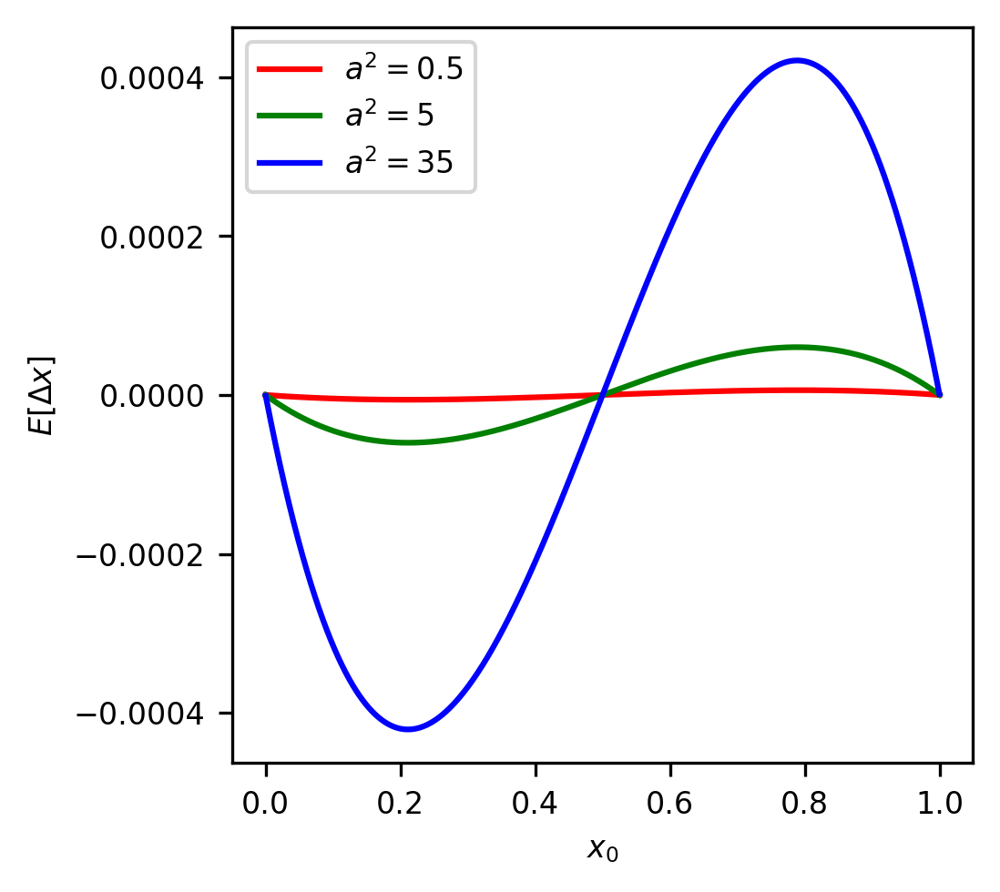

In [14]:
# the expected change in allele frequency under stationary stabilizing selection (to confirm its negativity for minor alleles)
fontsize = 8

N = 2000
U = 0.025

fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = fig.add_subplot(1, 1, 1)

ax.plot(np.linspace(1 / (2 * N), 1 - 1 / (2 * N), 2 * N - 1), [E_Delta_x_stab_sel(a=np.sqrt(0.5), x=x) for x in np.linspace(1 / (2 * N), 1 - 1 / (2 * N), 2 * N - 1)], color='r', label=r'$a^2=%g$' % 0.5)
ax.plot(np.linspace(1 / (2 * N), 1 - 1 / (2 * N), 2 * N - 1), [E_Delta_x_stab_sel(a=np.sqrt(5), x=x) for x in np.linspace(1 / (2 * N), 1 - 1 / (2 * N), 2 * N - 1)], color='g', label=r'$a^2=%g$' % 5)
ax.plot(np.linspace(1 / (2 * N), 1 - 1 / (2 * N), 2 * N - 1), [E_Delta_x_stab_sel(a=np.sqrt(35), x=x) for x in np.linspace(1 / (2 * N), 1 - 1 / (2 * N), 2 * N - 1)], color='b', label=r'$a^2=%g$' % 35)

plt.xlabel(r'$x_0$', fontsize=fontsize)
plt.ylabel(r'$E[\Delta x]$', fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.legend(fontsize=fontsize)
plt.show()

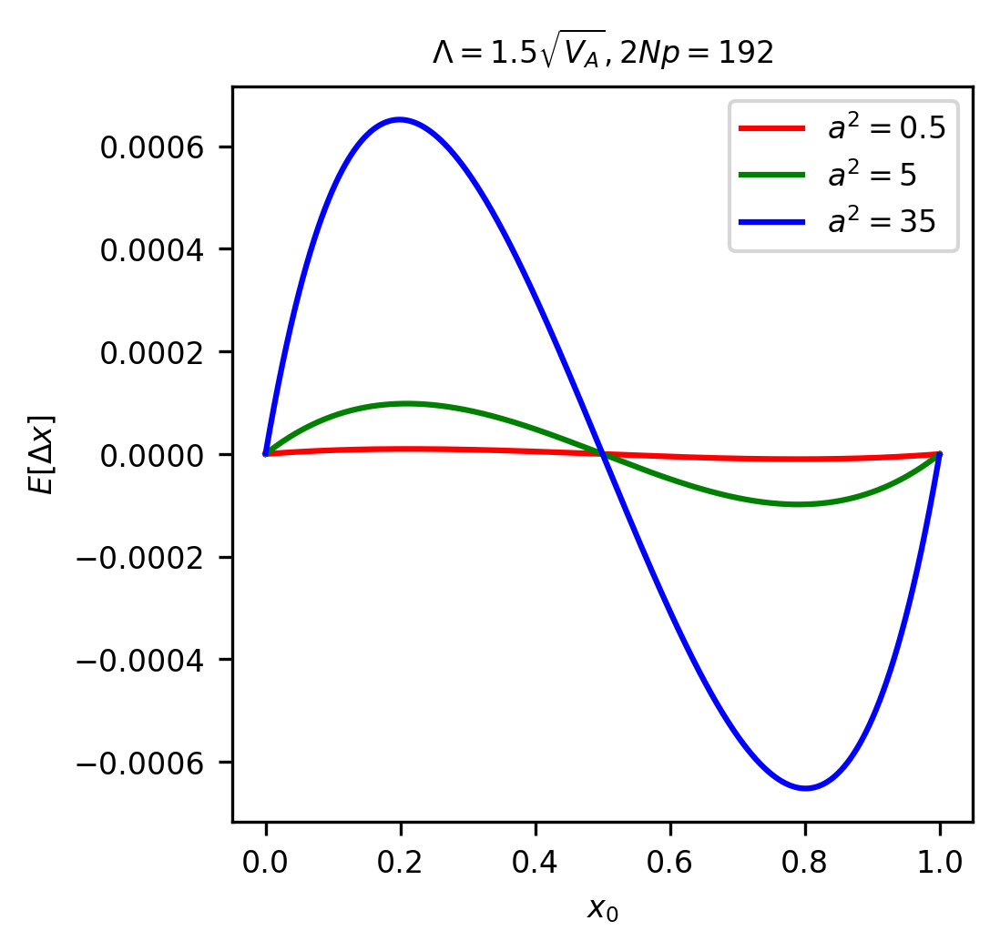

In [15]:
# the expected change in allele frequency under recurrent shifts, specifically a set of parameters where the fixation probability increases with the effect size squared (to confirm its positivity for minor alleles)
fontsize = 8

N = 2000
U = 0.025
E2Ns = 1

index_shift_s0, shift_s0 = 15, 1.5
index_rate_of_shift, rate_of_shift = 37, 0.048

fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = fig.add_subplot(1, 1, 1)

ss, color = 0.5, 'r'
ax.plot(np.linspace(1 / (2 * N), 1 - 1 / (2 * N), 2 * N - 1), [E_Delta_x_stab_sel(a=np.sqrt(ss), x=x) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x, shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift])) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x, shift_s0=-shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift])) for x in np.linspace(1 / (2 * N), 1 - 1 / (2 * N), 2 * N - 1)], color=color, label=r'$a^2=%g$' % ss)
ss, color = 5, 'g'
ax.plot(np.linspace(1 / (2 * N), 1 - 1 / (2 * N), 2 * N - 1), [E_Delta_x_stab_sel(a=np.sqrt(ss), x=x) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x, shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift])) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x, shift_s0=-shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift])) for x in np.linspace(1 / (2 * N), 1 - 1 / (2 * N), 2 * N - 1)], color=color, label=r'$a^2=%g$' % ss)
ss, color = 35, 'b'
ax.plot(np.linspace(1 / (2 * N), 1 - 1 / (2 * N), 2 * N - 1), [E_Delta_x_stab_sel(a=np.sqrt(ss), x=x) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x, shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift])) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x, shift_s0=-shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift])) for x in np.linspace(1 / (2 * N), 1 - 1 / (2 * N), 2 * N - 1)], color=color, label=r'$a^2=%g$' % ss)

plt.xlabel(r'$x_0$', fontsize=fontsize)
plt.ylabel(r'$E[\Delta x]$', fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.title(r'$\Lambda=%g\sqrt{V_A}, 2Np=%g$' % (shift_s0, 2 * N * rate_of_shift), fontsize=fontsize)
plt.legend(fontsize=fontsize)
plt.show()

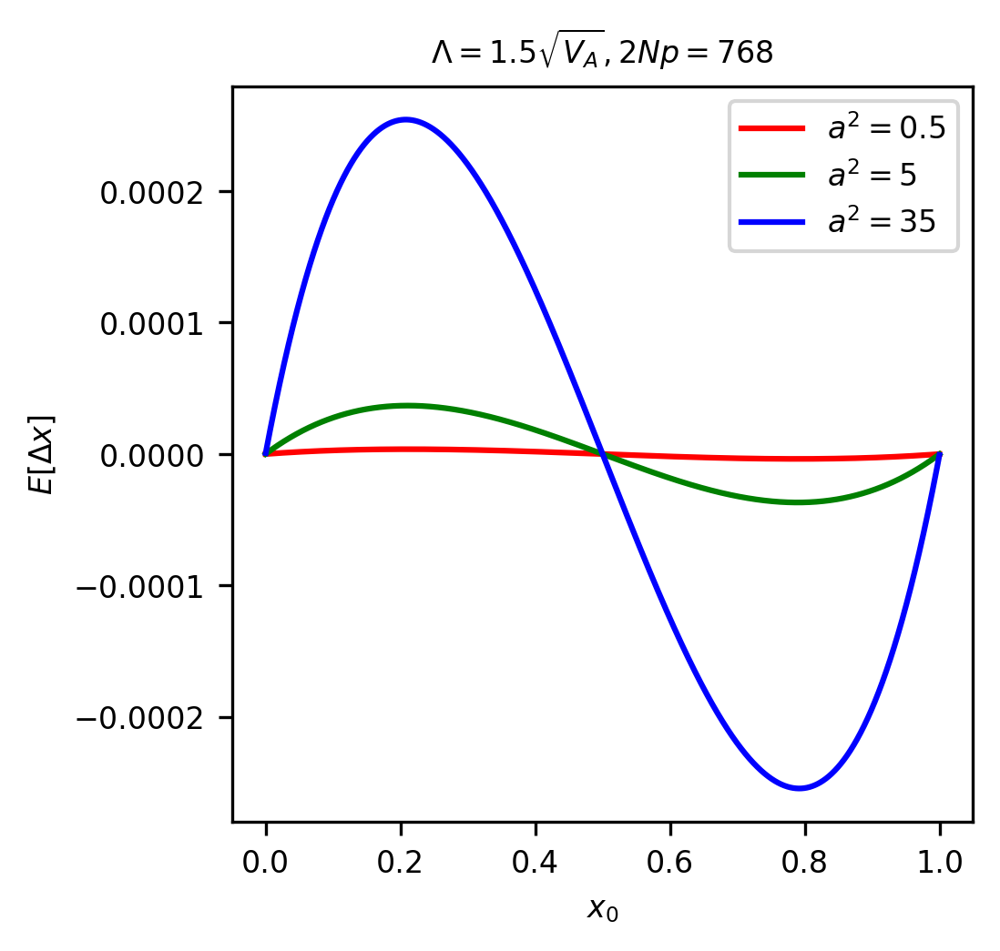

In [7]:
# the expected change in allele frequency under recurrent shifts, specifically a set of parameters where the fixation probability increases with the effect size squared (to confirm its positivity for minor alleles)
fontsize = 8

N = 2000
U = 0.025
E2Ns = 16

index_shift_s0, shift_s0 = 17, 1.5
index_rate_of_shift, rate_of_shift = 54, 0.192

fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = fig.add_subplot(1, 1, 1)

ss, color = 0.5, 'r'
ax.plot(np.linspace(1 / (2 * N), 1 - 1 / (2 * N), 2 * N - 1), [E_Delta_x_stab_sel(a=np.sqrt(ss), x=x) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x, shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift])) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x, shift_s0=-shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift])) for x in np.linspace(1 / (2 * N), 1 - 1 / (2 * N), 2 * N - 1)], color=color, label=r'$a^2=%g$' % ss)
ss, color = 5, 'g'
ax.plot(np.linspace(1 / (2 * N), 1 - 1 / (2 * N), 2 * N - 1), [E_Delta_x_stab_sel(a=np.sqrt(ss), x=x) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x, shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift])) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x, shift_s0=-shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift])) for x in np.linspace(1 / (2 * N), 1 - 1 / (2 * N), 2 * N - 1)], color=color, label=r'$a^2=%g$' % ss)
ss, color = 35, 'b'
ax.plot(np.linspace(1 / (2 * N), 1 - 1 / (2 * N), 2 * N - 1), [E_Delta_x_stab_sel(a=np.sqrt(ss), x=x) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x, shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift])) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x, shift_s0=-shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift])) for x in np.linspace(1 / (2 * N), 1 - 1 / (2 * N), 2 * N - 1)], color=color, label=r'$a^2=%g$' % ss)

plt.xlabel(r'$x_0$', fontsize=fontsize)
plt.ylabel(r'$E[\Delta x]$', fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.title(r'$\Lambda=%g\sqrt{V_A}, 2Np=%g$' % (shift_s0, 2 * N * rate_of_shift), fontsize=fontsize)
plt.legend(fontsize=fontsize)
plt.show()

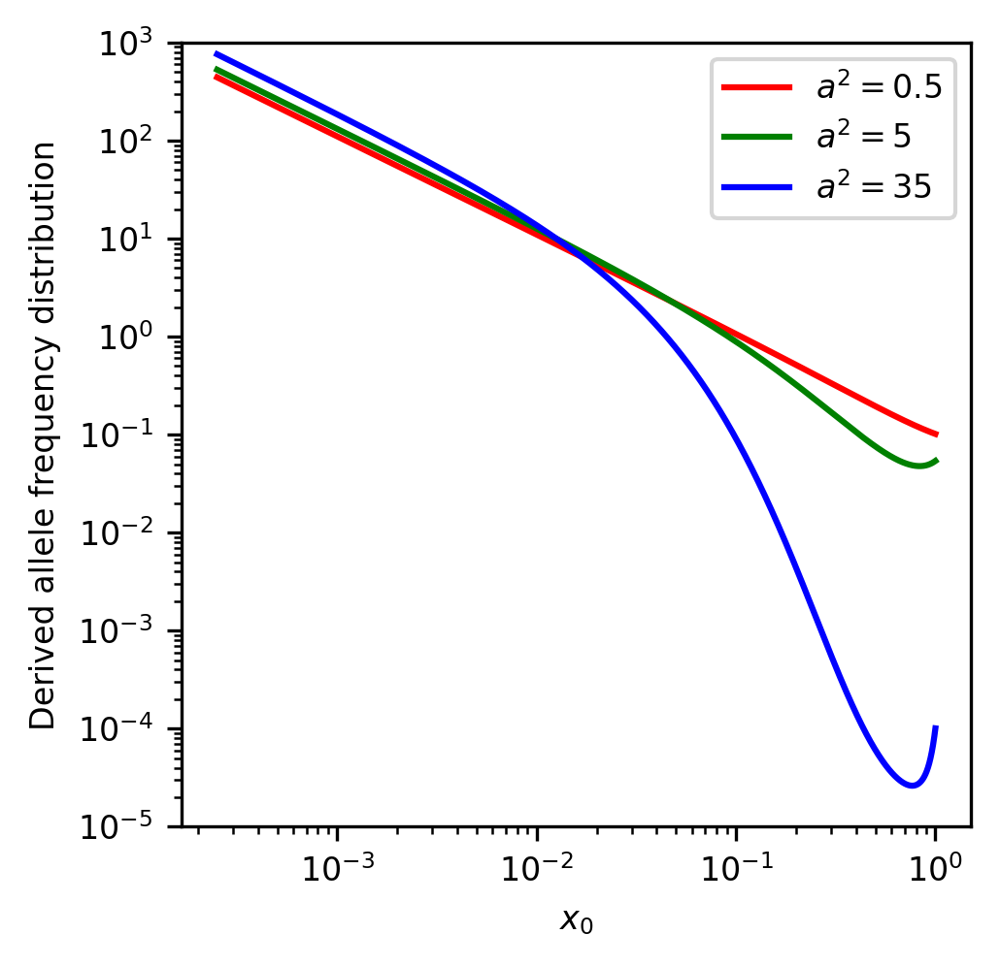

In [6]:
# the derived allele frequency distribution under stationary stabilizing selection
fontsize = 8

N = 2000
U = 0.025

fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = fig.add_subplot(1, 1, 1)

ss, color = 0.5, 'r'
ax.plot(np.linspace(1 / (2 * N), 1 - 1 / (2 * N), 2 * N - 1), np.divide([tau(a=np.sqrt(ss), x=x, p=1 / (2 * N)) for x in np.linspace(1 / (2 * N), 1 - 1 / (2 * N), 2 * N - 1)], quad(lambda x_0: tau(a=np.sqrt(ss), x=x_0, p=1 / (2 * N)), 0.0, 1.0, points=[1/(2*N)])[0]), color=color, label=r'$a^2=%g$' % ss)
ss, color = 5, 'g'
ax.plot(np.linspace(1 / (2 * N), 1 - 1 / (2 * N), 2 * N - 1), np.divide([tau(a=np.sqrt(ss), x=x, p=1 / (2 * N)) for x in np.linspace(1 / (2 * N), 1 - 1 / (2 * N), 2 * N - 1)], quad(lambda x_0: tau(a=np.sqrt(ss), x=x_0, p=1 / (2 * N)), 0.0, 1.0, points=[1/(2*N)])[0]), color=color, label=r'$a^2=%g$' % ss)
ss, color = 35, 'b'
ax.plot(np.linspace(1 / (2 * N), 1 - 1 / (2 * N), 2 * N - 1), np.divide([tau(a=np.sqrt(ss), x=x, p=1 / (2 * N)) for x in np.linspace(1 / (2 * N), 1 - 1 / (2 * N), 2 * N - 1)], quad(lambda x_0: tau(a=np.sqrt(ss), x=x_0, p=1 / (2 * N)), 0.0, 1.0, points=[1/(2*N)])[0]), color=color, label=r'$a^2=%g$' % ss)

ax.set_ylim(1e-5, 1e3)
ax.set_xscale('log')
ax.set_yscale('log')
plt.xlabel(r'$x_0$', fontsize=fontsize)
plt.ylabel('Derived allele frequency distribution', fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.legend(fontsize=fontsize)
plt.show()

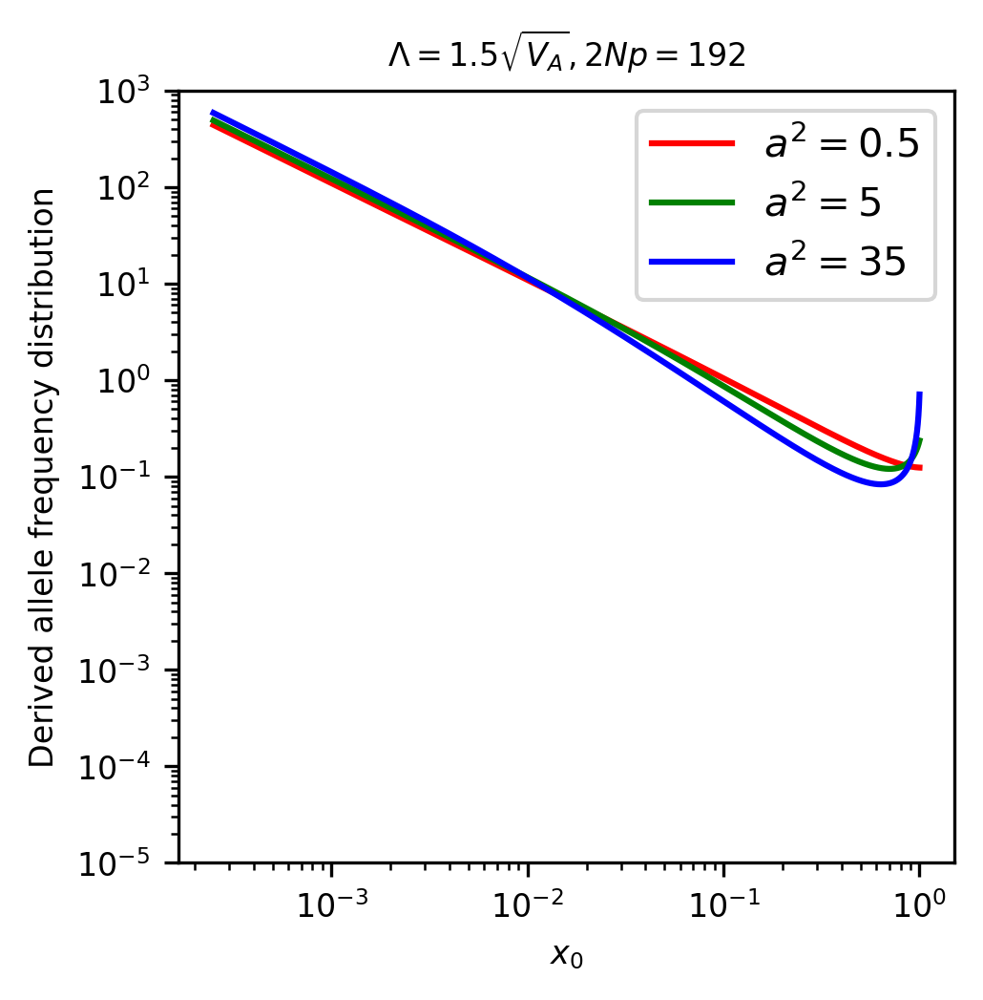

In [7]:
# the derived allele frequency distribution under recurrent shifts, specifically a set of parameters where the fixation probability increases with the effect size squared
fontsize = 8

N = 2000
U = 0.025
E2Ns = 1

index_shift_s0, shift_s0 = 15, 1.5
index_rate_of_shift, rate_of_shift = 37, 0.048

fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = fig.add_subplot(1, 1, 1)

ss, color = 0.5, 'r'
ax.plot(np.linspace(1 / (2 * N), 1 - 1 / (2 * N), 2 * N - 1), np.divide([tau_shifts(a=np.sqrt(ss), x=x, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) for x in np.linspace(1 / (2 * N), 1 - 1 / (2 * N), 2 * N - 1)], quad(lambda x_0: tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0]), color=color, label=r'$a^2=%g$' % ss)
ss, color = 5, 'g'
ax.plot(np.linspace(1 / (2 * N), 1 - 1 / (2 * N), 2 * N - 1), np.divide([tau_shifts(a=np.sqrt(ss), x=x, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) for x in np.linspace(1 / (2 * N), 1 - 1 / (2 * N), 2 * N - 1)], quad(lambda x_0: tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0]), color=color, label=r'$a^2=%g$' % ss)
ss, color = 35, 'b'
ax.plot(np.linspace(1 / (2 * N), 1 - 1 / (2 * N), 2 * N - 1), np.divide([tau_shifts(a=np.sqrt(ss), x=x, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) for x in np.linspace(1 / (2 * N), 1 - 1 / (2 * N), 2 * N - 1)], quad(lambda x_0: tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0]), color=color, label=r'$a^2=%g$' % ss)

ax.set_ylim(1e-5, 1e3)
ax.set_xscale('log')
ax.set_yscale('log')
plt.xlabel(r'$x_0$', fontsize=fontsize)
plt.ylabel('Derived allele frequency distribution', fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.title(r'$\Lambda=%g\sqrt{V_A}, 2Np=%g$' % (shift_s0, 2 * N * rate_of_shift), fontsize=fontsize)
plt.legend()
plt.show()

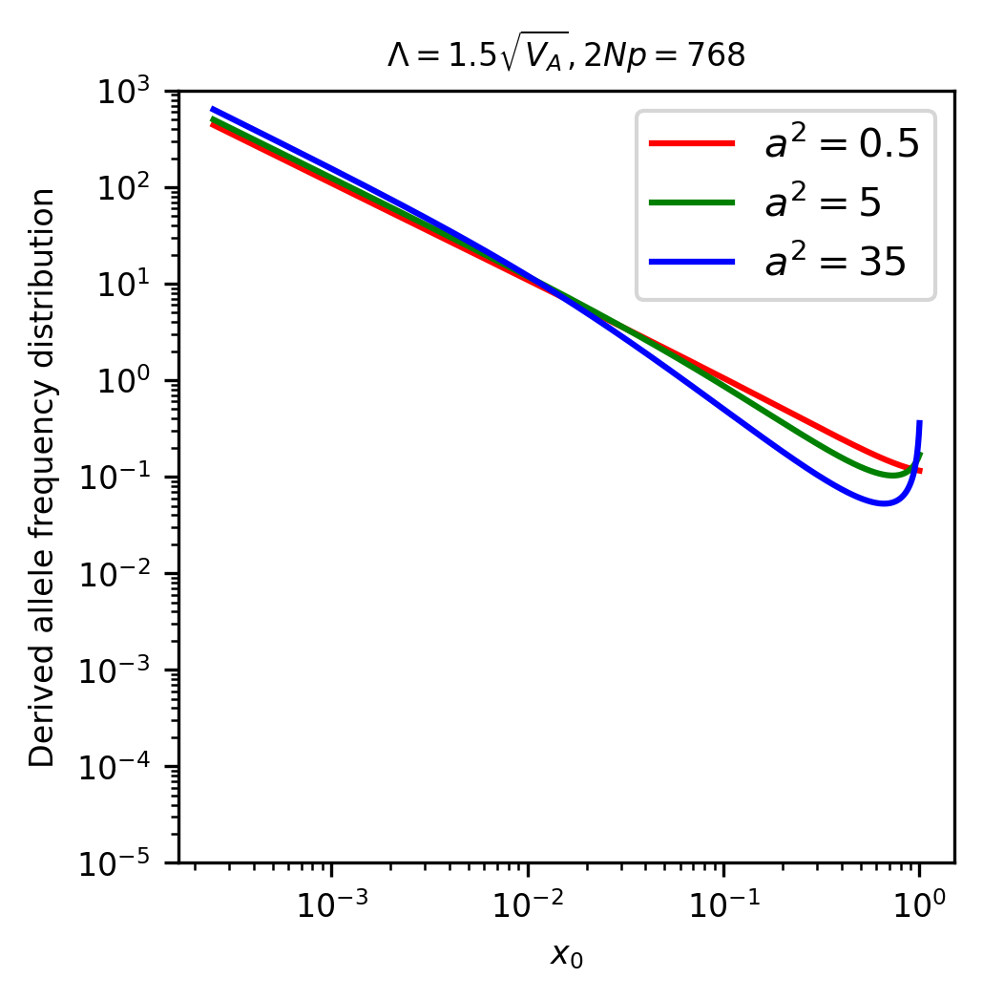

In [8]:
# the derived allele frequency distribution under recurrent shifts, specifically a set of parameters where the fixation probability increases with the effect size squared
fontsize = 8

N = 2000
U = 0.025
E2Ns = 16

index_shift_s0, shift_s0 = 17, 1.5
index_rate_of_shift, rate_of_shift = 54, 0.192

fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = fig.add_subplot(1, 1, 1)

ss, color = 0.5, 'r'
ax.plot(np.linspace(1 / (2 * N), 1 - 1 / (2 * N), 2 * N - 1), np.divide([tau_shifts(a=np.sqrt(ss), x=x, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) for x in np.linspace(1 / (2 * N), 1 - 1 / (2 * N), 2 * N - 1)], quad(lambda x_0: tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0]), color=color, label=r'$a^2=%g$' % ss)
ss, color = 5, 'g'
ax.plot(np.linspace(1 / (2 * N), 1 - 1 / (2 * N), 2 * N - 1), np.divide([tau_shifts(a=np.sqrt(ss), x=x, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) for x in np.linspace(1 / (2 * N), 1 - 1 / (2 * N), 2 * N - 1)], quad(lambda x_0: tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0]), color=color, label=r'$a^2=%g$' % ss)
ss, color = 35, 'b'
ax.plot(np.linspace(1 / (2 * N), 1 - 1 / (2 * N), 2 * N - 1), np.divide([tau_shifts(a=np.sqrt(ss), x=x, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) for x in np.linspace(1 / (2 * N), 1 - 1 / (2 * N), 2 * N - 1)], quad(lambda x_0: tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0]), color=color, label=r'$a^2=%g$' % ss)

ax.set_ylim(1e-5, 1e3)
ax.set_xscale('log')
ax.set_yscale('log')
plt.xlabel(r'$x_0$', fontsize=fontsize)
plt.ylabel('Derived allele frequency distribution', fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.title(r'$\Lambda=%g\sqrt{V_A}, 2Np=%g$' % (shift_s0, 2 * N * rate_of_shift), fontsize=fontsize)
plt.legend()
plt.show()

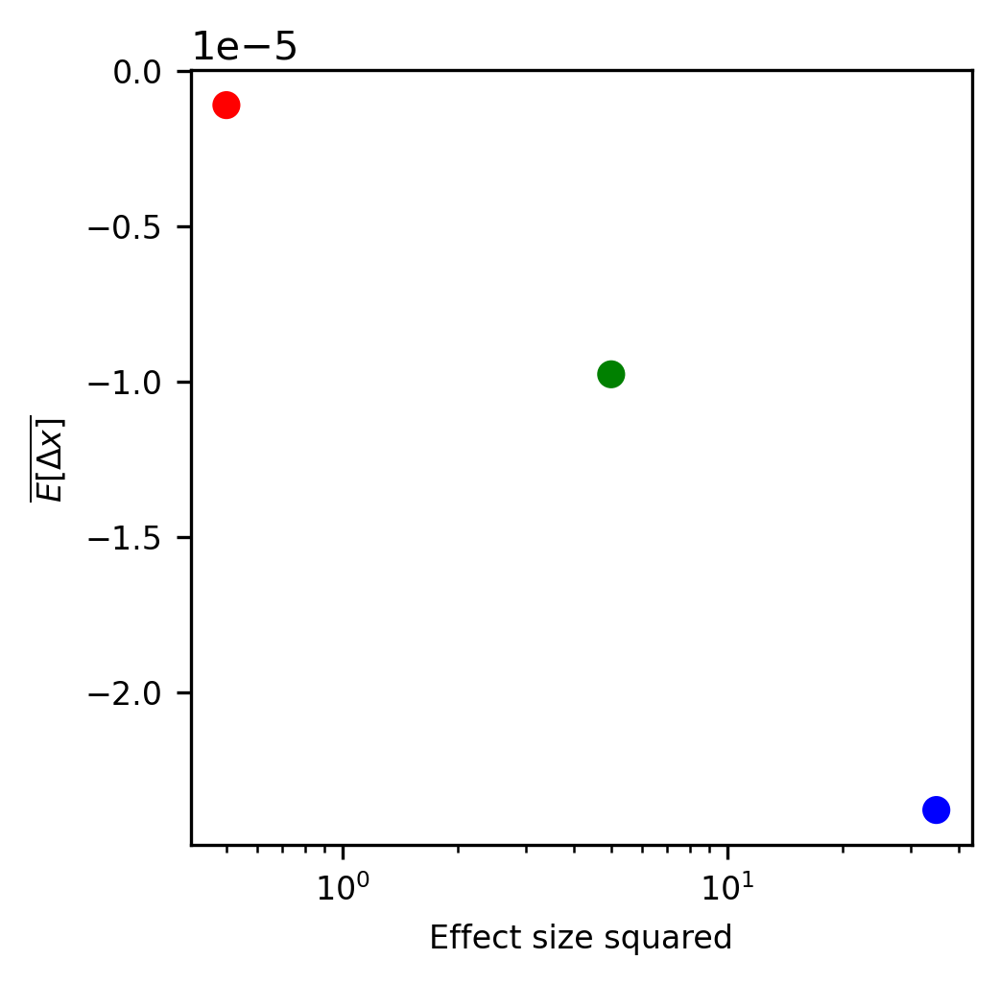

In [8]:
# the average expected change in allele frequency under stationary stabilizing selection (to confirm its negativity)
fontsize = 8

N = 2000
U = 0.025

fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = fig.add_subplot(1, 1, 1)

ax.scatter([0.5, 5, 35], [quad(lambda x: E_Delta_x_stab_sel(a=np.sqrt(ss), x=x) * tau(a=np.sqrt(ss), x=x, p=1 / (2 * N)), 0.0, 1.0, points=[1/(2*N)])[0] / quad(lambda x: tau(a=np.sqrt(ss), x=x, p=1 / (2 * N)), 0.0, 1.0, points=[1/(2*N)])[0] for ss in [0.5, 5, 35]], c=['r', 'g', 'b'])

ax.set_xscale('log')
plt.xlabel('Effect size squared', fontsize=fontsize)
plt.ylabel(r'$\overline{E[\Delta x]}$', fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

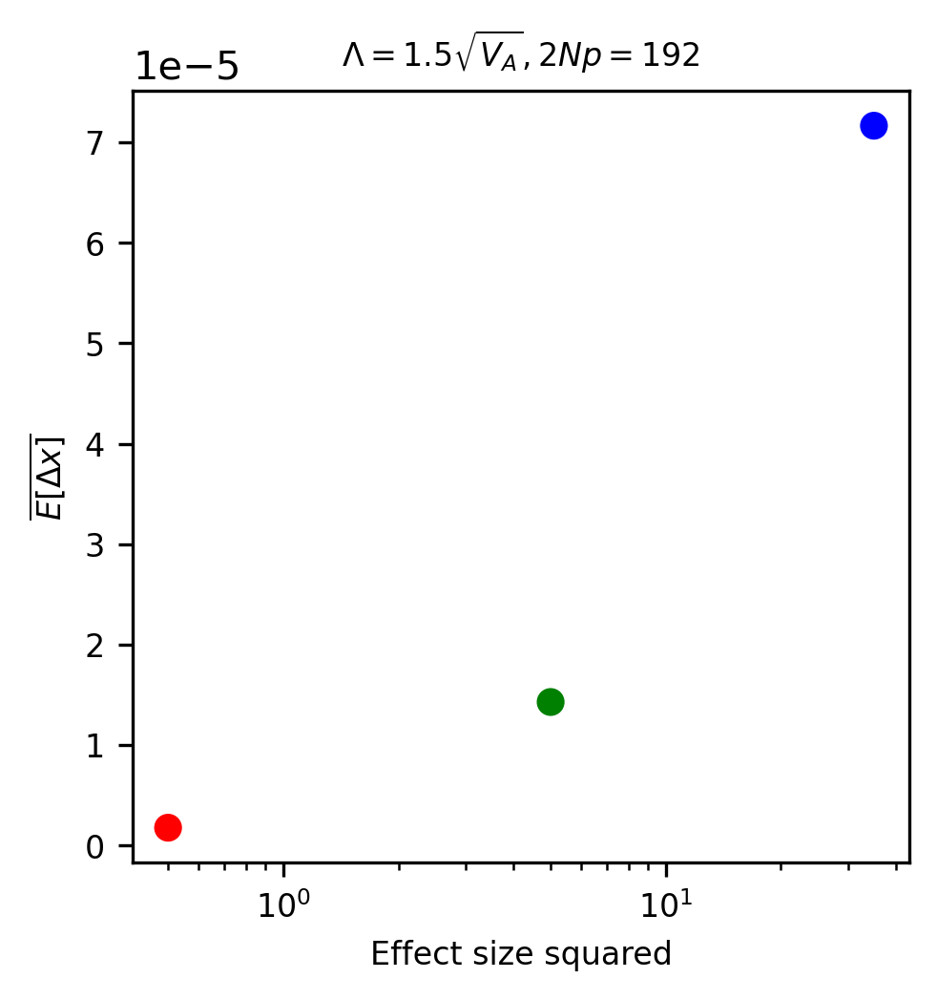

In [14]:
# the average expected change in allele frequency under recurrent shifts, specifically a set of parameters where the fixation probability increases with the effect size squared (to confirm its positivity)
fontsize = 8

N = 2000
U = 0.025
E2Ns = 1

index_shift_s0, shift_s0 = 15, 1.5
index_rate_of_shift, rate_of_shift = 37, 0.048

fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = fig.add_subplot(1, 1, 1)

ax.scatter([0.5, 5, 35], [np.divide(quad(lambda x_0: (E_Delta_x_stab_sel(a=np.sqrt(ss), x=x_0) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x_0, shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift])) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x_0, shift_s0=-shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]))) * tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0], quad(lambda x_0: tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0]) for ss in [0.5, 5, 35]], c=['r', 'g', 'b'])

ax.set_xscale('log')
plt.xlabel('Effect size squared', fontsize=fontsize)
plt.ylabel(r'$\overline{E[\Delta x]}$', fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.title(r'$\Lambda=%g\sqrt{V_A}, 2Np=%g$' % (shift_s0, 2 * N * rate_of_shift), fontsize=fontsize)
plt.show()

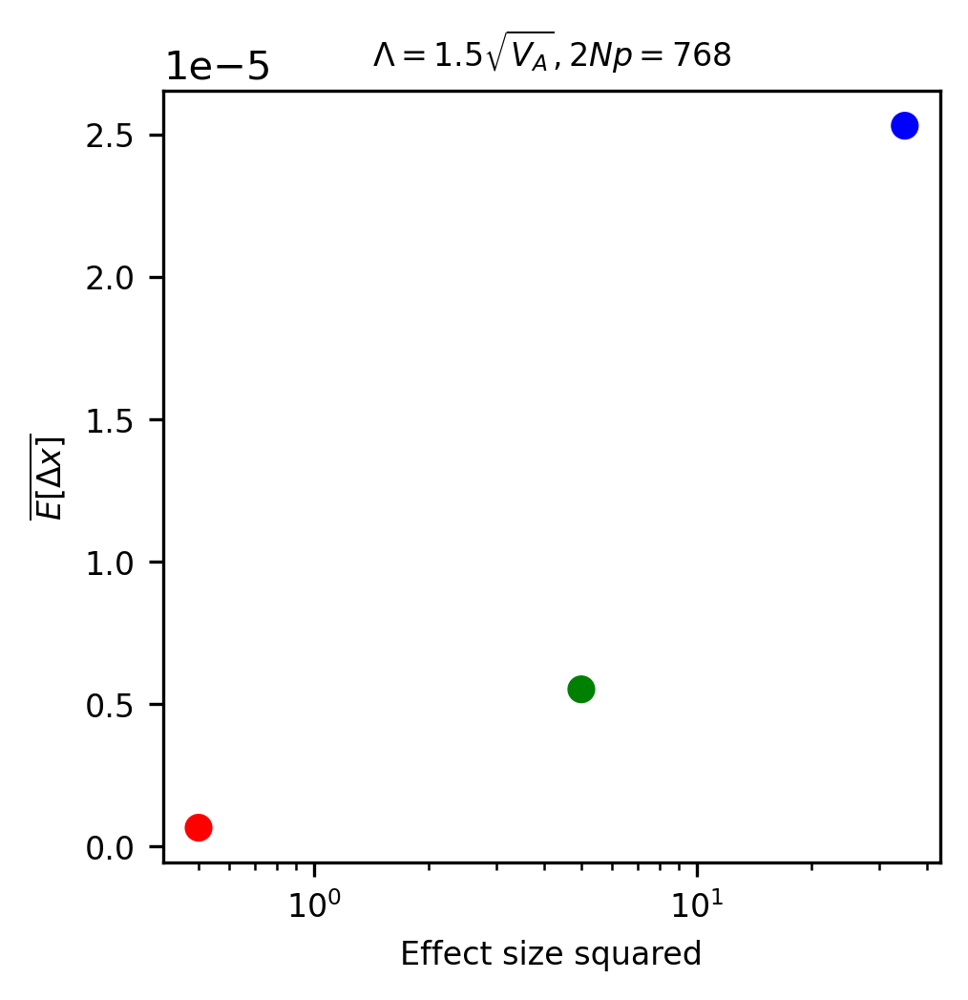

In [9]:
# the average expected change in allele frequency under recurrent shifts, specifically a set of parameters where the fixation probability increases with the effect size squared (to confirm its positivity)
fontsize = 8

N = 2000
U = 0.025
E2Ns = 16

index_shift_s0, shift_s0 = 17, 1.5
index_rate_of_shift, rate_of_shift = 54, 0.192

fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = fig.add_subplot(1, 1, 1)

ax.scatter([0.5, 5, 35], [np.divide(quad(lambda x_0: (E_Delta_x_stab_sel(a=np.sqrt(ss), x=x_0) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x_0, shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift])) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x_0, shift_s0=-shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]))) * tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0], quad(lambda x_0: tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0]) for ss in [0.5, 5, 35]], c=['r', 'g', 'b'])

ax.set_xscale('log')
plt.xlabel('Effect size squared', fontsize=fontsize)
plt.ylabel(r'$\overline{E[\Delta x]}$', fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.title(r'$\Lambda=%g\sqrt{V_A}, 2Np=%g$' % (shift_s0, 2 * N * rate_of_shift), fontsize=fontsize)
plt.show()

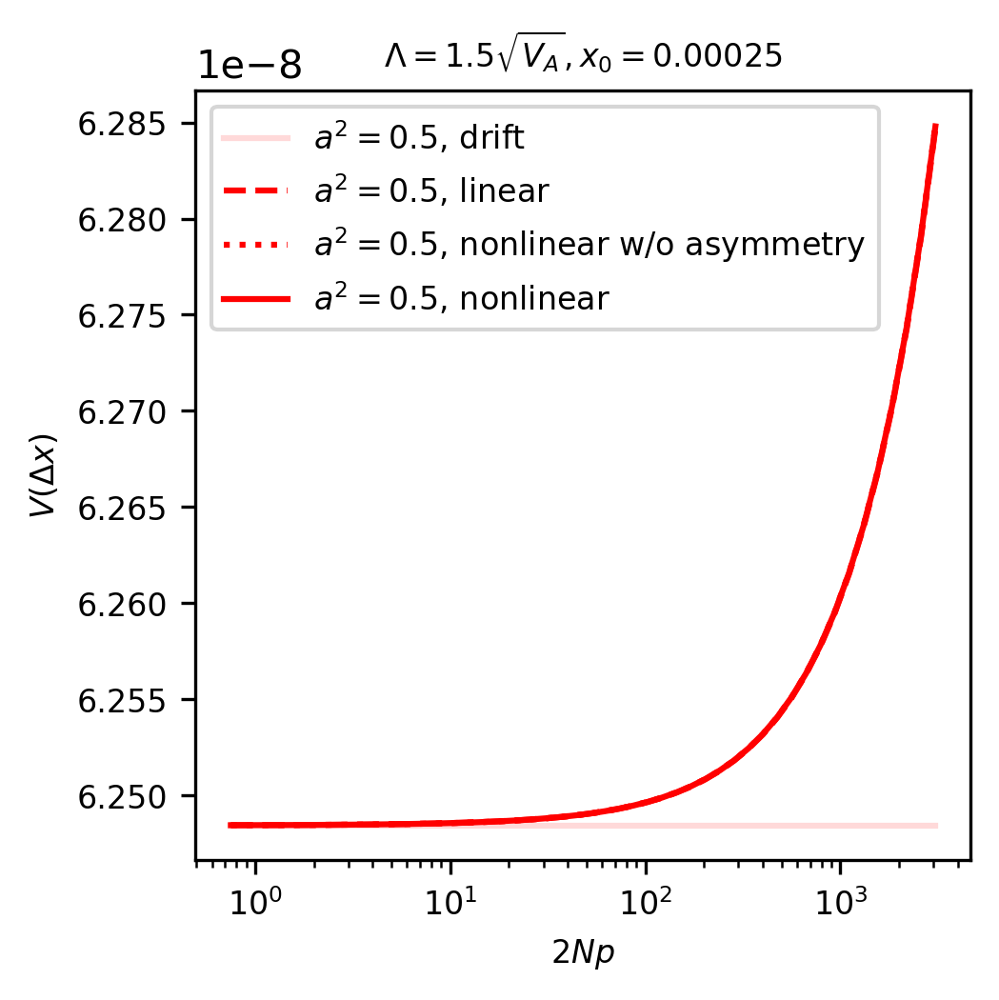

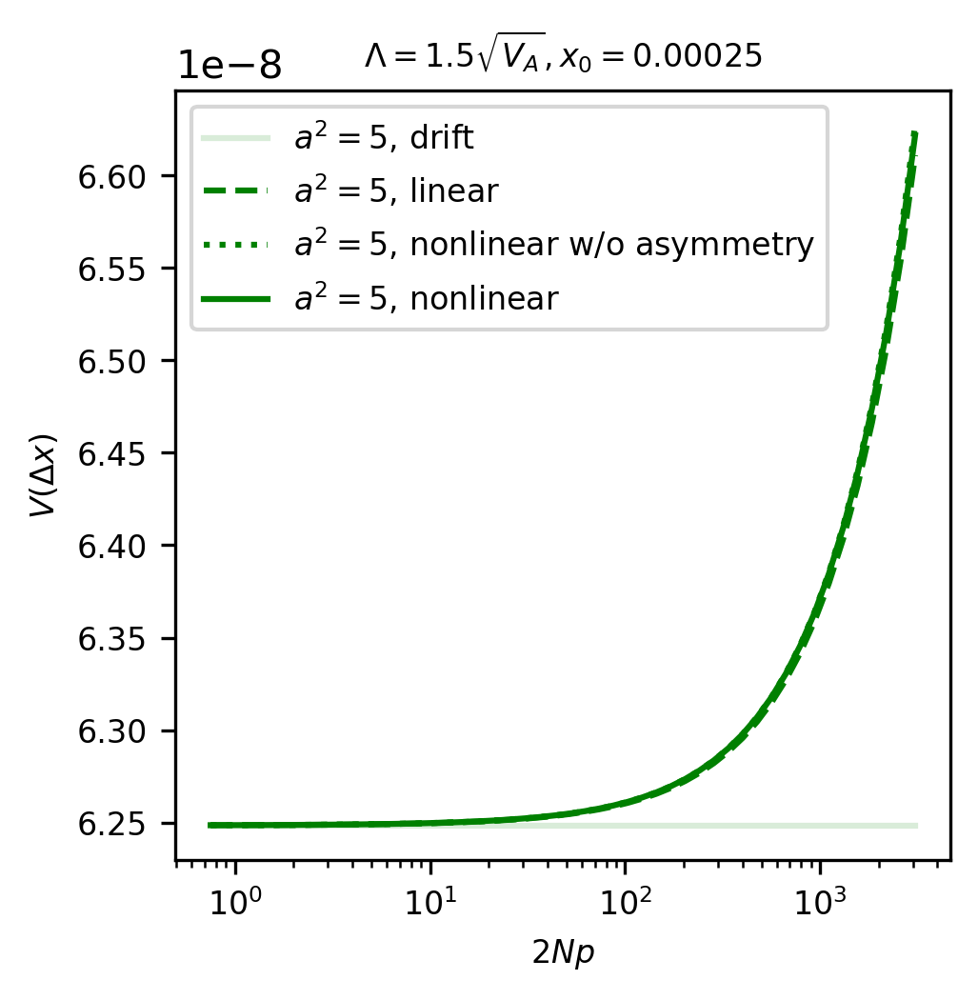

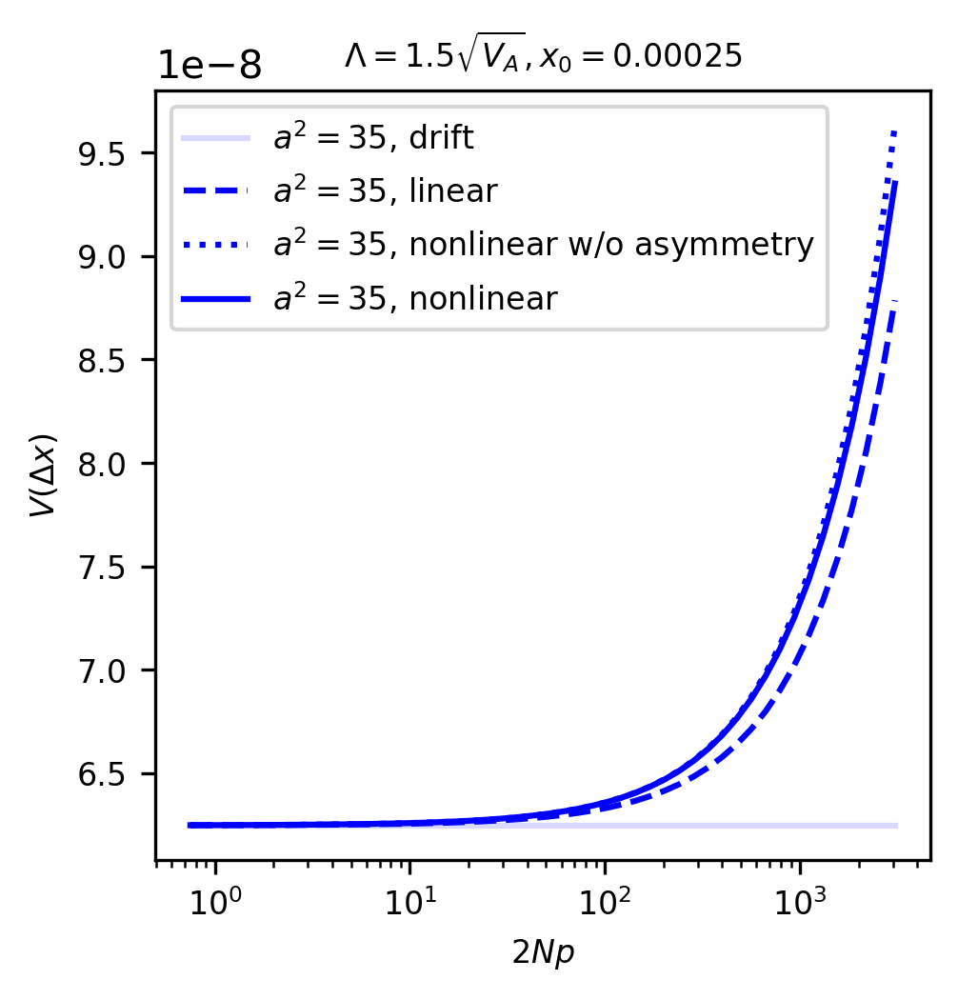

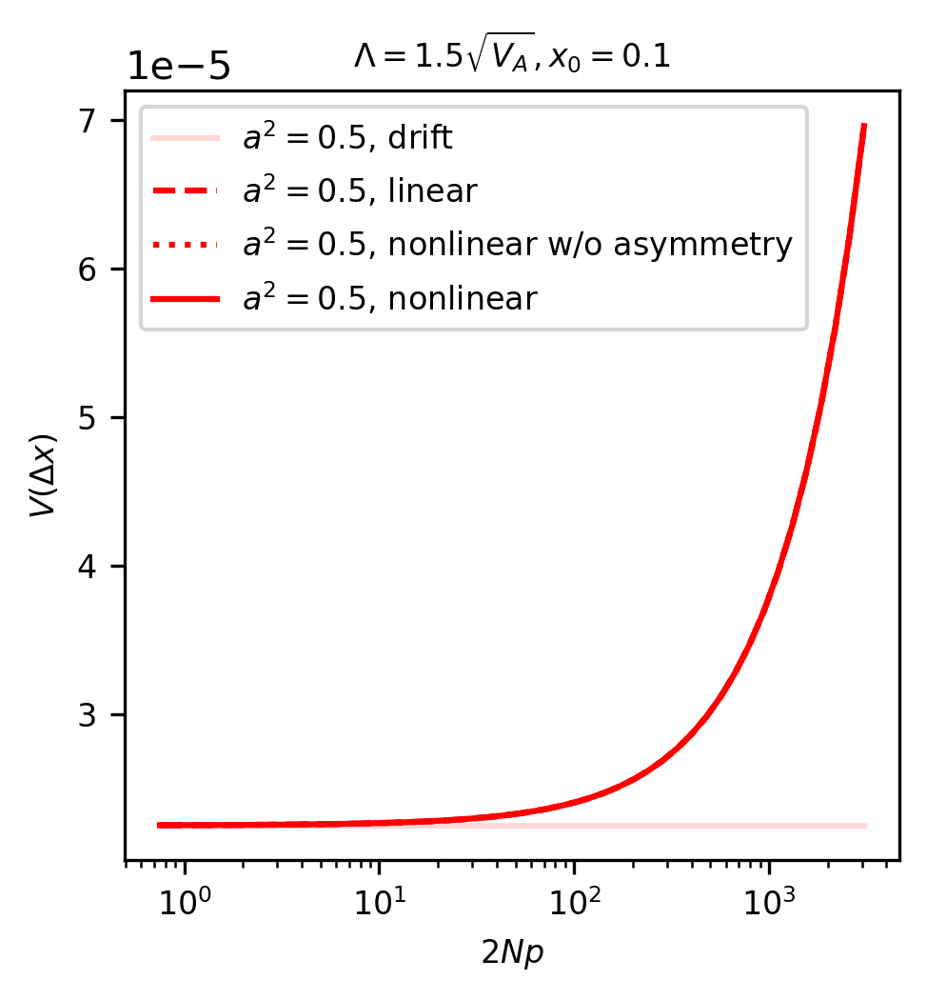

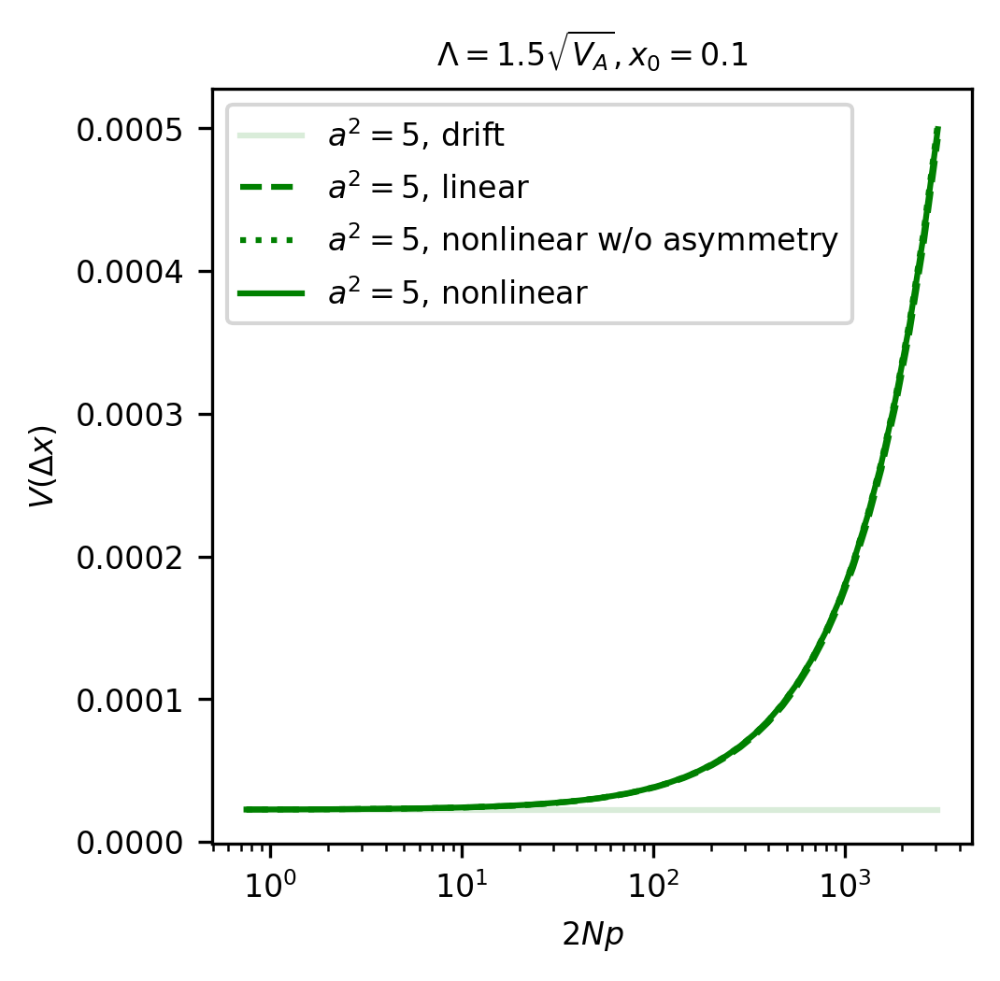

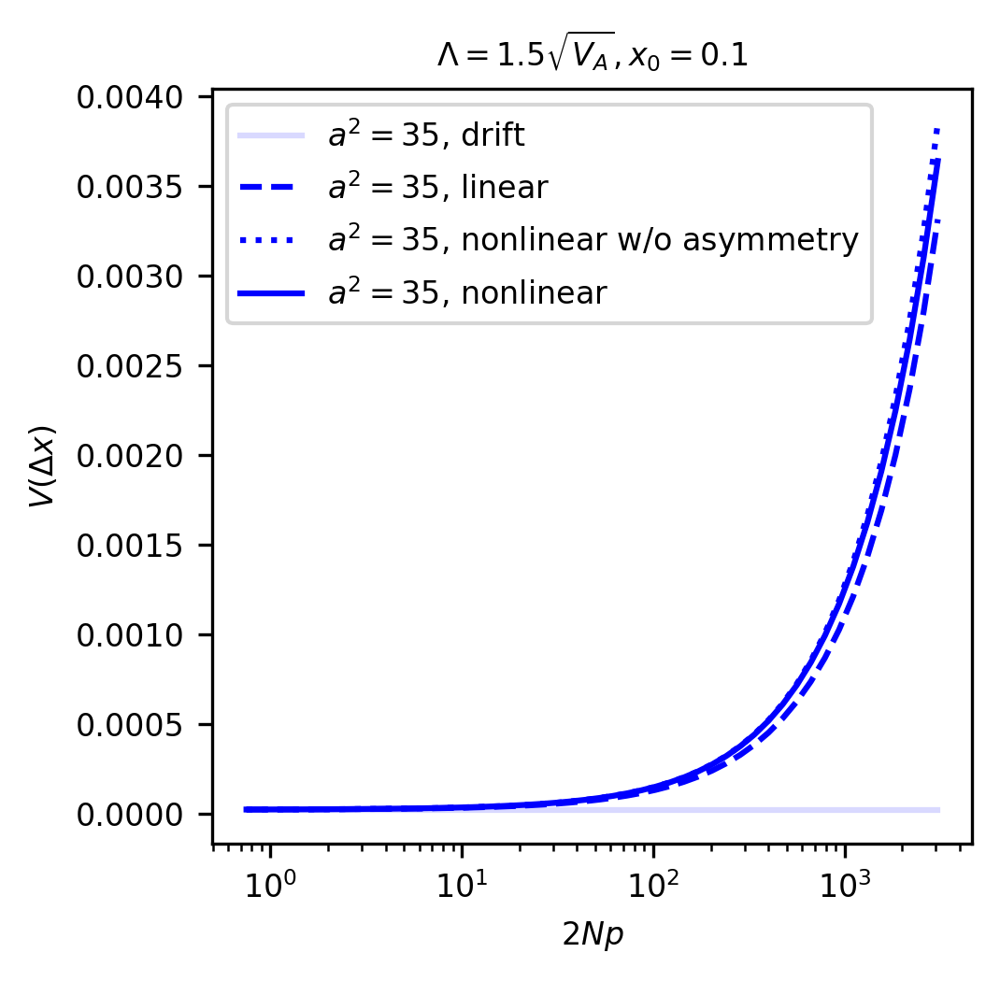

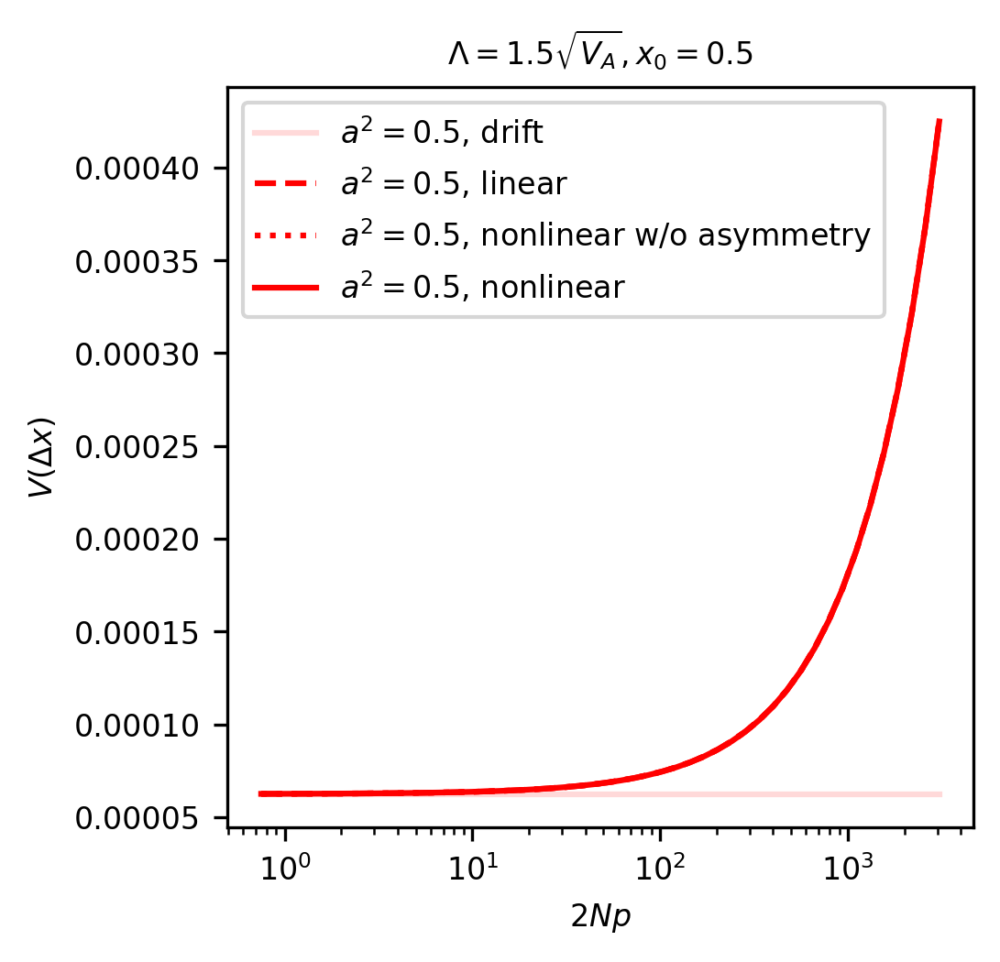

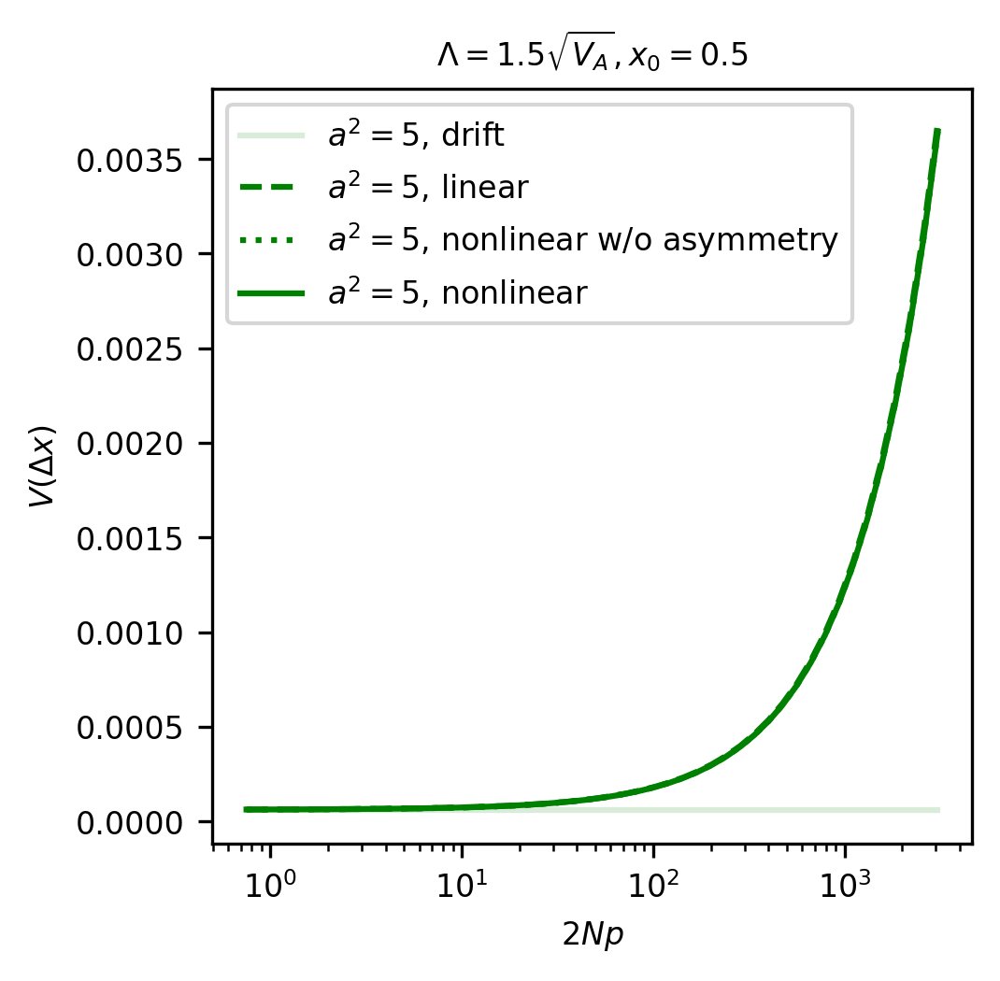

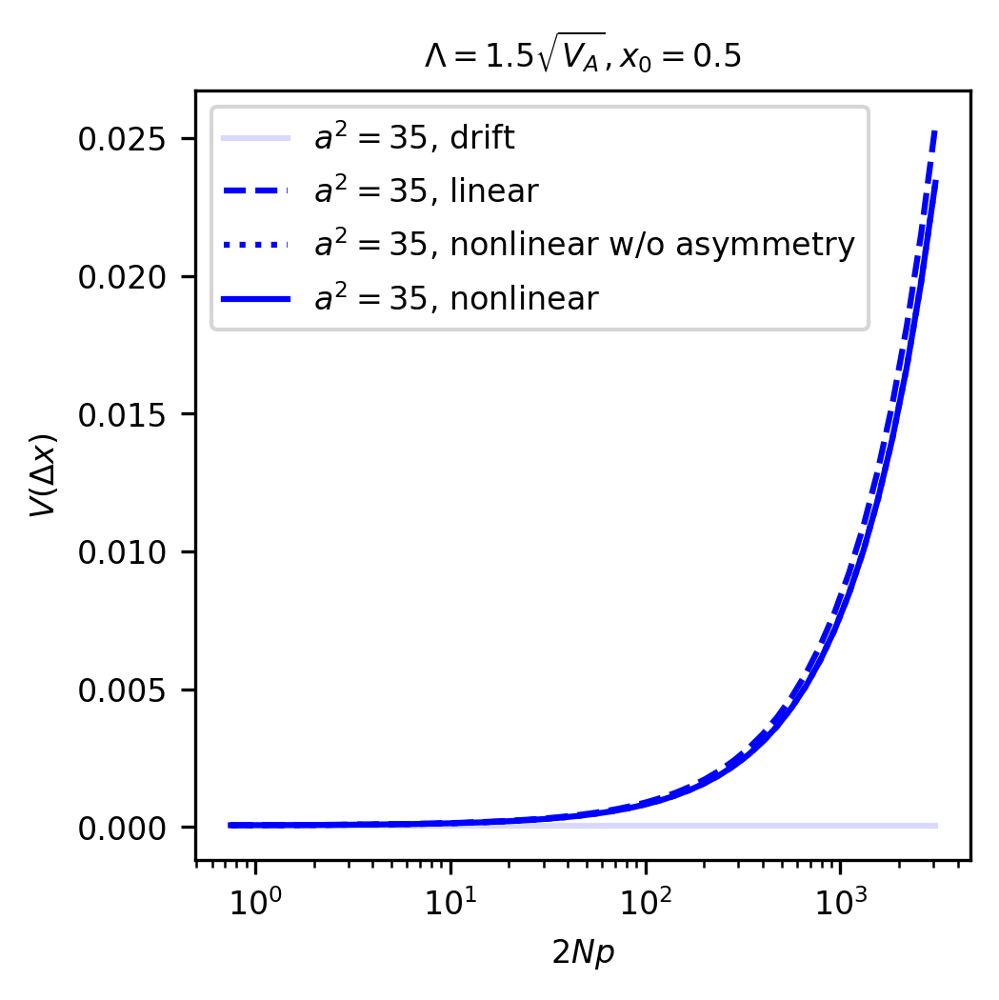

In [5]:
# the variance of change in allele frequency, in the Lande case
fontsize = 8

N = 2000
U = 0.025
E2Ns = 1

shift_s0 = 1.5

for x in (1 / (2 * N), 0.1, 0.5):
    for ss, color in ((0.5, 'r'), (5, 'g'), (35, 'b')):
        fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
        ax = fig.add_subplot(1, 1, 1)
    
        ax.plot(2 * N * np.geomspace(0.0001875, 0.768), [x * (1 - x) / (2 * N) for _ in np.geomspace(0.0001875, 0.768)], color=color, alpha=0.15, label=r'$a^2=%g$, drift' % ss)
        ax.plot(2 * N * np.geomspace(0.0001875, 0.768), [V_Delta_x_drift_and_shifts(a=np.sqrt(ss), x=x, shift_s0=shift_s0, sigma_0_del=np.sqrt(V_A(E2Ns=E2Ns)), p=rate_of_shift) for rate_of_shift in np.geomspace(0.0001875, 0.768)], color=color, linestyle='--', label=r'$a^2=%g$, linear' % ss)
        ax.plot(2 * N * np.geomspace(0.0001875, 0.768), [V_Delta_x_drift_and_shifts_nonlinear_without_asymmetry(a=np.sqrt(ss), x=x, shift_s0=shift_s0, sigma_0_del=np.sqrt(V_A(E2Ns=E2Ns)), p=rate_of_shift) for rate_of_shift in np.geomspace(0.0001875, 0.768)], color=color, linestyle=':', label=r'$a^2=%g$, nonlinear w/o asymmetry' % ss)
        ax.plot(2 * N * np.geomspace(0.0001875, 0.768), [V_Delta_x_drift_and_shifts_nonlinear(a=np.sqrt(ss), x=x, shift_s0=shift_s0, sigma_0_del=np.sqrt(V_A(E2Ns=E2Ns)), p=rate_of_shift) for rate_of_shift in np.geomspace(0.0001875, 0.768)], color=color, label=r'$a^2=%g$, nonlinear' % ss)
    
        ax.set_xscale('log')
        plt.xlabel(r'$2Np$', fontsize=fontsize)
        plt.ylabel(r'$V(\Delta x)$', fontsize=fontsize)
        plt.xticks(fontsize=fontsize)
        plt.yticks(fontsize=fontsize)
        plt.legend(fontsize=fontsize)
        plt.title(r'$\Lambda=%g\sqrt{V_A}, x_0=%g$' % (shift_s0, x), fontsize=fontsize)
        plt.show()

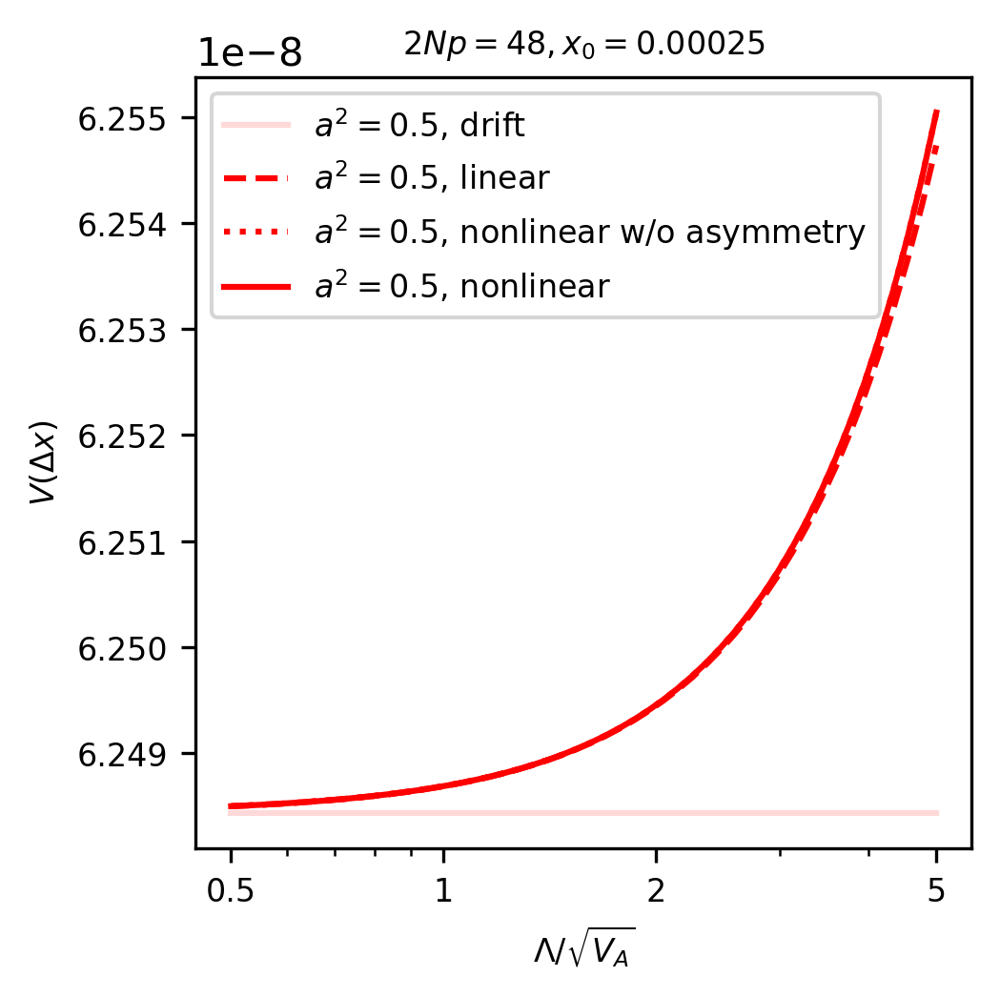

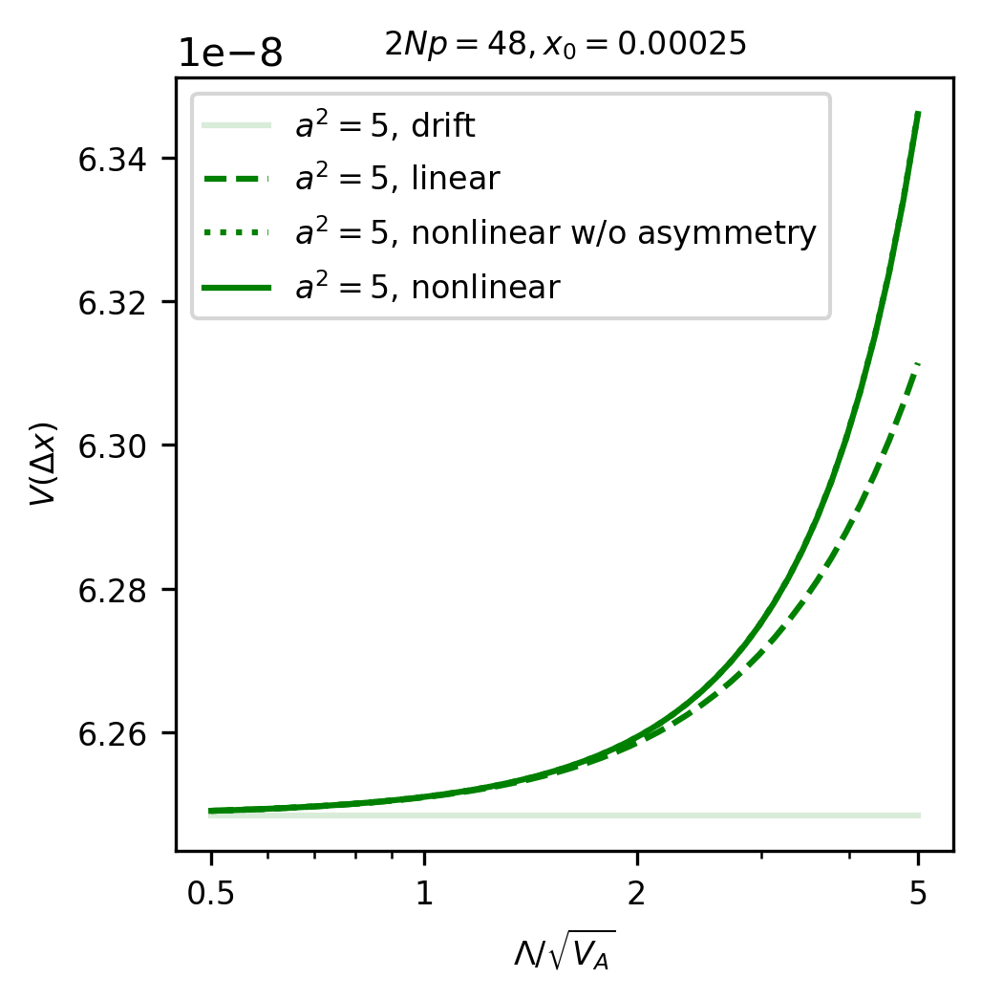

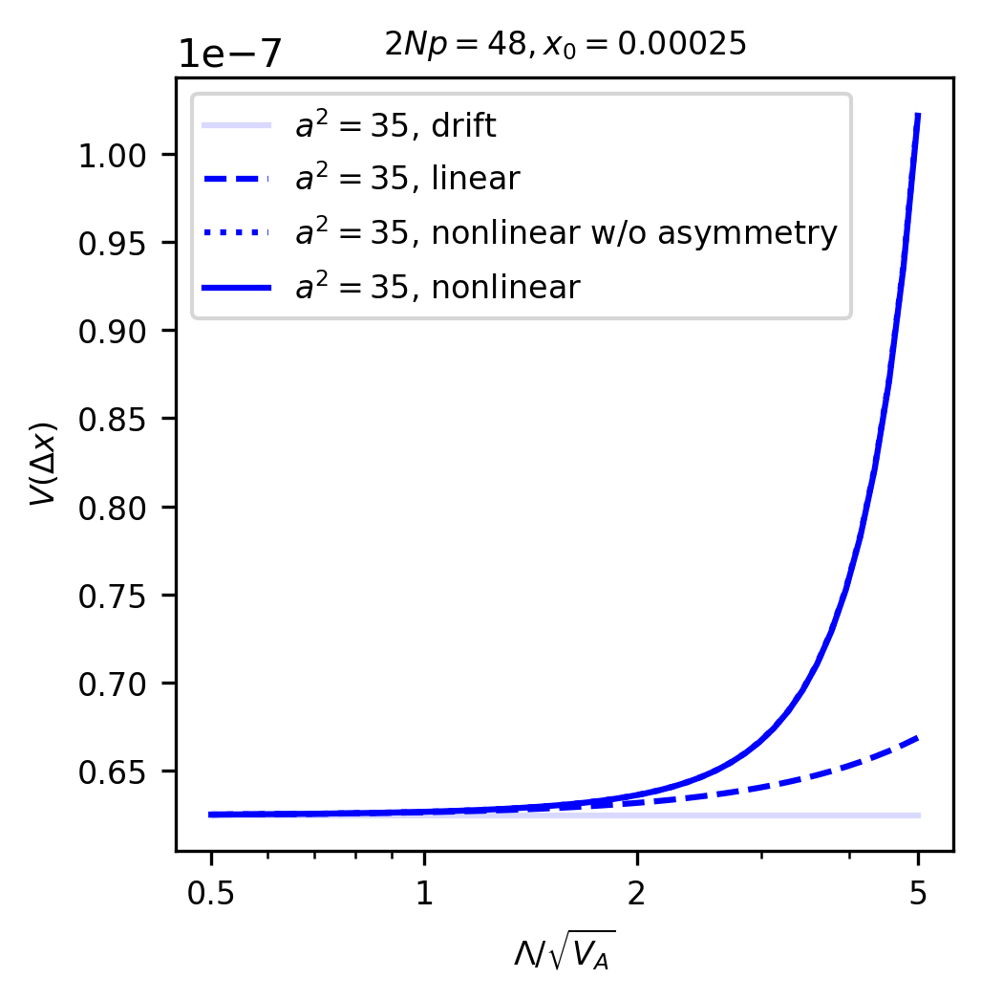

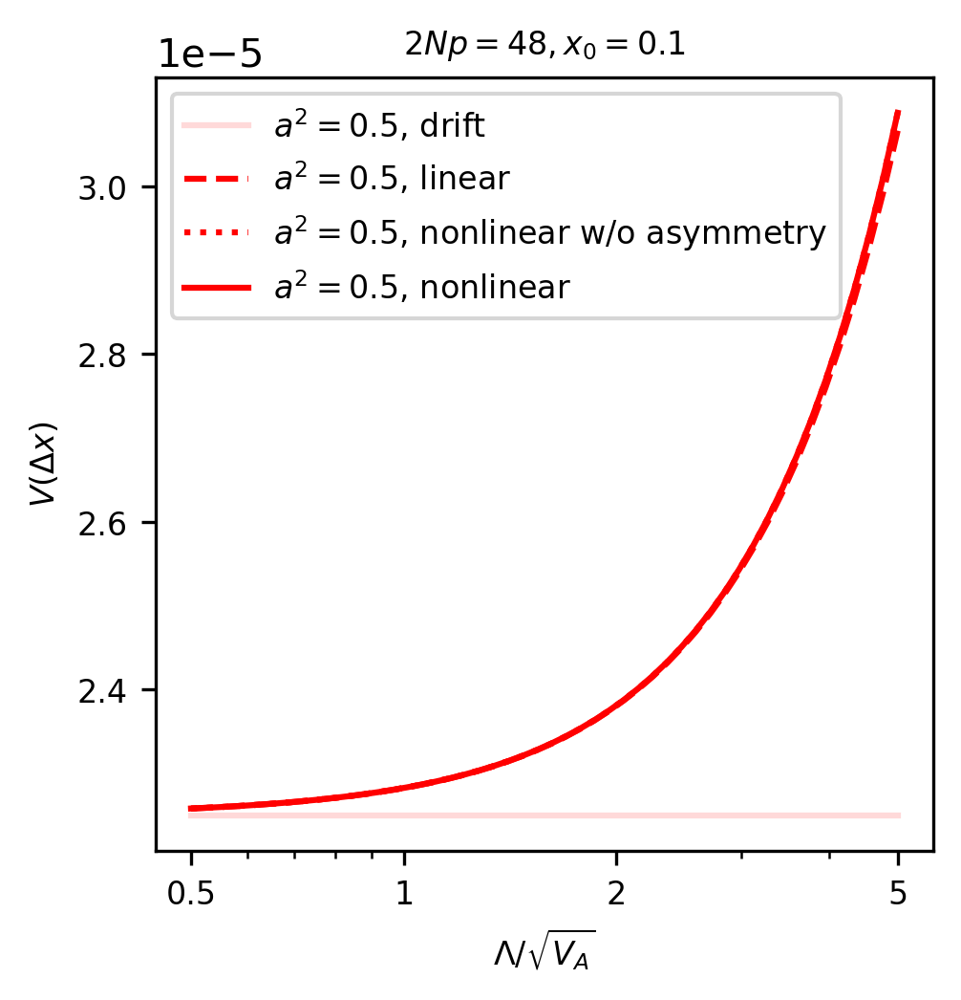

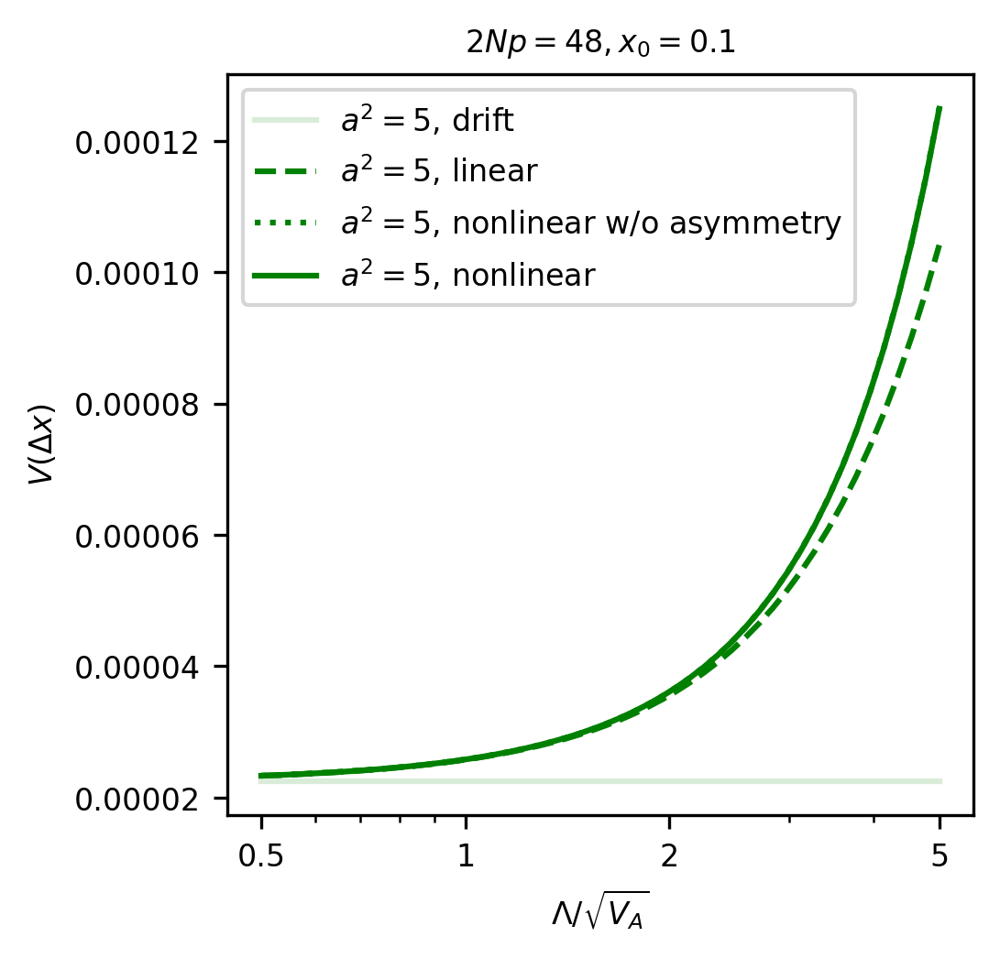

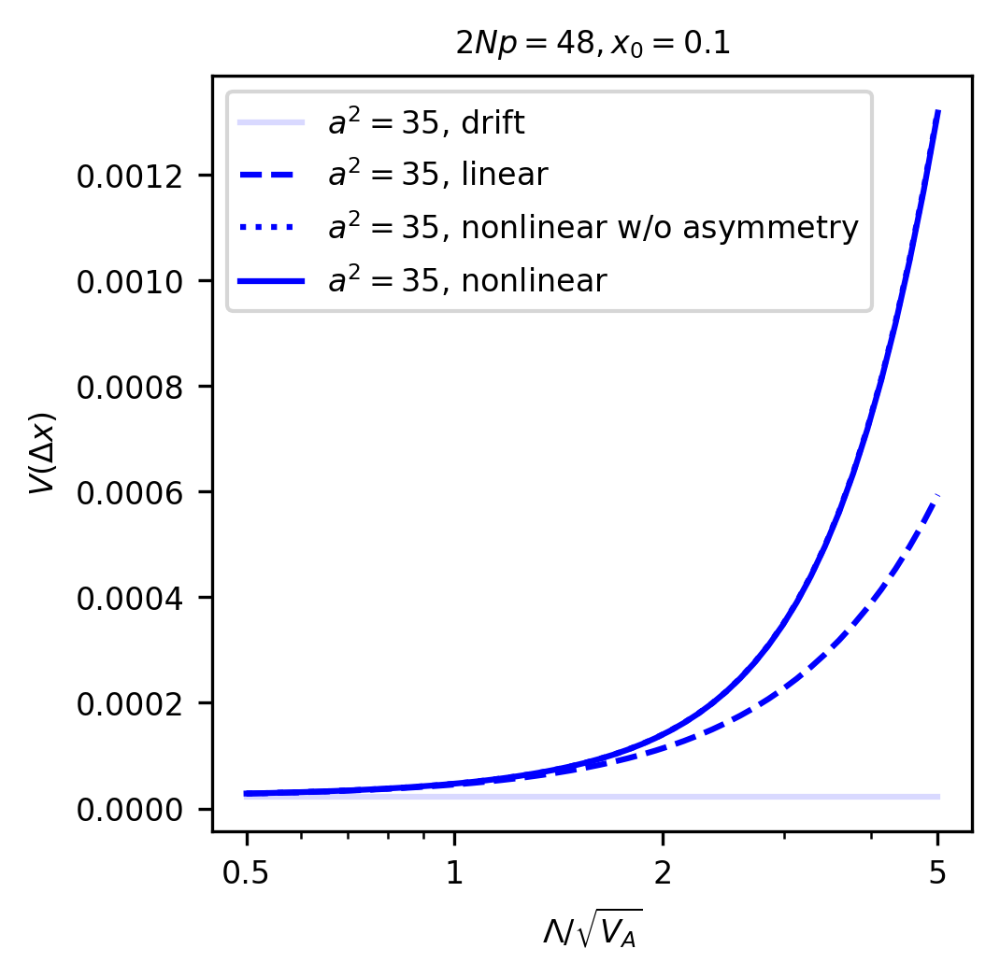

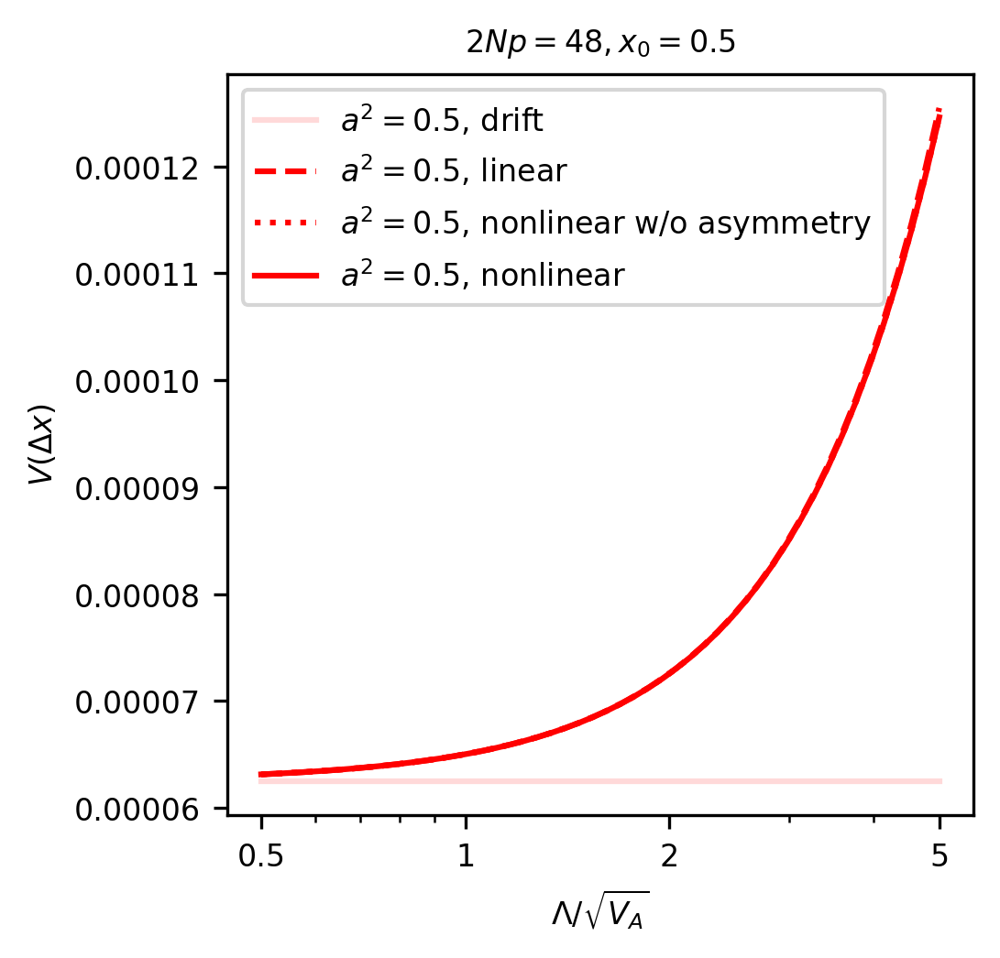

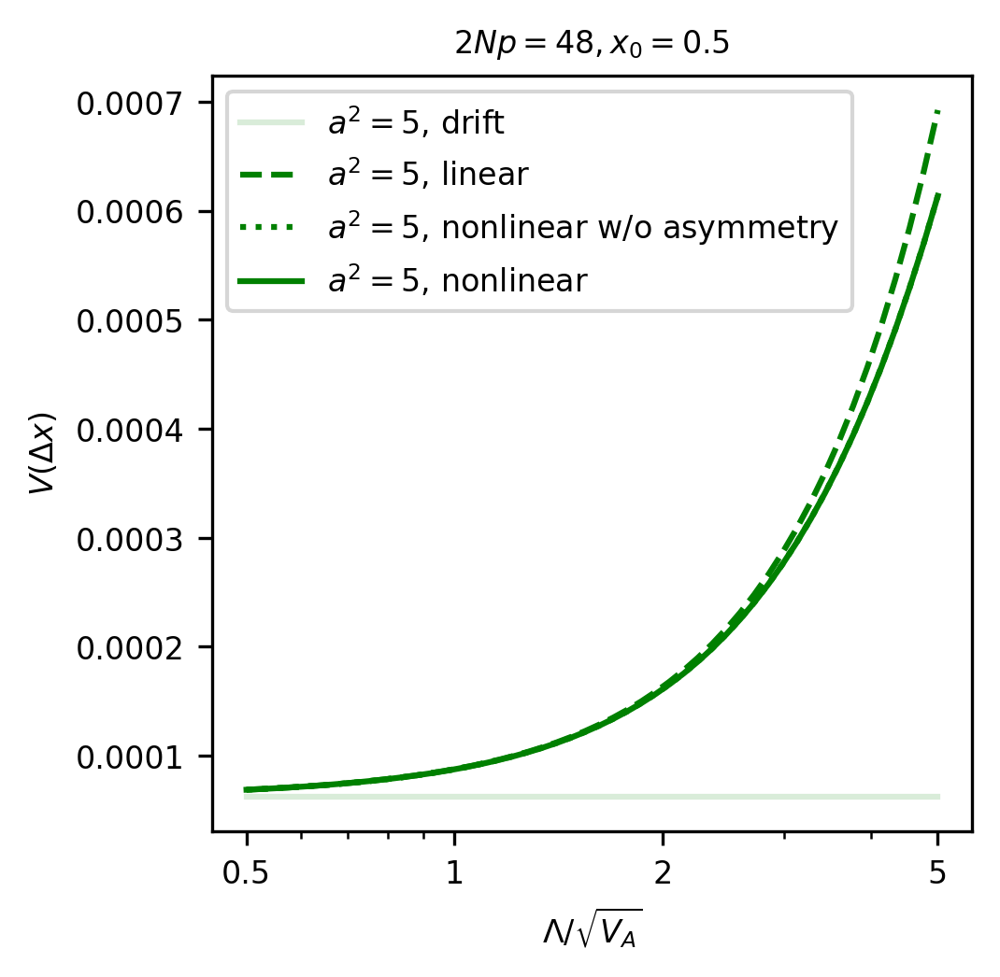

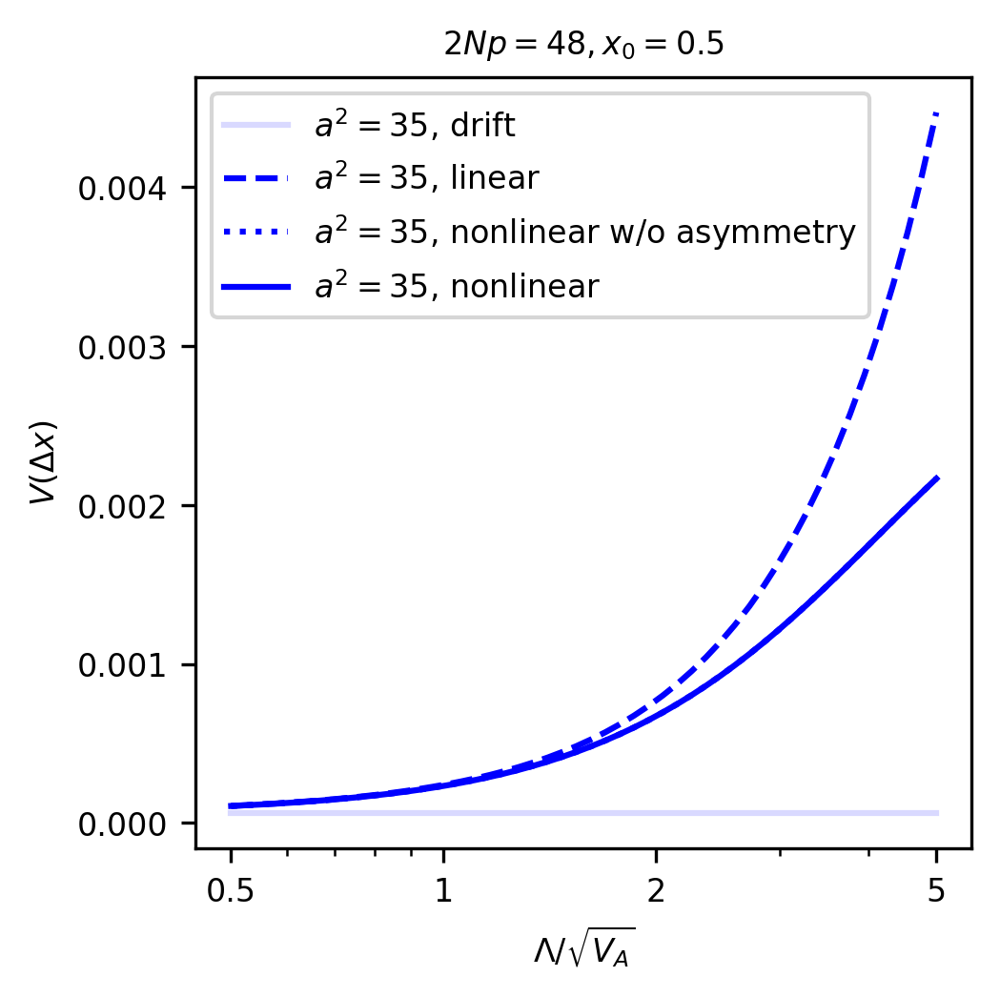

In [6]:
fontsize = 8

N = 2000
U = 0.025
E2Ns = 1

rate_of_shift = 0.012

for x in (1 / (2 * N), 0.1, 0.5):
    for ss, color in ((0.5, 'r'), (5, 'g'), (35, 'b')):
        fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
        ax = fig.add_subplot(1, 1, 1)
    
        ax.plot(np.geomspace(0.5, 5), [x * (1 - x) / (2 * N) for _ in np.geomspace(0.5, 5)], color=color, alpha=0.15, label=r'$a^2=%g$, drift' % ss)
        ax.plot(np.geomspace(0.5, 5), [V_Delta_x_drift_and_shifts(a=np.sqrt(ss), x=x, shift_s0=shift_s0, sigma_0_del=np.sqrt(V_A(E2Ns=E2Ns)), p=rate_of_shift) for shift_s0 in np.geomspace(0.5, 5)], color=color, linestyle='--', label=r'$a^2=%g$, linear' % ss)
        ax.plot(np.geomspace(0.5, 5), [V_Delta_x_drift_and_shifts_nonlinear_without_asymmetry(a=np.sqrt(ss), x=x, shift_s0=shift_s0, sigma_0_del=np.sqrt(V_A(E2Ns=E2Ns)), p=rate_of_shift) for shift_s0 in np.geomspace(0.5, 5)], color=color, linestyle=':', label=r'$a^2=%g$, nonlinear w/o asymmetry' % ss)
        ax.plot(np.geomspace(0.5, 5), [V_Delta_x_drift_and_shifts_nonlinear(a=np.sqrt(ss), x=x, shift_s0=shift_s0, sigma_0_del=np.sqrt(V_A(E2Ns=E2Ns)), p=rate_of_shift) for shift_s0 in np.geomspace(0.5, 5)], color=color, label=r'$a^2=%g$, nonlinear' % ss)
    
        ax.set_xscale('log')
        plt.xlabel(r'$\Lambda / \sqrt{V_A}$', fontsize=fontsize)
        plt.ylabel(r'$V(\Delta x)$', fontsize=fontsize)
        plt.xticks(ticks=[0.5, 1, 2, 5], labels=[0.5, 1, 2, 5], fontsize=fontsize)
        plt.yticks(fontsize=fontsize)
        plt.legend(fontsize=fontsize)
        plt.title(r'$2Np=%g, x_0=%g$' % (2 * N * rate_of_shift, x), fontsize=fontsize)
        plt.show()

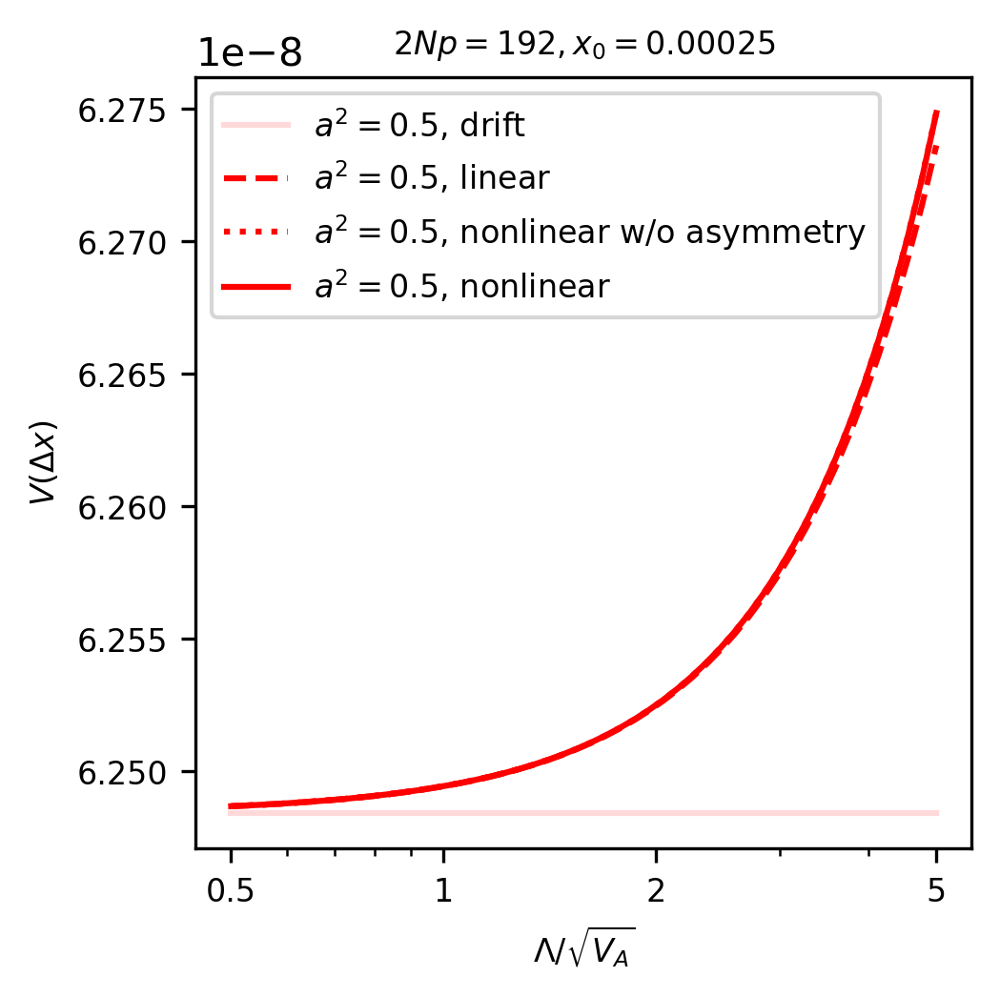

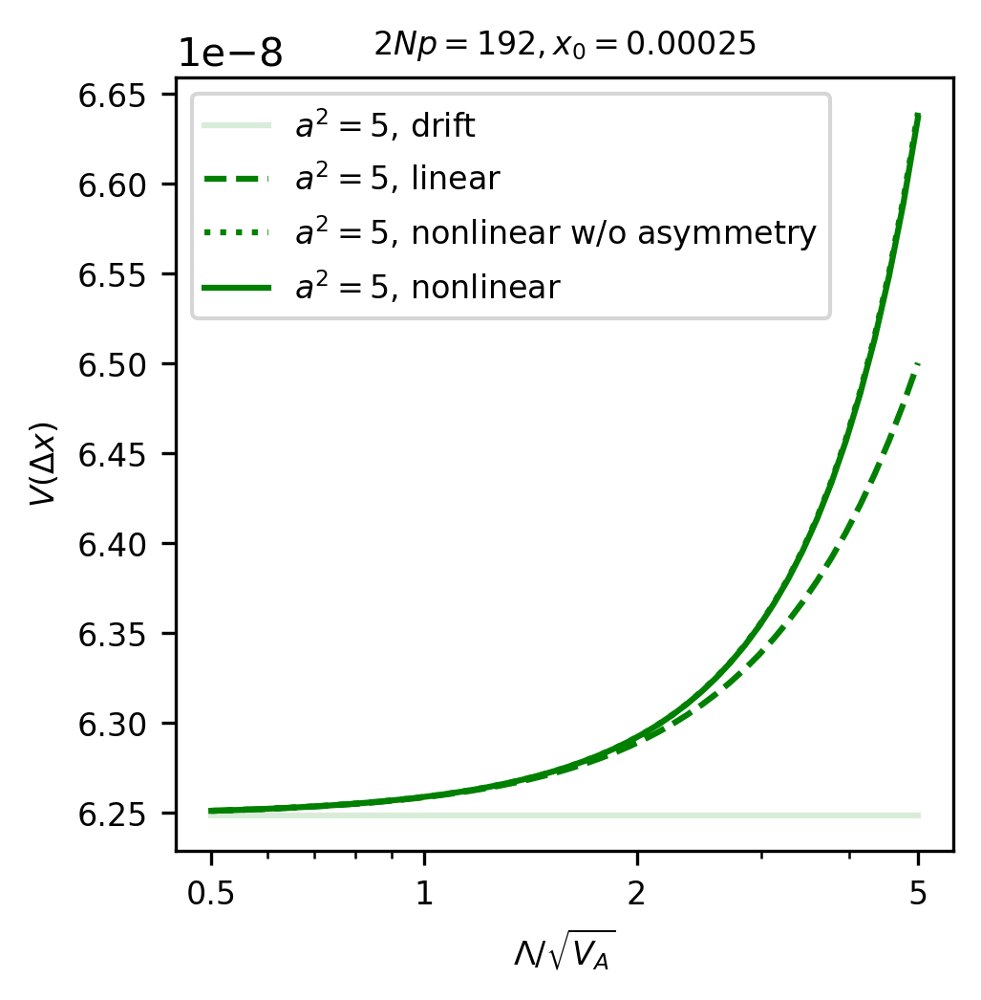

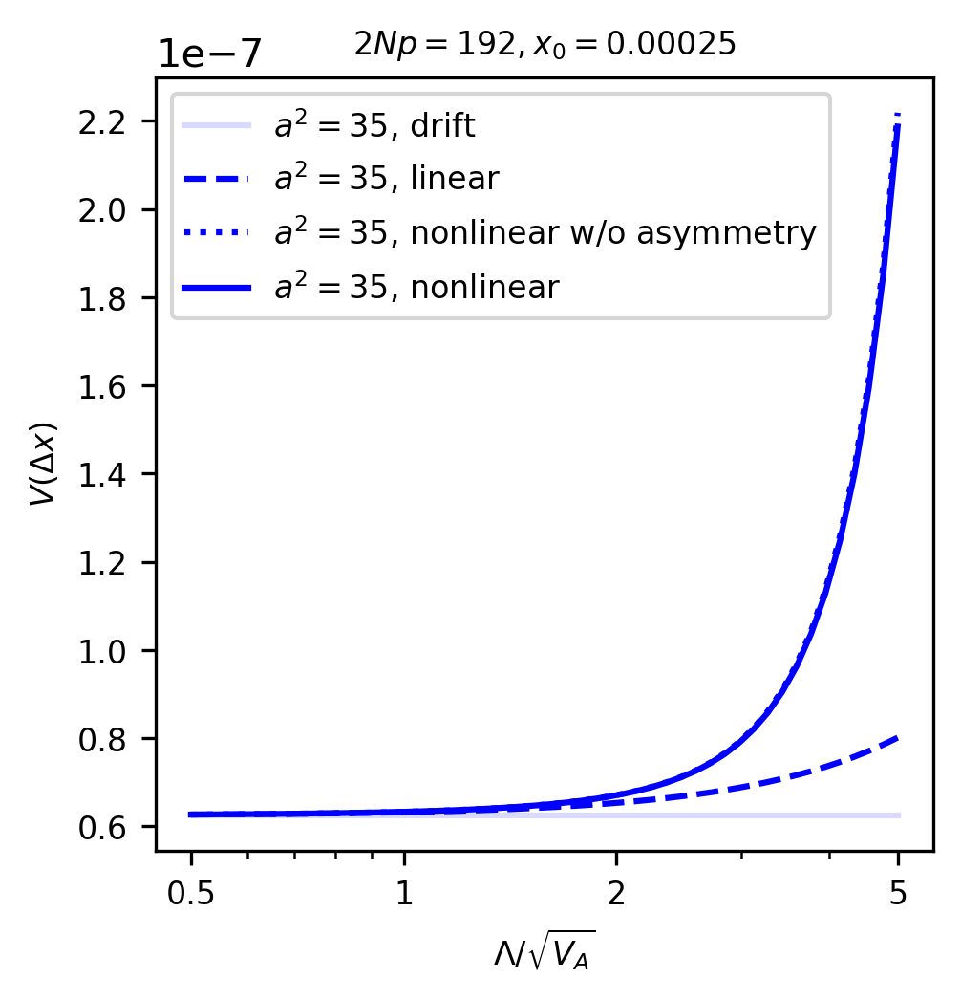

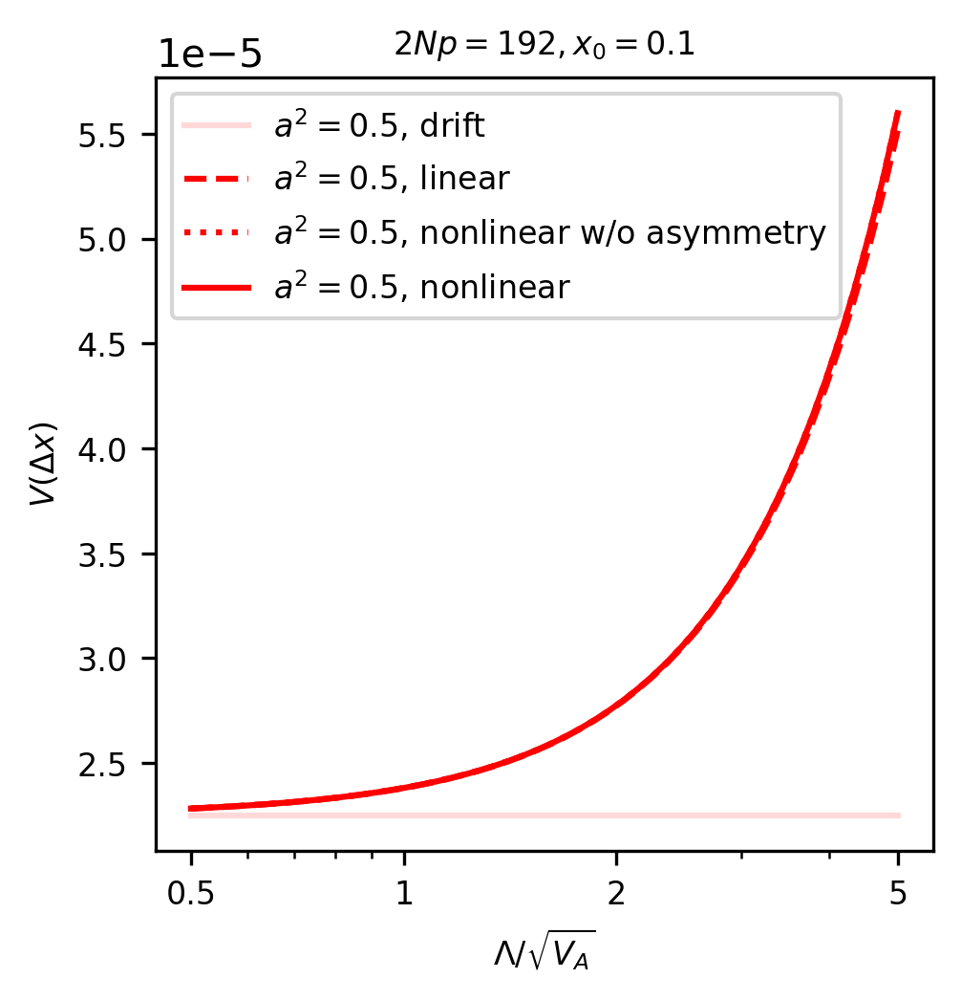

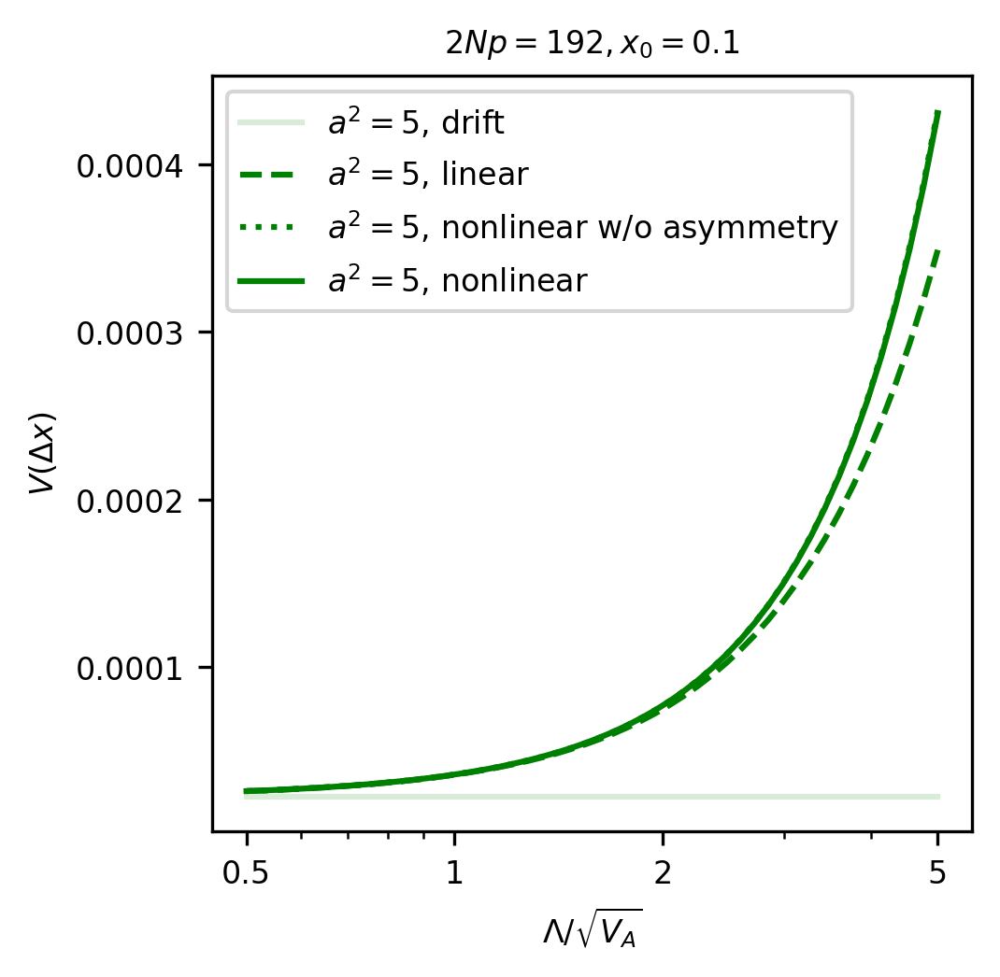

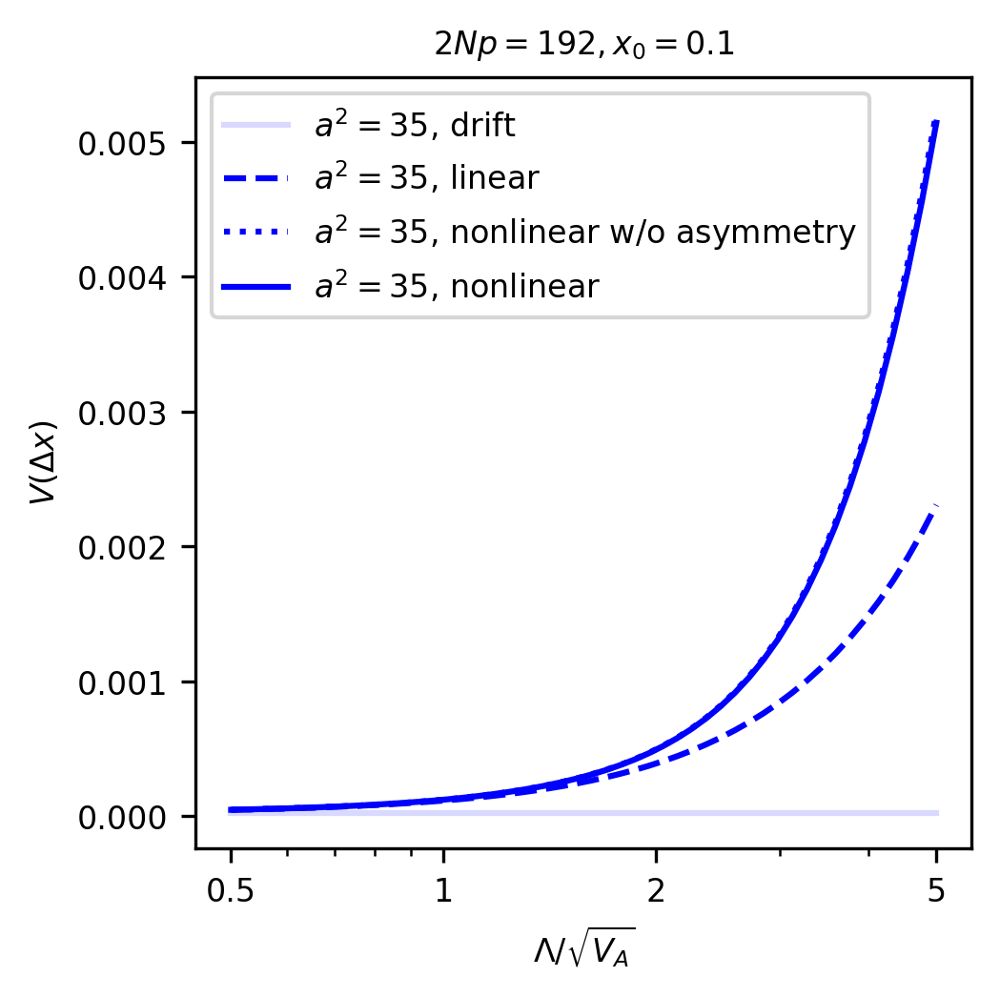

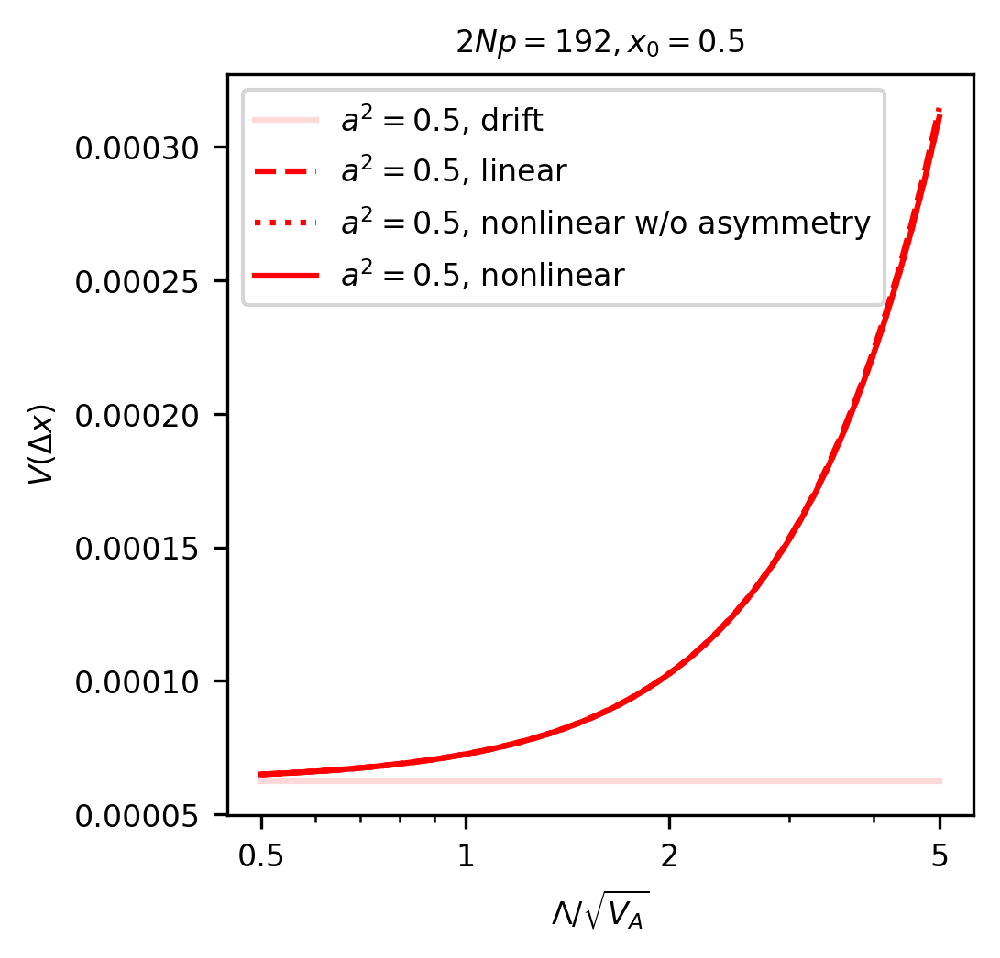

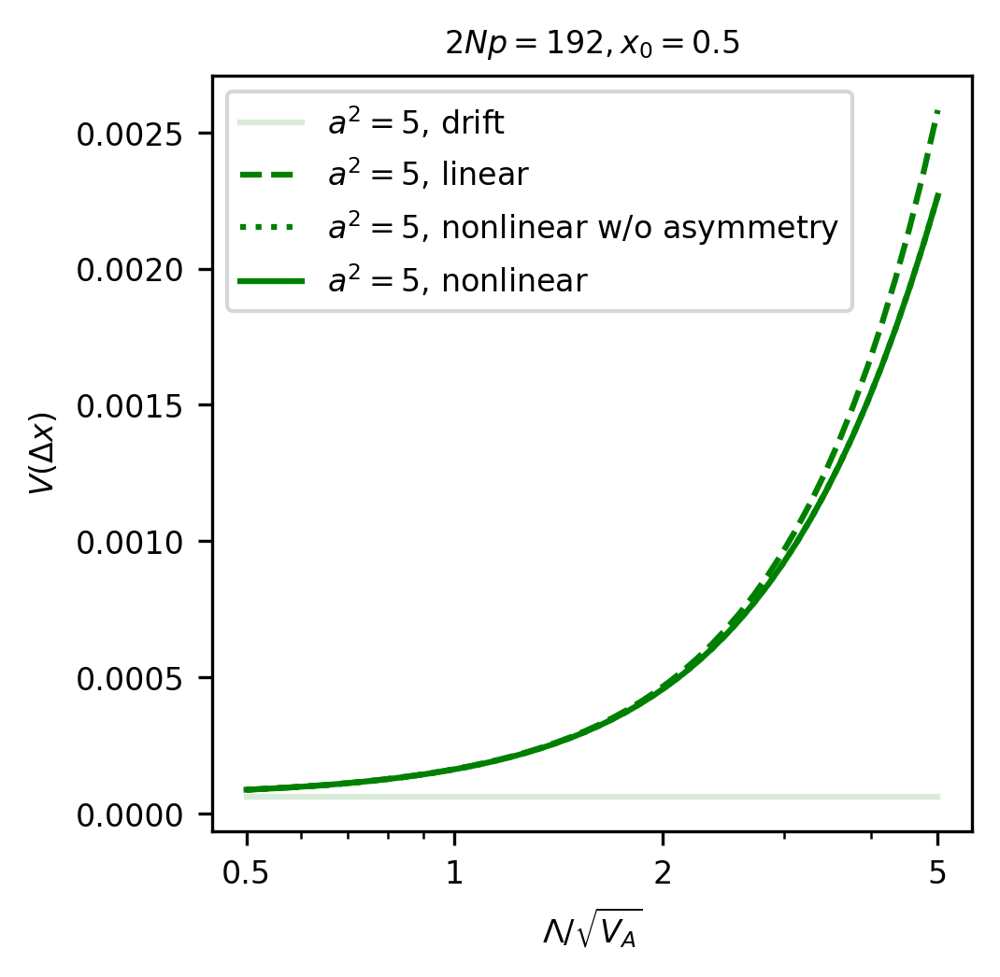

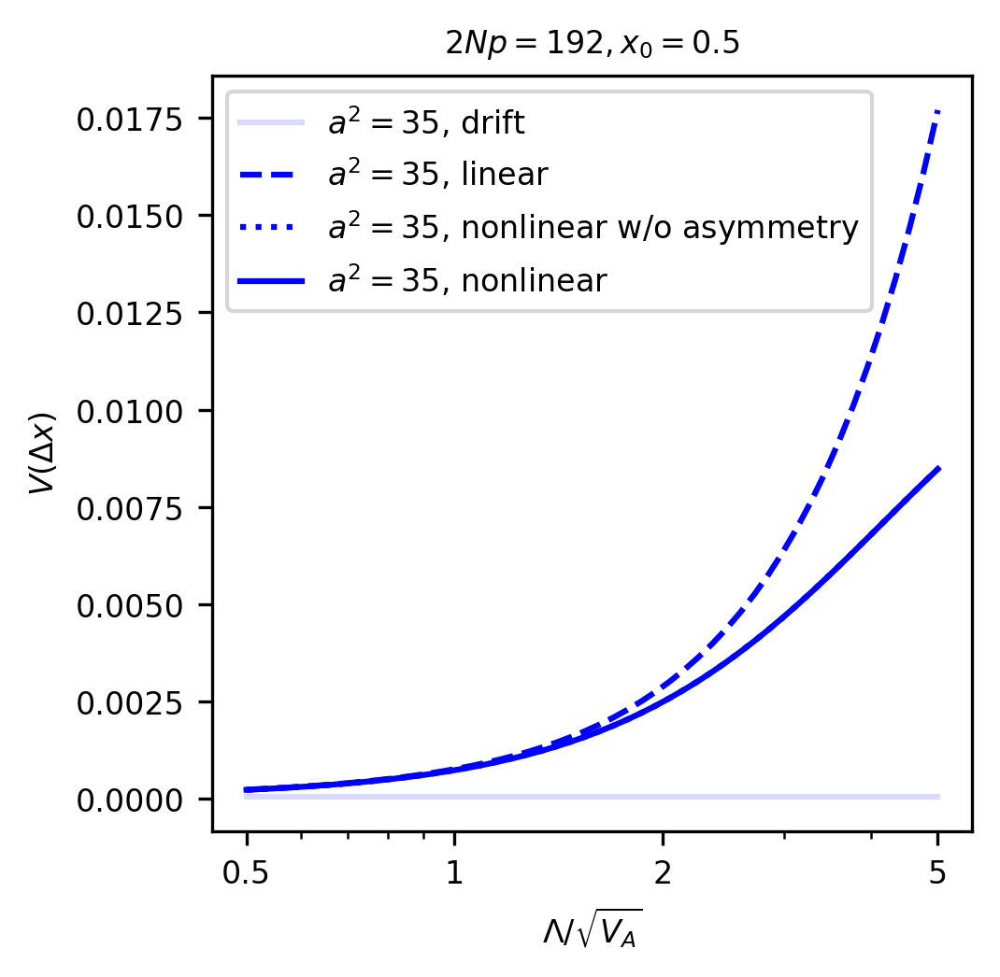

In [7]:
fontsize = 8

N = 2000
U = 0.025
E2Ns = 1

rate_of_shift = 0.048

for x in (1 / (2 * N), 0.1, 0.5):
    for ss, color in ((0.5, 'r'), (5, 'g'), (35, 'b')):
        fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
        ax = fig.add_subplot(1, 1, 1)
    
        ax.plot(np.geomspace(0.5, 5), [x * (1 - x) / (2 * N) for _ in np.geomspace(0.5, 5)], color=color, alpha=0.15, label=r'$a^2=%g$, drift' % ss)
        ax.plot(np.geomspace(0.5, 5), [V_Delta_x_drift_and_shifts(a=np.sqrt(ss), x=x, shift_s0=shift_s0, sigma_0_del=np.sqrt(V_A(E2Ns=E2Ns)), p=rate_of_shift) for shift_s0 in np.geomspace(0.5, 5)], color=color, linestyle='--', label=r'$a^2=%g$, linear' % ss)
        ax.plot(np.geomspace(0.5, 5), [V_Delta_x_drift_and_shifts_nonlinear_without_asymmetry(a=np.sqrt(ss), x=x, shift_s0=shift_s0, sigma_0_del=np.sqrt(V_A(E2Ns=E2Ns)), p=rate_of_shift) for shift_s0 in np.geomspace(0.5, 5)], color=color, linestyle=':', label=r'$a^2=%g$, nonlinear w/o asymmetry' % ss)
        ax.plot(np.geomspace(0.5, 5), [V_Delta_x_drift_and_shifts_nonlinear(a=np.sqrt(ss), x=x, shift_s0=shift_s0, sigma_0_del=np.sqrt(V_A(E2Ns=E2Ns)), p=rate_of_shift) for shift_s0 in np.geomspace(0.5, 5)], color=color, label=r'$a^2=%g$, nonlinear' % ss)
    
        ax.set_xscale('log')
        plt.xlabel(r'$\Lambda / \sqrt{V_A}$', fontsize=fontsize)
        plt.ylabel(r'$V(\Delta x)$', fontsize=fontsize)
        plt.xticks(ticks=[0.5, 1, 2, 5], labels=[0.5, 1, 2, 5], fontsize=fontsize)
        plt.yticks(fontsize=fontsize)
        plt.legend(fontsize=fontsize)
        plt.title(r'$2Np=%g, x_0=%g$' % (2 * N * rate_of_shift, x), fontsize=fontsize)
        plt.show()

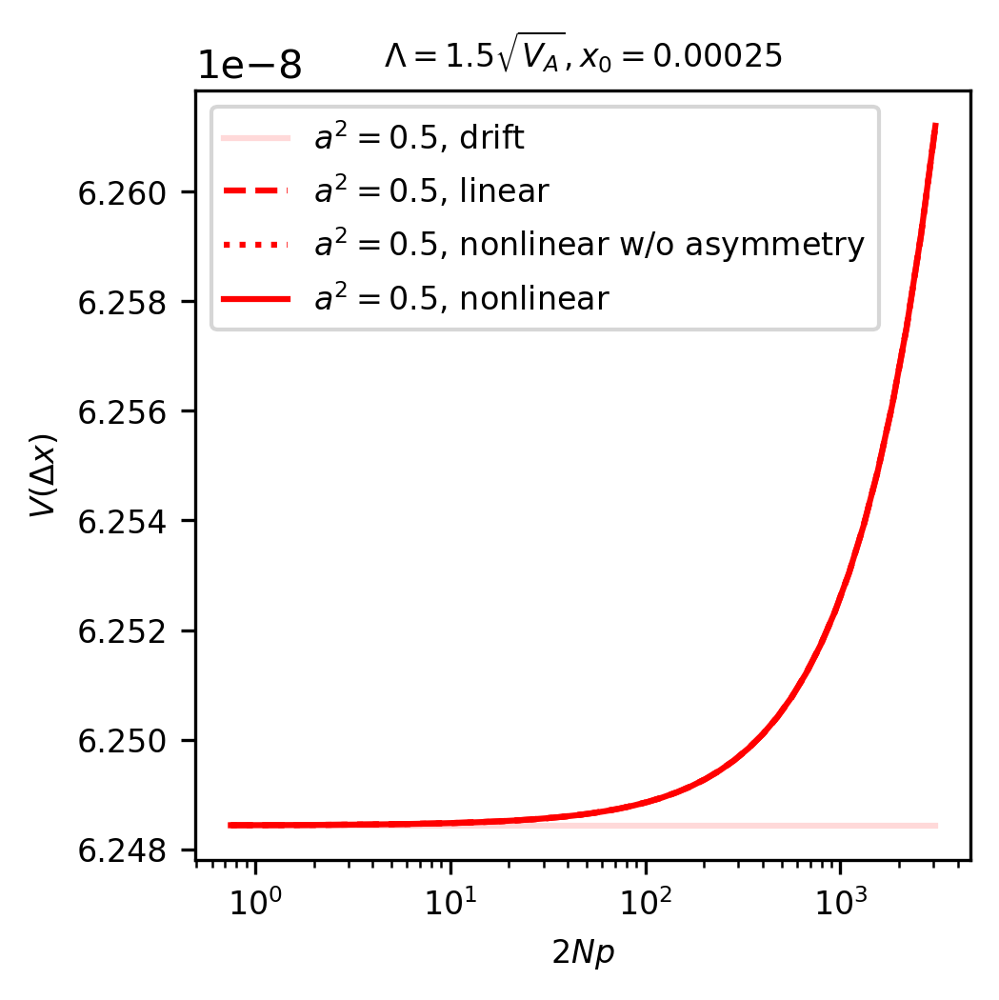

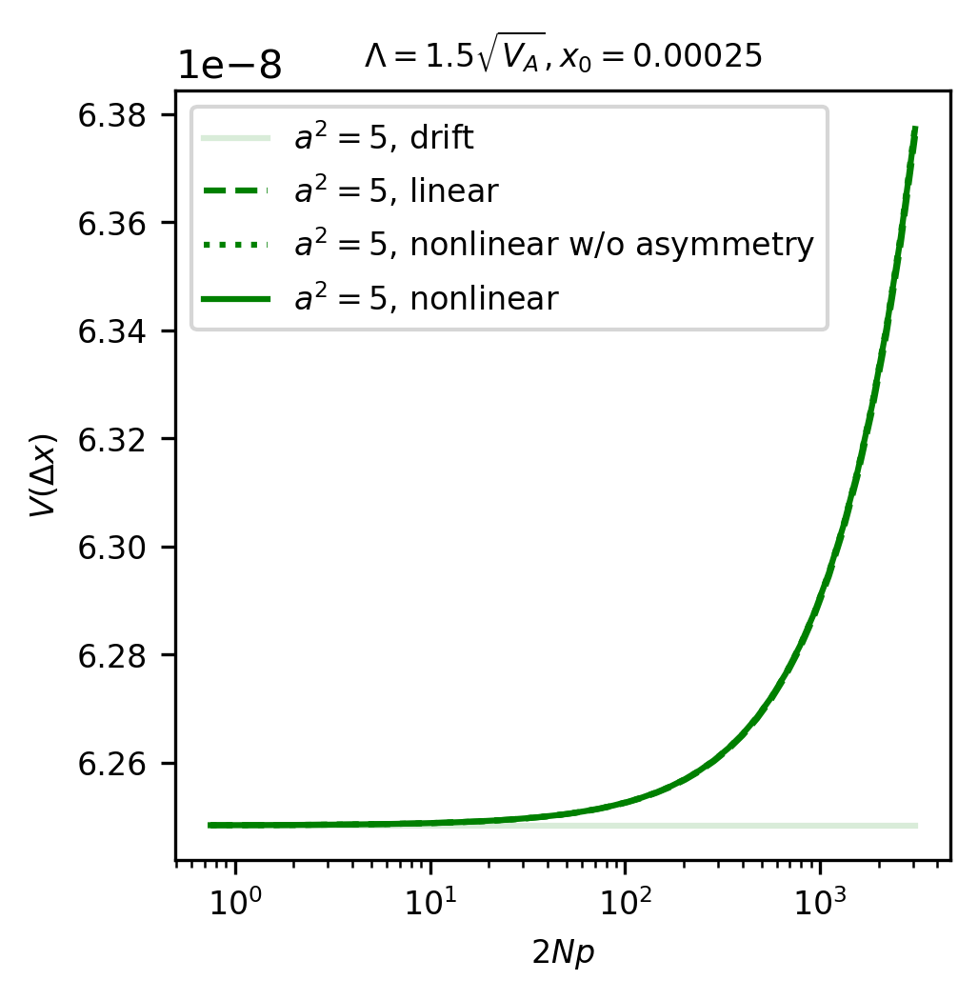

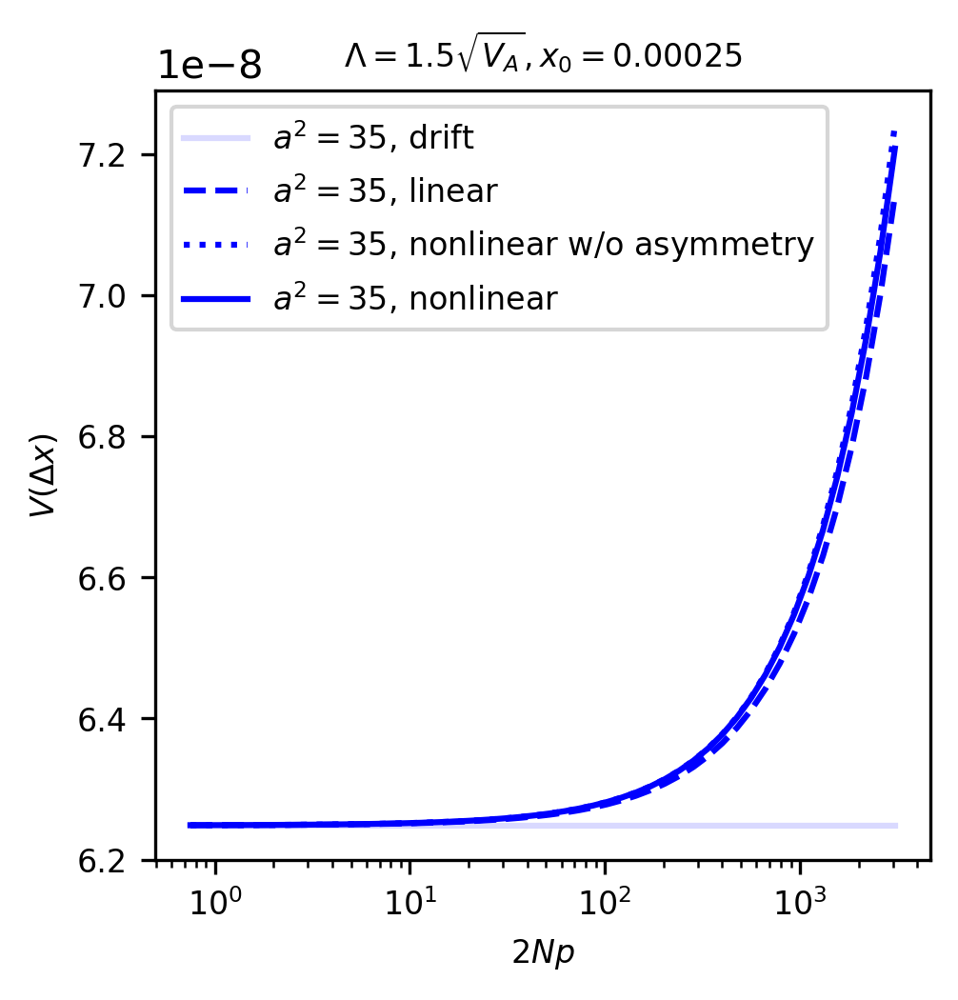

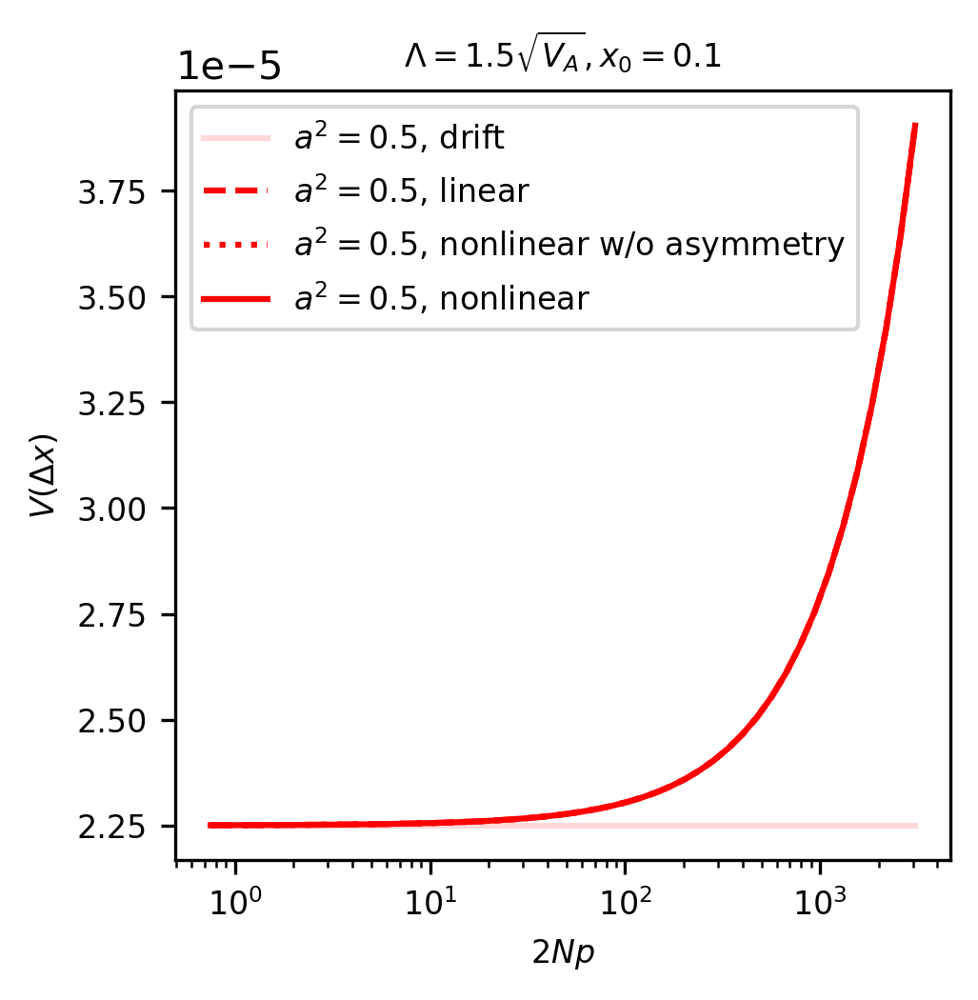

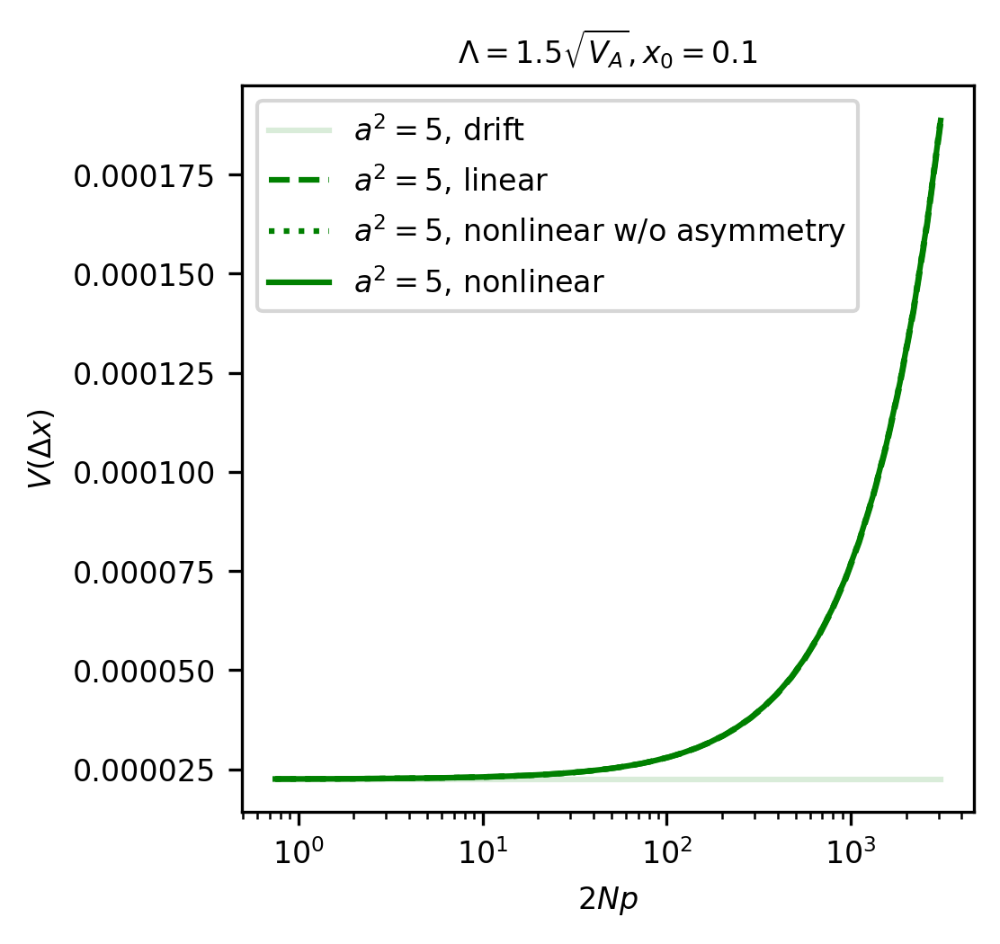

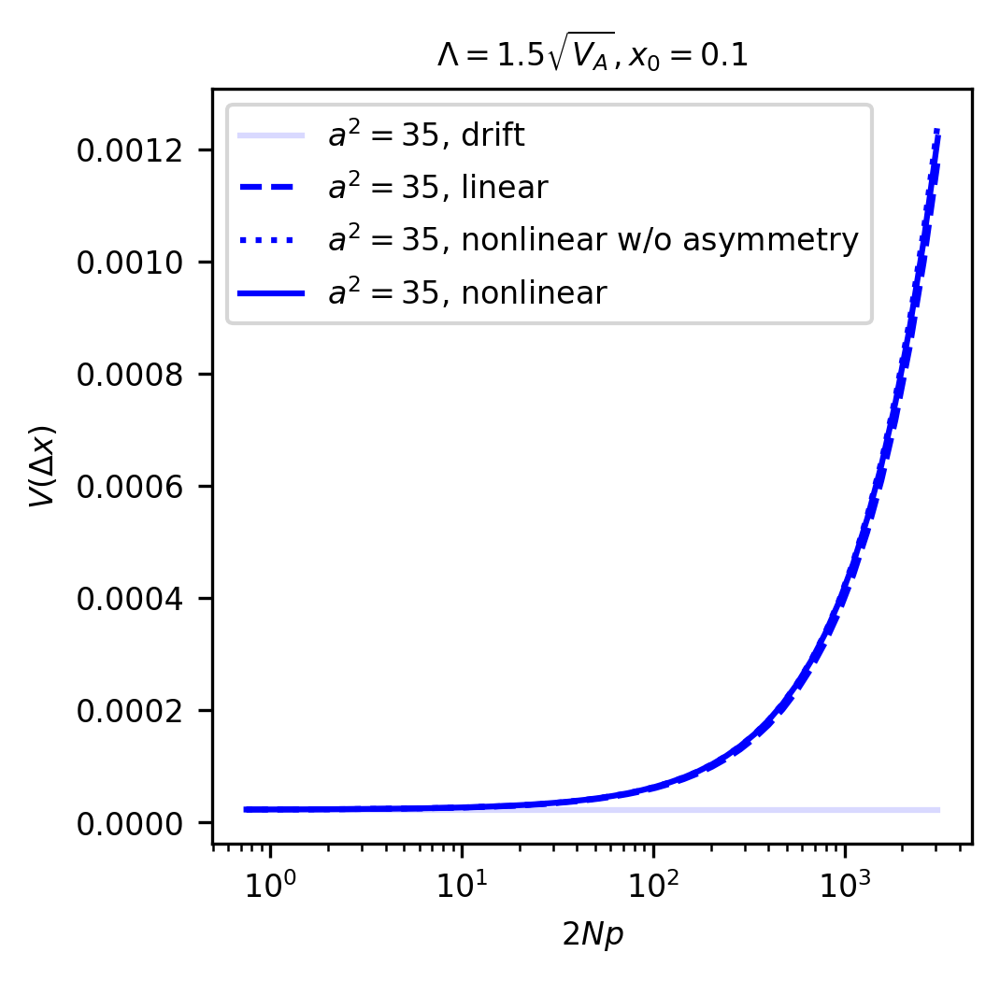

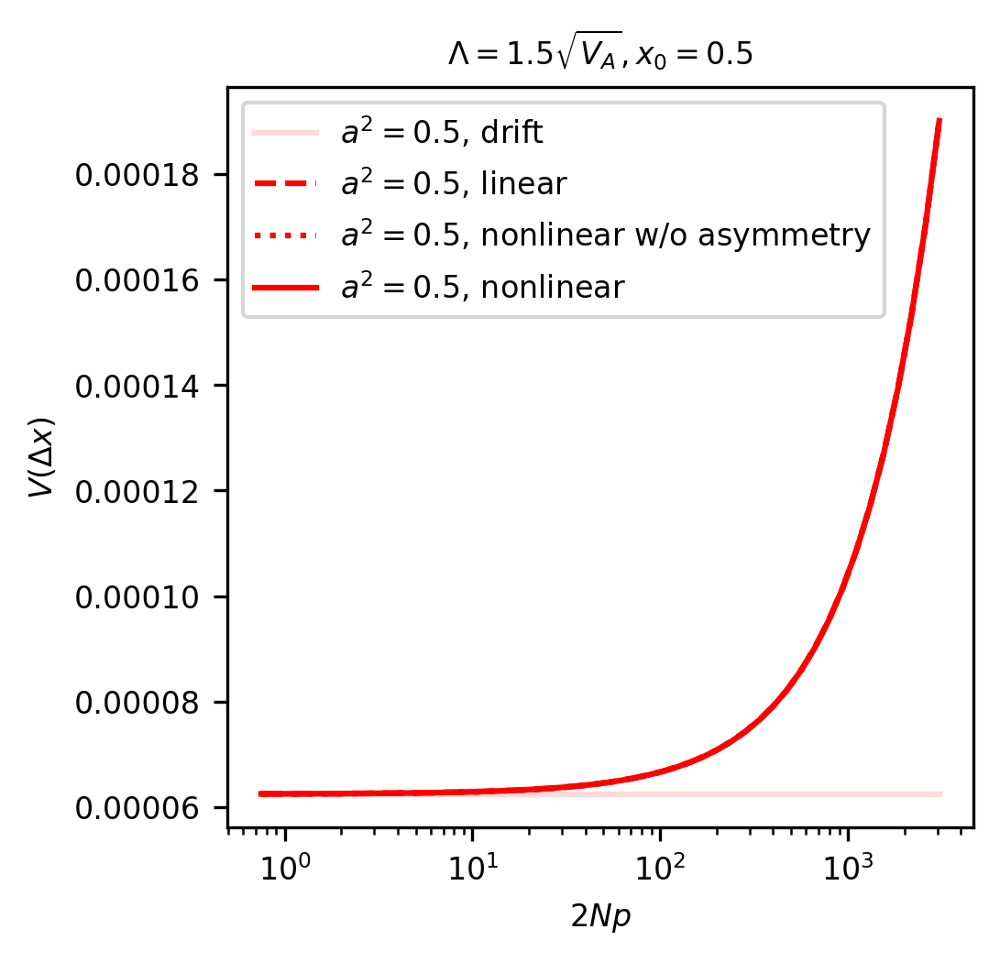

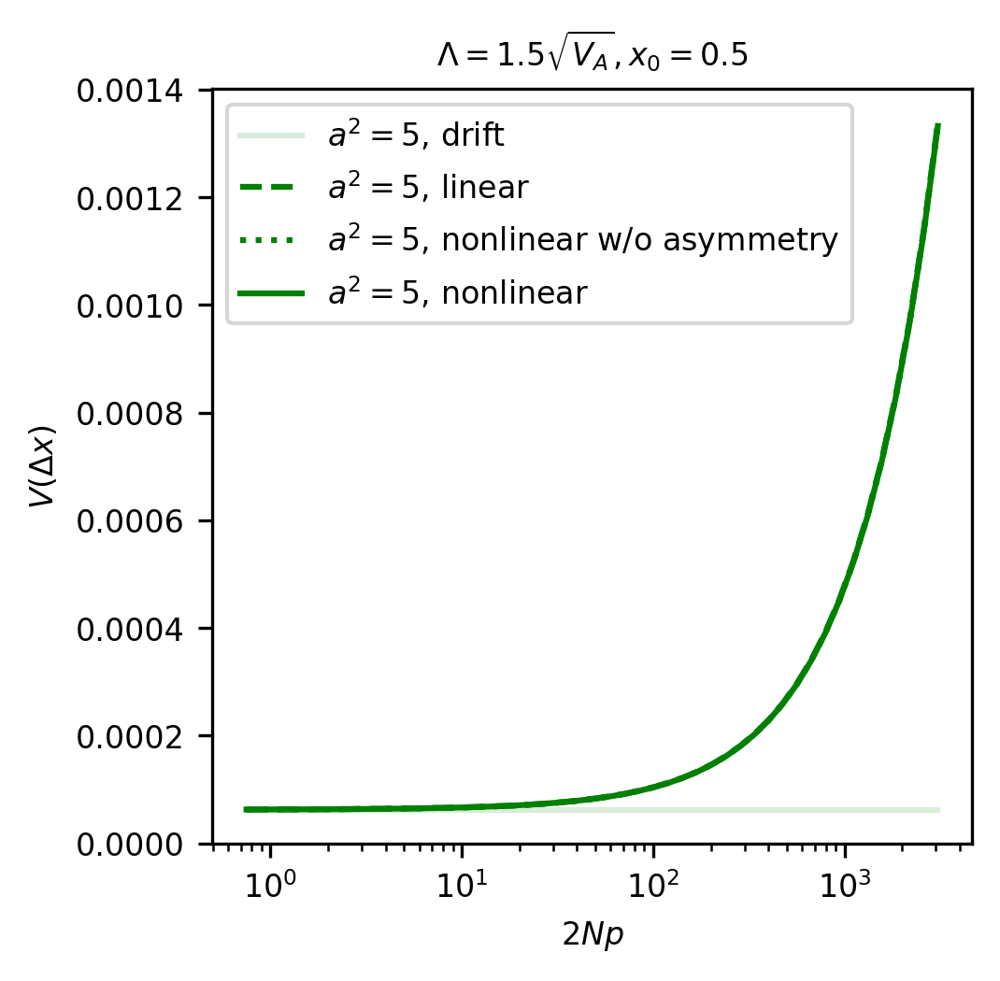

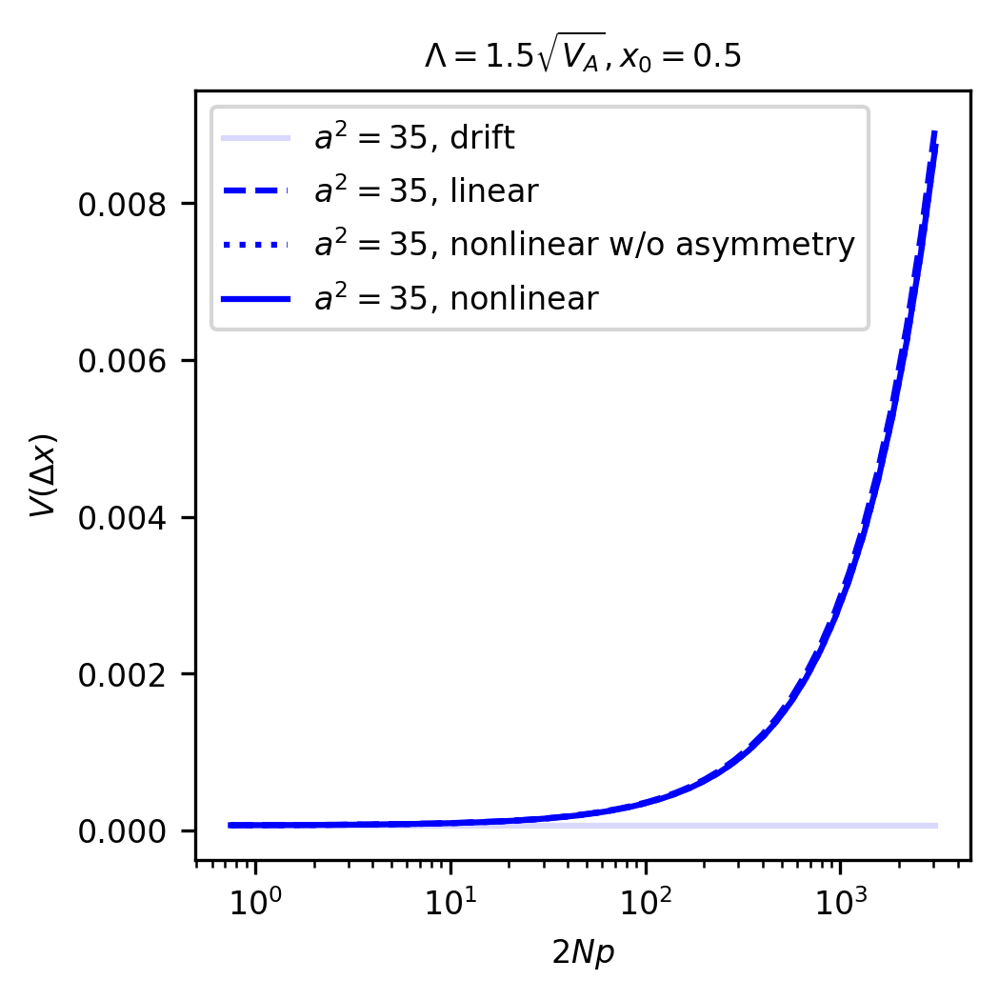

In [8]:
# the variance of change in allele frequency, in the non-Lande case
fontsize = 8

N = 2000
U = 0.025
E2Ns = 16

shift_s0 = 1.5

for x in (1 / (2 * N), 0.1, 0.5):
    for ss, color in ((0.5, 'r'), (5, 'g'), (35, 'b')):
        fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
        ax = fig.add_subplot(1, 1, 1)
    
        ax.plot(2 * N * np.geomspace(0.0001875, 0.768), [x * (1 - x) / (2 * N) for _ in np.geomspace(0.0001875, 0.768)], color=color, alpha=0.15, label=r'$a^2=%g$, drift' % ss)
        ax.plot(2 * N * np.geomspace(0.0001875, 0.768), [V_Delta_x_drift_and_shifts(a=np.sqrt(ss), x=x, shift_s0=shift_s0, sigma_0_del=np.sqrt(V_A(E2Ns=E2Ns)), p=rate_of_shift) for rate_of_shift in np.geomspace(0.0001875, 0.768)], color=color, linestyle='--', label=r'$a^2=%g$, linear' % ss)
        ax.plot(2 * N * np.geomspace(0.0001875, 0.768), [V_Delta_x_drift_and_shifts_nonlinear_without_asymmetry(a=np.sqrt(ss), x=x, shift_s0=shift_s0, sigma_0_del=np.sqrt(V_A(E2Ns=E2Ns)), p=rate_of_shift) for rate_of_shift in np.geomspace(0.0001875, 0.768)], color=color, linestyle=':', label=r'$a^2=%g$, nonlinear w/o asymmetry' % ss)
        ax.plot(2 * N * np.geomspace(0.0001875, 0.768), [V_Delta_x_drift_and_shifts_nonlinear(a=np.sqrt(ss), x=x, shift_s0=shift_s0, sigma_0_del=np.sqrt(V_A(E2Ns=E2Ns)), p=rate_of_shift) for rate_of_shift in np.geomspace(0.0001875, 0.768)], color=color, label=r'$a^2=%g$, nonlinear' % ss)
    
        ax.set_xscale('log')
        plt.xlabel(r'$2Np$', fontsize=fontsize)
        plt.ylabel(r'$V(\Delta x)$', fontsize=fontsize)
        plt.xticks(fontsize=fontsize)
        plt.yticks(fontsize=fontsize)
        plt.legend(fontsize=fontsize)
        plt.title(r'$\Lambda=%g\sqrt{V_A}, x_0=%g$' % (shift_s0, x), fontsize=fontsize)
        plt.show()

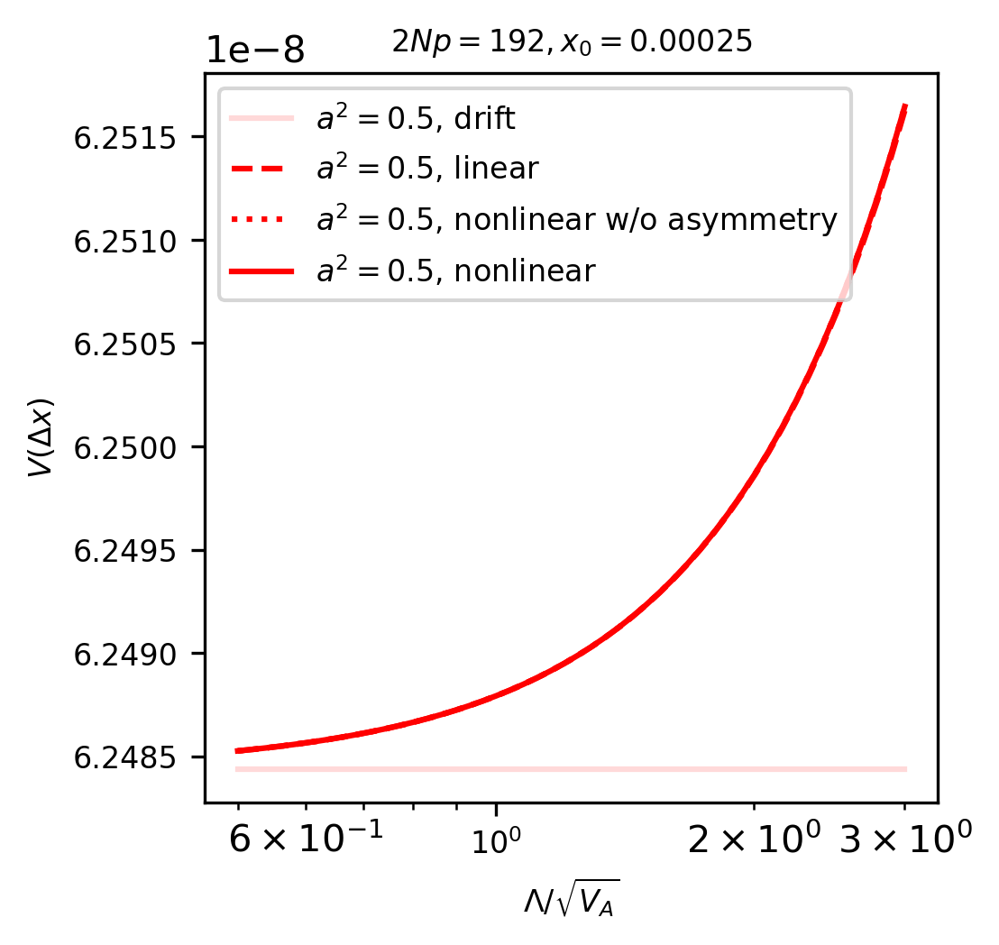

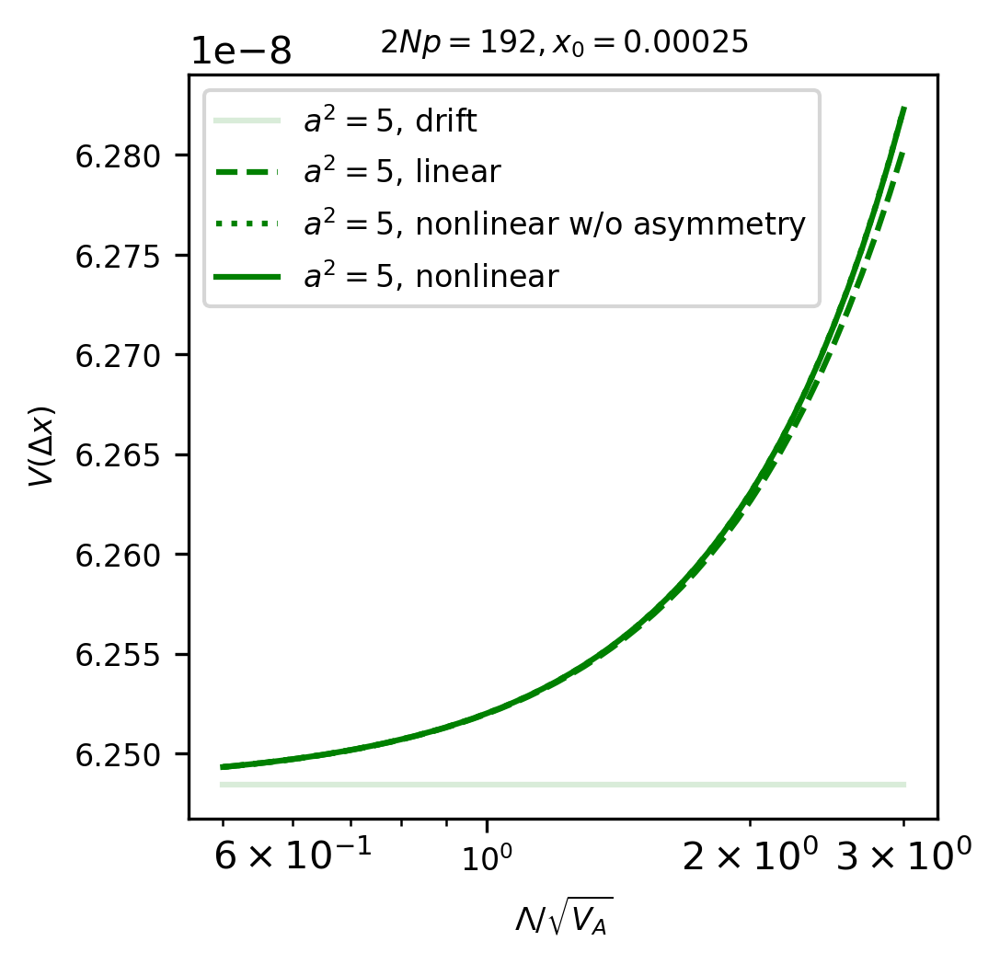

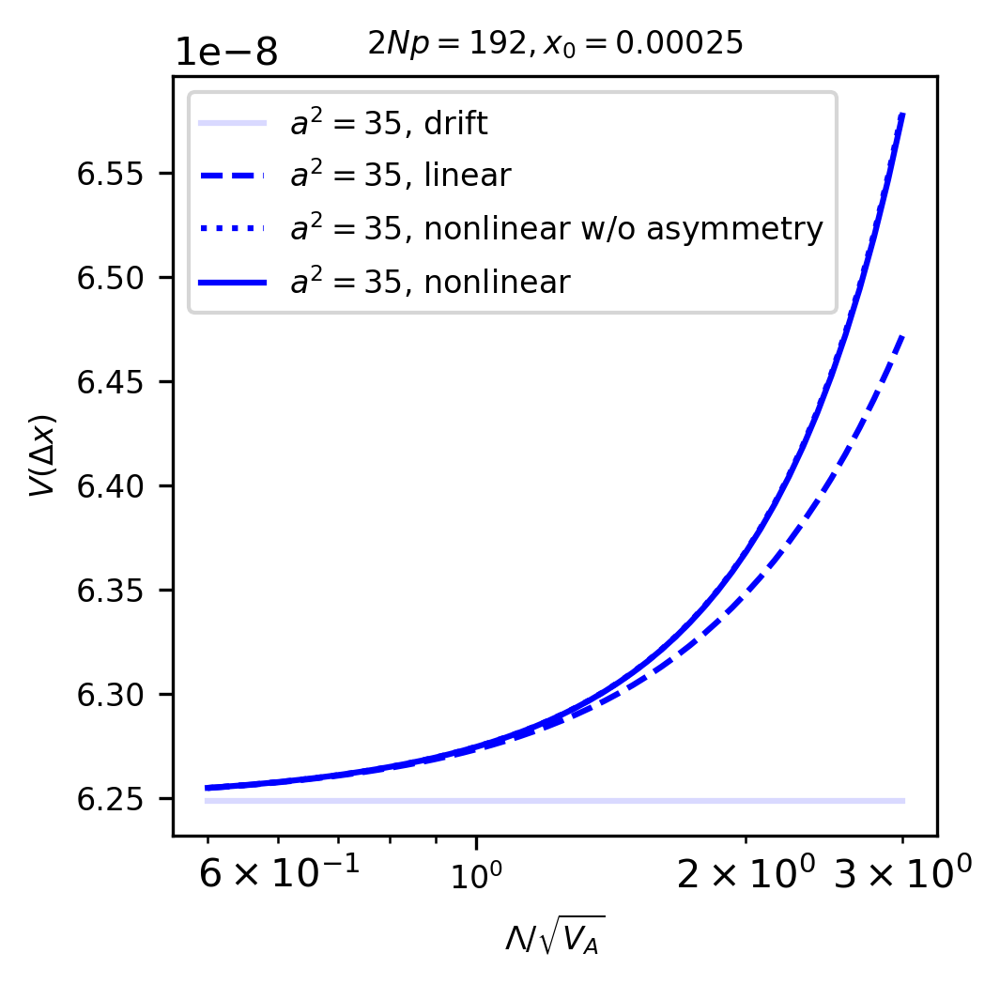

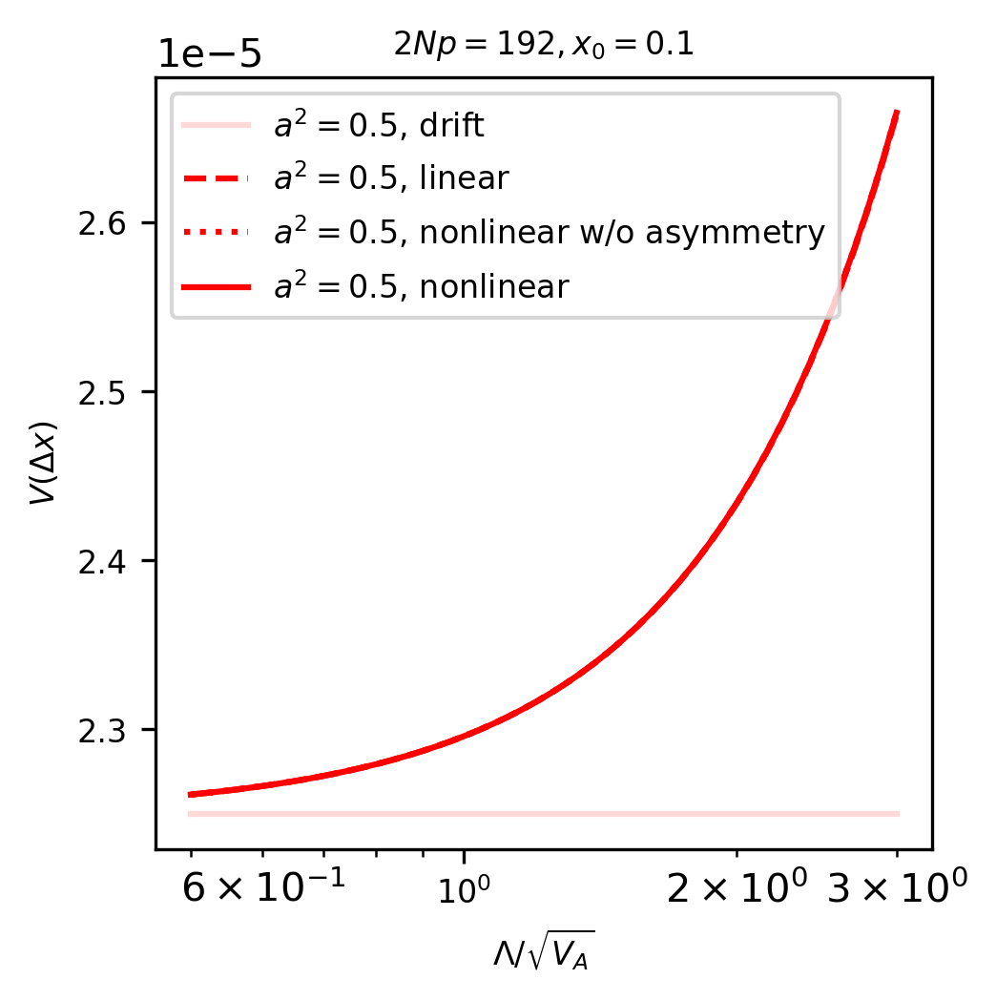

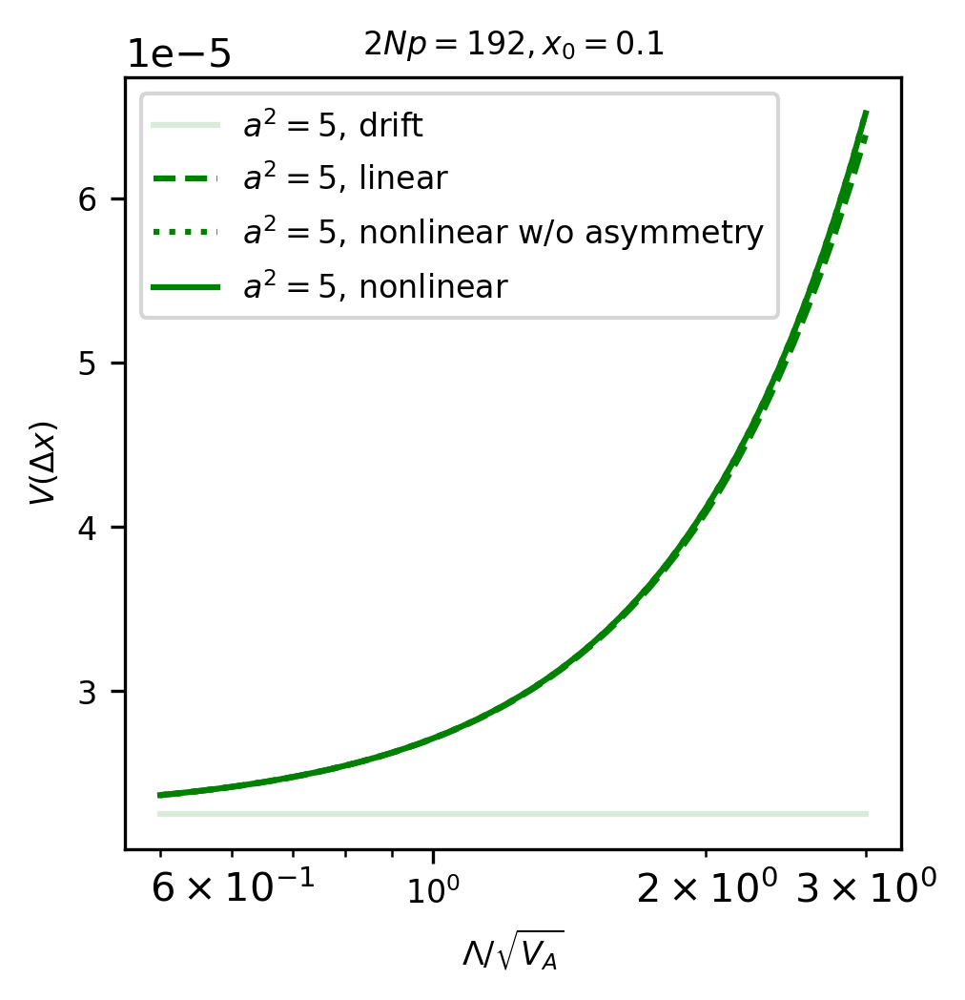

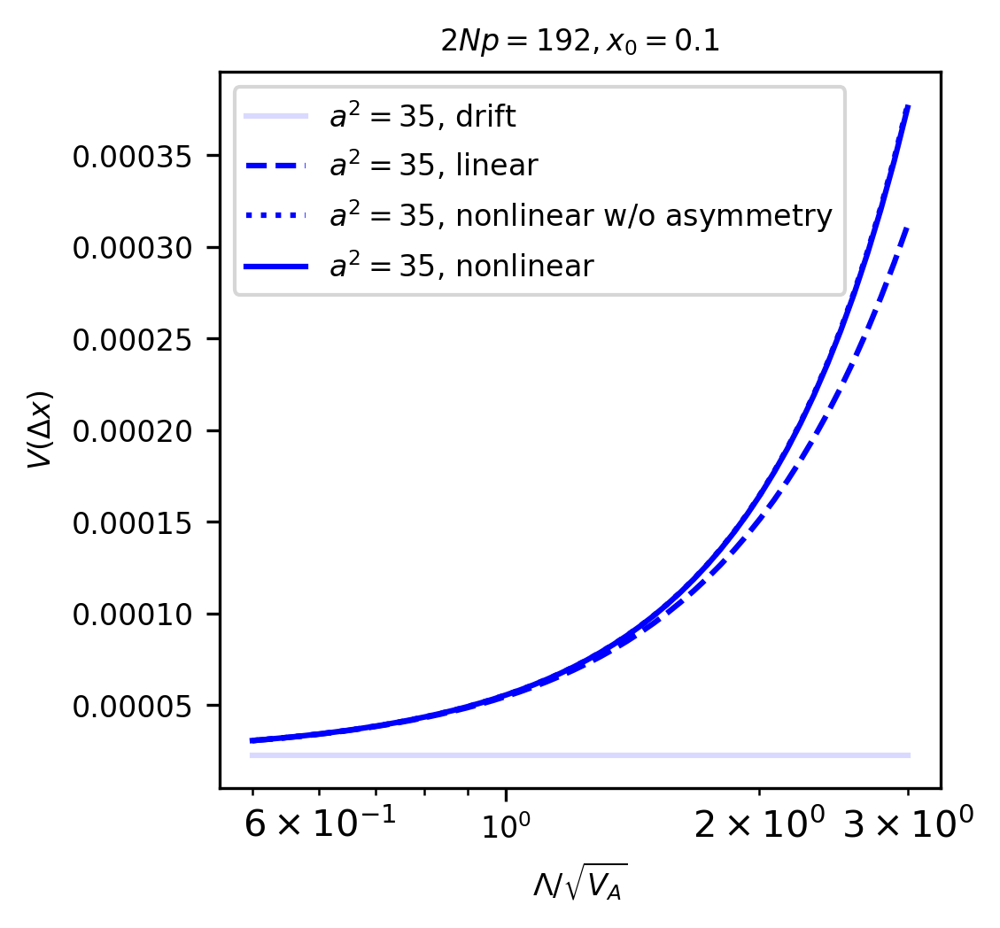

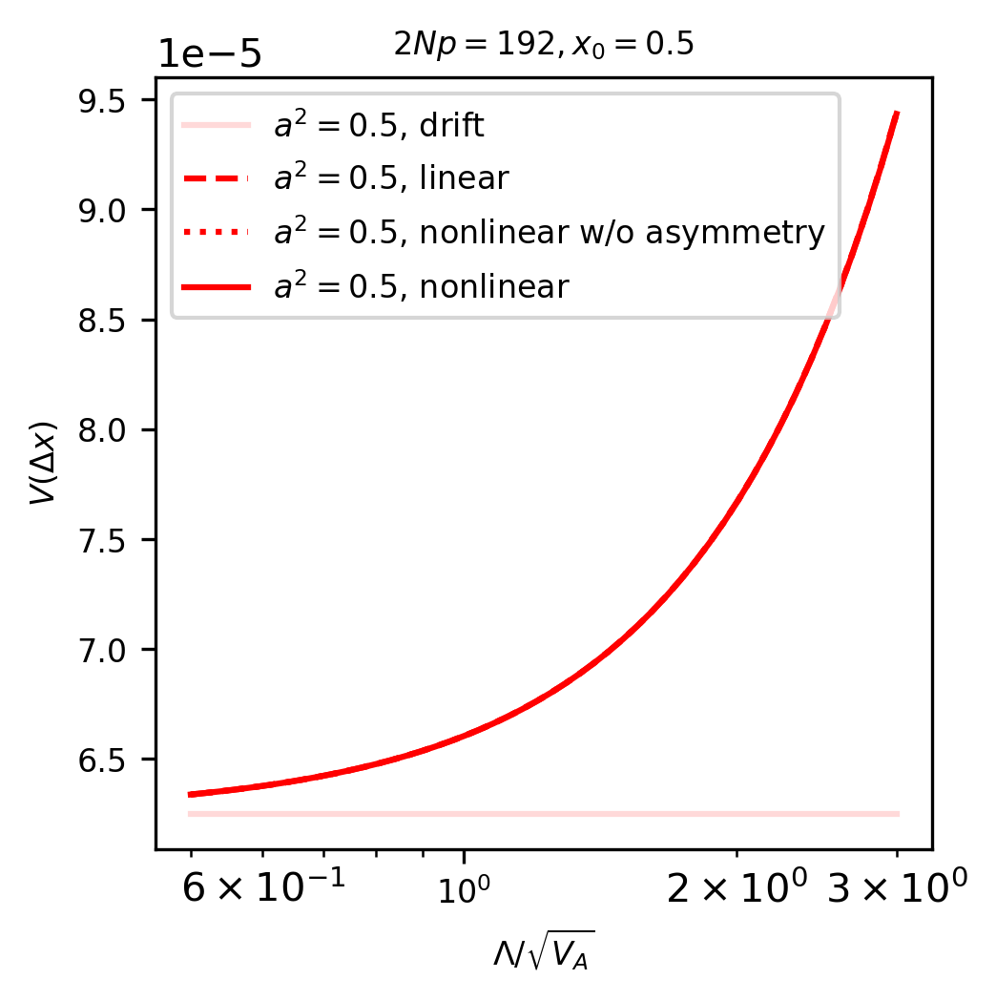

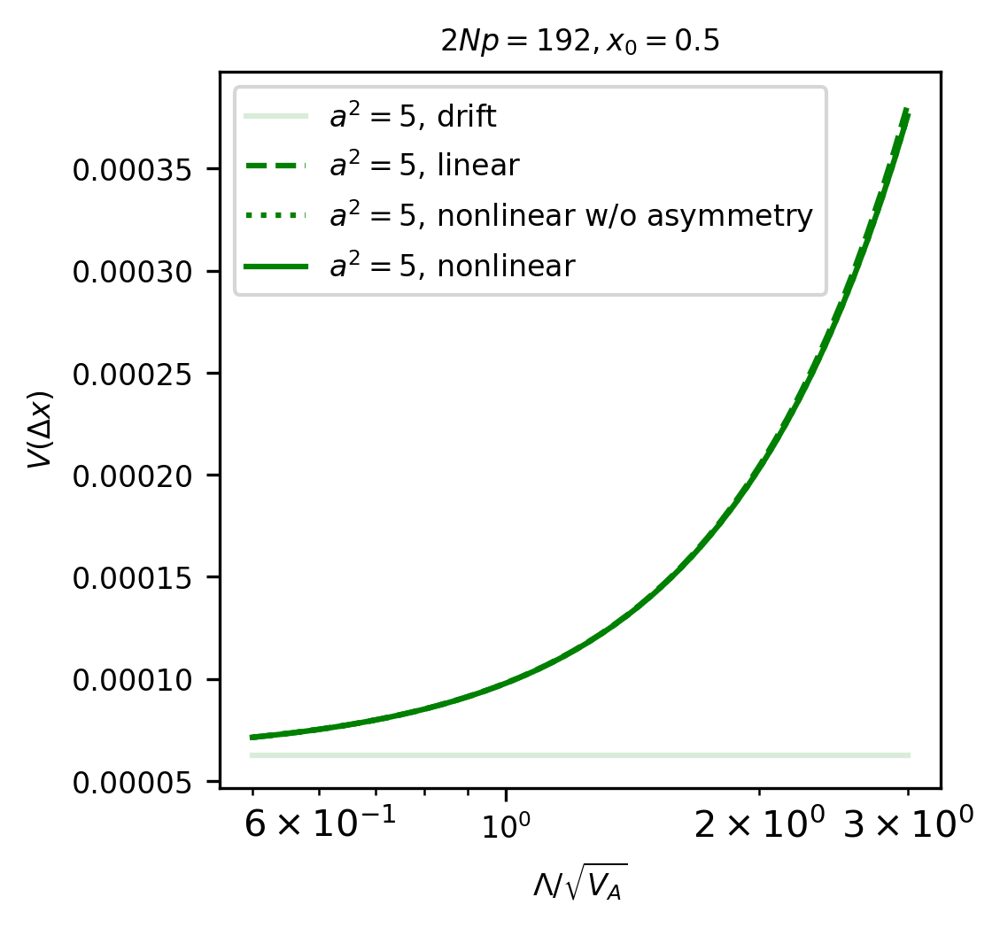

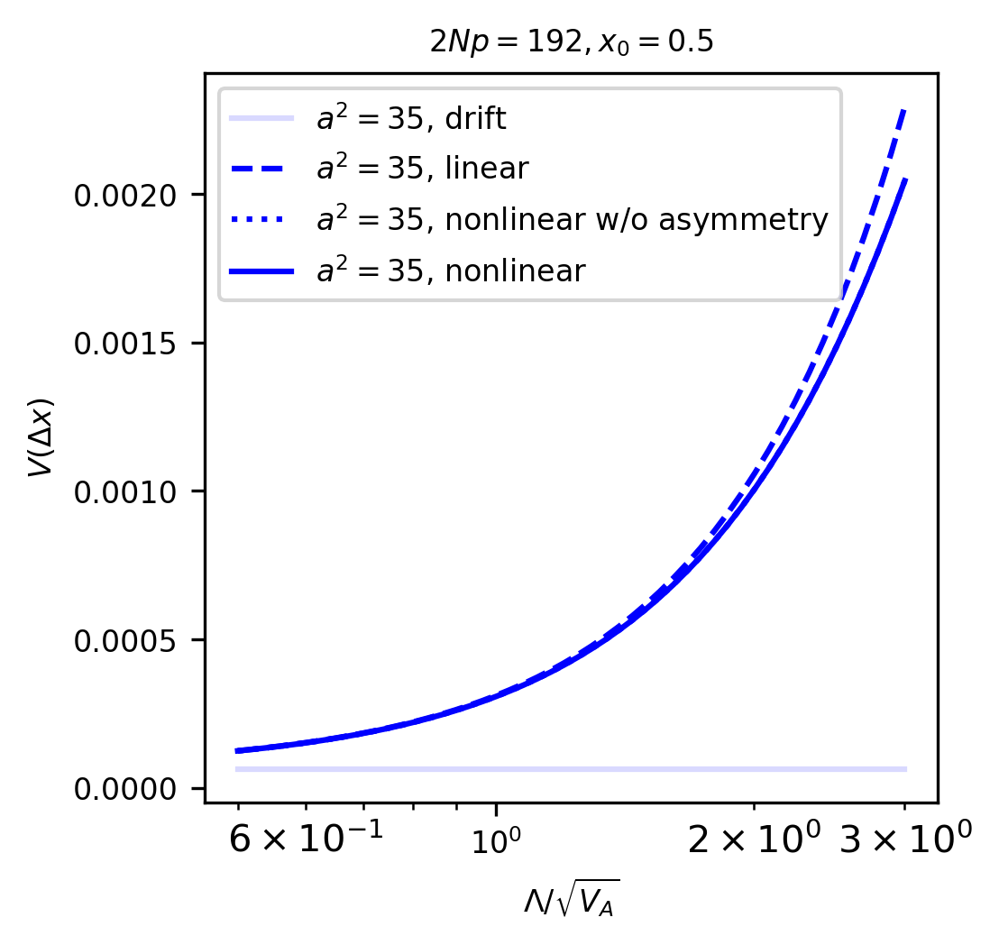

In [9]:
fontsize = 8

N = 2000
U = 0.025
E2Ns = 16

rate_of_shift = 0.048

for x in (1 / (2 * N), 0.1, 0.5):
    for ss, color in ((0.5, 'r'), (5, 'g'), (35, 'b')):
        fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
        ax = fig.add_subplot(1, 1, 1)
    
        ax.plot(np.geomspace(0.5, 3), [x * (1 - x) / (2 * N) for _ in np.geomspace(0.5, 3)], color=color, alpha=0.15, label=r'$a^2=%g$, drift' % ss)
        ax.plot(np.geomspace(0.5, 3), [V_Delta_x_drift_and_shifts(a=np.sqrt(ss), x=x, shift_s0=shift_s0, sigma_0_del=np.sqrt(V_A(E2Ns=E2Ns)), p=rate_of_shift) for shift_s0 in np.geomspace(0.5, 3)], color=color, linestyle='--', label=r'$a^2=%g$, linear' % ss)
        ax.plot(np.geomspace(0.5, 3), [V_Delta_x_drift_and_shifts_nonlinear_without_asymmetry(a=np.sqrt(ss), x=x, shift_s0=shift_s0, sigma_0_del=np.sqrt(V_A(E2Ns=E2Ns)), p=rate_of_shift) for shift_s0 in np.geomspace(0.5, 3)], color=color, linestyle=':', label=r'$a^2=%g$, nonlinear w/o asymmetry' % ss)
        ax.plot(np.geomspace(0.5, 3), [V_Delta_x_drift_and_shifts_nonlinear(a=np.sqrt(ss), x=x, shift_s0=shift_s0, sigma_0_del=np.sqrt(V_A(E2Ns=E2Ns)), p=rate_of_shift) for shift_s0 in np.geomspace(0.5, 3)], color=color, label=r'$a^2=%g$, nonlinear' % ss)
    
        ax.set_xscale('log')
        plt.xlabel(r'$\Lambda / \sqrt{V_A}$', fontsize=fontsize)
        plt.ylabel(r'$V(\Delta x)$', fontsize=fontsize)
        plt.xticks(fontsize=fontsize)
        plt.yticks(fontsize=fontsize)
        plt.legend(fontsize=fontsize)
        plt.title(r'$2Np=%g, x_0=%g$' % (2 * N * rate_of_shift, x), fontsize=fontsize)
        plt.show()

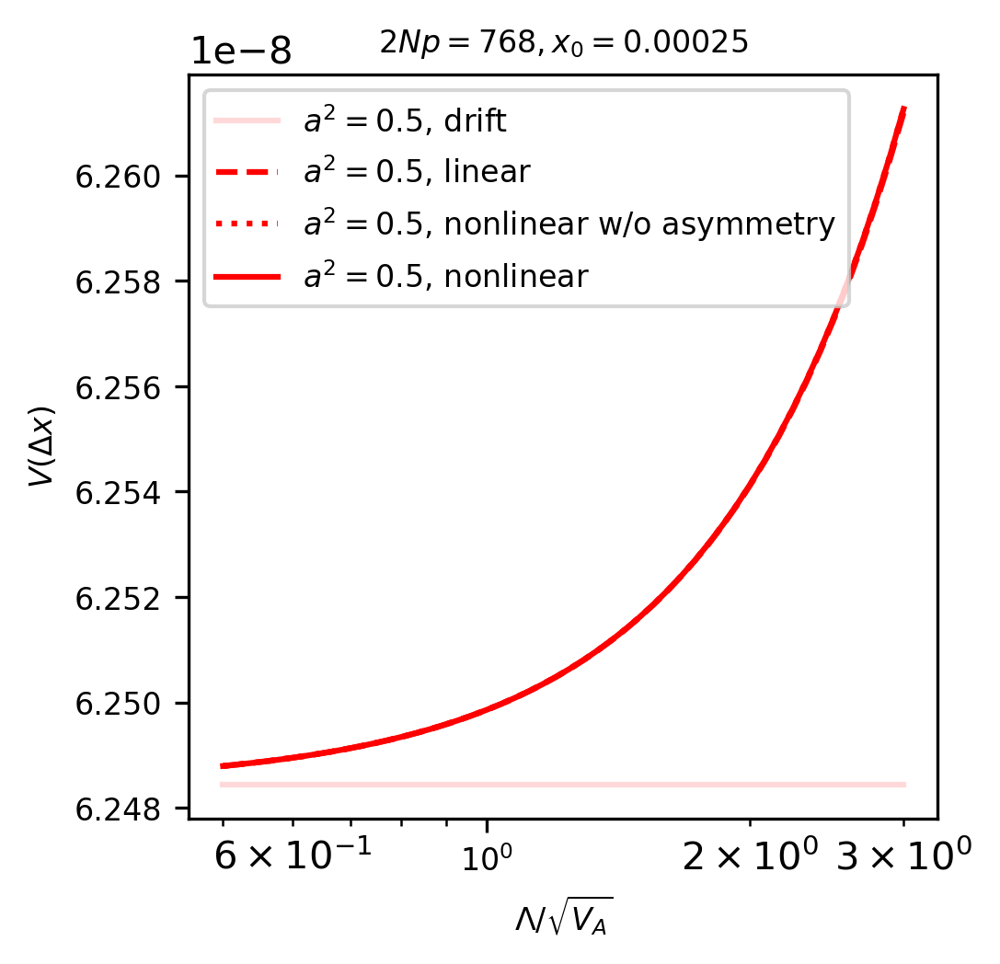

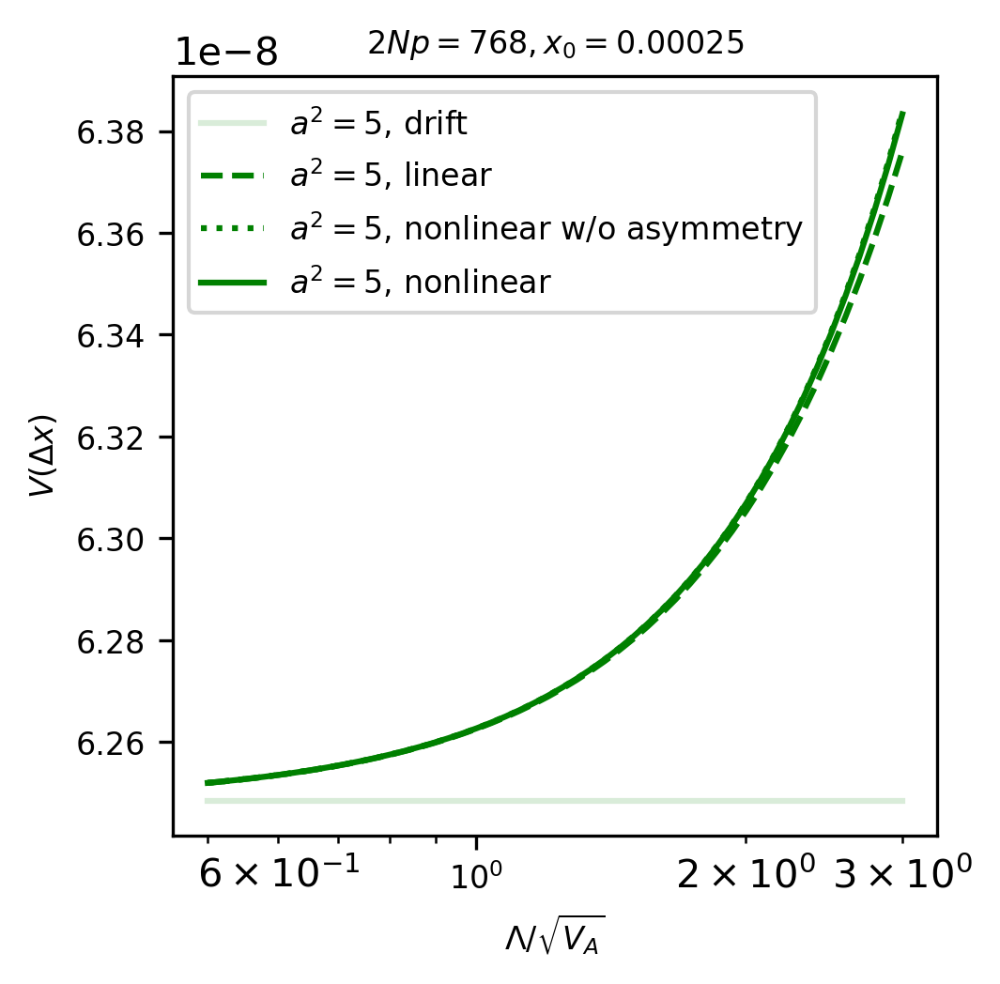

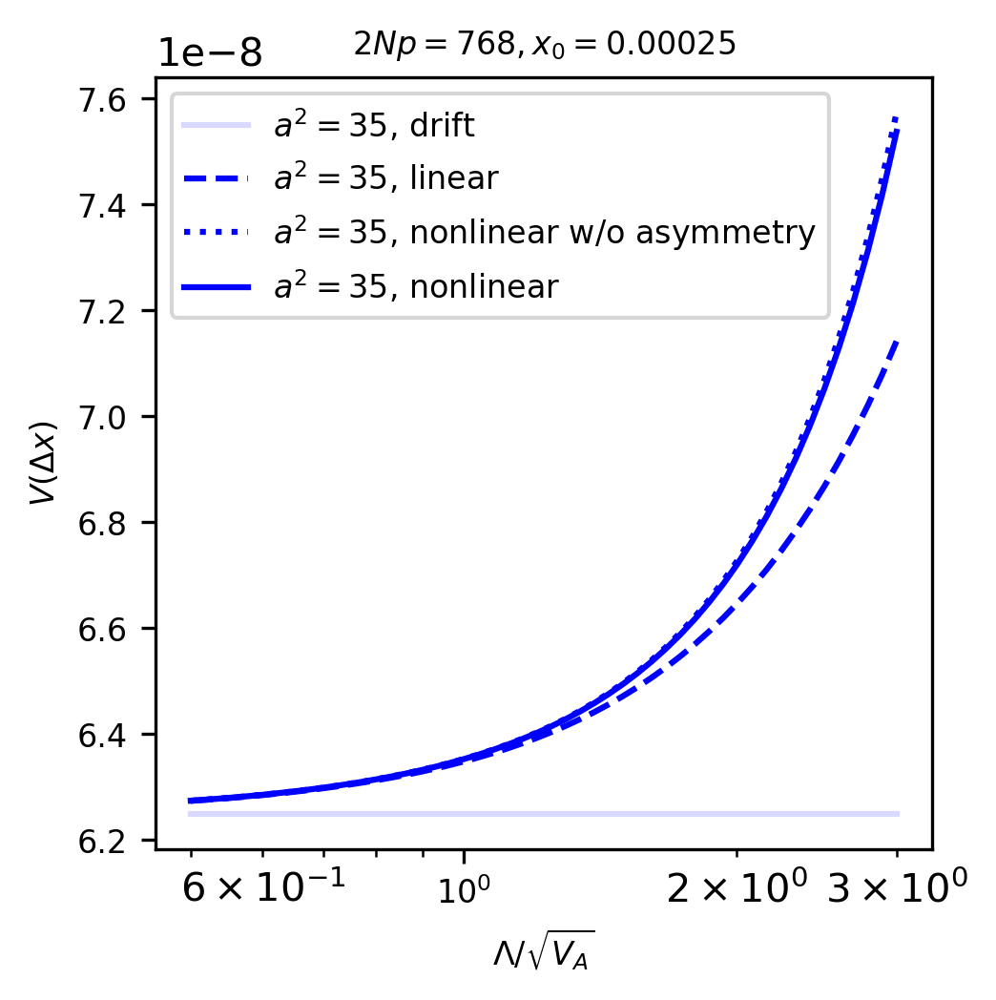

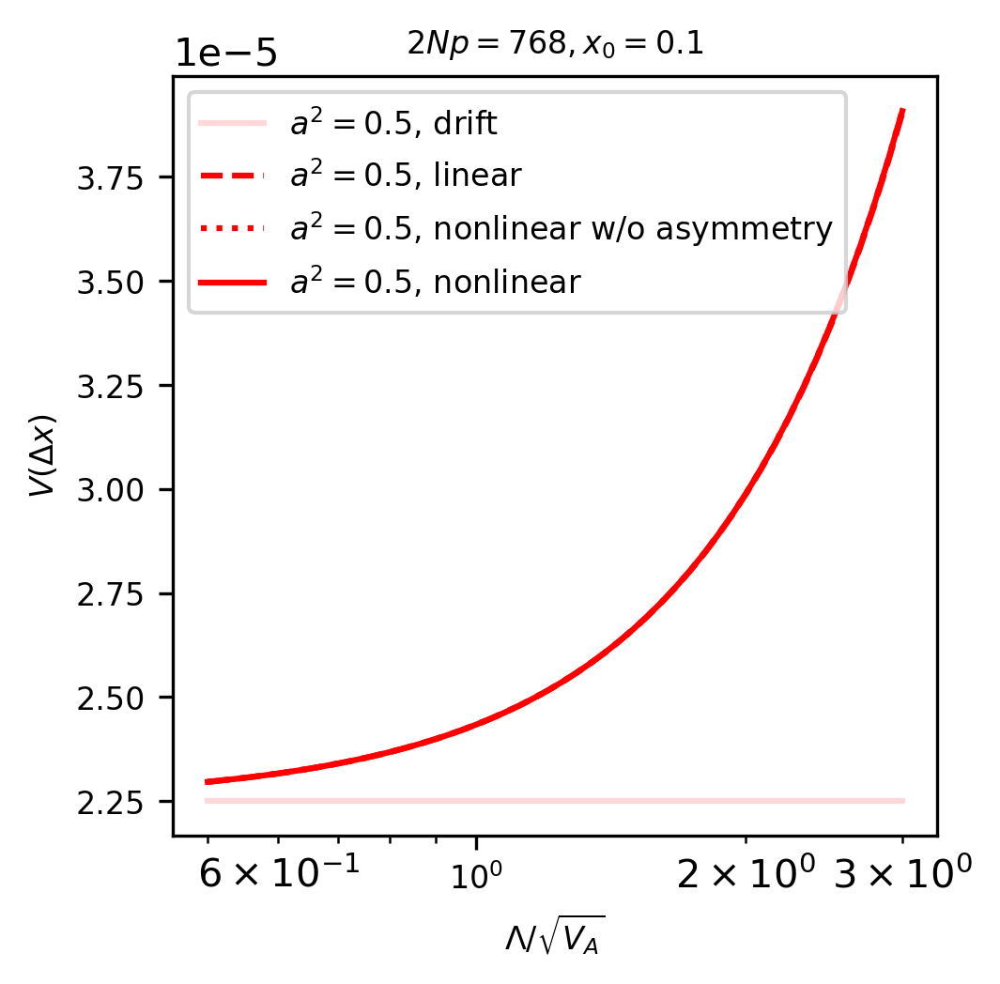

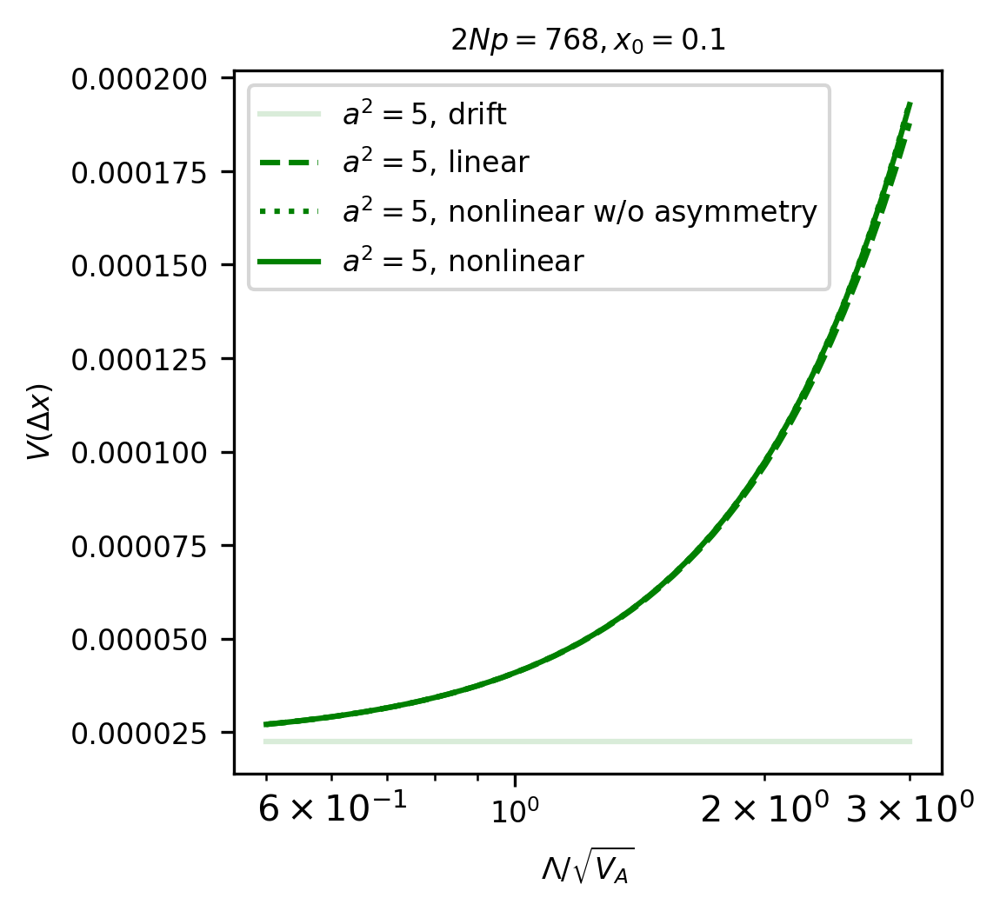

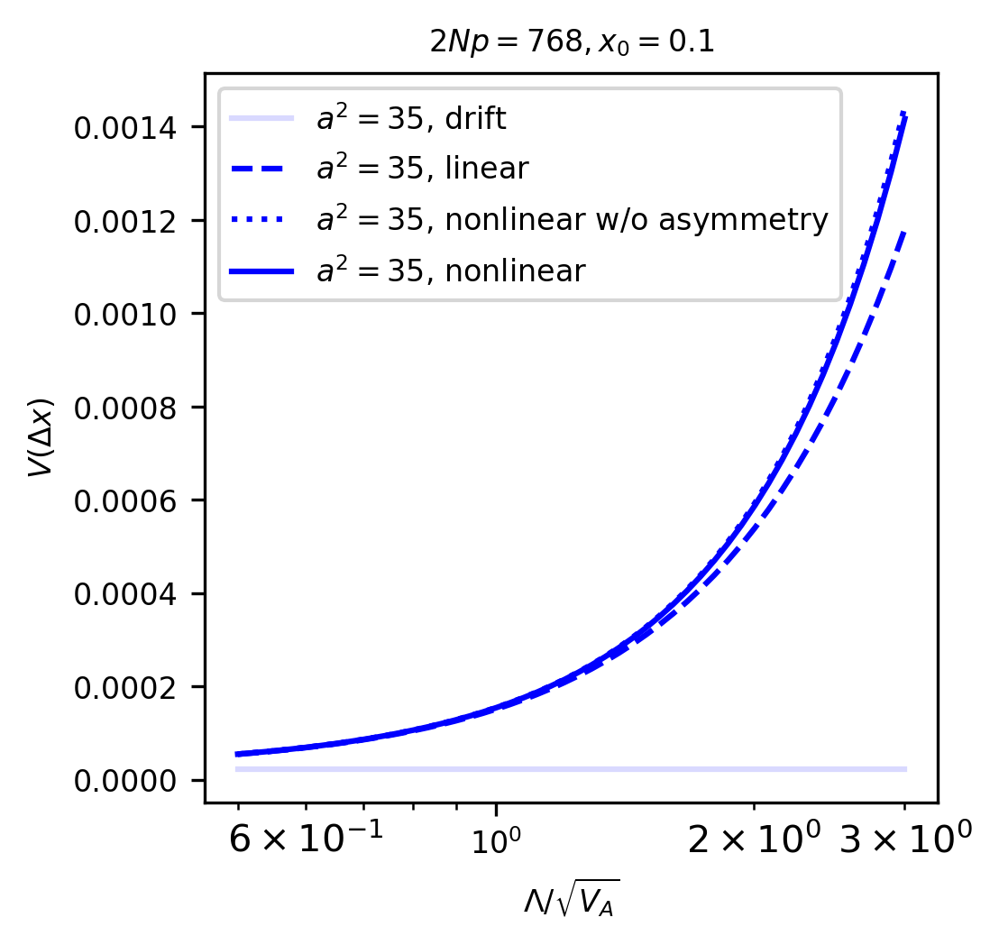

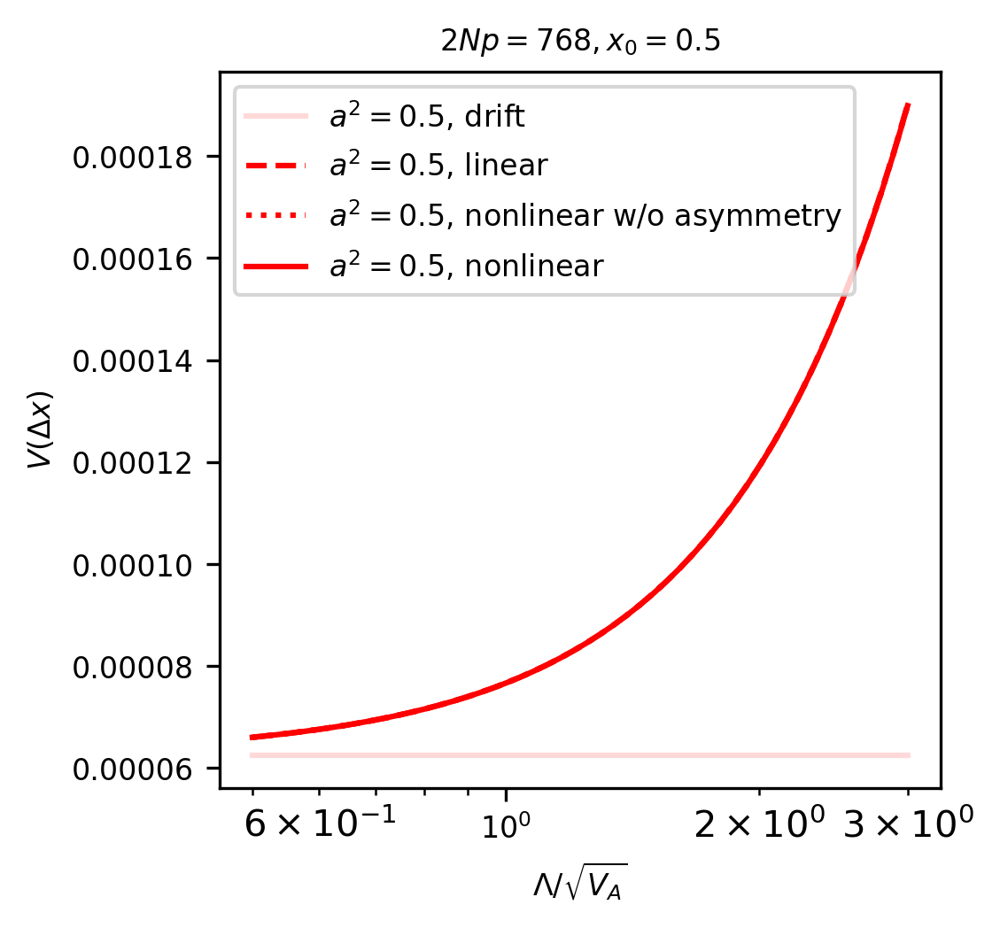

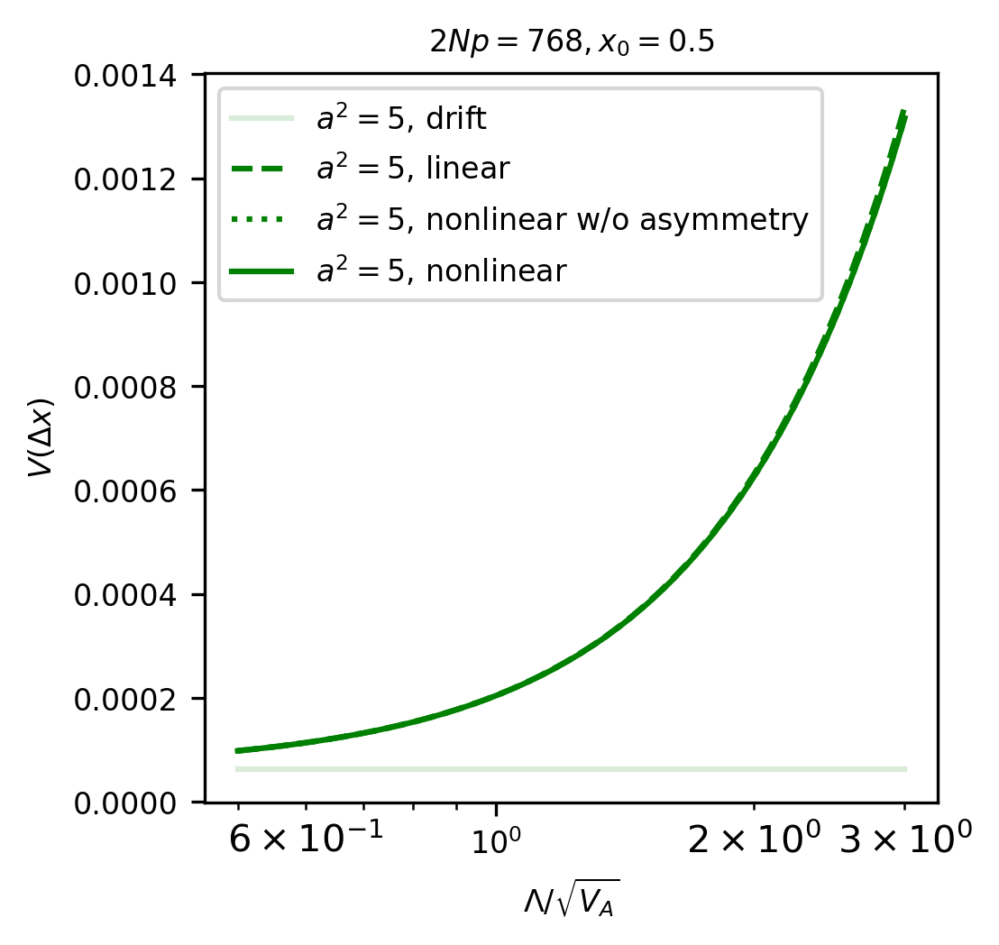

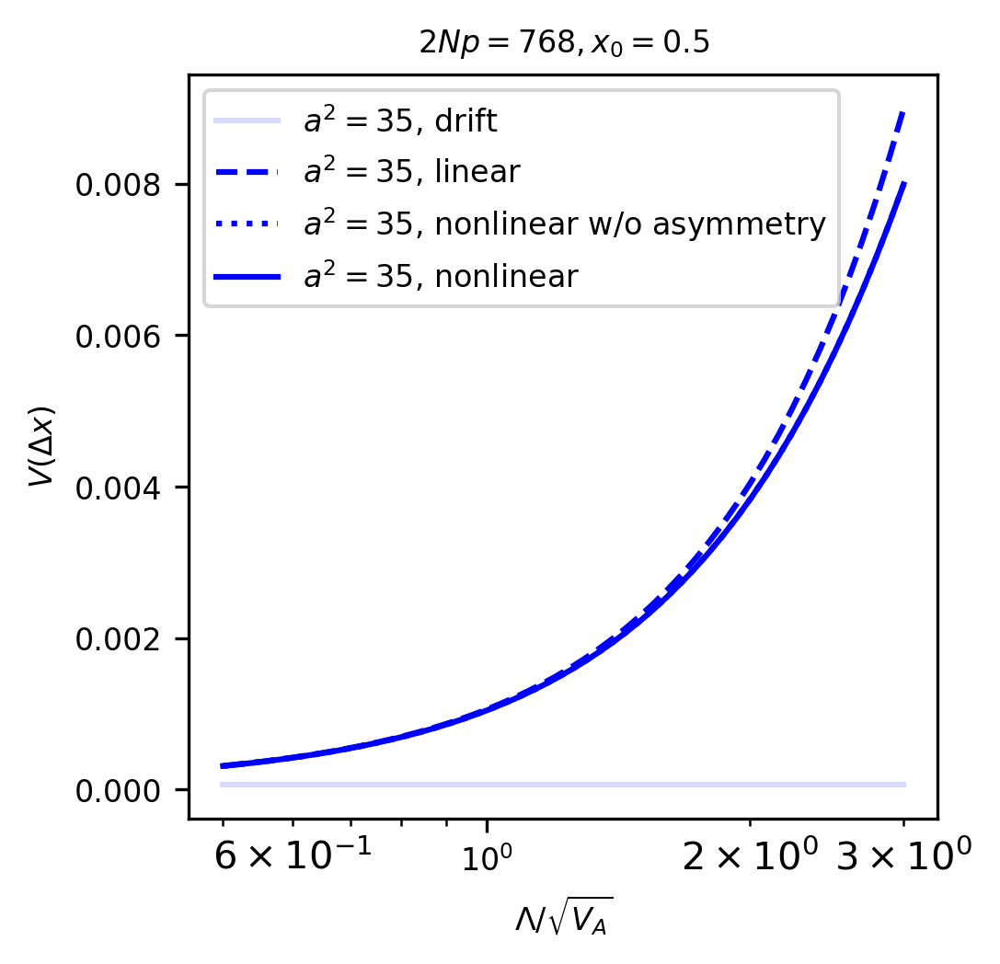

In [10]:
fontsize = 8

N = 2000
U = 0.025
E2Ns = 16

rate_of_shift = 0.192

for x in (1 / (2 * N), 0.1, 0.5):
    for ss, color in ((0.5, 'r'), (5, 'g'), (35, 'b')):
        fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
        ax = fig.add_subplot(1, 1, 1)
    
        ax.plot(np.geomspace(0.5, 3), [x * (1 - x) / (2 * N) for _ in np.geomspace(0.5, 3)], color=color, alpha=0.15, label=r'$a^2=%g$, drift' % ss)
        ax.plot(np.geomspace(0.5, 3), [V_Delta_x_drift_and_shifts(a=np.sqrt(ss), x=x, shift_s0=shift_s0, sigma_0_del=np.sqrt(V_A(E2Ns=E2Ns)), p=rate_of_shift) for shift_s0 in np.geomspace(0.5, 3)], color=color, linestyle='--', label=r'$a^2=%g$, linear' % ss)
        ax.plot(np.geomspace(0.5, 3), [V_Delta_x_drift_and_shifts_nonlinear_without_asymmetry(a=np.sqrt(ss), x=x, shift_s0=shift_s0, sigma_0_del=np.sqrt(V_A(E2Ns=E2Ns)), p=rate_of_shift) for shift_s0 in np.geomspace(0.5, 3)], color=color, linestyle=':', label=r'$a^2=%g$, nonlinear w/o asymmetry' % ss)
        ax.plot(np.geomspace(0.5, 3), [V_Delta_x_drift_and_shifts_nonlinear(a=np.sqrt(ss), x=x, shift_s0=shift_s0, sigma_0_del=np.sqrt(V_A(E2Ns=E2Ns)), p=rate_of_shift) for shift_s0 in np.geomspace(0.5, 3)], color=color, label=r'$a^2=%g$, nonlinear' % ss)
    
        ax.set_xscale('log')
        plt.xlabel(r'$\Lambda / \sqrt{V_A}$', fontsize=fontsize)
        plt.ylabel(r'$V(\Delta x)$', fontsize=fontsize)
        plt.xticks(fontsize=fontsize)
        plt.yticks(fontsize=fontsize)
        plt.legend(fontsize=fontsize)
        plt.title(r'$2Np=%g, x_0=%g$' % (2 * N * rate_of_shift, x), fontsize=fontsize)
        plt.show()

/tmp/ipykernel_3726598/815601565.py:11: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  ax.plot(np.geomspace(0.1, 100), [quad(lambda x_0: E_Delta_x_stab_sel(a=np.sqrt(ss), x=x_0) * tau(a=np.sqrt(ss), x=x_0, p=1 / (2 * N)), 0.0, 1.0, points=[1/(2*N)])[0] / quad(lambda x_0: tau(a=np.sqrt(ss), x=x_0, p=1 / (2 * N)), 0.0, 1.0, points=[1/(2*N)])[0] for ss in np.geomspace(0.1, 100)], color='lightgray', label='no shifts')
/tmp/ipykernel_3726598/815601565.py:11: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special

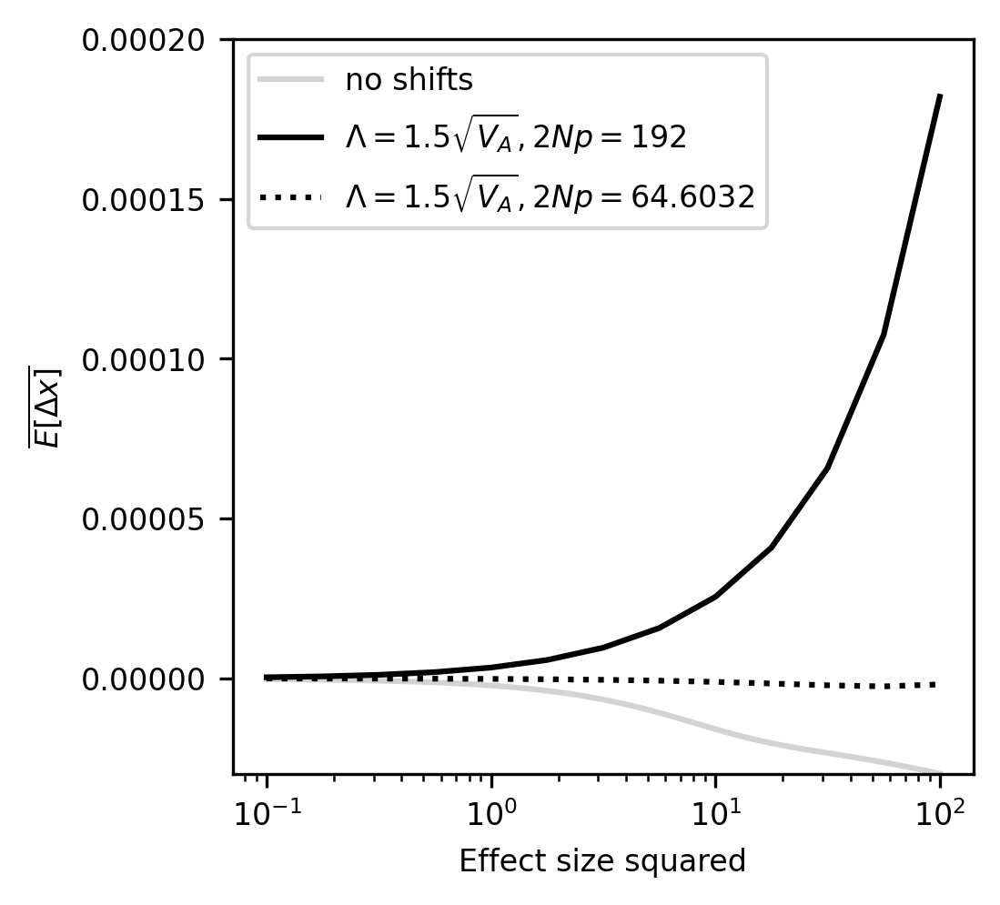

In [11]:
# the average expected change in allele frequency, in the Lande case
fontsize = 8

N = 2000
U = 0.025
E2Ns = 1

fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = fig.add_subplot(1, 1, 1)

ax.plot(np.geomspace(0.1, 100), [quad(lambda x_0: E_Delta_x_stab_sel(a=np.sqrt(ss), x=x_0) * tau(a=np.sqrt(ss), x=x_0, p=1 / (2 * N)), 0.0, 1.0, points=[1/(2*N)])[0] / quad(lambda x_0: tau(a=np.sqrt(ss), x=x_0, p=1 / (2 * N)), 0.0, 1.0, points=[1/(2*N)])[0] for ss in np.geomspace(0.1, 100)], color='lightgray', label='no shifts')

index_shift_s0, shift_s0 = 15, 1.5
index_rate_of_shift, rate_of_shift = 37, 0.048
ax.plot(np.geomspace(0.1, 100, 13), [quad(lambda x_0: (E_Delta_x_stab_sel(a=np.sqrt(ss), x=x_0) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x_0, shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift])) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x_0, shift_s0=-shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]))) * tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0] / quad(lambda x_0: tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0] for ss in np.geomspace(0.1, 100, 13)], color='k', label=r'$\Lambda=%g\sqrt{V_A}, 2Np=%g$' % (shift_s0, 2 * N * rate_of_shift))

shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3, 5]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 32
rate_of_shifts_partitioning = 57
index_shift_s0, shift_s0 = 15, 1.5
index_rate_of_shift = np.searchsorted([pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=1, x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))], 1 / (2 * N)) - 1
rate_of_shift = np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)[index_rate_of_shift]
ax.plot(np.geomspace(0.1, 100, 13), [quad(lambda x_0: (E_Delta_x_stab_sel(a=np.sqrt(ss), x=x_0) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x_0, shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift])) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x_0, shift_s0=-shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]))) * tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0] / quad(lambda x_0: tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0] for ss in np.geomspace(0.1, 100, 13)], color='k', linestyle=':', label=r'$\Lambda=%g\sqrt{V_A}, 2Np=%g$' % (shift_s0, 2 * N * rate_of_shift))

ax.set_xscale('log')
ax.set_ylim(-3e-5, 2e-4)
plt.xlabel('Effect size squared', fontsize=fontsize)
plt.ylabel(r'$\overline{E[\Delta x]}$', fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.legend(fontsize=fontsize)
plt.show()

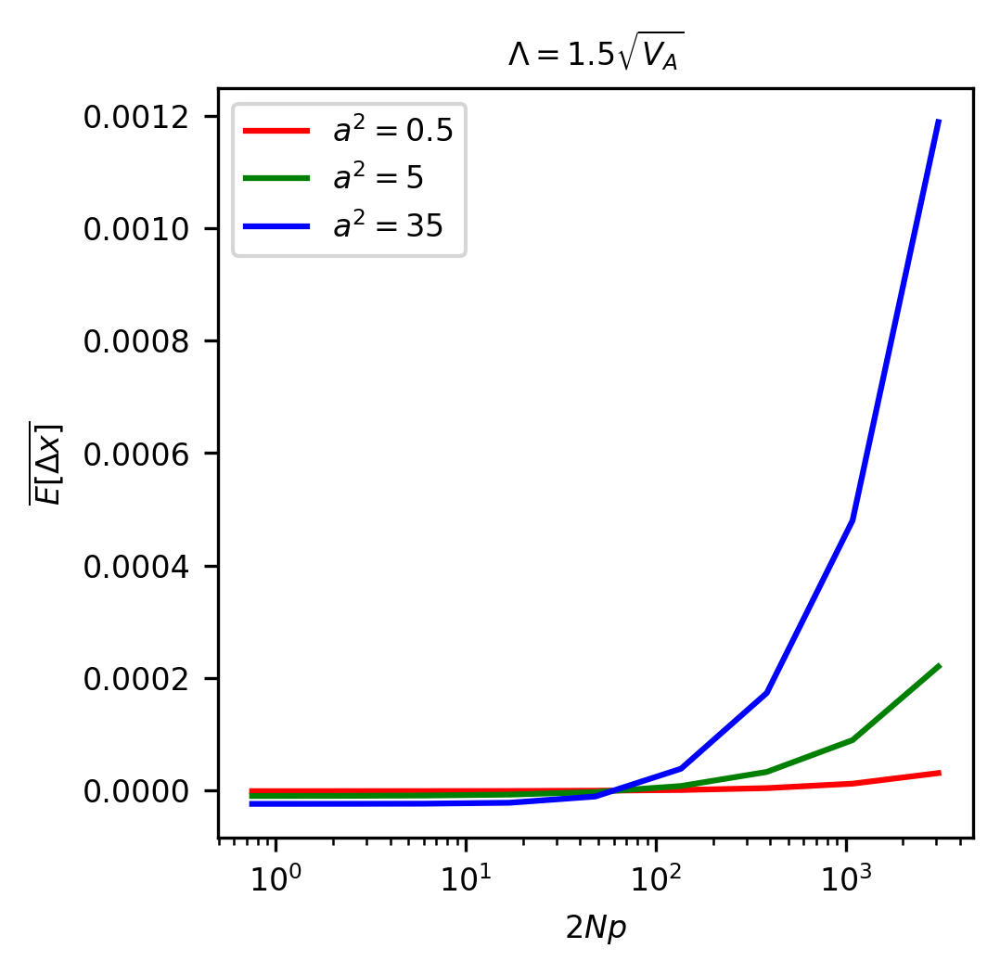

In [12]:
fontsize = 8

N = 2000
U = 0.025
E2Ns = 1

index_shift_s0, shift_s0 = 15, 1.5
rate_of_shifts_partitioning = 57

fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = fig.add_subplot(1, 1, 1)

ss, color = 0.5, 'r'
ax.plot(2 * N * np.geomspace(0.0001875, 0.768, rate_of_shifts_partitioning)[::7], [quad(lambda x_0: (E_Delta_x_stab_sel(a=np.sqrt(ss), x=x_0) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x_0, shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift])) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x_0, shift_s0=-shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]))) * tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0] / quad(lambda x_0: tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0] for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(0.0001875, 0.768, rate_of_shifts_partitioning)) if index_rate_of_shift % 7 == 0], color=color, label=r'$a^2=%g$' % ss)
ss, color = 5, 'g'
ax.plot(2 * N * np.geomspace(0.0001875, 0.768, rate_of_shifts_partitioning)[::7], [quad(lambda x_0: (E_Delta_x_stab_sel(a=np.sqrt(ss), x=x_0) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x_0, shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift])) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x_0, shift_s0=-shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]))) * tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0] / quad(lambda x_0: tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0] for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(0.0001875, 0.768, rate_of_shifts_partitioning)) if index_rate_of_shift % 7 == 0], color=color, label=r'$a^2=%g$' % ss)
ss, color = 35, 'b'
ax.plot(2 * N * np.geomspace(0.0001875, 0.768, rate_of_shifts_partitioning)[::7], [quad(lambda x_0: (E_Delta_x_stab_sel(a=np.sqrt(ss), x=x_0) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x_0, shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift])) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x_0, shift_s0=-shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]))) * tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0] / quad(lambda x_0: tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0] for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(0.0001875, 0.768, rate_of_shifts_partitioning)) if index_rate_of_shift % 7 == 0], color=color, label=r'$a^2=%g$' % ss)

ax.set_xscale('log')
plt.xlabel(r'$2Np$', fontsize=fontsize)
plt.ylabel(r'$\overline{E[\Delta x]}$', fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.legend(fontsize=fontsize)
plt.title(r'$\Lambda=%g\sqrt{V_A}$' % shift_s0, fontsize=fontsize)
plt.show()

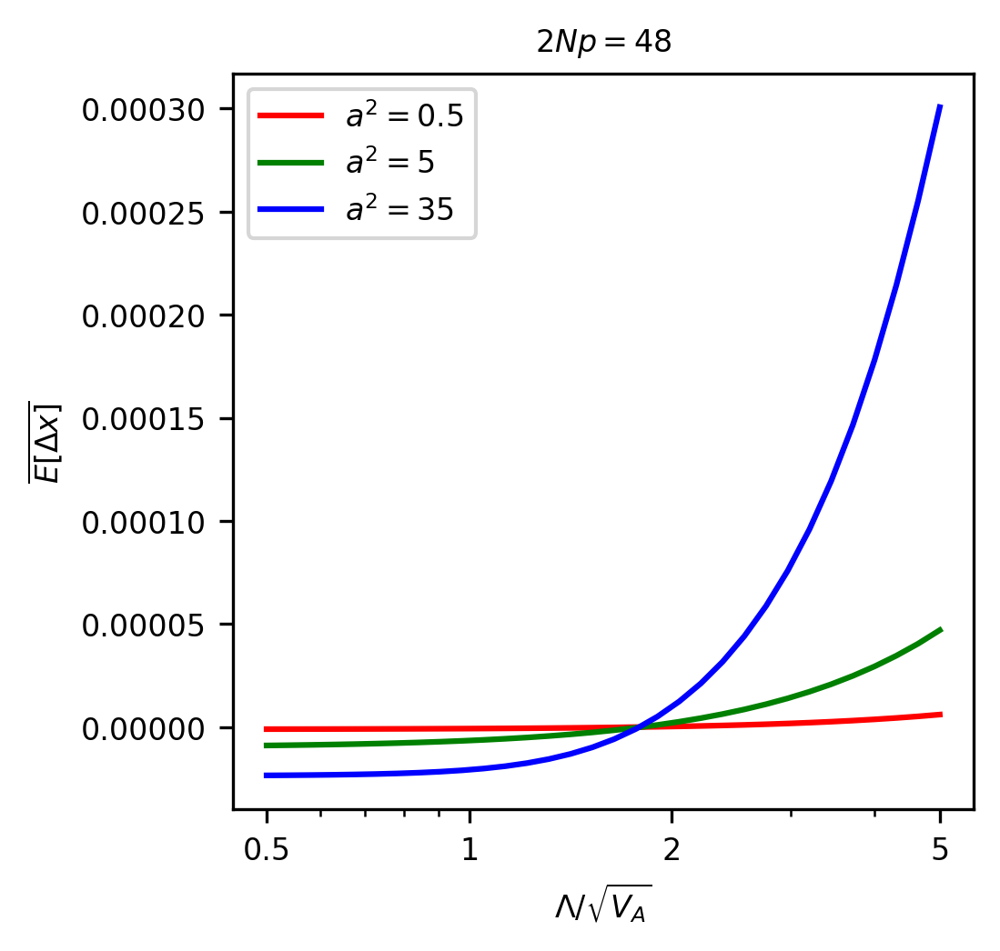

In [13]:
fontsize = 8

N = 2000
U = 0.025
E2Ns = 1

index_rate_of_shift, rate_of_shift = 28, 0.012
shift_s0_partitioning = 32

fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = fig.add_subplot(1, 1, 1)

ss, color = 0.5, 'r'
ax.plot(np.geomspace(0.5, 5, shift_s0_partitioning), [quad(lambda x_0: (E_Delta_x_stab_sel(a=np.sqrt(ss), x=x_0) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x_0, shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift])) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x_0, shift_s0=-shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]))) * tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0] / quad(lambda x_0: tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0] for index_shift_s0, shift_s0 in enumerate(np.geomspace(0.5, 5, shift_s0_partitioning))], color=color, label=r'$a^2=%g$' % ss)
ss, color = 5, 'g'
ax.plot(np.geomspace(0.5, 5, shift_s0_partitioning), [quad(lambda x_0: (E_Delta_x_stab_sel(a=np.sqrt(ss), x=x_0) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x_0, shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift])) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x_0, shift_s0=-shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]))) * tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0] / quad(lambda x_0: tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0] for index_shift_s0, shift_s0 in enumerate(np.geomspace(0.5, 5, shift_s0_partitioning))], color=color, label=r'$a^2=%g$' % ss)
ss, color = 35, 'b'
ax.plot(np.geomspace(0.5, 5, shift_s0_partitioning), [quad(lambda x_0: (E_Delta_x_stab_sel(a=np.sqrt(ss), x=x_0) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x_0, shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift])) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x_0, shift_s0=-shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]))) * tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0] / quad(lambda x_0: tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0] for index_shift_s0, shift_s0 in enumerate(np.geomspace(0.5, 5, shift_s0_partitioning))], color=color, label=r'$a^2=%g$' % ss)

ax.set_xscale('log')
plt.xlabel(r'$\Lambda / \sqrt{V_A}$', fontsize=fontsize)
plt.ylabel(r'$\overline{E[\Delta x]}$', fontsize=fontsize)
plt.xticks(ticks=[0.5, 1, 2, 5], labels=[0.5, 1, 2, 5], fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.legend(fontsize=fontsize)
plt.title(r'$2Np=%g$' % (2 * N * rate_of_shift), fontsize=fontsize)
plt.show()

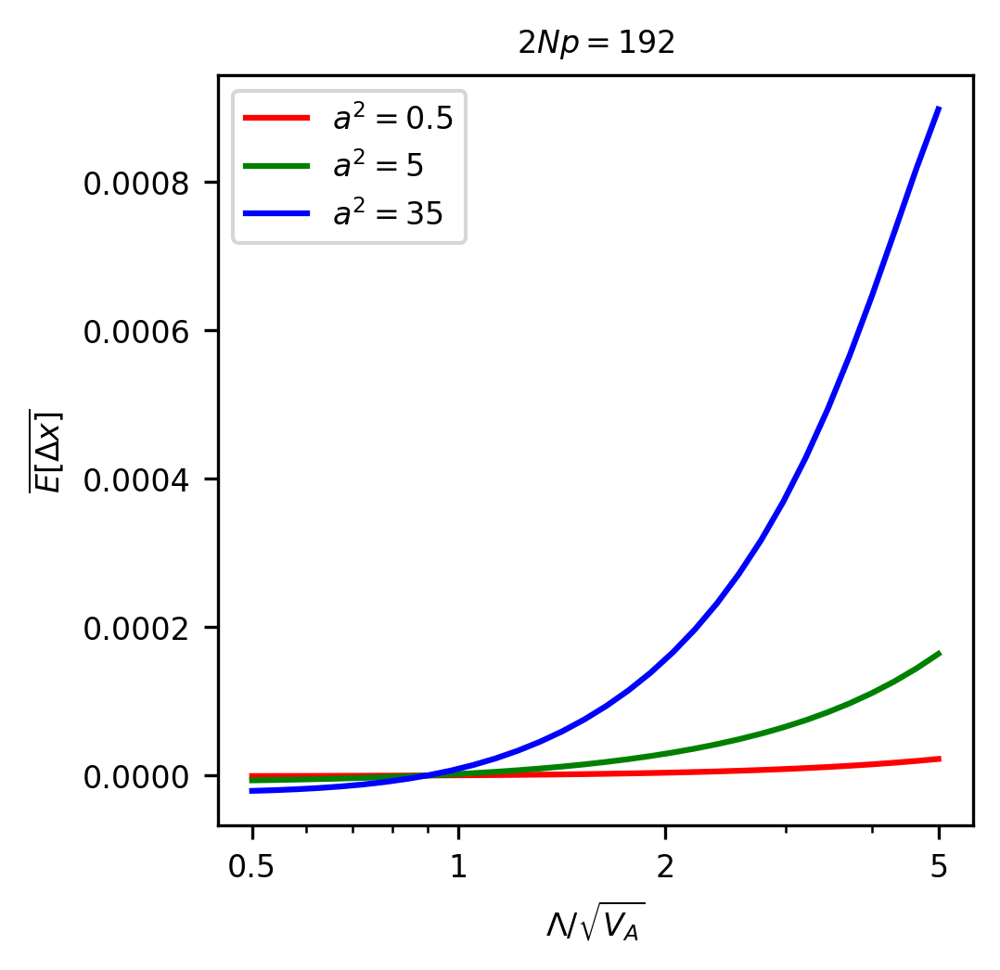

In [14]:
fontsize = 8

N = 2000
U = 0.025
E2Ns = 1

index_rate_of_shift, rate_of_shift = 37, 0.048
shift_s0_partitioning = 32

fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = fig.add_subplot(1, 1, 1)

ss, color = 0.5, 'r'
ax.plot(np.geomspace(0.5, 5, shift_s0_partitioning), [quad(lambda x_0: (E_Delta_x_stab_sel(a=np.sqrt(ss), x=x_0) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x_0, shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift])) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x_0, shift_s0=-shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]))) * tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0] / quad(lambda x_0: tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0] for index_shift_s0, shift_s0 in enumerate(np.geomspace(0.5, 5, shift_s0_partitioning))], color=color, label=r'$a^2=%g$' % ss)
ss, color = 5, 'g'
ax.plot(np.geomspace(0.5, 5, shift_s0_partitioning), [quad(lambda x_0: (E_Delta_x_stab_sel(a=np.sqrt(ss), x=x_0) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x_0, shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift])) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x_0, shift_s0=-shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]))) * tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0] / quad(lambda x_0: tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0] for index_shift_s0, shift_s0 in enumerate(np.geomspace(0.5, 5, shift_s0_partitioning))], color=color, label=r'$a^2=%g$' % ss)
ss, color = 35, 'b'
ax.plot(np.geomspace(0.5, 5, shift_s0_partitioning), [quad(lambda x_0: (E_Delta_x_stab_sel(a=np.sqrt(ss), x=x_0) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x_0, shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift])) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x_0, shift_s0=-shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]))) * tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0] / quad(lambda x_0: tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0] for index_shift_s0, shift_s0 in enumerate(np.geomspace(0.5, 5, shift_s0_partitioning))], color=color, label=r'$a^2=%g$' % ss)

ax.set_xscale('log')
plt.xlabel(r'$\Lambda / \sqrt{V_A}$', fontsize=fontsize)
plt.ylabel(r'$\overline{E[\Delta x]}$', fontsize=fontsize)
plt.xticks(ticks=[0.5, 1, 2, 5], labels=[0.5, 1, 2, 5], fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.legend(fontsize=fontsize)
plt.title(r'$2Np=%g$' % (2 * N * rate_of_shift), fontsize=fontsize)
plt.show()

/tmp/ipykernel_3726598/3314124481.py:11: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  ax.plot(np.geomspace(0.1, 100), [quad(lambda x_0: E_Delta_x_stab_sel(a=np.sqrt(ss), x=x_0) * tau(a=np.sqrt(ss), x=x_0, p=1 / (2 * N)), 0.0, 1.0, points=[1/(2*N)])[0] / quad(lambda x_0: tau(a=np.sqrt(ss), x=x_0, p=1 / (2 * N)), 0.0, 1.0, points=[1/(2*N)])[0] for ss in np.geomspace(0.1, 100)], color='lightgray', label='no shifts')
/tmp/ipykernel_3726598/3314124481.py:11: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a speci

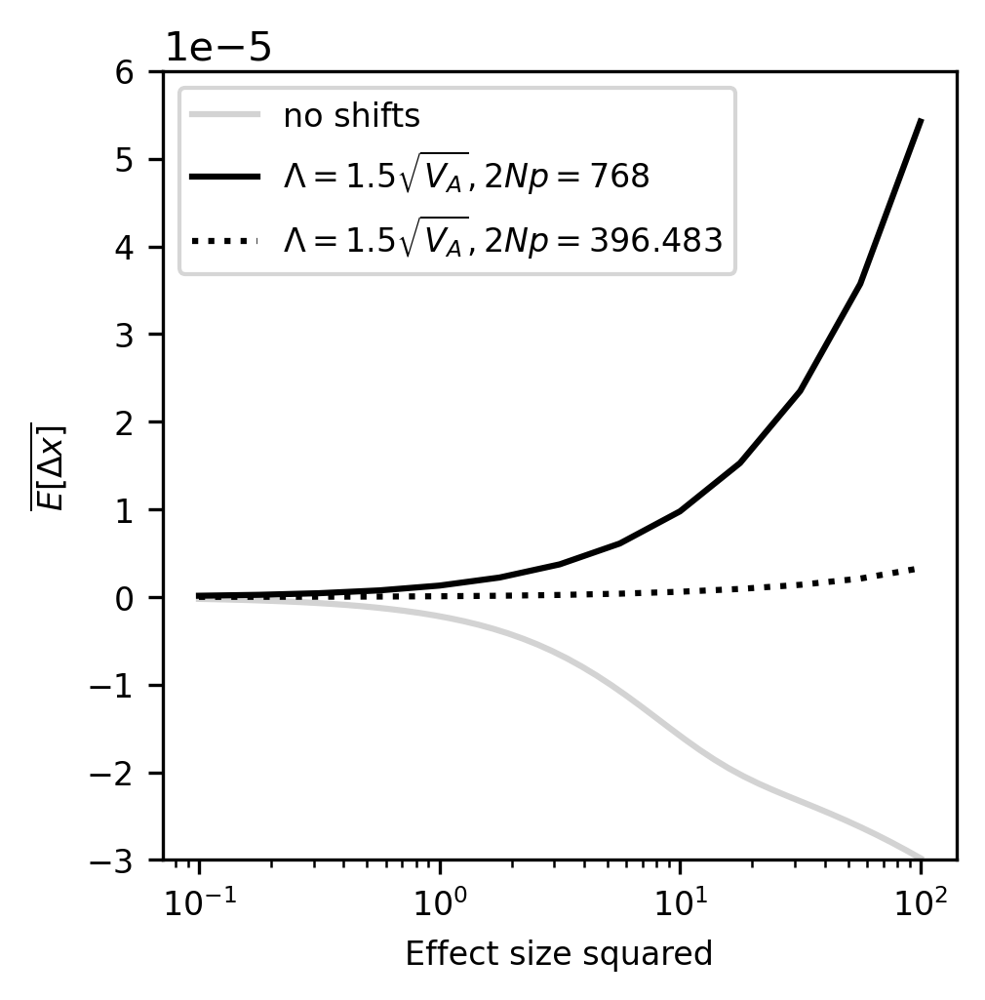

In [15]:
# the average expected change in allele frequency, in the non-Lande case
fontsize = 8

N = 2000
U = 0.025
E2Ns = 16

fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = fig.add_subplot(1, 1, 1)

ax.plot(np.geomspace(0.1, 100), [quad(lambda x_0: E_Delta_x_stab_sel(a=np.sqrt(ss), x=x_0) * tau(a=np.sqrt(ss), x=x_0, p=1 / (2 * N)), 0.0, 1.0, points=[1/(2*N)])[0] / quad(lambda x_0: tau(a=np.sqrt(ss), x=x_0, p=1 / (2 * N)), 0.0, 1.0, points=[1/(2*N)])[0] for ss in np.geomspace(0.1, 100)], color='lightgray', label='no shifts')

index_shift_s0, shift_s0 = 17, 1.5
index_rate_of_shift, rate_of_shift = 54, 0.192
ax.plot(np.geomspace(0.1, 100, 13), [quad(lambda x_0: (E_Delta_x_stab_sel(a=np.sqrt(ss), x=x_0) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x_0, shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift])) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x_0, shift_s0=-shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]))) * tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0] / quad(lambda x_0: tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0] for ss in np.geomspace(0.1, 100, 13)], color='k', label=r'$\Lambda=%g\sqrt{V_A}, 2Np=%g$' % (shift_s0, 2 * N * rate_of_shift))

shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 29
rate_of_shifts_partitioning = 66
index_shift_s0, shift_s0 = 17, 1.5
index_rate_of_shift = np.searchsorted([pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=1, x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))], 1 / (2 * N))
rate_of_shift = np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)[index_rate_of_shift]
ax.plot(np.geomspace(0.1, 100, 13), [quad(lambda x_0: (E_Delta_x_stab_sel(a=np.sqrt(ss), x=x_0) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x_0, shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift])) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x_0, shift_s0=-shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]))) * tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0] / quad(lambda x_0: tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0] for ss in np.geomspace(0.1, 100, 13)], color='k', linestyle=':', label=r'$\Lambda=%g\sqrt{V_A}, 2Np=%g$' % (shift_s0, 2 * N * rate_of_shift))

ax.set_xscale('log')
ax.set_ylim(-3e-5, 6e-5)
plt.xlabel('Effect size squared', fontsize=fontsize)
plt.ylabel(r'$\overline{E[\Delta x]}$', fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.legend(fontsize=fontsize)
plt.show()

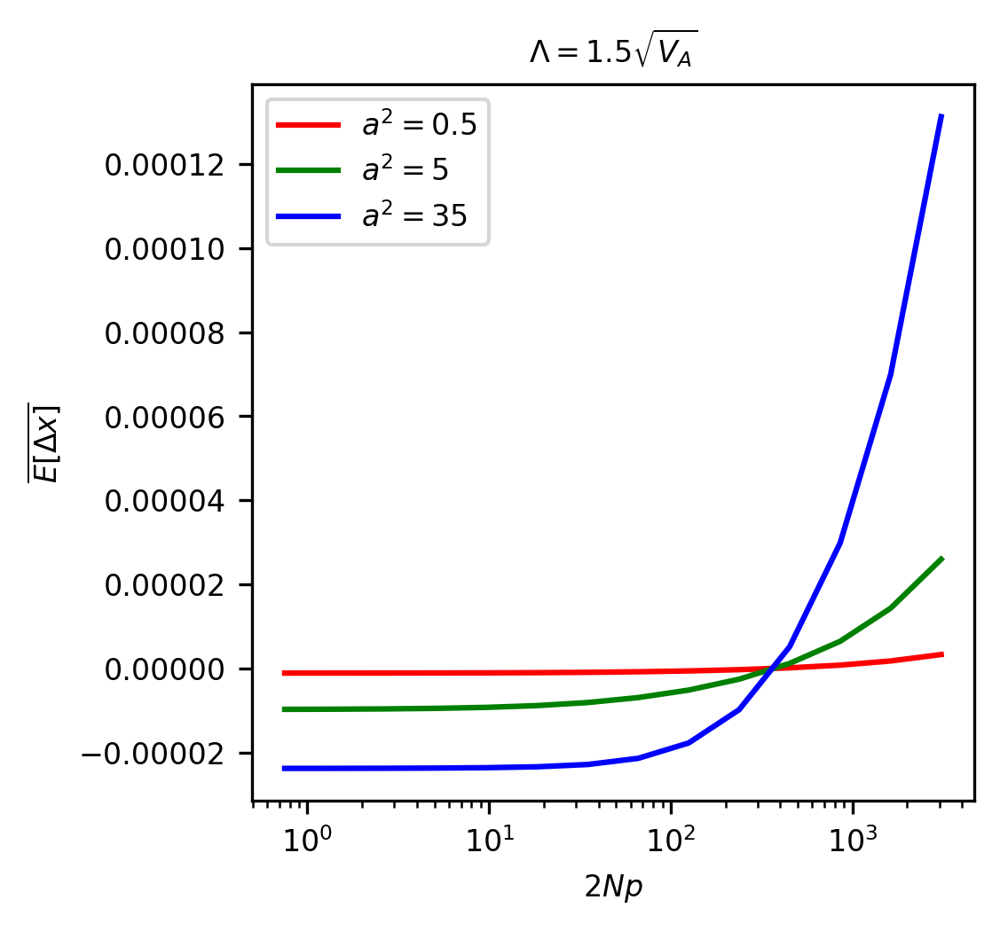

In [16]:
fontsize = 8

N = 2000
U = 0.025
E2Ns = 16

index_shift_s0, shift_s0 = 17, 1.5
rate_of_shifts_partitioning = 66

fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = fig.add_subplot(1, 1, 1)

ss, color = 0.5, 'r'
ax.plot(2 * N * np.geomspace(0.0001875, 0.768, rate_of_shifts_partitioning)[::5], [quad(lambda x_0: (E_Delta_x_stab_sel(a=np.sqrt(ss), x=x_0) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x_0, shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift])) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x_0, shift_s0=-shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]))) * tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0] / quad(lambda x_0: tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0] for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(0.0001875, 0.768, rate_of_shifts_partitioning)) if index_rate_of_shift % 5 == 0], color=color, label=r'$a^2=%g$' % ss)
ss, color = 5, 'g'
ax.plot(2 * N * np.geomspace(0.0001875, 0.768, rate_of_shifts_partitioning)[::5], [quad(lambda x_0: (E_Delta_x_stab_sel(a=np.sqrt(ss), x=x_0) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x_0, shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift])) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x_0, shift_s0=-shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]))) * tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0] / quad(lambda x_0: tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0] for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(0.0001875, 0.768, rate_of_shifts_partitioning)) if index_rate_of_shift % 5 == 0], color=color, label=r'$a^2=%g$' % ss)
ss, color = 35, 'b'
ax.plot(2 * N * np.geomspace(0.0001875, 0.768, rate_of_shifts_partitioning)[::5], [quad(lambda x_0: (E_Delta_x_stab_sel(a=np.sqrt(ss), x=x_0) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x_0, shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift])) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x_0, shift_s0=-shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]))) * tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0] / quad(lambda x_0: tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0] for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(0.0001875, 0.768, rate_of_shifts_partitioning)) if index_rate_of_shift % 5 == 0], color=color, label=r'$a^2=%g$' % ss)

ax.set_xscale('log')
plt.xlabel(r'$2Np$', fontsize=fontsize)
plt.ylabel(r'$\overline{E[\Delta x]}$', fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.legend(fontsize=fontsize)
plt.title(r'$\Lambda=%g\sqrt{V_A}$' % shift_s0, fontsize=fontsize)
plt.show()

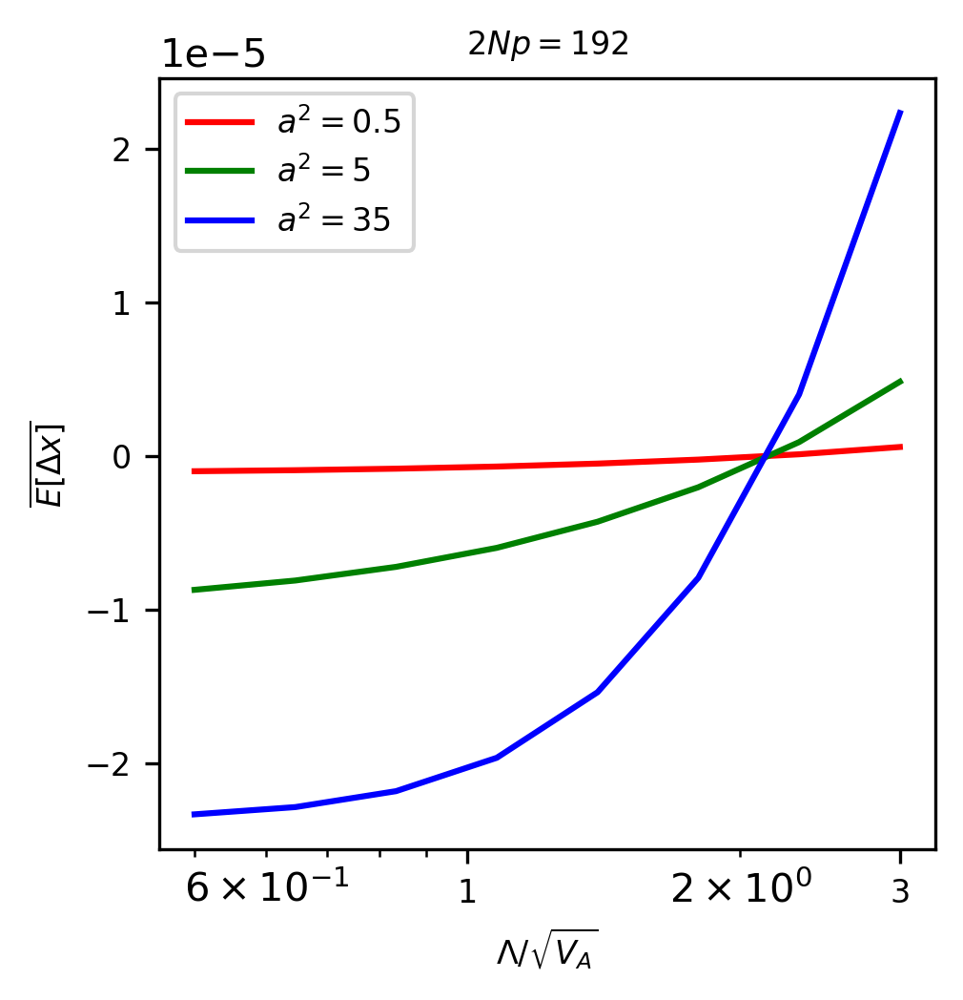

In [17]:
fontsize = 8

N = 2000
U = 0.025
E2Ns = 16

index_rate_of_shift, rate_of_shift = 44, 0.048
shift_s0_partitioning = 29

fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = fig.add_subplot(1, 1, 1)

ss, color = 0.5, 'r'
ax.plot(np.geomspace(0.5, 3, shift_s0_partitioning)[::4], [quad(lambda x_0: (E_Delta_x_stab_sel(a=np.sqrt(ss), x=x_0) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x_0, shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift])) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x_0, shift_s0=-shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]))) * tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0] / quad(lambda x_0: tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0] for index_shift_s0, shift_s0 in enumerate(np.geomspace(0.5, 3, shift_s0_partitioning)) if index_shift_s0 % 4 == 0], color=color, label=r'$a^2=%g$' % ss)
ss, color = 5, 'g'
ax.plot(np.geomspace(0.5, 3, shift_s0_partitioning)[::4], [quad(lambda x_0: (E_Delta_x_stab_sel(a=np.sqrt(ss), x=x_0) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x_0, shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift])) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x_0, shift_s0=-shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]))) * tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0] / quad(lambda x_0: tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0] for index_shift_s0, shift_s0 in enumerate(np.geomspace(0.5, 3, shift_s0_partitioning)) if index_shift_s0 % 4 == 0], color=color, label=r'$a^2=%g$' % ss)
ss, color = 35, 'b'
ax.plot(np.geomspace(0.5, 3, shift_s0_partitioning)[::4], [quad(lambda x_0: (E_Delta_x_stab_sel(a=np.sqrt(ss), x=x_0) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x_0, shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift])) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x_0, shift_s0=-shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]))) * tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0] / quad(lambda x_0: tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0] for index_shift_s0, shift_s0 in enumerate(np.geomspace(0.5, 3, shift_s0_partitioning)) if index_shift_s0 % 4 == 0], color=color, label=r'$a^2=%g$' % ss)

ax.set_xscale('log')
plt.xlabel(r'$\Lambda / \sqrt{V_A}$', fontsize=fontsize)
plt.ylabel(r'$\overline{E[\Delta x]}$', fontsize=fontsize)
plt.xticks(ticks=[1, 3], labels=[1, 3], fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.legend(fontsize=fontsize)
plt.title(r'$2Np=%g$' % (2 * N * rate_of_shift), fontsize=fontsize)
plt.show()

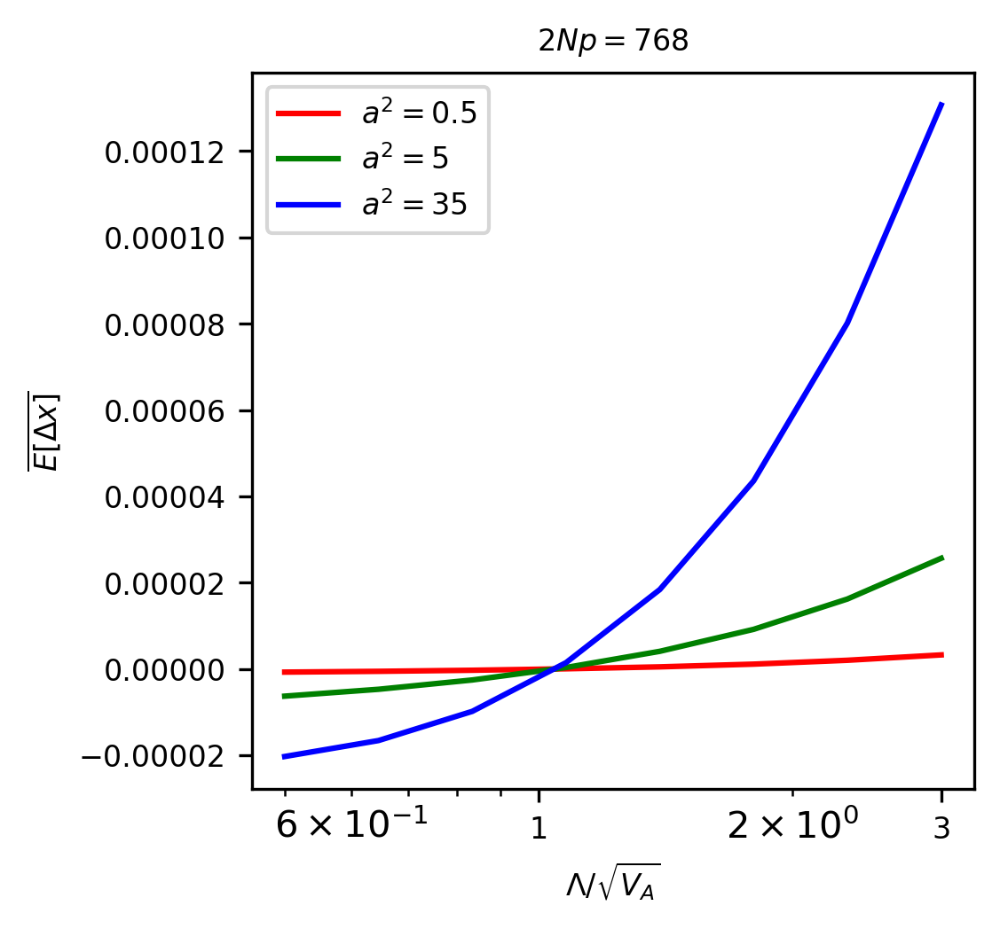

In [18]:
fontsize = 8

N = 2000
U = 0.025
E2Ns = 16

index_rate_of_shift, rate_of_shift = 54, 0.192
shift_s0_partitioning = 29

fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = fig.add_subplot(1, 1, 1)

ss, color = 0.5, 'r'
ax.plot(np.geomspace(0.5, 3, shift_s0_partitioning)[::4], [quad(lambda x_0: (E_Delta_x_stab_sel(a=np.sqrt(ss), x=x_0) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x_0, shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift])) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x_0, shift_s0=-shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]))) * tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0] / quad(lambda x_0: tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0] for index_shift_s0, shift_s0 in enumerate(np.geomspace(0.5, 3, shift_s0_partitioning)) if index_shift_s0 % 4 == 0], color=color, label=r'$a^2=%g$' % ss)
ss, color = 5, 'g'
ax.plot(np.geomspace(0.5, 3, shift_s0_partitioning)[::4], [quad(lambda x_0: (E_Delta_x_stab_sel(a=np.sqrt(ss), x=x_0) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x_0, shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift])) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x_0, shift_s0=-shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]))) * tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0] / quad(lambda x_0: tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0] for index_shift_s0, shift_s0 in enumerate(np.geomspace(0.5, 3, shift_s0_partitioning)) if index_shift_s0 % 4 == 0], color=color, label=r'$a^2=%g$' % ss)
ss, color = 35, 'b'
ax.plot(np.geomspace(0.5, 3, shift_s0_partitioning)[::4], [quad(lambda x_0: (E_Delta_x_stab_sel(a=np.sqrt(ss), x=x_0) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x_0, shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift])) + 0.5 * rate_of_shift * jump_nonlinear(a=np.sqrt(ss), x=x_0, shift_s0=-shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]))) * tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0] / quad(lambda x_0: tau_shifts(a=np.sqrt(ss), x=x_0, p_initial=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift), 0.0, 1.0, points=[1/(2*N)])[0] for index_shift_s0, shift_s0 in enumerate(np.geomspace(0.5, 3, shift_s0_partitioning)) if index_shift_s0 % 4 == 0], color=color, label=r'$a^2=%g$' % ss)

ax.set_xscale('log')
plt.xlabel(r'$\Lambda / \sqrt{V_A}$', fontsize=fontsize)
plt.ylabel(r'$\overline{E[\Delta x]}$', fontsize=fontsize)
plt.xticks(ticks=[1, 3], labels=[1, 3], fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.legend(fontsize=fontsize)
plt.title(r'$2Np=%g$' % (2 * N * rate_of_shift), fontsize=fontsize)
plt.show()

/tmp/ipykernel_2358914/1712020539.py:63: RuntimeWarning: overflow encountered in exp
  return 1 / a * (np.exp(a * shift_s0 / sigma_0_del) - 1) / (1 + x * (np.exp(a * shift_s0 / sigma_0_del) - 1))
/tmp/ipykernel_2358914/1712020539.py:63: RuntimeWarning: invalid value encountered in scalar divide
  return 1 / a * (np.exp(a * shift_s0 / sigma_0_del) - 1) / (1 + x * (np.exp(a * shift_s0 / sigma_0_del) - 1))
/tmp/ipykernel_2358914/1712020539.py:325: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  return np.exp(-2 * quad(lambda z: (E_Delta_x_stab_sel(a, z) + 0.5 * p * quad(lambda shift_s0: np.exp(-shift_s0) * jump_nonlinear(a, z, shift_s0, sigma_0_del), 0.0, np.inf)[0] + 0.5 * p * quad(lambda shift_s0: np.exp(-shift_s0) * jump_nonlinear(a, z, -shift_s0, sigma_0_del), 0.0, np.inf)[0]) / V_Delta_x_drift_and_shifts(a, z, np.sqrt(2), sigma_0_del, p), 0.1, y)[0])
/tmp/ipykernel_

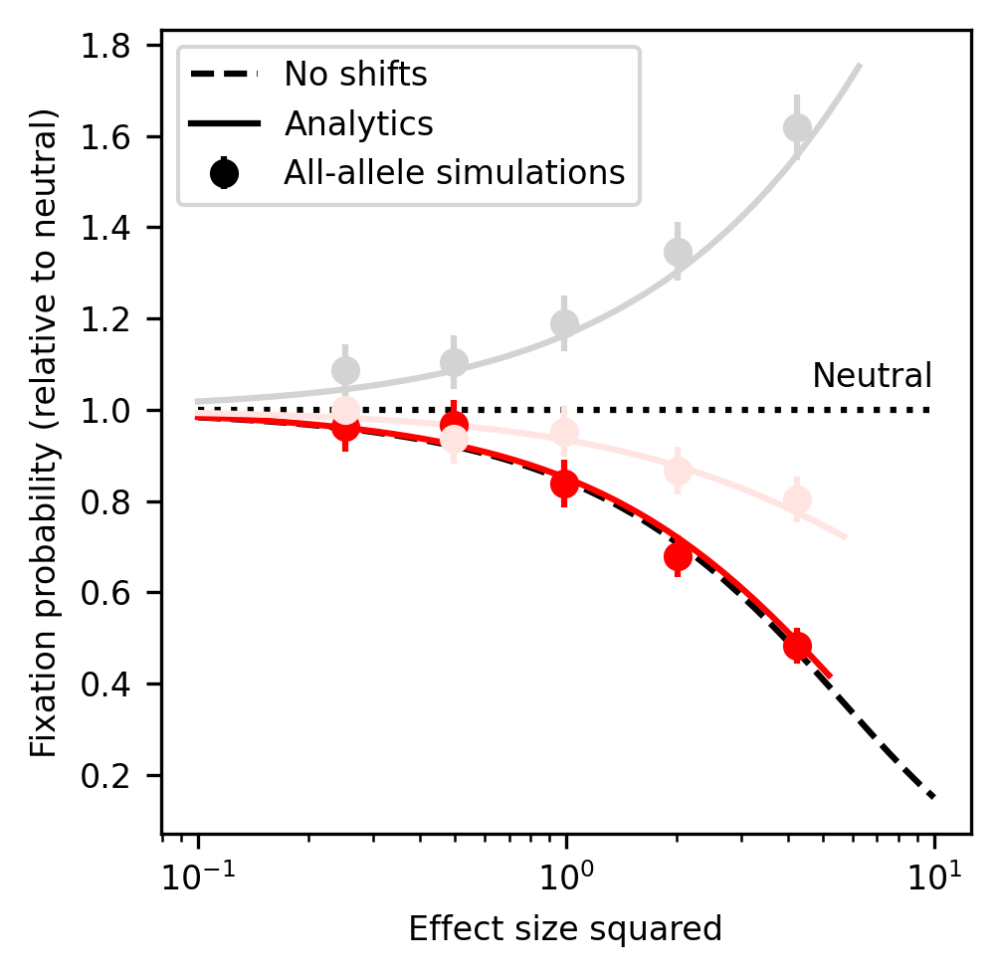

In [5]:
# the fixation probability under recurrent shifts, where the size of each shift independently follows a (Gamma) distribution (the graph shows the three qualitatively different behaviors), in the Lande case
fontsize = 8

N = 2000
U = 0.025
E2Ns = 1
nE = 100
indices_ss = [21, 38, 62, 86, 98]

V2Ns = E2Ns ** 2
S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0.,
                                               scale=float(V2Ns) / float(E2Ns))
a_list_pos = [math.sqrt(S_dist.ppf((i + 1) / (nE + 1))) for i in range(nE)]
a_list_pos_between = [math.sqrt(a * a_next) for a, a_next in pairwise(a_list_pos)]

fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = fig.add_subplot(1, 1, 1)

shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3, 5]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 32
rate_of_shifts_partitioning = 57

neutral, = ax.plot(np.geomspace(0.1, 10), [1 for _ in np.geomspace(0.1, 10)], 'k:')

no_shifts, = ax.plot(np.geomspace(0.1, 10), [pi(a=np.sqrt(ss), x=1.0 / (2 * N)) * 2.0 * N for ss in np.geomspace(0.1, 10)], 'k--')

index_rate_of_shift, rate_of_shift = 9, 0.00075

parallel_AA = 49
num_fixed = np.sum([read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shape_1_scale_1_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_analytic_V_A_%d/num_fixed_nE_%d' % (round(E2Ns), i, nE)) for i in range(1, 1 + parallel_AA)], axis=0)
fixation_probability_mean = dict()
fixation_probability_se = dict()
for index_ss in indices_ss:
    fixation_probability_mean[index_ss] = num_fixed[index_ss + 1] / (10000000 / (nE + 1) * parallel_AA)
    fixation_probability_se[index_ss] = np.sqrt(fixation_probability_mean[index_ss] * (1 - fixation_probability_mean[index_ss]) / (10000000 / (nE + 1) * parallel_AA))
    ax.errorbar(a_list_pos_between[index_ss] ** 2, fixation_probability_mean[index_ss] * 2 * N, yerr=1.96 * fixation_probability_se[index_ss] * 2 * N, fmt='o', color='r')
ax.plot(np.geomspace(0.1, 10), [pi_recurrent_shifts_nonlinear_linear_V_Delta_x_gamma_distributed_shift_sizes(a=np.sqrt(ss), x=1.0 / (2 * N), sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for ss in np.geomspace(0.1, 10)], color='r')

index_rate_of_shift, rate_of_shift = 28, 0.012

parallel_AA = 49
num_fixed = np.sum([read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shape_1_scale_1_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_analytic_V_A_%d/num_fixed_nE_%d' % (round(E2Ns), i, nE)) for i in range(1, 1 + parallel_AA)], axis=0)
fixation_probability_mean = dict()
fixation_probability_se = dict()
for index_ss in indices_ss:
    fixation_probability_mean[index_ss] = num_fixed[index_ss + 1] / (10000000 / (nE + 1) * parallel_AA)
    fixation_probability_se[index_ss] = np.sqrt(fixation_probability_mean[index_ss] * (1 - fixation_probability_mean[index_ss]) / (10000000 / (nE + 1) * parallel_AA))
    ax.errorbar(a_list_pos_between[index_ss] ** 2, fixation_probability_mean[index_ss] * 2 * N, yerr=1.96 * fixation_probability_se[index_ss] * 2 * N, fmt='o', color='mistyrose')
ax.plot(np.geomspace(0.1, 10), [pi_recurrent_shifts_nonlinear_linear_V_Delta_x_gamma_distributed_shift_sizes(a=np.sqrt(ss), x=1.0 / (2 * N), sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for ss in np.geomspace(0.1, 10)], color='mistyrose')

index_rate_of_shift, rate_of_shift = 37, 0.048

parallel_AA = 49
num_fixed = np.sum([read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shape_1_scale_1_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_analytic_V_A_%d/num_fixed_nE_%d' % (round(E2Ns), i, nE)) for i in range(1, 1 + parallel_AA)], axis=0)
fixation_probability_mean = dict()
fixation_probability_se = dict()
for index_ss in indices_ss:
    fixation_probability_mean[index_ss] = num_fixed[index_ss + 1] / (10000000 / (nE + 1) * parallel_AA)
    fixation_probability_se[index_ss] = np.sqrt(fixation_probability_mean[index_ss] * (1 - fixation_probability_mean[index_ss]) / (10000000 / (nE + 1) * parallel_AA))
    ax.errorbar(a_list_pos_between[index_ss] ** 2, fixation_probability_mean[index_ss] * 2 * N, yerr=1.96 * fixation_probability_se[index_ss] * 2 * N, fmt='o', color='lightgray')
ax.plot(np.geomspace(0.1, 10), [pi_recurrent_shifts_nonlinear_linear_V_Delta_x_gamma_distributed_shift_sizes(a=np.sqrt(ss), x=1.0 / (2 * N), sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for ss in np.geomspace(0.1, 10)], color='lightgray')

ax.text(x=10, y=1.05, s='Neutral', horizontalalignment='right', color='k', fontsize=fontsize)

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel('Fixation probability (relative to neutral)', fontsize=fontsize)
ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 1.), loc='upper left', fontsize=fontsize)

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

/tmp/ipykernel_4086487/3618823186.py:37: RuntimeWarning: divide by zero encountered in log
  twoslopelognorm = colors.FuncNorm((lambda x: np.interp(x=np.log(x), xp=[0, np.log(1 / (2 * N) / pi(a=1, x=1.0 / (2 * N))), np.log(z_max)], fp=[0, 0.5, 1]), lambda x: np.exp(np.interp(x=x, xp=[0, 0.5, 1], fp=[0, np.log(1 / (2 * N) / pi(a=1, x=1.0 / (2 * N))), np.log(z_max)]))), vmin=z_min, vmax=z_max)


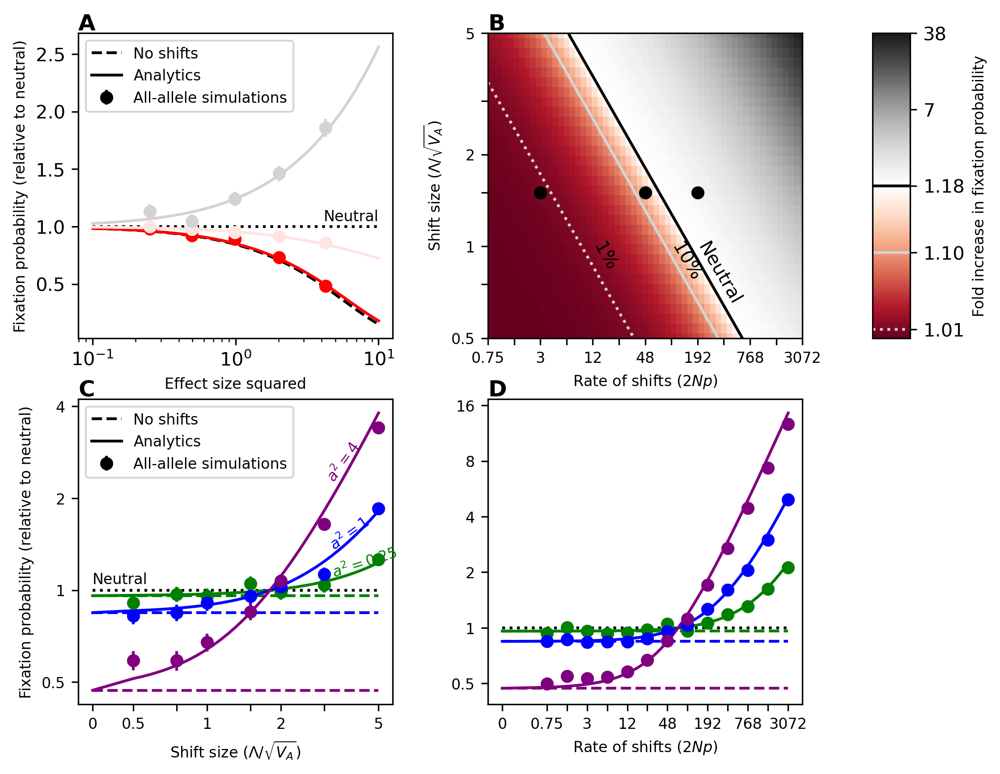

In [7]:
# the fixation probability under recurrent shifts, in the Lande case
fontsize = 8

N = 2000
U = 0.025
E2Ns = 1
nE = 100
indices_ss = [21, 38, 62, 86, 98]

V2Ns = E2Ns ** 2
S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0.,
                                               scale=float(V2Ns) / float(E2Ns))
a_list_pos = [math.sqrt(S_dist.ppf((i + 1) / (nE + 1))) for i in range(nE)]
a_list_pos_between = [math.sqrt(a * a_next) for a, a_next in pairwise(a_list_pos)]

fig = plt.figure(figsize=(8, 6.5), dpi=300)
gs = fig.add_gridspec(2, 5, width_ratios=[25, 3, 25, 1, 3], height_ratios=[1, 1])
# just for spacing
plt.subplot(gs[0, 1]).axis('off')
plt.subplot(gs[1, 1]).axis('off')
plt.subplot(gs[0, 3]).axis('off')
plt.subplot(gs[1, 3]).axis('off')
# not used
plt.subplot(gs[1, 4]).axis('off')
# make gs[0, 4] a colorbar
shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3, 5]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 32
rate_of_shifts_partitioning = 57

x = 2 * N * np.geomspace(rate_of_shifts_list[0] / (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_list[-1] * (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_partitioning + 1)
y = np.geomspace(shift_s0_list[0] / (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_list[-1] * (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_partitioning + 1)
X, Y = np.meshgrid(x, y)

Z = np.array([[pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=1, x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / pi(a=1, x=1.0 / (2 * N)) for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))] for index_shift_s0, shift_s0 in enumerate(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning))])
z_min, z_max = Z.min(), Z.max()

twoslopelognorm = colors.FuncNorm((lambda x: np.interp(x=np.log(x), xp=[0, np.log(1 / (2 * N) / pi(a=1, x=1.0 / (2 * N))), np.log(z_max)], fp=[0, 0.5, 1]), lambda x: np.exp(np.interp(x=x, xp=[0, 0.5, 1], fp=[0, np.log(1 / (2 * N) / pi(a=1, x=1.0 / (2 * N))), np.log(z_max)]))), vmin=z_min, vmax=z_max)
sm = plt.cm.ScalarMappable(cmap='RdGy', norm=twoslopelognorm)
cbar = plt.colorbar(sm, cax=plt.subplot(gs[0, 4]), orientation='vertical')
cbar.set_label('Fold increase in fixation probability', fontsize=fontsize)
cbar.ax.set_yticks([1.01, 1.1, 1 / (2 * N) / pi(a=1, x=1.0 / (2 * N)), np.sqrt(1 / (2 * N) / pi(a=1, x=1.0 / (2 * N)) * z_max), z_max])
cbar.ax.set_yticklabels([1.01, '%.2f' % 1.1, '%.2f' % (1 / (2 * N) / pi(a=1, x=1.0 / (2 * N))), round(np.sqrt(1 / (2 * N) / pi(a=1, x=1.0 / (2 * N)) * z_max)), round(z_max)])
cbar.ax.axhline(y=1.01, color='lightgray', linestyle=':')
cbar.ax.axhline(y=1.1, color='lightgray', linestyle='-')
cbar.ax.axhline(y=1 / (2 * N) / pi(a=1, x=1.0 / (2 * N)), color='k', linestyle='-')
cbar.ax.minorticks_off()
# make the other panels
# panel A: the three qualitatively different behaviors
ax = plt.subplot(gs[0, 0])
ax.text(0, 1.01, 'A', transform=ax.transAxes, fontsize=12, fontweight='bold')

neutral, = ax.plot(np.geomspace(0.1, 10), [1 for _ in np.geomspace(0.1, 10)], 'k:')

no_shifts, = ax.plot(np.geomspace(0.1, 10), [pi(a=np.sqrt(ss), x=1.0 / (2 * N)) * 2.0 * N for ss in np.geomspace(0.1, 10)], 'k--')

index_shift_s0, shift_s0 = 15, 1.5
index_rate_of_shift, rate_of_shift = 9, 0.00075

parallel_AA = 49
num_fixed = np.sum([read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/num_fixed_nE_%d' % (round(E2Ns), i, nE)) for i in range(1, 1 + parallel_AA)], axis=0)
fixation_probability_mean = dict()
fixation_probability_se = dict()
for index_ss in indices_ss:
    fixation_probability_mean[index_ss] = num_fixed[index_ss + 1] / (10000000 / (nE + 1) * parallel_AA)
    fixation_probability_se[index_ss] = np.sqrt(fixation_probability_mean[index_ss] * (1 - fixation_probability_mean[index_ss]) / (10000000 / (nE + 1) * parallel_AA))
    ax.errorbar(a_list_pos_between[index_ss] ** 2, fixation_probability_mean[index_ss] * 2 * N, yerr=1.96 * fixation_probability_se[index_ss] * 2 * N, fmt='o', color='r')
ax.plot(np.geomspace(0.1, 10), [pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for ss in np.geomspace(0.1, 10)], color='r')

index_rate_of_shift, rate_of_shift = 28, 0.012

parallel_AA = 49
num_fixed = np.sum([read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/num_fixed_nE_%d' % (round(E2Ns), i, nE)) for i in range(1, 1 + parallel_AA)], axis=0)
fixation_probability_mean = dict()
fixation_probability_se = dict()
for index_ss in indices_ss:
    fixation_probability_mean[index_ss] = num_fixed[index_ss + 1] / (10000000 / (nE + 1) * parallel_AA)
    fixation_probability_se[index_ss] = np.sqrt(fixation_probability_mean[index_ss] * (1 - fixation_probability_mean[index_ss]) / (10000000 / (nE + 1) * parallel_AA))
    ax.errorbar(a_list_pos_between[index_ss] ** 2, fixation_probability_mean[index_ss] * 2 * N, yerr=1.96 * fixation_probability_se[index_ss] * 2 * N, fmt='o', color='mistyrose')
ax.plot(np.geomspace(0.1, 10), [pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for ss in np.geomspace(0.1, 10)], color='mistyrose')

index_rate_of_shift, rate_of_shift = 37, 0.048

parallel_AA = 49
num_fixed = np.sum([read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/num_fixed_nE_%d' % (round(E2Ns), i, nE)) for i in range(1, 1 + parallel_AA)], axis=0)
fixation_probability_mean = dict()
fixation_probability_se = dict()
for index_ss in indices_ss:
    fixation_probability_mean[index_ss] = num_fixed[index_ss + 1] / (10000000 / (nE + 1) * parallel_AA)
    fixation_probability_se[index_ss] = np.sqrt(fixation_probability_mean[index_ss] * (1 - fixation_probability_mean[index_ss]) / (10000000 / (nE + 1) * parallel_AA))
    ax.errorbar(a_list_pos_between[index_ss] ** 2, fixation_probability_mean[index_ss] * 2 * N, yerr=1.96 * fixation_probability_se[index_ss] * 2 * N, fmt='o', color='lightgray')
ax.plot(np.geomspace(0.1, 10), [pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for ss in np.geomspace(0.1, 10)], color='lightgray')

ax.text(x=10, y=1.05, s='Neutral', horizontalalignment='right', color='k', fontsize=fontsize)

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel('Fixation probability (relative to neutral)', fontsize=fontsize)
ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 1.), loc='upper left', fontsize=fontsize)

# panel B: the effect of recurrent shifts on the fixation probability
ax = plt.subplot(gs[0, 2])
ax.text(0, 1.01, 'B', transform=ax.transAxes, fontsize=12, fontweight='bold')

twoslopelognorm = colors.FuncNorm((lambda x: np.interp(x=np.log(x), xp=[0, np.log(1 / (2 * N) / pi(a=1, x=1.0 / (2 * N))), np.log(z_max)], fp=[0, 0.5, 1]), lambda x: np.exp(np.interp(x=x, xp=[0, 0.5, 1], fp=[0, np.log(1 / (2 * N) / pi(a=1, x=1.0 / (2 * N))), np.log(z_max)]))), vmin=z_min, vmax=z_max)
ax.pcolormesh(X, Y, Z, cmap='RdGy', norm=twoslopelognorm)
ax.plot([analytic_V_A[np.searchsorted(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning), 1)][np.searchsorted(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning), V_A(E2Ns=1) / 1 ** 2 / (2 * N))] / shift_s0 ** 2 for shift_s0 in np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)], np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning), 'k-', label='fixation probability being neutral')
ax.plot(2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning), [np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)[np.searchsorted(Z[:, index_rate_of_shift], 1.1)] if Z[-1, index_rate_of_shift] >= 1.1 and pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=1, x=1.0 / (2 * N), shift_s0=shift_s0_list[0] / (shift_s0_list[-1] / shift_s0_list[0]) ** (1 / (shift_s0_partitioning - 1)), sigma_0_del=np.sqrt(analytic_V_A[0, index_rate_of_shift]), p=rate_of_shift) / pi(a=1, x=1.0 / (2 * N)) < 1.1 else None for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))], color='lightgray', linestyle='-', label='shifts increasing fixation probability by 10%')
ax.plot(2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning), [np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)[np.searchsorted(Z[:, index_rate_of_shift], 1.01)] if Z[-1, index_rate_of_shift] >= 1.01 and pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=1, x=1.0 / (2 * N), shift_s0=shift_s0_list[0] / (shift_s0_list[-1] / shift_s0_list[0]) ** (1 / (shift_s0_partitioning - 1)), sigma_0_del=np.sqrt(analytic_V_A[0, index_rate_of_shift]), p=rate_of_shift) / pi(a=1, x=1.0 / (2 * N)) < 1.01 else None for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))], color='lightgray', linestyle=':', label='shifts increasing fixation probability by 1%')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(2 * N * rate_of_shifts_list[0], 2 * N * rate_of_shifts_list[-1])
ax.set_ylim(shift_s0_list[0], shift_s0_list[-1])
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_ylabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
assert len(shift_s0_list) % 2 == 1
assert len(rate_of_shifts_list) % 2 == 1
ax.set_xticks(ticks=list(2 * N * np.array(rate_of_shifts_list)), labels=[2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
ax.set_yticks(ticks=shift_s0_list, labels=[shift_s0 if index_shift_s0 % 2 == 0 else None for index_shift_s0, shift_s0 in enumerate(shift_s0_list)], fontsize=fontsize)
ax.minorticks_off()
ax.text(x=12, y=1, s='1%', color='k', rotation=-60, rotation_mode='anchor')
ax.text(x=96, y=1, s='10%', color='k', rotation=-60, rotation_mode='anchor')
ax.text(x=192, y=1, s='Neutral', color='k', rotation=-60, rotation_mode='anchor')
ax.scatter(2 * N * np.array([0.00075, 0.012, 0.048]), [1.5, 1.5, 1.5], color='k')

# panels C and D: the fixation probability as a function of the shift size (or the rate of shifts) for a given rate of shifts (or the shift size), for a few effect sizes

ax = plt.subplot(gs[1, 0])
ax.text(0, 1.01, 'C', transform=ax.transAxes, fontsize=12, fontweight='bold')

index_rate_of_shift, rate_of_shift = 28, 0.012

neutral, = ax.plot([0] + shift_s0_list, [1 for _ in [0] + shift_s0_list], 'k:')

simulations = [None, None, None]
no_shifts = [None, None, None]
analytics = [None, None, None]

for i, (index_ss, ss, color) in enumerate([[indices_ss[0], 0.25, 'g'], [indices_ss[2], 1, 'b'], [indices_ss[4], 4.25, 'purple']]):
    parallel_AA = 49
    num_fixed_wrt_shift_s0 = [np.sum([read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/num_fixed_nE_%d' % (round(E2Ns), i, nE))[index_ss] for i in range(1, 1 + parallel_AA)]) for shift_s0 in shift_s0_list]
    fixation_probability_mean_wrt_shift_s0 = np.divide(num_fixed_wrt_shift_s0, (10000000 / (nE + 1) * parallel_AA))
    fixation_probability_se_wrt_shift_s0 = np.sqrt(np.divide(np.multiply(fixation_probability_mean_wrt_shift_s0, np.subtract(1, fixation_probability_mean_wrt_shift_s0)), (10000000 / (nE + 1) * parallel_AA)))
    
    simulations[i] = ax.errorbar(shift_s0_list, fixation_probability_mean_wrt_shift_s0 * 2 * N, yerr=1.96 * fixation_probability_se_wrt_shift_s0 * 2 * N, fmt='o', color=color)

    no_shifts[i], = ax.plot([0] + shift_s0_list, [pi(a=np.sqrt(ss), x=1.0 / (2 * N)) * 2.0 * N for _ in [0] + shift_s0_list], color=color, linestyle='--')

    analytics[i], = ax.plot([0] + list(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)), [pi(a=np.sqrt(ss), x=1.0 / (2 * N)) * 2.0 * N] + [pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for index_shift_s0, shift_s0 in enumerate(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning))], color=color)

ax.text(x=0, y=1.05, s='Neutral', color='k', fontsize=fontsize)
ax.text(x=3.3, y=1.1, s='$a^2=%g$' % 0.25, color='g', rotation=18, rotation_mode='anchor', fontsize=fontsize)
ax.text(x=3.3, y=1.35, s='$a^2=%g$' % 1, color='b', rotation=36, rotation_mode='anchor', fontsize=fontsize)
ax.text(x=3.3, y=2.25, s='$a^2=%g$' % 4, color='purple', rotation=54, rotation_mode='anchor', fontsize=fontsize)

simulation_mean = ax.errorbar([], [], yerr=[], fmt='o', color='k', label='All-allele simulations')
no_shifts_mean, = ax.plot([], [], 'k--', label='No shifts')
analytic_mean, = ax.plot([], [], 'k-', label='Analytics')

ax.set_xscale('symlog', linthresh=shift_s0_list[0], linscale=0.15)
ax.set_yscale('log')
ax.set_xlabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
ax.set_ylabel('Fixation probability (relative to neutral)', fontsize=fontsize)
ax.set_xticks(ticks=[0] + [0.5, 0.75, 1, 1.5, 2, 3, 5], labels=[0] + [0.5, None, 1, None, 2, None, 5], fontsize=fontsize)
ax.set_yticks(ticks=[0.5, 1, 2, 4], labels=[0.5, 1, 2, 4], fontsize=fontsize)
# ax.set_title(r'$E[a^2]=%d, 2Np=%g$' % (round(E2Ns), 2 * N * rate_of_shift), fontsize=fontsize)
ax.legend(handles=[no_shifts_mean, analytic_mean, simulation_mean], bbox_to_anchor=(0., 1.), loc='upper left', fontsize=fontsize)
ax.minorticks_off()

ax = plt.subplot(gs[1, 2])
ax.text(0, 1.01, 'D', transform=ax.transAxes, fontsize=12, fontweight='bold')

index_shift_s0, shift_s0 = 15, 1.5

neutral, = ax.plot([0] + list(2 * N * np.array(rate_of_shifts_list)), [1 for _ in [0] + rate_of_shifts_list], 'k:')

simulations = [None, None, None]
no_shifts = [None, None, None]
analytics = [None, None, None]

for i, (index_ss, ss, color) in enumerate([[indices_ss[0], 0.25, 'g'], [indices_ss[2], 1, 'b'], [indices_ss[4], 4.25, 'purple']]):
    parallel_AA = 49
    num_fixed_wrt_rate_of_shift = [np.sum([read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/num_fixed_nE_%d' % (round(E2Ns), i, nE))[index_ss] for i in range(1, 1 + parallel_AA)]) for rate_of_shift in rate_of_shifts_list]
    fixation_probability_mean_wrt_rate_of_shift = np.divide(num_fixed_wrt_rate_of_shift, (10000000 / (nE + 1) * parallel_AA))
    fixation_probability_se_wrt_rate_of_shift = np.sqrt(np.divide(np.multiply(fixation_probability_mean_wrt_rate_of_shift, np.subtract(1, fixation_probability_mean_wrt_rate_of_shift)), (10000000 / (nE + 1) * parallel_AA)))
    
    simulations[i] = ax.errorbar(2 * N * np.array(rate_of_shifts_list), fixation_probability_mean_wrt_rate_of_shift * 2 * N, yerr=1.96 * fixation_probability_se_wrt_rate_of_shift * 2 * N, fmt='o', color=color)

    no_shifts[i], = ax.plot([0] + list(2 * N * np.array(rate_of_shifts_list)), [pi(a=np.sqrt(ss), x=1.0 / (2 * N)) * 2.0 * N for _ in [0] + rate_of_shifts_list], color=color, linestyle='--')

    analytics[i], = ax.plot([0] + list(2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)), [pi(a=np.sqrt(ss), x=1.0 / (2 * N)) * 2.0 * N] + [pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))], color=color)

simulation_mean = ax.errorbar([], [], yerr=[], fmt='o', color='k')
no_shifts_mean, = ax.plot([], [], 'k--')
analytic_mean, = ax.plot([], [], 'k-')

ax.set_xscale('symlog', linthresh=2 * N * rate_of_shifts_list[0], linscale=0.6)
ax.set_yscale('log')
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_xticks(ticks=[0] + [0.75, 1.5, 3, 6, 12, 24, 48, 96, 192, 384, 768, 1536, 3072], labels=[0] + [0.75, None, 3, None, 12, None, 48, None, 192, None, 768, None, 3072], fontsize=fontsize)
ax.set_yticks(ticks=[0.5, 1, 2, 4, 8, 16], labels=[0.5, 1, 2, 4, 8, 16], fontsize=fontsize)
# ax.set_title(r'$E[a^2]=%d, \Lambda=%g\sqrt{V_A}$' % (round(E2Ns), shift_s0), fontsize=fontsize)
ax.minorticks_off()

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

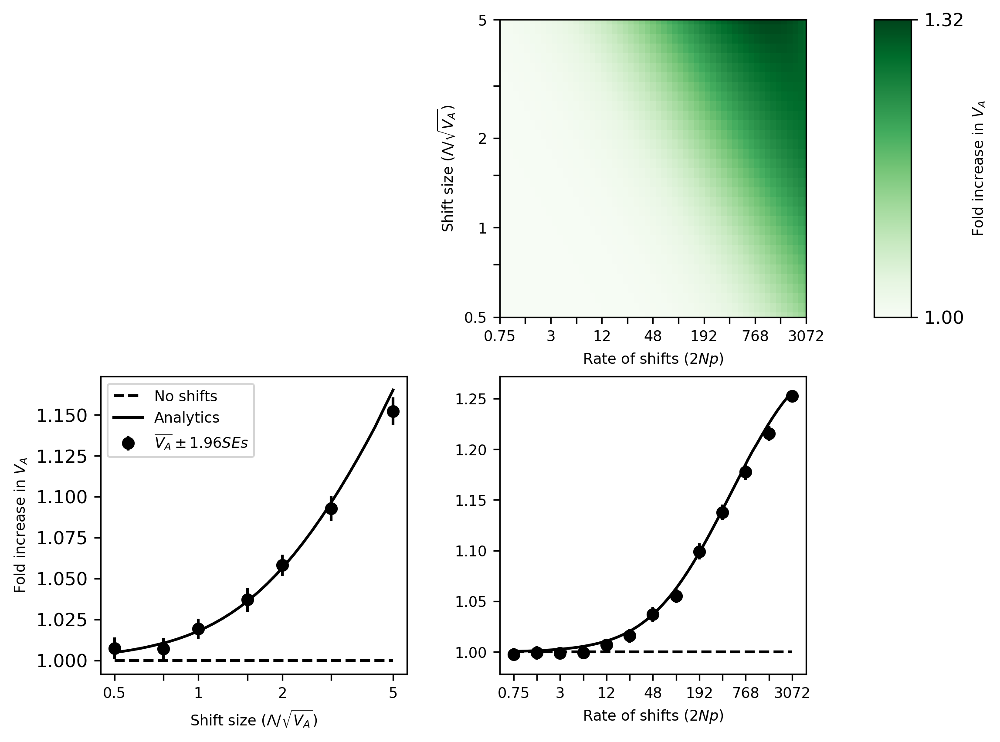

In [7]:
# the analytic V_A, in the Lande case

fontsize = 8

N = 2000
U = 0.025
E2Ns = 1

fig = plt.figure(figsize=(8, 6.5), dpi=300)
gs = fig.add_gridspec(2, 5, width_ratios=[25, 3, 25, 1, 3], height_ratios=[1, 1])
# just for spacing
plt.subplot(gs[0, 1]).axis('off')
plt.subplot(gs[1, 1]).axis('off')
plt.subplot(gs[0, 3]).axis('off')
plt.subplot(gs[1, 3]).axis('off')
# not used
plt.subplot(gs[0, 0]).axis('off')
plt.subplot(gs[1, 4]).axis('off')
# make gs[0, 4] a colorbar
norm = colors.Normalize(vmin=analytic_V_A.min() / V_A(E2Ns=E2Ns), vmax=analytic_V_A.max() / V_A(E2Ns=E2Ns))
sm = plt.cm.ScalarMappable(cmap='Greens', norm=norm)
cbar = plt.colorbar(sm, cax=plt.subplot(gs[0, 4]), orientation='vertical')
cbar.set_label(r'Fold increase in $V_A$', fontsize=fontsize)
cbar.ax.set_yticks([analytic_V_A.min() / V_A(E2Ns=E2Ns), analytic_V_A.max() / V_A(E2Ns=E2Ns)])
cbar.ax.set_yticklabels(['%.2f' % (analytic_V_A.min() / V_A(E2Ns=E2Ns)), '%.2f' % (analytic_V_A.max() / V_A(E2Ns=E2Ns))])
cbar.ax.minorticks_off()

# panel B: the effect of recurrent shifts on the analytic V_A
ax = plt.subplot(gs[0, 2])

shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3, 5]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 32
rate_of_shifts_partitioning = 57

x = 2 * N * np.geomspace(rate_of_shifts_list[0] / (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_list[-1] * (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_partitioning + 1)
y = np.geomspace(shift_s0_list[0] / (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_list[-1] * (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_partitioning + 1)
X, Y = np.meshgrid(x, y)
ax.pcolormesh(X, Y, np.divide(analytic_V_A, V_A(E2Ns=E2Ns)), cmap='Greens', norm=norm)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(2 * N * rate_of_shifts_list[0], 2 * N * rate_of_shifts_list[-1])
ax.set_ylim(shift_s0_list[0], shift_s0_list[-1])
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_ylabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
assert len(shift_s0_list) % 2 == 1
assert len(rate_of_shifts_list) % 2 == 1
ax.set_xticks(ticks=list(2 * N * np.array(rate_of_shifts_list)), labels=[2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
ax.set_yticks(ticks=shift_s0_list, labels=[shift_s0 if index_shift_s0 % 2 == 0 else None for index_shift_s0, shift_s0 in enumerate(shift_s0_list)], fontsize=fontsize)
ax.minorticks_off()

# panels C and D: the analytic V_A as a function of the shift size (or the rate of shifts) for a given rate of shifts (or shift size)
empirical_V_A_mean = np.zeros((7, 13))
empirical_V_A_se = np.zeros((7, 13))
for E2Ns, index_shift_s0, shift_s0, index_rate_of_shift, rate_of_shift in [(E2Ns, index_shift_s0, shift_s0, index_rate_of_shift, rate_of_shift) for E2Ns in [E2Ns, ] for index_shift_s0, shift_s0 in enumerate(shift_s0_list) for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)]:
    parallel_AA = 49
    var_ess_every_10N_generations = list()
    for i in range(1, 1 + parallel_AA):
        with open('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_nE_%d_empirical_average_V_A_%d/fixation_probability' % (round(E2Ns), 11, i), 'rb') as f:
            var_ess_every_10N_generations.extend(pickle.load(f)[3][10 * N::10 * N])
    empirical_V_A_mean[index_shift_s0][index_rate_of_shift] = np.mean(var_ess_every_10N_generations)
    empirical_V_A_se[index_shift_s0][index_rate_of_shift] = np.std(var_ess_every_10N_generations) / np.sqrt(np.size(var_ess_every_10N_generations))

ax = plt.subplot(gs[1, 0])
index_rate_of_shift, rate_of_shift = 28, 0.012
ax.plot(shift_s0_list, [1 for _ in shift_s0_list], 'k--', label='No shifts')
ax.plot(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning), np.divide(analytic_V_A[:, index_rate_of_shift], V_A(E2Ns=E2Ns)), 'k-', label='Analytics')
ax.errorbar(shift_s0_list, np.divide(empirical_V_A_mean[:, np.searchsorted(rate_of_shifts_list, rate_of_shift)], V_A(E2Ns=E2Ns)), yerr=1.96 * np.divide(empirical_V_A_se[:, np.searchsorted(rate_of_shifts_list, rate_of_shift)], V_A(E2Ns=E2Ns)), fmt='o', color='k', label=r'$\overline{V_A} \pm 1.96SEs$')
ax.set_xscale('log')
ax.set_xlabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
ax.set_ylabel(r'Fold increase in $V_A$', fontsize=fontsize)
ax.set_xticks(ticks=shift_s0_list, labels=[shift_s0 if index_shift_s0 % 2 == 0 else None for index_shift_s0, shift_s0 in enumerate(shift_s0_list)], fontsize=fontsize)
# ax.set_title('$E[a^2]=%d, 2Np=%g$' % (round(E2Ns), 2 * N * rate_of_shift), fontsize=fontsize)
ax.legend(bbox_to_anchor=(0., 1.), loc='upper left', fontsize=fontsize)
ax.minorticks_off()

ax = plt.subplot(gs[1, 2])
index_shift_s0, shift_s0 = 15, 1.5
ax.plot(2 * N * np.array(rate_of_shifts_list), [1 for _ in rate_of_shifts_list], 'k--', label='No shifts')
ax.plot(2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning), np.divide(analytic_V_A[index_shift_s0], V_A(E2Ns=E2Ns)), 'k-', label='Analytics')
ax.errorbar(2 * N * np.array(rate_of_shifts_list), np.divide(empirical_V_A_mean[np.searchsorted(shift_s0_list, shift_s0)], V_A(E2Ns=E2Ns)), yerr=1.96 * np.divide(empirical_V_A_se[np.searchsorted(shift_s0_list, shift_s0)], V_A(E2Ns=E2Ns)), fmt='o', color='k', label=r'$\overline{V_A} \pm 1.96SEs$')
ax.set_xscale('log')
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_xticks(ticks=list(2 * N * np.array(rate_of_shifts_list)), labels=[2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
# ax.set_title('$E[a^2]=%d, \Lambda=%g\sqrt{V_A}$' % (round(E2Ns), shift_s0), fontsize=fontsize)
ax.minorticks_off()

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

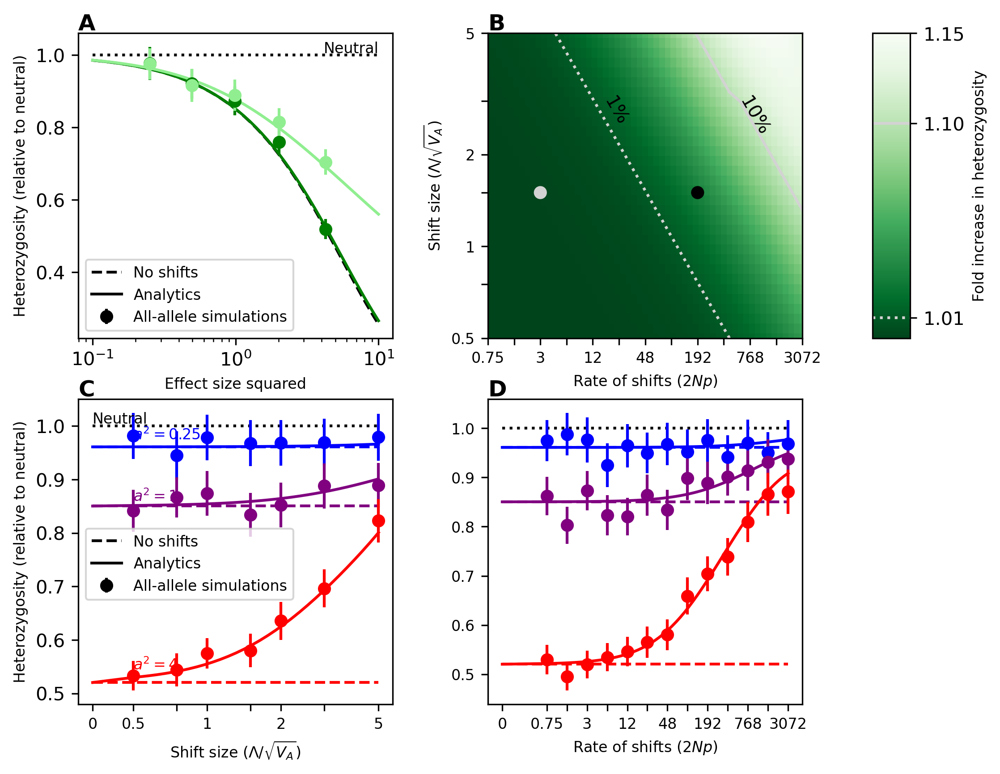

In [10]:
# the heterozygosity under recurrent shifts, in the Lande case
fontsize = 8

N = 2000
U = 0.025
E2Ns = 1
nE = 100
indices_ss = [21, 38, 62, 86, 98]

V2Ns = E2Ns ** 2
S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0.,
                                               scale=float(V2Ns) / float(E2Ns))
a_list_pos = [math.sqrt(S_dist.ppf((i + 1) / (nE + 1))) for i in range(nE)]
a_list_pos_between = [math.sqrt(a * a_next) for a, a_next in pairwise(a_list_pos)]

fig = plt.figure(figsize=(8, 6.5), dpi=300)
gs = fig.add_gridspec(2, 5, width_ratios=[25, 3, 25, 1, 3], height_ratios=[1, 1])
# just for spacing
plt.subplot(gs[0, 1]).axis('off')
plt.subplot(gs[1, 1]).axis('off')
plt.subplot(gs[0, 3]).axis('off')
plt.subplot(gs[1, 3]).axis('off')
# not used
plt.subplot(gs[1, 4]).axis('off')
# make gs[0, 4] a colorbar
shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3, 5]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 32
rate_of_shifts_partitioning = 57

x = 2 * N * np.geomspace(rate_of_shifts_list[0] / (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_list[-1] * (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_partitioning + 1)
y = np.geomspace(shift_s0_list[0] / (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_list[-1] * (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_partitioning + 1)
X, Y = np.meshgrid(x, y)

Z = np.empty((shift_s0_partitioning, rate_of_shifts_partitioning))
for index_shift_s0 in range(shift_s0_partitioning):
    for index_rate_of_shift in range(rate_of_shifts_partitioning):
        with open('/insomnia001/depts/pas_lab/users/jc5473/analytic_heterozygosity_N_%d_U_' % N + str(U).replace('.', '_') + '_index_shift_s0_%d_index_rate_of_shift_%d_E2Ns_%d' % (index_shift_s0, index_rate_of_shift, round(E2Ns)), 'rb') as f:
            Z[index_shift_s0, index_rate_of_shift] = pickle.load(f)
Z = np.divide(Z, heterozygosity_(a=1))
z_min, z_max = Z.min(), Z.max()

norm = colors.Normalize(vmin=z_min, vmax=z_max)
sm = plt.cm.ScalarMappable(cmap='Greens_r', norm=norm)
cbar = plt.colorbar(sm, cax=plt.subplot(gs[0, 4]), orientation='vertical')
cbar.set_label('Fold increase in heterozygosity', fontsize=fontsize)
cbar.ax.set_yticks([1.01, 1.105, z_max])
cbar.ax.set_yticklabels([1.01, '%.2f' % 1.1, '%.2f' % z_max])
cbar.ax.axhline(y=1.01, color='lightgray', linestyle=':')
cbar.ax.axhline(y=1.105, color='lightgray', linestyle='-')
cbar.ax.minorticks_off()
# make the other panels
# panel A: the two qualitatively different behaviors
ax = plt.subplot(gs[0, 0])
ax.text(0, 1.01, 'A', transform=ax.transAxes, fontsize=12, fontweight='bold')

neutral, = ax.plot(np.geomspace(0.1, 10), [1 for _ in np.geomspace(0.1, 10)], 'k:')

no_shifts, = ax.plot(np.geomspace(0.1, 10), [heterozygosity_(a=np.sqrt(ss)) / heterozygosity_(a=0.1) for ss in np.geomspace(0.1, 10)], 'k--')

index_shift_s0, shift_s0 = 15, 1.5
index_rate_of_shift, rate_of_shift = 9, 0.00075

heterozygosity_each_generation = dict()
heterozygosity_mean = dict()
heterozygosity_se = dict()
for index_ss in indices_ss:
    heterozygosity_each_generation[index_ss] = [h for i in range(1, 1 + parallel_AA) for h in read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/heterozygosity_nE_%d' % (round(E2Ns), i, nE))[index_ss + 1]]
    heterozygosity_mean[index_ss] = np.mean(heterozygosity_each_generation[index_ss])
    heterozygosity_se[index_ss] = np.divide(np.std(heterozygosity_each_generation[index_ss]), np.sqrt(np.size(heterozygosity_each_generation[index_ss])))
for index_ss in indices_ss:
    ax.errorbar(a_list_pos_between[index_ss] ** 2, heterozygosity_mean[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_(a=0.1), yerr=1.96 * heterozygosity_se[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_(a=0.1), fmt='o', color='g')
ax.plot(np.geomspace(0.1, 10), [heterozygosity_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / heterozygosity_(a=0.1) for ss in np.geomspace(0.1, 10)], color='g')

index_rate_of_shift, rate_of_shift = 37, 0.048

heterozygosity_each_generation = dict()
heterozygosity_mean = dict()
heterozygosity_se = dict()
for index_ss in indices_ss:
    heterozygosity_each_generation[index_ss] = [h for i in range(1, 1 + parallel_AA) for h in read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/heterozygosity_nE_%d' % (round(E2Ns), i, nE))[index_ss + 1]]
    heterozygosity_mean[index_ss] = np.mean(heterozygosity_each_generation[index_ss])
    heterozygosity_se[index_ss] = np.divide(np.std(heterozygosity_each_generation[index_ss]), np.sqrt(np.size(heterozygosity_each_generation[index_ss])))
for index_ss in indices_ss:
    ax.errorbar(a_list_pos_between[index_ss] ** 2, heterozygosity_mean[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_(a=0.1), yerr=1.96 * heterozygosity_se[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_(a=0.1), fmt='o', color='lightgreen')
ax.plot(np.geomspace(0.1, 10), [heterozygosity_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / heterozygosity_(a=0.1) for ss in np.geomspace(0.1, 10)], color='lightgreen')

ax.text(x=10, y=1.005, s='Neutral', horizontalalignment='right', color='k', fontsize=fontsize)

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel('Heterozygosity (relative to neutral)', fontsize=fontsize)
ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 0.), loc='lower left', fontsize=fontsize)

# the effect of recurrent shifts on the heterozygosity
ax = plt.subplot(gs[0, 2])
ax.text(0, 1.01, 'B', transform=ax.transAxes, fontsize=12, fontweight='bold')

norm = colors.Normalize(vmin=z_min, vmax=z_max)
ax.pcolormesh(X, Y, Z, cmap='Greens_r', norm=norm)
ax.plot([2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)[np.searchsorted(Z[index_shift_s0, :], 1.105)] if Z[index_shift_s0, -1] >= 1.105 else None for index_shift_s0, shift_s0 in enumerate(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning))], np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning), color='lightgray', linestyle='-')
ax.plot([2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)[np.searchsorted(Z[index_shift_s0, :], 1.01)] if Z[index_shift_s0, -1] >= 1.01 else None for index_shift_s0, shift_s0 in enumerate(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning))], np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning), color='lightgray', linestyle=':')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(2 * N * rate_of_shifts_list[0], 2 * N * rate_of_shifts_list[-1])
ax.set_ylim(shift_s0_list[0], shift_s0_list[-1])
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_ylabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
assert len(shift_s0_list) % 2 == 1
assert len(rate_of_shifts_list) % 2 == 1
ax.set_xticks(ticks=list(2 * N * np.array(rate_of_shifts_list)), labels=[2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
ax.set_yticks(ticks=shift_s0_list, labels=[shift_s0 if index_shift_s0 % 2 == 0 else None for index_shift_s0, shift_s0 in enumerate(shift_s0_list)], fontsize=fontsize)
ax.minorticks_off()
ax.text(x=16, y=3, s='1%', color='k', rotation=-60, rotation_mode='anchor')
ax.text(x=576, y=3, s='10%', color='k', rotation=-60, rotation_mode='anchor')
ax.scatter(2 * N * np.array([0.00075, 0.048]), [1.5, 1.5], color=['lightgray', 'k'])

# panels C and D: the heterozygosity as a function of the shift size (or the rate of shifts) for a given rate of shifts (or shift size), for a few effect sizes

ax = plt.subplot(gs[1, 0])
ax.text(0, 1.01, 'C', transform=ax.transAxes, fontsize=12, fontweight='bold')

index_rate_of_shift, rate_of_shift = 28, 0.012

neutral, = ax.plot([0] + shift_s0_list, [1 for _ in [0] + shift_s0_list], 'k:')

simulations = [None, None, None]
no_shifts = [None, None, None]
analytics = [None, None, None]

for i, (index_ss, ss, color) in enumerate([[indices_ss[0], 0.25, 'b'], [indices_ss[2], 1, 'purple'], [indices_ss[4], 4.25, 'r']]):
    parallel_AA = 49
    heterozygosity_mean_wrt_shift_s0 = list()
    heterozygosity_se_wrt_shift_s0 = list()
    for shift_s0 in shift_s0_list:
        heterozygosity_each_generation = [h for j in range(1, 1 + parallel_AA) for h in read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/heterozygosity_nE_%d' % (round(E2Ns), j, nE))[index_ss + 1]]
        heterozygosity_mean = np.mean(heterozygosity_each_generation)
        heterozygosity_se = np.divide(np.std(heterozygosity_each_generation), np.sqrt(np.size(heterozygosity_each_generation)))
        heterozygosity_mean_wrt_shift_s0 += [heterozygosity_mean]
        heterozygosity_se_wrt_shift_s0 += [heterozygosity_se]
    simulations[i] = ax.errorbar(shift_s0_list, np.divide(heterozygosity_mean_wrt_shift_s0, 2 * N * U / (nE + 1) * heterozygosity_(a=0.1)), yerr=1.96 * np.divide(heterozygosity_se_wrt_shift_s0, 2 * N * U / (nE + 1) * heterozygosity_(a=0.1)), fmt='o', color=color)
    no_shifts[i], = ax.plot([0] + shift_s0_list, [heterozygosity_(a=np.sqrt(ss)) / heterozygosity_(a=0.1) for _ in [0] + shift_s0_list], color=color, linestyle='--')
    analytics[i], = ax.plot([0] + list(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)), [heterozygosity_(a=np.sqrt(ss)) / heterozygosity_(a=0.1)] + [heterozygosity_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / heterozygosity_(a=0.1) for index_shift_s0, shift_s0 in enumerate(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning))], color=color)

ax.text(x=0, y=1.005, s='Neutral', color='k', fontsize=fontsize)
ax.text(x=shift_s0_list[0], y=0.975, s='$a^2=%g$' % 0.25, color='b', fontsize=fontsize)
ax.text(x=shift_s0_list[0], y=0.86, s='$a^2=%g$' % 1, color='purple', fontsize=fontsize)
ax.text(x=shift_s0_list[0], y=0.545, s='$a^2=%g$' % 4, color='r', fontsize=fontsize)

simulation_mean = ax.errorbar([], [], yerr=[], fmt='o', color='k', label='All-allele simulations')
no_shifts_mean, = ax.plot([], [], 'k--', label='No shifts')
analytic_mean, = ax.plot([], [], 'k-', label='Analytics')

ax.set_xscale('symlog', linthresh=shift_s0_list[0], linscale=0.15)
ax.set_xlabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
ax.set_ylabel('Heterozygosity (relative to neutral)', fontsize=fontsize)
ax.set_xticks(ticks=[0] + shift_s0_list, labels=[0] + [shift_s0 if index_shift_s0 % 2 == 0 else None for index_shift_s0, shift_s0 in enumerate(shift_s0_list)], fontsize=fontsize)
# ax.set_title('$E[a^2]=%d, 2Np=%g$' % (round(E2Ns), 2 * N * rate_of_shift), fontsize=fontsize)
ax.legend(bbox_to_anchor=(0., 0.6), loc='upper left', fontsize=fontsize)
ax.minorticks_off()

ax = plt.subplot(gs[1, 2])
ax.text(0, 1.01, 'D', transform=ax.transAxes, fontsize=12, fontweight='bold')

index_shift_s0, shift_s0 = 15, 1.5

neutral, = ax.plot([0] + list(2 * N * np.array(rate_of_shifts_list)), [1 for _ in [0] + rate_of_shifts_list], 'k:')

simulations = [None, None, None]
no_shifts = [None, None, None]
analytics = [None, None, None]

for i, (index_ss, ss, color) in enumerate([[indices_ss[0], 0.25, 'b'], [indices_ss[2], 1, 'purple'], [indices_ss[4], 4.25, 'r']]):
    parallel_AA = 49
    heterozygosity_mean_wrt_rate_of_shifts = list()
    heterozygosity_se_wrt_rate_of_shifts = list()
    for rate_of_shift in rate_of_shifts_list:
        heterozygosity_each_generation = [h for j in range(1, 1 + parallel_AA) for h in read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/heterozygosity_nE_%d' % (round(E2Ns), j, nE))[index_ss + 1]]
        heterozygosity_mean = np.mean(heterozygosity_each_generation)
        heterozygosity_se = np.divide(np.std(heterozygosity_each_generation), np.sqrt(np.size(heterozygosity_each_generation)))
        heterozygosity_mean_wrt_rate_of_shifts += [heterozygosity_mean]
        heterozygosity_se_wrt_rate_of_shifts += [heterozygosity_se]
    simulations[i] = ax.errorbar(2 * N * np.array(rate_of_shifts_list), np.divide(heterozygosity_mean_wrt_rate_of_shifts, 2 * N * U / (nE + 1) * heterozygosity_(a=0.1)), yerr=1.96 * np.divide(heterozygosity_se_wrt_rate_of_shifts, 2 * N * U / (nE + 1) * heterozygosity_(a=0.1)), fmt='o', color=color)
    no_shifts[i], = ax.plot([0] + list(2 * N * np.array(rate_of_shifts_list)), [heterozygosity_(a=np.sqrt(ss)) / heterozygosity_(a=0.1) for _ in [0] + rate_of_shifts_list], color=color, linestyle='--')
    analytics[i], = ax.plot([0] + list(2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)), [heterozygosity_(a=np.sqrt(ss)) / heterozygosity_(a=0.1)] + [heterozygosity_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / heterozygosity_(a=0.1) for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))], color=color)

ax.set_xscale('symlog', linthresh=2 * N * rate_of_shifts_list[0], linscale=0.6)
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_xticks(ticks=[0] + list(2 * N * np.array(rate_of_shifts_list)), labels=[0] + [2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
# ax.set_title('$E[a^2]=%d, \Lambda=%g\sqrt{V_A}$' % (round(E2Ns), shift_s0), fontsize=fontsize)
ax.minorticks_off()

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

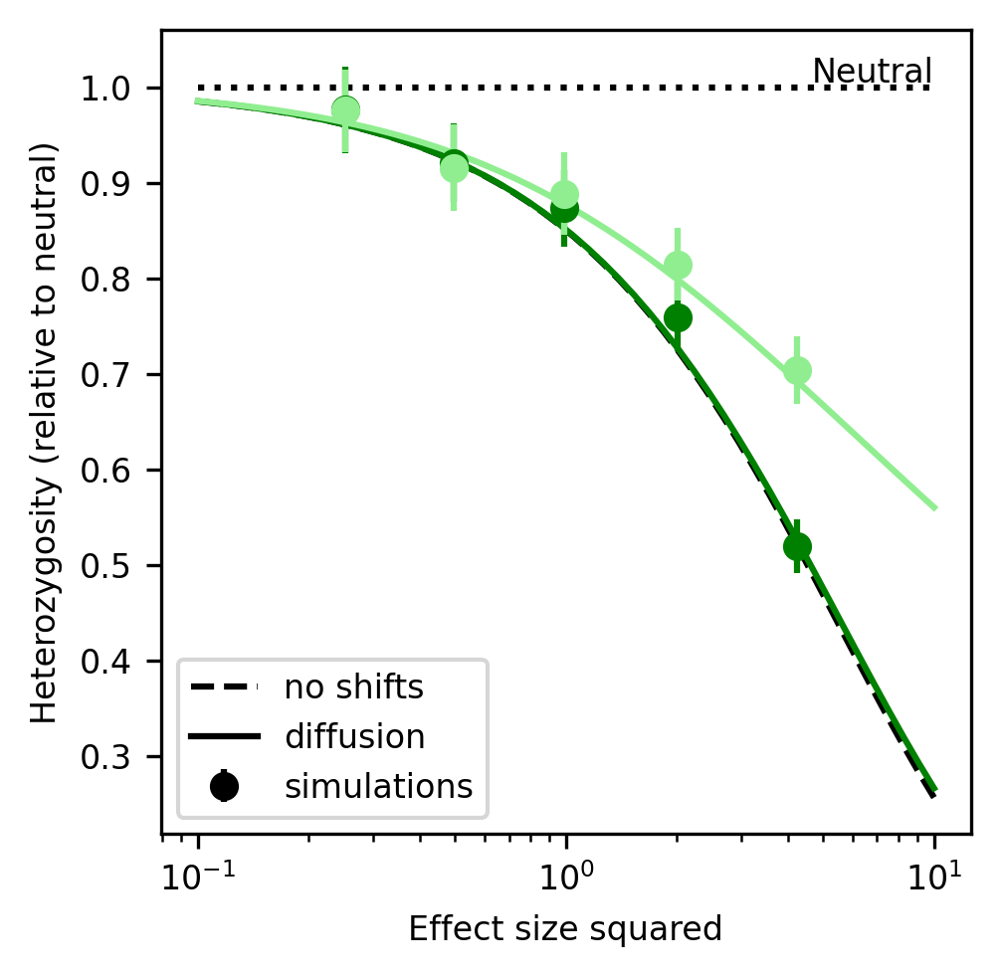

In [7]:
fontsize = 8

N = 2000
U = 0.025
E2Ns = 1
nE = 100
indices_ss = [21, 38, 62, 86, 98]

V2Ns = E2Ns ** 2
S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0.,
                                               scale=float(V2Ns) / float(E2Ns))
a_list_pos = [math.sqrt(S_dist.ppf((i + 1) / (nE + 1))) for i in range(nE)]
a_list_pos_between = [math.sqrt(a * a_next) for a, a_next in pairwise(a_list_pos)]

fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = fig.add_subplot(1, 1, 1)

shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3, 5]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 32
rate_of_shifts_partitioning = 57

neutral, = ax.plot(np.geomspace(0.1, 10), [1 for _ in np.geomspace(0.1, 10)], 'k:')

no_shifts, = ax.plot(np.geomspace(0.1, 10), [heterozygosity_(a=np.sqrt(ss)) / heterozygosity_(a=0.1) for ss in np.geomspace(0.1, 10)], 'k--')

index_shift_s0, shift_s0 = 15, 1.5
index_rate_of_shift, rate_of_shift = 9, 0.00075

parallel_AA = 49
heterozygosity_each_generation = dict()
heterozygosity_mean = dict()
heterozygosity_se = dict()
for index_ss in indices_ss:
    heterozygosity_each_generation[index_ss] = [h for i in range(1, 1 + parallel_AA) for h in read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/heterozygosity_nE_%d' % (round(E2Ns), i, nE))[index_ss + 1]]
    heterozygosity_mean[index_ss] = np.mean(heterozygosity_each_generation[index_ss])
    heterozygosity_se[index_ss] = np.divide(np.std(heterozygosity_each_generation[index_ss]), np.sqrt(np.size(heterozygosity_each_generation[index_ss])))
for index_ss in indices_ss:
    ax.errorbar(a_list_pos_between[index_ss] ** 2, heterozygosity_mean[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_(a=0.1), yerr=1.96 * heterozygosity_se[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_(a=0.1), fmt='o', color='g')
ax.plot(np.geomspace(0.1, 10), [heterozygosity_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / heterozygosity_(a=0.1) for ss in np.geomspace(0.1, 10)], color='g')

index_rate_of_shift, rate_of_shift = 37, 0.048

parallel_AA = 49
heterozygosity_each_generation = dict()
heterozygosity_mean = dict()
heterozygosity_se = dict()
for index_ss in indices_ss:
    heterozygosity_each_generation[index_ss] = [h for i in range(1, 1 + parallel_AA) for h in read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/heterozygosity_nE_%d' % (round(E2Ns), i, nE))[index_ss + 1]]
    heterozygosity_mean[index_ss] = np.mean(heterozygosity_each_generation[index_ss])
    heterozygosity_se[index_ss] = np.divide(np.std(heterozygosity_each_generation[index_ss]), np.sqrt(np.size(heterozygosity_each_generation[index_ss])))
for index_ss in indices_ss:
    ax.errorbar(a_list_pos_between[index_ss] ** 2, heterozygosity_mean[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_(a=0.1), yerr=1.96 * heterozygosity_se[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_(a=0.1), fmt='o', color='lightgreen')
ax.plot(np.geomspace(0.1, 10), [heterozygosity_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / heterozygosity_(a=0.1) for ss in np.geomspace(0.1, 10)], color='lightgreen')

ax.text(x=10, y=1.005, s='Neutral', horizontalalignment='right', color='k', fontsize=fontsize)

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel('Heterozygosity (relative to neutral)', fontsize=fontsize)
ax.legend(handles=[no_shifts, analytics, simulations], labels=['no shifts', 'diffusion', 'simulations'], bbox_to_anchor=(0., 0.), loc='lower left', fontsize=fontsize)

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

/insomnia001/home/jc5473/miniconda3/envs/conda-env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/insomnia001/home/jc5473/miniconda3/envs/conda-env/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/insomnia001/home/jc5473/miniconda3/envs/conda-env/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/insomnia001/home/jc5473/miniconda3/envs/conda-env/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/insomnia001/home/jc5473/miniconda3/envs/conda-env/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divi

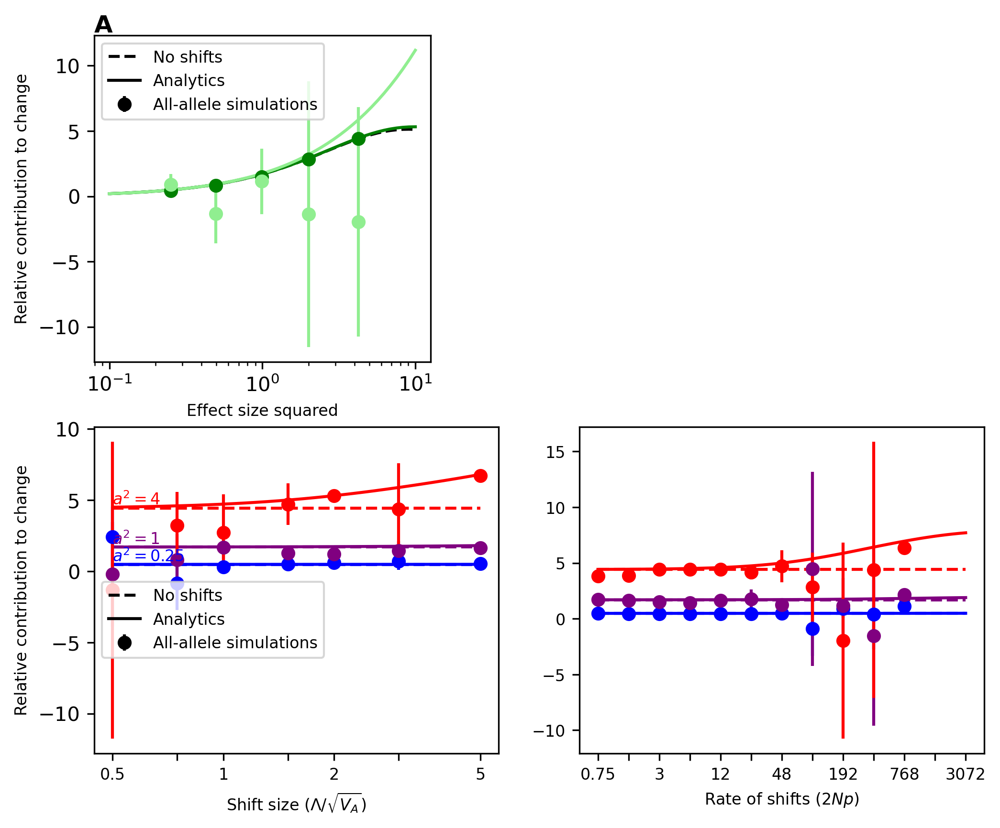

In [5]:
# the relative allelic contribution to the short-term phenotypic change after a shift, in the Lande case
fontsize = 8

N = 2000
U = 0.025
E2Ns = 1
nE = 100
indices_ss = [21, 38, 62, 86, 98]

V2Ns = E2Ns ** 2
S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0.,
                                               scale=float(V2Ns) / float(E2Ns))
a_list_pos = [math.sqrt(S_dist.ppf((i + 1) / (nE + 1))) for i in range(nE)]
a_list_pos_between = [math.sqrt(a * a_next) for a, a_next in pairwise(a_list_pos)]

fig = plt.figure(figsize=(8, 6.5), dpi=300)
gs = fig.add_gridspec(2, 5, width_ratios=[25, 3, 25, 1, 3], height_ratios=[1, 1])
# just for spacing
plt.subplot(gs[0, 1]).axis('off')
plt.subplot(gs[1, 1]).axis('off')
plt.subplot(gs[0, 3]).axis('off')
plt.subplot(gs[1, 3]).axis('off')
# not used
plt.subplot(gs[1, 4]).axis('off')

shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3, 5]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 32
rate_of_shifts_partitioning = 57

# panel A: the two qualitatively different behaviors
ax = plt.subplot(gs[0, 0])
ax.text(0, 1.01, 'A', transform=ax.transAxes, fontsize=12, fontweight='bold')

no_shifts, = ax.plot(np.geomspace(0.1, 10), [v_(a=np.sqrt(ss)) for ss in np.geomspace(0.1, 10)], 'k--')

index_shift_s0, shift_s0 = 15, 1.5
index_rate_of_shift, rate_of_shift = 9, 0.00075

parallel_AA = 49
contribution_to_change_each_shift = dict()
contribution_to_change_mean = dict()
contribution_to_change_se = dict()
for index_ss in indices_ss:
    contribution_to_change_each_shift[index_ss] = list()
# obtain the relative contribution to change of alleles with each a^2 in each generation, which are separated by at least 10N generations
for i in range(1, 1 + parallel_AA):
    with open('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/fixations_and_extinctions' % (round(E2Ns), i), 'rb') as f:
        d2ax_t_1_scaled = pickle.load(f)[-1]
    for d2ax_t_1_scaled_each_shift in d2ax_t_1_scaled:
        for index_ss in indices_ss:
            contribution_to_change_each_shift[index_ss].append(0.0)
        for mut in [mut for mut in d2ax_t_1_scaled_each_shift if np.searchsorted(a_list_pos, abs(mut[0])) - 1 in indices_ss]:
            contribution_to_change_each_shift[np.searchsorted(a_list_pos, abs(mut[0])) - 1][-1] += mut[1]
for index_ss in indices_ss:
    contribution_to_change_mean[index_ss] = np.mean(contribution_to_change_each_shift[index_ss])
    contribution_to_change_se[index_ss] = np.std(contribution_to_change_each_shift[index_ss]) / np.sqrt(np.size(contribution_to_change_each_shift[index_ss]))
for index_ss in indices_ss:
    ax.errorbar(a_list_pos_between[index_ss] ** 2, contribution_to_change_mean[index_ss] / (2 * N * U / (nE + 1)), yerr=1.96 * contribution_to_change_se[index_ss] / (2 * N * U / (nE + 1)), fmt='o', color='g')
ax.plot(np.geomspace(0.1, 10), [v_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) for ss in np.geomspace(0.1, 10)], color='g')

index_rate_of_shift, rate_of_shift = 37, 0.048

parallel_AA = 49
contribution_to_change_each_shift = dict()
contribution_to_change_mean = dict()
contribution_to_change_se = dict()
for index_ss in indices_ss:
    contribution_to_change_each_shift[index_ss] = list()
# obtain the relative contribution to change of alleles with each a^2 in each generation, which are separated by at least 10N generations
for i in range(1, 1 + parallel_AA):
    with open('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/fixations_and_extinctions' % (round(E2Ns), i), 'rb') as f:
        d2ax_t_1_scaled = pickle.load(f)[-1]
    for d2ax_t_1_scaled_each_shift in d2ax_t_1_scaled:
        for index_ss in indices_ss:
            contribution_to_change_each_shift[index_ss].append(0.0)
        for mut in [mut for mut in d2ax_t_1_scaled_each_shift if np.searchsorted(a_list_pos, abs(mut[0])) - 1 in indices_ss]:
            contribution_to_change_each_shift[np.searchsorted(a_list_pos, abs(mut[0])) - 1][-1] += mut[1]
for index_ss in indices_ss:
    contribution_to_change_mean[index_ss] = np.mean(contribution_to_change_each_shift[index_ss])
    contribution_to_change_se[index_ss] = np.std(contribution_to_change_each_shift[index_ss]) / np.sqrt(np.size(contribution_to_change_each_shift[index_ss]))
for index_ss in indices_ss:
    ax.errorbar(a_list_pos_between[index_ss] ** 2, contribution_to_change_mean[index_ss] / (2 * N * U / (nE + 1)), yerr=1.96 * contribution_to_change_se[index_ss] / (2 * N * U / (nE + 1)), fmt='o', color='lightgreen')
ax.plot(np.geomspace(0.1, 10), [v_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) for ss in np.geomspace(0.1, 10)], color='lightgreen')

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel('Relative contribution to change', fontsize=fontsize)
ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 1.), loc='upper left', fontsize=fontsize)

# the relative allelic contribution to the short-term phenotypic change after a shift as a function of the shift size (or the rate of shifts) for a given rate of shifts (or shift size), for a few effect sizes

ax = fig.add_subplot(2, 2, 3)

index_rate_of_shift, rate_of_shift = 28, 0.012

simulations = [None, None, None]
no_shifts = [None, None, None]
analytics = [None, None, None]

for i, (index_ss, ss, color) in enumerate([[indices_ss[0], 0.25, 'b'], [indices_ss[2], 1, 'purple'], [indices_ss[4], 4.25, 'r']]):
    parallel_AA = 49
    contribution_to_change_mean_wrt_shift_s0 = list()
    contribution_to_change_se_wrt_shift_s0 = list()
    for shift_s0 in shift_s0_list:
        contribution_to_change_each_shift = list()
        for j in range(1, 1 + parallel_AA):
            with open('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/fixations_and_extinctions' % (round(E2Ns), j), 'rb') as f:
                d2ax_t_1_scaled = pickle.load(f)[-1]
            for d2ax_t_1_scaled_each_shift in d2ax_t_1_scaled:
                contribution_to_change_each_shift.append(0.0)
                for mut in [mut for mut in d2ax_t_1_scaled_each_shift if np.searchsorted(a_list_pos, abs(mut[0])) - 1 == index_ss]:
                    contribution_to_change_each_shift[-1] += mut[1]
        contribution_to_change_mean = np.mean(contribution_to_change_each_shift)
        contribution_to_change_se = np.divide(np.std(contribution_to_change_each_shift), np.sqrt(np.size(contribution_to_change_each_shift)))
        contribution_to_change_mean_wrt_shift_s0 += [contribution_to_change_mean]
        contribution_to_change_se_wrt_shift_s0 += [contribution_to_change_se]
    simulations[i] = ax.errorbar(shift_s0_list, np.divide(contribution_to_change_mean_wrt_shift_s0, 2 * N * U / (nE + 1)), yerr=1.96 * np.divide(contribution_to_change_se_wrt_shift_s0, 2 * N * U / (nE + 1)), fmt='o', color=color)
    no_shifts[i], = ax.plot(shift_s0_list, [v_(a=np.sqrt(ss)) for _ in shift_s0_list], color=color, linestyle='--')
    analytics[i], = ax.plot(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning), [v_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) for index_shift_s0, shift_s0 in enumerate(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning))], color=color)

ax.text(x=shift_s0_list[0], y=0.7, s='$a^2=%g$' % 0.25, color='b', fontsize=fontsize)
ax.text(x=shift_s0_list[0], y=1.9, s='$a^2=%g$' % 1, color='purple', fontsize=fontsize)
ax.text(x=shift_s0_list[0], y=4.7, s='$a^2=%g$' % 4, color='r', fontsize=fontsize)

simulation_mean = ax.errorbar([], [], yerr=[], fmt='o', color='k', label='All-allele simulations')
no_shifts_mean, = ax.plot([], [], 'k--', label='No shifts')
analytic_mean, = ax.plot([], [], 'k-', label='Analytics')

ax.set_xscale('log')
ax.set_xlabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
ax.set_ylabel('Relative contribution to change', fontsize=fontsize)
ax.set_xticks(ticks=shift_s0_list, labels=[shift_s0 if index_shift_s0 % 2 == 0 else None for index_shift_s0, shift_s0 in enumerate(shift_s0_list)], fontsize=fontsize)
# ax.set_title('$E[a^2]=%d, 2Np=%g$' % (round(E2Ns), 2 * N * rate_of_shift), fontsize=fontsize)
ax.legend(bbox_to_anchor=(0., 0.55), loc='upper left', fontsize=fontsize)
ax.minorticks_off()

ax = fig.add_subplot(2, 2, 4)

index_shift_s0, shift_s0 = 15, 1.5

simulations = [None, None, None]
no_shifts = [None, None, None]
analytics = [None, None, None]

for i, (index_ss, ss, color) in enumerate([[indices_ss[0], 0.25, 'b'], [indices_ss[2], 1, 'purple'], [indices_ss[4], 4.25, 'r']]):
    parallel_AA = 49
    contribution_to_change_mean_wrt_rate_of_shifts = list()
    contribution_to_change_se_wrt_rate_of_shifts = list()
    for rate_of_shift in rate_of_shifts_list:
        contribution_to_change_each_shift = list()
        for j in range(1, 1 + parallel_AA):
            with open('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/fixations_and_extinctions' % (round(E2Ns), j), 'rb') as f:
                d2ax_t_1_scaled = pickle.load(f)[-1]
            for d2ax_t_1_scaled_each_shift in d2ax_t_1_scaled:
                contribution_to_change_each_shift.append(0.0)
                for mut in [mut for mut in d2ax_t_1_scaled_each_shift if np.searchsorted(a_list_pos, abs(mut[0])) - 1 == index_ss]:
                    contribution_to_change_each_shift[-1] += mut[1]
        contribution_to_change_mean = np.mean(contribution_to_change_each_shift)
        contribution_to_change_se = np.divide(np.std(contribution_to_change_each_shift), np.sqrt(np.size(contribution_to_change_each_shift)))
        contribution_to_change_mean_wrt_rate_of_shifts += [contribution_to_change_mean]
        contribution_to_change_se_wrt_rate_of_shifts += [contribution_to_change_se]
    simulations[i] = ax.errorbar(2 * N * np.array(rate_of_shifts_list), np.divide(contribution_to_change_mean_wrt_rate_of_shifts, 2 * N * U / (nE + 1)), yerr=1.96 * np.divide(contribution_to_change_se_wrt_rate_of_shifts, 2 * N * U / (nE + 1)), fmt='o', color=color)
    no_shifts[i], = ax.plot(2 * N * np.array(rate_of_shifts_list), [v_(a=np.sqrt(ss)) for _ in rate_of_shifts_list], color=color, linestyle='--')
    analytics[i], = ax.plot(2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning), [v_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))], color=color)

ax.set_xscale('log')
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_xticks(ticks=list(2 * N * np.array(rate_of_shifts_list)), labels=[2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
# ax.set_title('$E[a^2]=%d, \Lambda=%g\sqrt{V_A}$' % (round(E2Ns), shift_s0), fontsize=fontsize)
ax.minorticks_off()

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

/tmp/ipykernel_3093623/1712020539.py:63: RuntimeWarning: overflow encountered in exp
  return 1 / a * (np.exp(a * shift_s0 / sigma_0_del) - 1) / (1 + x * (np.exp(a * shift_s0 / sigma_0_del) - 1))
/tmp/ipykernel_3093623/1712020539.py:63: RuntimeWarning: invalid value encountered in scalar divide
  return 1 / a * (np.exp(a * shift_s0 / sigma_0_del) - 1) / (1 + x * (np.exp(a * shift_s0 / sigma_0_del) - 1))
/tmp/ipykernel_3093623/1712020539.py:325: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  return np.exp(-2 * quad(lambda z: (E_Delta_x_stab_sel(a, z) + 0.5 * p * quad(lambda shift_s0: np.exp(-shift_s0) * jump_nonlinear(a, z, shift_s0, sigma_0_del), 0.0, np.inf)[0] + 0.5 * p * quad(lambda shift_s0: np.exp(-shift_s0) * jump_nonlinear(a, z, -shift_s0, sigma_0_del), 0.0, np.inf)[0]) / V_Delta_x_drift_and_shifts(a, z, np.sqrt(2), sigma_0_del, p), 0.1, y)[0])
/tmp/ipykernel_

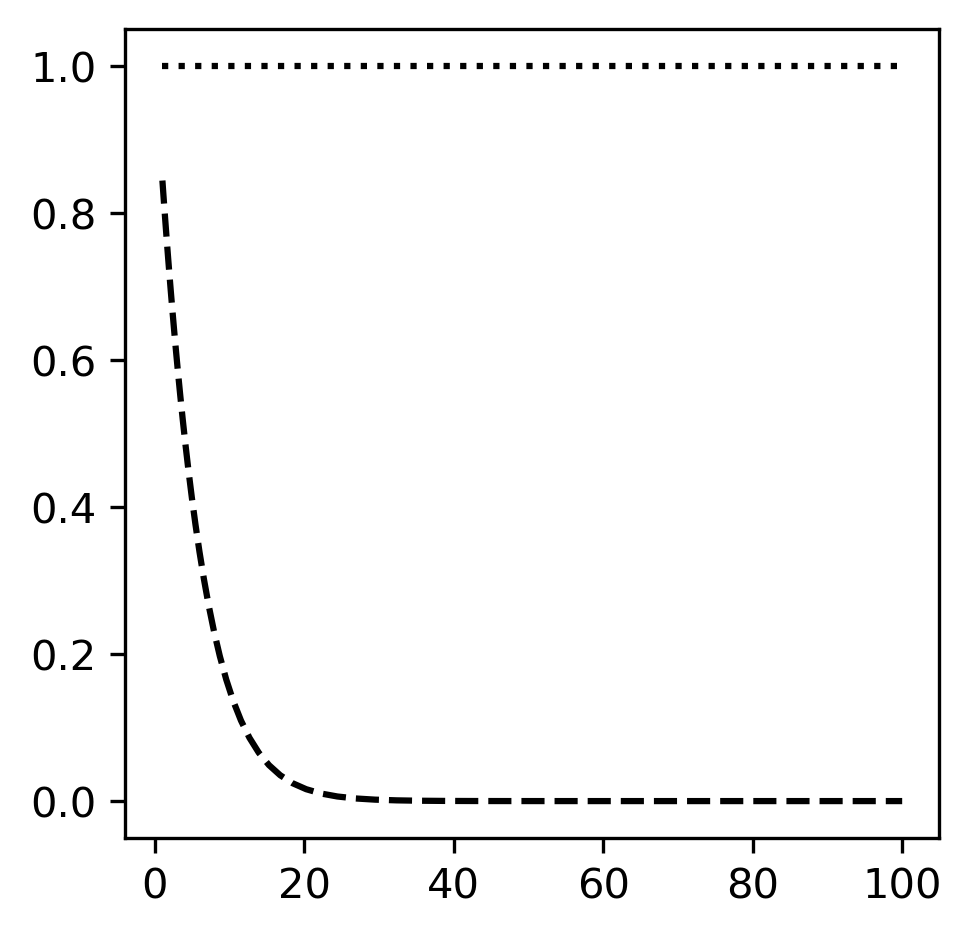

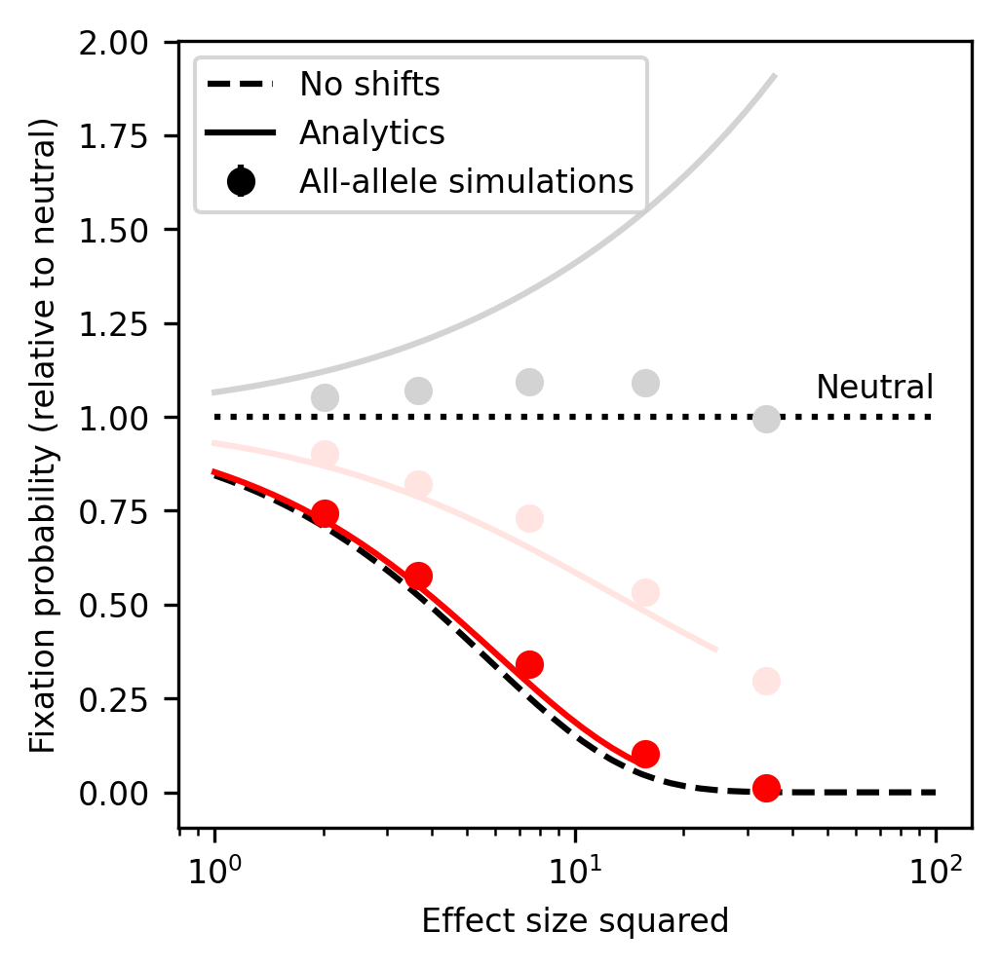

In [6]:
# the fixation probability under recurrent shifts, where the size of each shift independently follows a (Gamma) distribution (the graph shows the three qualitatively different behaviors), in the non-Lande case
fontsize = 8

N = 2000
U = 0.025
E2Ns = 16
nE = 11
indices_ss = [0, 1, 3, 6, 9]

V2Ns = E2Ns ** 2
S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0.,
                                               scale=float(V2Ns) / float(E2Ns))
a_list_pos = [math.sqrt(S_dist.ppf((i + 1) / (nE + 1))) for i in range(nE)]
a_list_pos_between = [math.sqrt(a * a_next) for a, a_next in pairwise(a_list_pos)]

fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = fig.add_subplot(1, 1, 1)

shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 29
rate_of_shifts_partitioning = 66

neutral, = ax.plot(np.geomspace(1, 100), [1 for _ in np.geomspace(1, 100)], 'k:')

no_shifts, = ax.plot(np.geomspace(1, 100), [pi(a=np.sqrt(ss), x=1.0 / (2 * N)) * 2.0 * N for ss in np.geomspace(1, 100)], 'k--')

index_shift_s0, shift_s0 = 17, 1.5
index_rate_of_shift, rate_of_shift = 22, 0.003

parallel_AA = 49
num_fixed = np.sum([read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shape_1_scale_1_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_analytic_V_A_%d/num_fixed_nE_%d' % (round(E2Ns), i, nE)) for i in range(1, 1 + parallel_AA)], axis=0)
fixation_probability_mean = dict()
fixation_probability_se = dict()
for index_ss in indices_ss:
    fixation_probability_mean[index_ss] = num_fixed[index_ss + 1] / (10000000 / (nE + 1) * parallel_AA)
    fixation_probability_se[index_ss] = np.sqrt(fixation_probability_mean[index_ss] * (1 - fixation_probability_mean[index_ss]) / (10000000 / (nE + 1) * parallel_AA))
    ax.errorbar(a_list_pos_between[index_ss] ** 2, fixation_probability_mean[index_ss] * 2 * N, yerr=1.96 * fixation_probability_se[index_ss] * 2 * N, fmt='o', color='r')
ax.plot(np.geomspace(1, 100), [pi_recurrent_shifts_nonlinear_linear_V_Delta_x_gamma_distributed_shift_sizes(a=np.sqrt(ss), x=1.0 / (2 * N), sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for ss in np.geomspace(1, 100)], color='r')

index_rate_of_shift, rate_of_shift = 44, 0.048

num_fixed = np.sum([read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shape_1_scale_1_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_analytic_V_A_%d/num_fixed_nE_%d' % (round(E2Ns), i, nE)) for i in range(1, 1 + parallel_AA)], axis=0)
fixation_probability_mean = dict()
fixation_probability_se = dict()
for index_ss in indices_ss:
    fixation_probability_mean[index_ss] = num_fixed[index_ss + 1] / (10000000 / (nE + 1) * parallel_AA)
    fixation_probability_se[index_ss] = np.sqrt(fixation_probability_mean[index_ss] * (1 - fixation_probability_mean[index_ss]) / (10000000 / (nE + 1) * parallel_AA))
    ax.errorbar(a_list_pos_between[index_ss] ** 2, fixation_probability_mean[index_ss] * 2 * N, yerr=1.96 * fixation_probability_se[index_ss] * 2 * N, fmt='o', color='mistyrose')
ax.plot(np.geomspace(1, 100), [pi_recurrent_shifts_nonlinear_linear_V_Delta_x_gamma_distributed_shift_sizes(a=np.sqrt(ss), x=1.0 / (2 * N), sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for ss in np.geomspace(1, 100)], color='mistyrose')

index_rate_of_shift, rate_of_shift = 54, 0.192

num_fixed = np.sum([read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shape_1_scale_1_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_analytic_V_A_%d/num_fixed_nE_%d' % (round(E2Ns), i, nE)) for i in range(1, 1 + parallel_AA)], axis=0)
fixation_probability_mean = dict()
fixation_probability_se = dict()
for index_ss in indices_ss:
    fixation_probability_mean[index_ss] = num_fixed[index_ss + 1] / (10000000 / (nE + 1) * parallel_AA)
    fixation_probability_se[index_ss] = np.sqrt(fixation_probability_mean[index_ss] * (1 - fixation_probability_mean[index_ss]) / (10000000 / (nE + 1) * parallel_AA))
    ax.errorbar(a_list_pos_between[index_ss] ** 2, fixation_probability_mean[index_ss] * 2 * N, yerr=1.96 * fixation_probability_se[index_ss] * 2 * N, fmt='o', color='lightgray')
ax.plot(np.geomspace(1, 100), [pi_recurrent_shifts_nonlinear_linear_V_Delta_x_gamma_distributed_shift_sizes(a=np.sqrt(ss), x=1.0 / (2 * N), sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for ss in np.geomspace(1, 100)], color='lightgray')

ax.text(x=100, y=1.05, s='Neutral', horizontalalignment='right', color='k', fontsize=fontsize)

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel('Fixation probability (relative to neutral)', fontsize=fontsize)
ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 1.), loc='upper left', fontsize=fontsize)

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

/tmp/ipykernel_4086487/634593053.py:37: RuntimeWarning: divide by zero encountered in log
  twoslopelognorm = colors.FuncNorm((lambda x: np.interp(x=np.log(x), xp=[0, np.log(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N))), np.log(z_max)], fp=[0, 0.5, 1]), lambda x: np.exp(np.interp(x=x, xp=[0, 0.5, 1], fp=[0, np.log(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N))), np.log(z_max)]))), vmin=z_min, vmax=z_max)


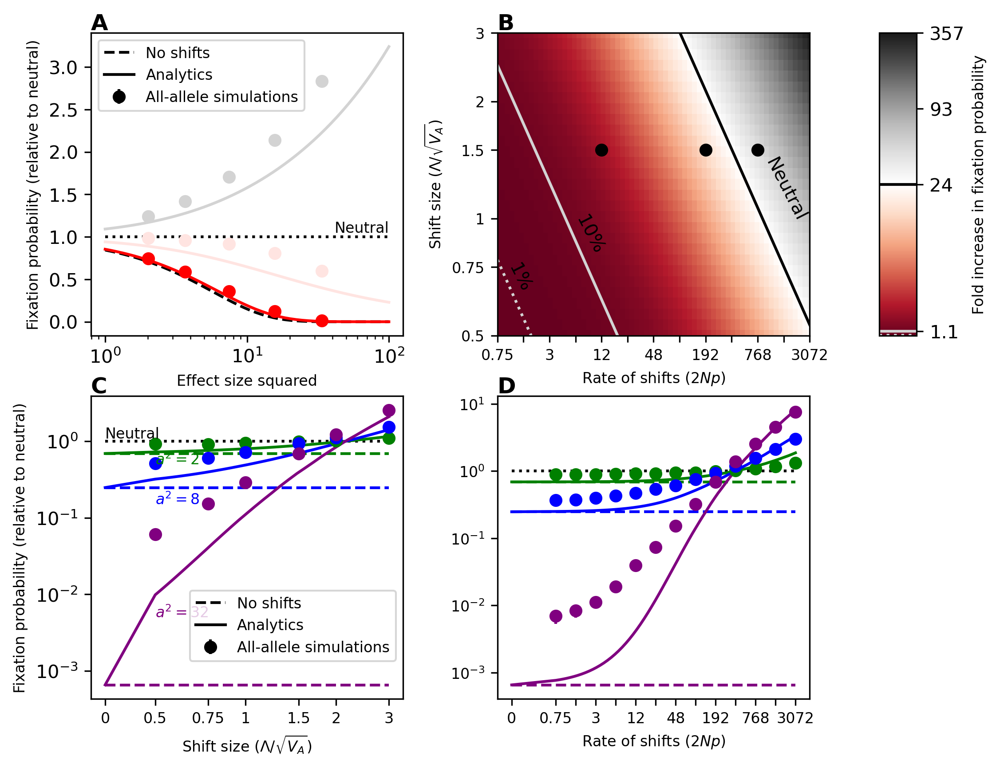

In [8]:
# the fixation probability under recurrent shifts, in the non-Lande case
fontsize = 8

N = 2000
U = 0.025
E2Ns = 16
nE = 11
indices_ss = [0, 1, 3, 6, 9]

V2Ns = E2Ns ** 2
S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0.,
                                               scale=float(V2Ns) / float(E2Ns))
a_list_pos = [math.sqrt(S_dist.ppf((i + 1) / (nE + 1))) for i in range(nE)]
a_list_pos_between = [math.sqrt(a * a_next) for a, a_next in pairwise(a_list_pos)]

fig = plt.figure(figsize=(8, 6.5), dpi=300)
gs = fig.add_gridspec(2, 5, width_ratios=[25, 3, 25, 1, 3], height_ratios=[1, 1])
# just for spacing
plt.subplot(gs[0, 1]).axis('off')
plt.subplot(gs[1, 1]).axis('off')
plt.subplot(gs[0, 3]).axis('off')
plt.subplot(gs[1, 3]).axis('off')
# not used
plt.subplot(gs[1, 4]).axis('off')
# make gs[0, 4] a colorbar
shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 29
rate_of_shifts_partitioning = 66

x = 2 * N * np.geomspace(rate_of_shifts_list[0] / (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_list[-1] * (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_partitioning + 1)
y = np.geomspace(shift_s0_list[0] / (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_list[-1] * (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_partitioning + 1)
X, Y = np.meshgrid(x, y)

Z = np.array([[pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(E2Ns), x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N)) for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))] for index_shift_s0, shift_s0 in enumerate(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning))])
z_min, z_max = Z.min(), Z.max()

twoslopelognorm = colors.FuncNorm((lambda x: np.interp(x=np.log(x), xp=[0, np.log(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N))), np.log(z_max)], fp=[0, 0.5, 1]), lambda x: np.exp(np.interp(x=x, xp=[0, 0.5, 1], fp=[0, np.log(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N))), np.log(z_max)]))), vmin=z_min, vmax=z_max)
sm = plt.cm.ScalarMappable(cmap='RdGy', norm=twoslopelognorm)
cbar = plt.colorbar(sm, cax=plt.subplot(gs[0, 4]), orientation='vertical')
cbar.set_label('Fold increase in fixation probability', fontsize=fontsize)
cbar.ax.set_yticks([1.1, 1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N)), np.sqrt(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N)) * z_max), z_max])
cbar.ax.set_yticklabels([1.1, round(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N))), round(np.sqrt(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N)) * z_max)), round(z_max)])
cbar.ax.axhline(y=1.01, color='lightgray', linestyle=':')
cbar.ax.axhline(y=1.1, color='lightgray', linestyle='-')
cbar.ax.axhline(y=1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N)), color='k', linestyle='-')
cbar.ax.minorticks_off()
# make the other panels
ax = plt.subplot(gs[0, 0])
ax.text(0, 1.01, 'A', transform=ax.transAxes, fontsize=12, fontweight='bold')

neutral, = ax.plot(np.geomspace(1, 100), [1 for _ in np.geomspace(1, 100)], 'k:')

no_shifts, = ax.plot(np.geomspace(1, 100), [pi(a=np.sqrt(ss), x=1.0 / (2 * N)) * 2.0 * N for ss in np.geomspace(1, 100)], 'k--')

index_shift_s0, shift_s0 = 17, 1.5
index_rate_of_shift, rate_of_shift = 22, 0.003

num_fixed = np.sum([read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/num_fixed_nE_%d' % (round(E2Ns), i, nE)) for i in range(1, 1 + parallel_AA)], axis=0)
fixation_probability_mean = dict()
fixation_probability_se = dict()
for index_ss in indices_ss:
    fixation_probability_mean[index_ss] = num_fixed[index_ss + 1] / (10000000 / (nE + 1) * parallel_AA)
    fixation_probability_se[index_ss] = np.sqrt(fixation_probability_mean[index_ss] * (1 - fixation_probability_mean[index_ss]) / (10000000 / (nE + 1) * parallel_AA))
    ax.errorbar(a_list_pos_between[index_ss] ** 2, fixation_probability_mean[index_ss] * 2 * N, yerr=1.96 * fixation_probability_se[index_ss] * 2 * N, fmt='o', color='r')
ax.plot(np.geomspace(1, 100), [pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for ss in np.geomspace(1, 100)], color='r')

index_rate_of_shift, rate_of_shift = 44, 0.048

num_fixed = np.sum([read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/num_fixed_nE_%d' % (round(E2Ns), i, nE)) for i in range(1, 1 + parallel_AA)], axis=0)
fixation_probability_mean = dict()
fixation_probability_se = dict()
for index_ss in indices_ss:
    fixation_probability_mean[index_ss] = num_fixed[index_ss + 1] / (10000000 / (nE + 1) * parallel_AA)
    fixation_probability_se[index_ss] = np.sqrt(fixation_probability_mean[index_ss] * (1 - fixation_probability_mean[index_ss]) / (10000000 / (nE + 1) * parallel_AA))
    ax.errorbar(a_list_pos_between[index_ss] ** 2, fixation_probability_mean[index_ss] * 2 * N, yerr=1.96 * fixation_probability_se[index_ss] * 2 * N, fmt='o', color='mistyrose')
ax.plot(np.geomspace(1, 100), [pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for ss in np.geomspace(1, 100)], color='mistyrose')

index_rate_of_shift, rate_of_shift = 54, 0.192

num_fixed = np.sum([read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/num_fixed_nE_%d' % (round(E2Ns), i, nE)) for i in range(1, 1 + parallel_AA)], axis=0)
fixation_probability_mean = dict()
fixation_probability_se = dict()
for index_ss in indices_ss:
    fixation_probability_mean[index_ss] = num_fixed[index_ss + 1] / (10000000 / (nE + 1) * parallel_AA)
    fixation_probability_se[index_ss] = np.sqrt(fixation_probability_mean[index_ss] * (1 - fixation_probability_mean[index_ss]) / (10000000 / (nE + 1) * parallel_AA))
    ax.errorbar(a_list_pos_between[index_ss] ** 2, fixation_probability_mean[index_ss] * 2 * N, yerr=1.96 * fixation_probability_se[index_ss] * 2 * N, fmt='o', color='lightgray')
ax.plot(np.geomspace(1, 100), [pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for ss in np.geomspace(1, 100)], color='lightgray')

ax.text(x=100, y=1.05, s='Neutral', horizontalalignment='right', color='k', fontsize=fontsize)

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel('Fixation probability (relative to neutral)', fontsize=fontsize)
ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 1.), loc='upper left', fontsize=fontsize)

ax = plt.subplot(gs[0, 2])
ax.text(0, 1.01, 'B', transform=ax.transAxes, fontsize=12, fontweight='bold')

twoslopelognorm = colors.FuncNorm((lambda x: np.interp(x=np.log(x), xp=[0, np.log(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N))), np.log(z_max)], fp=[0, 0.5, 1]), lambda x: np.exp(np.interp(x=x, xp=[0, 0.5, 1], fp=[0, np.log(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N))), np.log(z_max)]))), vmin=z_min, vmax=z_max)
ax.pcolormesh(X, Y, Z, cmap='RdGy', norm=twoslopelognorm)
ax.plot(2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning), [np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)[np.searchsorted(Z[:, index_rate_of_shift], 1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N)))] if Z[-1, index_rate_of_shift] >= 1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N)) else None for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))], 'k-', label='fixation probability being neutral')
ax.plot(2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning), [np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)[np.searchsorted(Z[:, index_rate_of_shift], 1.1)] if Z[-1, index_rate_of_shift] >= 1.1 and pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(E2Ns), x=1.0 / (2 * N), shift_s0=shift_s0_list[0] / (shift_s0_list[-1] / shift_s0_list[0]) ** (1 / (shift_s0_partitioning - 1)), sigma_0_del=np.sqrt(analytic_V_A_nonLande[0, index_rate_of_shift]), p=rate_of_shift) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N)) < 1.1 else None for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))], color='lightgray', linestyle='-', label='shifts increasing fixation probability by 10%')
ax.plot(2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning), [np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)[np.searchsorted(Z[:, index_rate_of_shift], 1.01)] if Z[-1, index_rate_of_shift] >= 1.01 and pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(E2Ns), x=1.0 / (2 * N), shift_s0=shift_s0_list[0] / (shift_s0_list[-1] / shift_s0_list[0]) ** (1 / (shift_s0_partitioning - 1)), sigma_0_del=np.sqrt(analytic_V_A_nonLande[0, index_rate_of_shift]), p=rate_of_shift) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N)) < 1.01 else None for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))], color='lightgray', linestyle=':', label='shifts increasing fixation probability by 1%')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(2 * N * rate_of_shifts_list[0], 2 * N * rate_of_shifts_list[-1])
ax.set_ylim(shift_s0_list[0], shift_s0_list[-1])
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_ylabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
assert len(rate_of_shifts_list) % 2 == 1
ax.set_xticks(ticks=list(2 * N * np.array(rate_of_shifts_list)), labels=[2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
ax.set_yticks(ticks=shift_s0_list, labels=shift_s0_list, fontsize=fontsize)
ax.minorticks_off()
ax.text(x=1, y=0.75, s='1%', color='k', rotation=-63, rotation_mode='anchor')
ax.text(x=6, y=1, s='10%', color='k', rotation=-63, rotation_mode='anchor')
ax.text(x=960, y=1.4, s='Neutral', color='k', rotation=-63, rotation_mode='anchor')
ax.scatter(2 * N * np.array([0.003, 0.048, 0.192]), [1.5, 1.5, 1.5], color='k')



ax = plt.subplot(gs[1, 0])
ax.text(0, 1.01, 'C', transform=ax.transAxes, fontsize=12, fontweight='bold')

index_rate_of_shift, rate_of_shift = 44, 0.048

neutral, = ax.plot([0] + shift_s0_list, [1 for _ in [0] + shift_s0_list], 'k:')

simulations = [None, None, None]
no_shifts = [None, None, None]
analytics = [None, None, None]

for i, (index_ss, ss, color) in enumerate([[0, 2.15, 'g'], [3, 7.55, 'b'], [9, 34.1, 'purple']]):
    parallel_AA = 49
    num_fixed_wrt_shift_s0 = [np.sum([read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/num_fixed_nE_%d' % (round(E2Ns), j, nE))[index_ss] for j in range(1, 1 + parallel_AA)]) for shift_s0 in shift_s0_list]
    fixation_probability_mean_wrt_shift_s0 = np.divide(num_fixed_wrt_shift_s0, (10000000 / (nE + 1) * parallel_AA))
    fixation_probability_se_wrt_shift_s0 = np.sqrt(np.divide(np.multiply(fixation_probability_mean_wrt_shift_s0, np.subtract(1, fixation_probability_mean_wrt_shift_s0)), (10000000 / (nE + 1) * parallel_AA)))
    
    simulations[i] = ax.errorbar(shift_s0_list, fixation_probability_mean_wrt_shift_s0 * 2 * N, yerr=1.96 * fixation_probability_se_wrt_shift_s0 * 2 * N, fmt='o', color=color)

    no_shifts[i], = ax.plot([0] + shift_s0_list, [pi(a=np.sqrt(ss), x=1.0 / (2 * N)) * 2.0 * N for _ in [0] + shift_s0_list], color=color, linestyle='--')

    analytics[i], = ax.plot([0] + list(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)), [pi(a=np.sqrt(ss), x=1.0 / (2 * N)) * 2.0 * N] + [pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for index_shift_s0, shift_s0 in enumerate(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning))], color=color)

ax.text(x=0, y=1.1, s='Neutral', color='k', fontsize=fontsize)
ax.text(x=shift_s0_list[0], y=0.5, s='$a^2=%g$' % 2, color='g', fontsize=fontsize)
ax.text(x=shift_s0_list[0], y=0.15, s='$a^2=%g$' % 8, color='b', fontsize=fontsize)
ax.text(x=shift_s0_list[0], y=0.005, s='$a^2=%g$' % 32, color='purple', fontsize=fontsize)

simulation_mean = ax.errorbar([], [], yerr=[], fmt='o', color='k', label='All-allele simulations')
no_shifts_mean, = ax.plot([], [], 'k--', label='No shifts')
analytic_mean, = ax.plot([], [], 'k-', label='Analytics')

ax.set_xscale('symlog', linthresh=shift_s0_list[0], linscale=0.15)
ax.set_yscale('log')
ax.set_xlabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
ax.set_ylabel('Fixation probability (relative to neutral)', fontsize=fontsize)
ax.set_xticks(ticks=[0] + shift_s0_list, labels=[0] + shift_s0_list, fontsize=fontsize)
# ax.set_yticks(ticks=[0.5, 1, 2, 4], labels=[0.5, 1, 2, 4], fontsize=fontsize)
# ax.set_title(r'$E[a^2]=%d, 2Np=%g$' % (round(E2Ns), 2 * N * rate_of_shift), fontsize=fontsize)
ax.legend(handles=[no_shifts_mean, analytic_mean, simulation_mean], bbox_to_anchor=(1., 0.1), loc='lower right', fontsize=fontsize)
ax.minorticks_off()

ax = plt.subplot(gs[1, 2])
ax.text(0, 1.01, 'D', transform=ax.transAxes, fontsize=12, fontweight='bold')

index_shift_s0, shift_s0 = 17, 1.5

neutral, = ax.plot([0] + list(2 * N * np.array(rate_of_shifts_list)), [1 for _ in [0] + rate_of_shifts_list], 'k:')

simulations = [None, None, None]
no_shifts = [None, None, None]
analytics = [None, None, None]

for i, (index_ss, ss, color) in enumerate([[0, 2.15, 'g'], [3, 7.55, 'b'], [9, 34.1, 'purple']]):
    parallel_AA = 49
    num_fixed_wrt_rate_of_shifts = [np.sum([read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/num_fixed_nE_%d' % (round(E2Ns), j, nE))[index_ss] for j in range(1, 1 + parallel_AA)]) for rate_of_shift in rate_of_shifts_list]
    fixation_probability_mean_wrt_rate_of_shifts = np.divide(num_fixed_wrt_rate_of_shifts, (10000000 / (nE + 1) * parallel_AA))
    fixation_probability_se_wrt_rate_of_shifts = np.sqrt(np.divide(np.multiply(fixation_probability_mean_wrt_rate_of_shifts, np.subtract(1, fixation_probability_mean_wrt_rate_of_shifts)), (10000000 / (nE + 1) * parallel_AA)))
    
    simulations[i] = ax.errorbar(2 * N * np.array(rate_of_shifts_list), fixation_probability_mean_wrt_rate_of_shifts * 2 * N, yerr=1.96 * fixation_probability_se_wrt_rate_of_shifts * 2 * N, fmt='o', color=color)

    no_shifts[i], = ax.plot([0] + list(2 * N * np.array(rate_of_shifts_list)), [pi(a=np.sqrt(ss), x=1.0 / (2 * N)) * 2.0 * N for _ in [0] + rate_of_shifts_list], color=color, linestyle='--')

    analytics[i], = ax.plot([0] + list(2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)), [pi(a=np.sqrt(ss), x=1.0 / (2 * N)) * 2.0 * N] + [pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))], color=color)

simulation_mean = ax.errorbar([], [], yerr=[], fmt='o', color='k')
no_shifts_mean, = ax.plot([], [], 'k--')
analytic_mean, = ax.plot([], [], 'k-')

ax.set_xscale('symlog', linthresh=2 * N * rate_of_shifts_list[0], linscale=0.6)
ax.set_yscale('log')
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
assert len(rate_of_shifts_list) % 2 == 1
ax.set_xticks(ticks=[0] + list(2 * N * np.array(rate_of_shifts_list)), labels=[0] + [2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
# ax.set_yticks(ticks=[0.5, 1, 2, 4, 8, 16], labels=[0.5, 1, 2, 4, 8, 16], fontsize=fontsize)
# ax.set_title(r'$E[a^2]=%d, \Lambda=%g\sqrt{V_A}$' % (round(E2Ns), shift_s0), fontsize=fontsize)
ax.minorticks_off()

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

/tmp/ipykernel_4086487/3947992981.py:37: RuntimeWarning: divide by zero encountered in log
  twoslopelognorm = colors.FuncNorm((lambda x: np.interp(x=np.log(x), xp=[0, np.log(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N))), np.log(z_max)], fp=[0, 0.5, 1]), lambda x: np.exp(np.interp(x=x, xp=[0, 0.5, 1], fp=[0, np.log(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N))), np.log(z_max)]))), vmin=z_min, vmax=z_max)


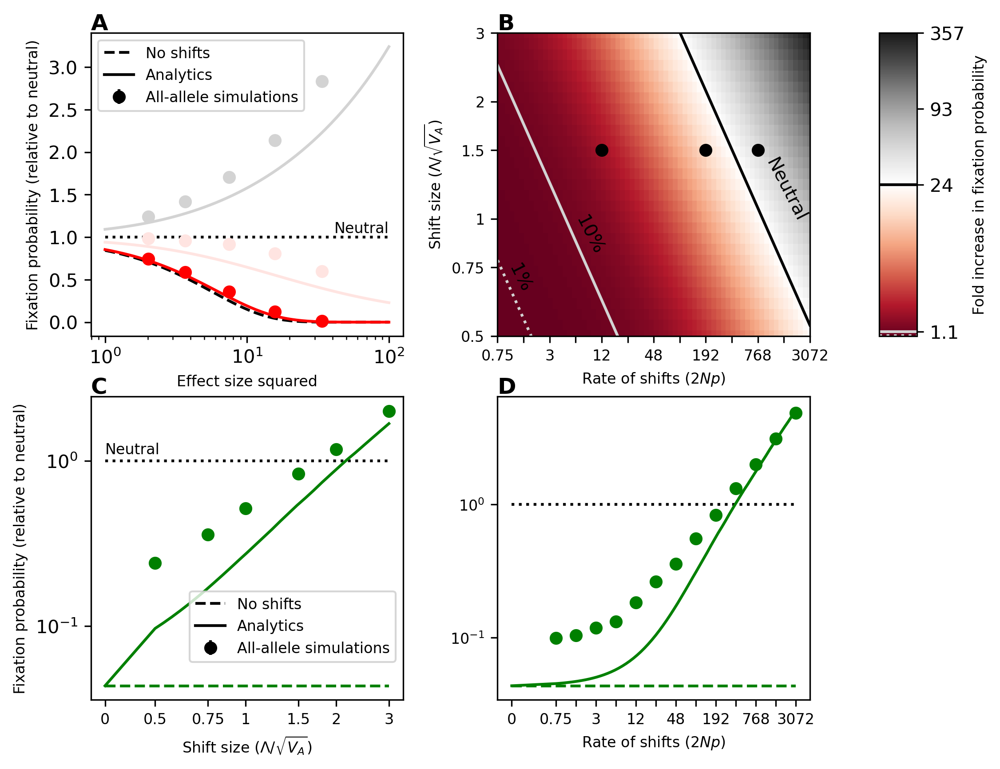

In [9]:
# the fixation probability under recurrent shifts, in the non-Lande case
# panels C and D: the average fixation probability over the effect size distribution
fontsize = 8

N = 2000
U = 0.025
E2Ns = 16
nE = 11
indices_ss = [0, 1, 3, 6, 9]

V2Ns = E2Ns ** 2
S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0.,
                                               scale=float(V2Ns) / float(E2Ns))
a_list_pos = [math.sqrt(S_dist.ppf((i + 1) / (nE + 1))) for i in range(nE)]
a_list_pos_between = [math.sqrt(a * a_next) for a, a_next in pairwise(a_list_pos)]

fig = plt.figure(figsize=(8, 6.5), dpi=300)
gs = fig.add_gridspec(2, 5, width_ratios=[25, 3, 25, 1, 3], height_ratios=[1, 1])
# just for spacing
plt.subplot(gs[0, 1]).axis('off')
plt.subplot(gs[1, 1]).axis('off')
plt.subplot(gs[0, 3]).axis('off')
plt.subplot(gs[1, 3]).axis('off')
# not used
plt.subplot(gs[1, 4]).axis('off')
# make gs[0, 4] a colorbar
shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 29
rate_of_shifts_partitioning = 66

x = 2 * N * np.geomspace(rate_of_shifts_list[0] / (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_list[-1] * (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_partitioning + 1)
y = np.geomspace(shift_s0_list[0] / (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_list[-1] * (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_partitioning + 1)
X, Y = np.meshgrid(x, y)

Z = np.array([[pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(E2Ns), x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N)) for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))] for index_shift_s0, shift_s0 in enumerate(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning))])
z_min, z_max = Z.min(), Z.max()

twoslopelognorm = colors.FuncNorm((lambda x: np.interp(x=np.log(x), xp=[0, np.log(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N))), np.log(z_max)], fp=[0, 0.5, 1]), lambda x: np.exp(np.interp(x=x, xp=[0, 0.5, 1], fp=[0, np.log(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N))), np.log(z_max)]))), vmin=z_min, vmax=z_max)
sm = plt.cm.ScalarMappable(cmap='RdGy', norm=twoslopelognorm)
cbar = plt.colorbar(sm, cax=plt.subplot(gs[0, 4]), orientation='vertical')
cbar.set_label('Fold increase in fixation probability', fontsize=fontsize)
cbar.ax.set_yticks([1.1, 1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N)), np.sqrt(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N)) * z_max), z_max])
cbar.ax.set_yticklabels([1.1, round(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N))), round(np.sqrt(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N)) * z_max)), round(z_max)])
cbar.ax.axhline(y=1.01, color='lightgray', linestyle=':')
cbar.ax.axhline(y=1.1, color='lightgray', linestyle='-')
cbar.ax.axhline(y=1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N)), color='k', linestyle='-')
cbar.ax.minorticks_off()
# make the other panels
ax = plt.subplot(gs[0, 0])
ax.text(0, 1.01, 'A', transform=ax.transAxes, fontsize=12, fontweight='bold')

neutral, = ax.plot(np.geomspace(1, 100), [1 for _ in np.geomspace(1, 100)], 'k:')

no_shifts, = ax.plot(np.geomspace(1, 100), [pi(a=np.sqrt(ss), x=1.0 / (2 * N)) * 2.0 * N for ss in np.geomspace(1, 100)], 'k--')

index_shift_s0, shift_s0 = 17, 1.5
index_rate_of_shift, rate_of_shift = 22, 0.003

num_fixed = np.sum([read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/num_fixed_nE_%d' % (round(E2Ns), i, nE)) for i in range(1, 1 + parallel_AA)], axis=0)
fixation_probability_mean = dict()
fixation_probability_se = dict()
for index_ss in indices_ss:
    fixation_probability_mean[index_ss] = num_fixed[index_ss + 1] / (10000000 / (nE + 1) * parallel_AA)
    fixation_probability_se[index_ss] = np.sqrt(fixation_probability_mean[index_ss] * (1 - fixation_probability_mean[index_ss]) / (10000000 / (nE + 1) * parallel_AA))
    ax.errorbar(a_list_pos_between[index_ss] ** 2, fixation_probability_mean[index_ss] * 2 * N, yerr=1.96 * fixation_probability_se[index_ss] * 2 * N, fmt='o', color='r')
ax.plot(np.geomspace(1, 100), [pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for ss in np.geomspace(1, 100)], color='r')

index_rate_of_shift, rate_of_shift = 44, 0.048

num_fixed = np.sum([read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/num_fixed_nE_%d' % (round(E2Ns), i, nE)) for i in range(1, 1 + parallel_AA)], axis=0)
fixation_probability_mean = dict()
fixation_probability_se = dict()
for index_ss in indices_ss:
    fixation_probability_mean[index_ss] = num_fixed[index_ss + 1] / (10000000 / (nE + 1) * parallel_AA)
    fixation_probability_se[index_ss] = np.sqrt(fixation_probability_mean[index_ss] * (1 - fixation_probability_mean[index_ss]) / (10000000 / (nE + 1) * parallel_AA))
    ax.errorbar(a_list_pos_between[index_ss] ** 2, fixation_probability_mean[index_ss] * 2 * N, yerr=1.96 * fixation_probability_se[index_ss] * 2 * N, fmt='o', color='mistyrose')
ax.plot(np.geomspace(1, 100), [pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for ss in np.geomspace(1, 100)], color='mistyrose')

index_rate_of_shift, rate_of_shift = 54, 0.192

num_fixed = np.sum([read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/num_fixed_nE_%d' % (round(E2Ns), i, nE)) for i in range(1, 1 + parallel_AA)], axis=0)
fixation_probability_mean = dict()
fixation_probability_se = dict()
for index_ss in indices_ss:
    fixation_probability_mean[index_ss] = num_fixed[index_ss + 1] / (10000000 / (nE + 1) * parallel_AA)
    fixation_probability_se[index_ss] = np.sqrt(fixation_probability_mean[index_ss] * (1 - fixation_probability_mean[index_ss]) / (10000000 / (nE + 1) * parallel_AA))
    ax.errorbar(a_list_pos_between[index_ss] ** 2, fixation_probability_mean[index_ss] * 2 * N, yerr=1.96 * fixation_probability_se[index_ss] * 2 * N, fmt='o', color='lightgray')
ax.plot(np.geomspace(1, 100), [pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for ss in np.geomspace(1, 100)], color='lightgray')

ax.text(x=100, y=1.05, s='Neutral', horizontalalignment='right', color='k', fontsize=fontsize)

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel('Fixation probability (relative to neutral)', fontsize=fontsize)
ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 1.), loc='upper left', fontsize=fontsize)

ax = plt.subplot(gs[0, 2])
ax.text(0, 1.01, 'B', transform=ax.transAxes, fontsize=12, fontweight='bold')

twoslopelognorm = colors.FuncNorm((lambda x: np.interp(x=np.log(x), xp=[0, np.log(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N))), np.log(z_max)], fp=[0, 0.5, 1]), lambda x: np.exp(np.interp(x=x, xp=[0, 0.5, 1], fp=[0, np.log(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N))), np.log(z_max)]))), vmin=z_min, vmax=z_max)
ax.pcolormesh(X, Y, Z, cmap='RdGy', norm=twoslopelognorm)
ax.plot(2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning), [np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)[np.searchsorted(Z[:, index_rate_of_shift], 1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N)))] if Z[-1, index_rate_of_shift] >= 1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N)) else None for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))], 'k-', label='fixation probability being neutral')
ax.plot(2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning), [np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)[np.searchsorted(Z[:, index_rate_of_shift], 1.1)] if Z[-1, index_rate_of_shift] >= 1.1 and pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(E2Ns), x=1.0 / (2 * N), shift_s0=shift_s0_list[0] / (shift_s0_list[-1] / shift_s0_list[0]) ** (1 / (shift_s0_partitioning - 1)), sigma_0_del=np.sqrt(analytic_V_A_nonLande[0, index_rate_of_shift]), p=rate_of_shift) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N)) < 1.1 else None for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))], color='lightgray', linestyle='-', label='shifts increasing fixation probability by 10%')
ax.plot(2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning), [np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)[np.searchsorted(Z[:, index_rate_of_shift], 1.01)] if Z[-1, index_rate_of_shift] >= 1.01 and pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(E2Ns), x=1.0 / (2 * N), shift_s0=shift_s0_list[0] / (shift_s0_list[-1] / shift_s0_list[0]) ** (1 / (shift_s0_partitioning - 1)), sigma_0_del=np.sqrt(analytic_V_A_nonLande[0, index_rate_of_shift]), p=rate_of_shift) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N)) < 1.01 else None for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))], color='lightgray', linestyle=':', label='shifts increasing fixation probability by 1%')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(2 * N * rate_of_shifts_list[0], 2 * N * rate_of_shifts_list[-1])
ax.set_ylim(shift_s0_list[0], shift_s0_list[-1])
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_ylabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
assert len(rate_of_shifts_list) % 2 == 1
ax.set_xticks(ticks=list(2 * N * np.array(rate_of_shifts_list)), labels=[2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
ax.set_yticks(ticks=shift_s0_list, labels=shift_s0_list, fontsize=fontsize)
ax.minorticks_off()
ax.text(x=1, y=0.75, s='1%', color='k', rotation=-63, rotation_mode='anchor')
ax.text(x=6, y=1, s='10%', color='k', rotation=-63, rotation_mode='anchor')
ax.text(x=960, y=1.4, s='Neutral', color='k', rotation=-63, rotation_mode='anchor')
ax.scatter(2 * N * np.array([0.003, 0.048, 0.192]), [1.5, 1.5, 1.5], color='k')

# Graph II (w.r.t. shift size & w.r.t. rate of shifts; different effect sizes)

ax = plt.subplot(gs[1, 0])
ax.text(0, 1.01, 'C', transform=ax.transAxes, fontsize=12, fontweight='bold')

index_rate_of_shift, rate_of_shift = 44, 0.048

neutral, = ax.plot([0] + shift_s0_list, [1 for _ in [0] + shift_s0_list], 'k:')

simulations = [None, None, None]
no_shifts = [None, None, None]
analytics = [None, None, None]

for i, (index_ss, ss, color) in enumerate(((6, 15.8, 'g'), )):
    parallel_AA = 49
    num_fixed_wrt_shift_s0 = [np.sum([read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/num_fixed_nE_%d' % (round(E2Ns), j, nE))[index_ss] for j in range(1, 1 + parallel_AA)]) for shift_s0 in shift_s0_list]
    fixation_probability_mean_wrt_shift_s0 = np.divide(num_fixed_wrt_shift_s0, (10000000 / (nE + 1) * parallel_AA))
    fixation_probability_se_wrt_shift_s0 = np.sqrt(np.divide(np.multiply(fixation_probability_mean_wrt_shift_s0, np.subtract(1, fixation_probability_mean_wrt_shift_s0)), (10000000 / (nE + 1) * parallel_AA)))
    
    simulations[i] = ax.errorbar(shift_s0_list, fixation_probability_mean_wrt_shift_s0 * 2 * N, yerr=1.96 * fixation_probability_se_wrt_shift_s0 * 2 * N, fmt='o', color=color)

    no_shifts[i], = ax.plot([0] + shift_s0_list, [pi(a=np.sqrt(ss), x=1.0 / (2 * N)) * 2.0 * N for _ in [0] + shift_s0_list], color=color, linestyle='--')

    analytics[i], = ax.plot([0] + list(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)), [pi(a=np.sqrt(ss), x=1.0 / (2 * N)) * 2.0 * N] + [pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for index_shift_s0, shift_s0 in enumerate(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning))], color=color)

ax.text(x=0, y=1.1, s='Neutral', color='k', fontsize=fontsize)
# ax.text(x=shift_s0_list[0], y=0.5, s='$a^2=%g$' % 2, color='g', fontsize=fontsize)
# ax.text(x=shift_s0_list[0], y=0.15, s='$a^2=%g$' % 8, color='b', fontsize=fontsize)
# ax.text(x=shift_s0_list[0], y=0.005, s='$a^2=%g$' % 32, color='purple', fontsize=fontsize)

simulation_mean = ax.errorbar([], [], yerr=[], fmt='o', color='k', label='All-allele simulations')
no_shifts_mean, = ax.plot([], [], 'k--', label='No shifts')
analytic_mean, = ax.plot([], [], 'k-', label='Analytics')

ax.set_xscale('symlog', linthresh=shift_s0_list[0], linscale=0.15)
ax.set_yscale('log')
ax.set_xlabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
ax.set_ylabel('Fixation probability (relative to neutral)', fontsize=fontsize)
ax.set_xticks(ticks=[0] + shift_s0_list, labels=[0] + shift_s0_list, fontsize=fontsize)
# ax.set_yticks(ticks=[0.5, 1, 2, 4], labels=[0.5, 1, 2, 4], fontsize=fontsize)
# ax.set_title(r'$E[a^2]=%d, 2Np=%g$' % (round(E2Ns), 2 * N * rate_of_shift), fontsize=fontsize)
ax.legend(handles=[no_shifts_mean, analytic_mean, simulation_mean], bbox_to_anchor=(1., 0.1), loc='lower right', fontsize=fontsize)
ax.minorticks_off()

ax = plt.subplot(gs[1, 2])
ax.text(0, 1.01, 'D', transform=ax.transAxes, fontsize=12, fontweight='bold')

index_shift_s0, shift_s0 = 17, 1.5

neutral, = ax.plot([0] + list(2 * N * np.array(rate_of_shifts_list)), [1 for _ in [0] + rate_of_shifts_list], 'k:')

simulations = [None, None, None]
no_shifts = [None, None, None]
analytics = [None, None, None]

for i, (index_ss, ss, color) in enumerate(((6, 15.8, 'g'), )):
    parallel_AA = 49
    num_fixed_wrt_rate_of_shifts = [np.sum([read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/num_fixed_nE_%d' % (round(E2Ns), j, nE))[index_ss] for j in range(1, 1 + parallel_AA)]) for rate_of_shift in rate_of_shifts_list]
    fixation_probability_mean_wrt_rate_of_shifts = np.divide(num_fixed_wrt_rate_of_shifts, (10000000 / (nE + 1) * parallel_AA))
    fixation_probability_se_wrt_rate_of_shifts = np.sqrt(np.divide(np.multiply(fixation_probability_mean_wrt_rate_of_shifts, np.subtract(1, fixation_probability_mean_wrt_rate_of_shifts)), (10000000 / (nE + 1) * parallel_AA)))
    
    simulations[i] = ax.errorbar(2 * N * np.array(rate_of_shifts_list), fixation_probability_mean_wrt_rate_of_shifts * 2 * N, yerr=1.96 * fixation_probability_se_wrt_rate_of_shifts * 2 * N, fmt='o', color=color)

    no_shifts[i], = ax.plot([0] + list(2 * N * np.array(rate_of_shifts_list)), [pi(a=np.sqrt(ss), x=1.0 / (2 * N)) * 2.0 * N for _ in [0] + rate_of_shifts_list], color=color, linestyle='--')

    analytics[i], = ax.plot([0] + list(2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)), [pi(a=np.sqrt(ss), x=1.0 / (2 * N)) * 2.0 * N] + [pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))], color=color)

simulation_mean = ax.errorbar([], [], yerr=[], fmt='o', color='k')
no_shifts_mean, = ax.plot([], [], 'k--')
analytic_mean, = ax.plot([], [], 'k-')

ax.set_xscale('symlog', linthresh=2 * N * rate_of_shifts_list[0], linscale=0.6)
ax.set_yscale('log')
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
assert len(rate_of_shifts_list) % 2 == 1
ax.set_xticks(ticks=[0] + list(2 * N * np.array(rate_of_shifts_list)), labels=[0] + [2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
# ax.set_yticks(ticks=[0.5, 1, 2, 4, 8, 16], labels=[0.5, 1, 2, 4, 8, 16], fontsize=fontsize)
# ax.set_title(r'$E[a^2]=%d, \Lambda=%g\sqrt{V_A}$' % (round(E2Ns), shift_s0), fontsize=fontsize)
ax.minorticks_off()

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

/tmp/ipykernel_2628741/602311149.py:31: RuntimeWarning: divide by zero encountered in log
  twoslopelognorm = colors.FuncNorm((lambda x: np.interp(x=np.log(x), xp=[0, np.log(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N))), np.log(z_analytics_max)], fp=[0, 0.5, 1]), lambda x: np.exp(np.interp(x=x, xp=[0, 0.5, 1], fp=[0, np.log(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N))), np.log(z_analytics_max)]))), vmin=z_analytics_min, vmax=z_analytics_max)
/tmp/ipykernel_2628741/602311149.py:52: RuntimeWarning: divide by zero encountered in log
  twoslopelognorm = colors.FuncNorm((lambda x: np.interp(x=np.log(x), xp=[0, np.log(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N))), np.log(z_simulations_max)], fp=[0, 0.5, 1]), lambda x: np.exp(np.interp(x=x, xp=[0, 0.5, 1], fp=[0, np.log(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N))), np.log(z_simulations_max)]))), vmin=z_simulations_min, vmax=z_simulations_max)


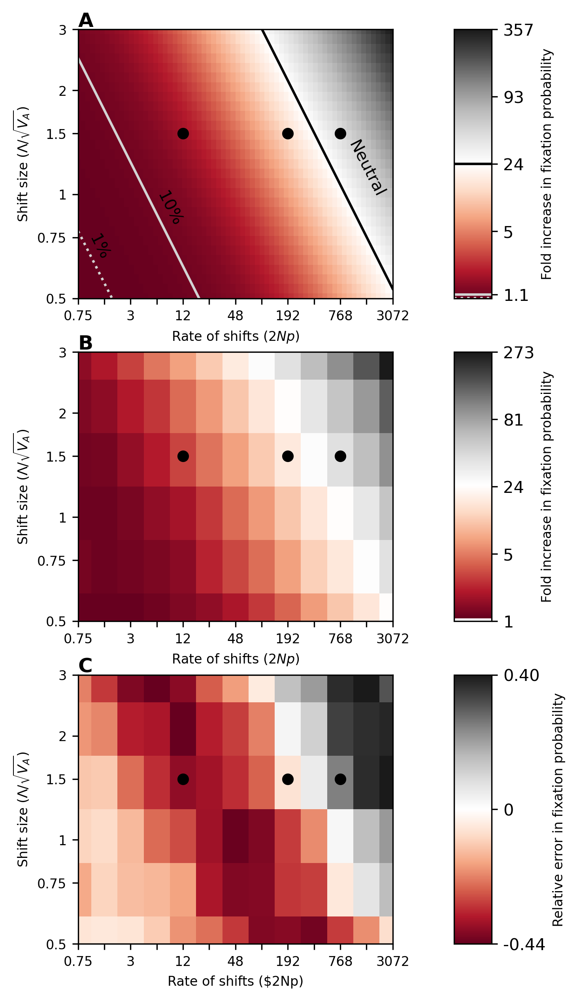

In [13]:
# the difference between the analytics and simulations of the fixation probability under recurrent shifts, in the non-Lande case
fontsize = 8

N = 2000
U = 0.025
E2Ns = 16
nE = 11
indices_ss = [0, 1, 3, 6, 9]

V2Ns = E2Ns ** 2
S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0.,
                                               scale=float(V2Ns) / float(E2Ns))
a_list_pos = [math.sqrt(S_dist.ppf((i + 1) / (nE + 1))) for i in range(nE)]
a_list_pos_between = [math.sqrt(a * a_next) for a, a_next in pairwise(a_list_pos)]

fig = plt.figure(figsize=(4.5, 10), dpi=300)
gs = fig.add_gridspec(3, 3, width_ratios=[25, 1, 3], height_ratios=[1, 1, 1])
# just for spacing
plt.subplot(gs[0, 1]).axis('off')
plt.subplot(gs[1, 1]).axis('off')
plt.subplot(gs[2, 1]).axis('off')
# make colorbars
## analytics
shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 29
rate_of_shifts_partitioning = 66

Z_analytics = np.array([[pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(E2Ns), x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N)) for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))] for index_shift_s0, shift_s0 in enumerate(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning))])
z_analytics_min, z_analytics_max = Z_analytics.min(), Z_analytics.max()

twoslopelognorm = colors.FuncNorm((lambda x: np.interp(x=np.log(x), xp=[0, np.log(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N))), np.log(z_analytics_max)], fp=[0, 0.5, 1]), lambda x: np.exp(np.interp(x=x, xp=[0, 0.5, 1], fp=[0, np.log(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N))), np.log(z_analytics_max)]))), vmin=z_analytics_min, vmax=z_analytics_max)
sm = plt.cm.ScalarMappable(cmap='RdGy', norm=twoslopelognorm)
cbar = plt.colorbar(sm, cax=plt.subplot(gs[0, 2]), orientation='vertical')
cbar.set_label('Fold increase in fixation probability', fontsize=fontsize)
cbar.ax.set_yticks([1.1, np.sqrt(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N))), 1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N)), np.sqrt(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N)) * z_analytics_max), z_analytics_max])
cbar.ax.set_yticklabels([1.1, round(np.sqrt(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N)))), round(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N))), round(np.sqrt(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N)) * z_analytics_max)), round(z_analytics_max)])
cbar.ax.axhline(y=1.01, color='lightgray', linestyle=':')
cbar.ax.axhline(y=1.1, color='lightgray', linestyle='-')
cbar.ax.axhline(y=1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N)), color='k', linestyle='-')
cbar.ax.minorticks_off()

## simulations
Z_simulations = np.empty((len(shift_s0_list), len(rate_of_shifts_list)))
for E2Ns, index_shift_s0, shift_s0, index_rate_of_shift, rate_of_shift in [(E2Ns, index_shift_s0, shift_s0, index_rate_of_shift, rate_of_shift) for E2Ns in [E2Ns, ] for index_shift_s0, shift_s0 in enumerate(shift_s0_list) for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)]:
    parallel_AA = 49
    total_num_fixed_nm_AA = [sum(x) for x in zip(*[my_AA_results_num_fixed_nm('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_nE_%d_empirical_average_V_A_%d' % (round(E2Ns), nE, i), particular_2Ns=None, is_particular_2Ns=None) for i in range(1, 1 + parallel_AA)])]
    total_num_new_mutations_AA = [sum(x) for x in zip(*[my_AA_results_num_new_mutations('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_nE_%d_empirical_average_V_A_%d' % (round(E2Ns), nE, i), particular_2Ns=None, is_particular_2Ns=None) for i in range(1, 1 + parallel_AA)])]
    fixation_probability_AA = [nfixed / nnm for nfixed, nnm in zip(total_num_fixed_nm_AA, total_num_new_mutations_AA)]
    Z_simulations[index_shift_s0, index_rate_of_shift] = fixation_probability_AA[indices_ss[3]] / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N))
z_simulations_min, z_simulations_max = Z_simulations.min(), Z_simulations.max()

twoslopelognorm = colors.FuncNorm((lambda x: np.interp(x=np.log(x), xp=[0, np.log(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N))), np.log(z_simulations_max)], fp=[0, 0.5, 1]), lambda x: np.exp(np.interp(x=x, xp=[0, 0.5, 1], fp=[0, np.log(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N))), np.log(z_simulations_max)]))), vmin=z_simulations_min, vmax=z_simulations_max)
sm = plt.cm.ScalarMappable(cmap='RdGy', norm=twoslopelognorm)
cbar = plt.colorbar(sm, cax=plt.subplot(gs[1, 2]), orientation='vertical')
cbar.set_label('Fold increase in fixation probability', fontsize=fontsize)
cbar.ax.set_yticks([1, np.sqrt(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N))), 1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N)), np.sqrt(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N)) * z_simulations_max), z_simulations_max])
cbar.ax.set_yticklabels([1, round(np.sqrt(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N)))), round(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N))), round(np.sqrt(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N)) * z_simulations_max)), round(z_simulations_max)])
cbar.ax.minorticks_off()

## difference
Z_difference = np.empty((len(shift_s0_list), len(rate_of_shifts_list)))
for E2Ns, index_shift_s0, shift_s0, index_rate_of_shift, rate_of_shift in [(E2Ns, index_shift_s0, shift_s0, index_rate_of_shift, rate_of_shift) for E2Ns in [E2Ns, ] for index_shift_s0, shift_s0 in enumerate(shift_s0_list) for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)]:
    Z_difference[index_shift_s0, index_rate_of_shift] = Z_analytics[np.searchsorted(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning), shift_s0), np.searchsorted(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning), rate_of_shift)] / Z_simulations[index_shift_s0, index_rate_of_shift] - 1
z_difference_min, z_difference_max = Z_difference.min(), Z_difference.max()

twoslopenorm=colors.TwoSlopeNorm(vcenter=0, vmin=z_difference_min, vmax=z_difference_max)
sm = plt.cm.ScalarMappable(cmap='RdGy', norm=twoslopenorm)
cbar = plt.colorbar(sm, cax=plt.subplot(gs[2, 2]), orientation='vertical')
cbar.set_label('Relative error in fixation probability', fontsize=fontsize)
cbar.ax.set_yticks([z_difference_min, 0, z_difference_max])
cbar.ax.set_yticklabels(['%.2f' % z_difference_min, 0, '%.2f' % z_difference_max])
cbar.ax.minorticks_off()

# make phase spaces
## analytics
ax = plt.subplot(gs[0, 0])
ax.text(0, 1.01, 'A', transform=ax.transAxes, fontsize=12, fontweight='bold')

x = 2 * N * np.geomspace(rate_of_shifts_list[0] / (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_list[-1] * (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_partitioning + 1)
y = np.geomspace(shift_s0_list[0] / (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_list[-1] * (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_partitioning + 1)
X, Y = np.meshgrid(x, y)

twoslopelognorm = colors.FuncNorm((lambda x: np.interp(x=np.log(x), xp=[0, np.log(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N))), np.log(z_analytics_max)], fp=[0, 0.5, 1]), lambda x: np.exp(np.interp(x=x, xp=[0, 0.5, 1], fp=[0, np.log(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N))), np.log(z_analytics_max)]))), vmin=z_analytics_min, vmax=z_analytics_max)
ax.pcolormesh(X, Y, Z_analytics, cmap='RdGy', norm=twoslopelognorm)
ax.plot(2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning), [np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)[np.searchsorted(Z_analytics[:, index_rate_of_shift], 1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N)))] if Z_analytics[-1, index_rate_of_shift] >= 1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N)) else None for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))], 'k-', label='fixation probability being neutral')
ax.plot(2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning), [np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)[np.searchsorted(Z_analytics[:, index_rate_of_shift], 1.1)] if Z_analytics[-1, index_rate_of_shift] >= 1.1 and pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(E2Ns), x=1.0 / (2 * N), shift_s0=shift_s0_list[0] / (shift_s0_list[-1] / shift_s0_list[0]) ** (1 / (shift_s0_partitioning - 1)), sigma_0_del=np.sqrt(analytic_V_A_nonLande[0, index_rate_of_shift]), p=rate_of_shift) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N)) < 1.1 else None for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))], color='lightgray', linestyle='-', label='shifts increasing fixation probability by 10%')
ax.plot(2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning), [np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)[np.searchsorted(Z_analytics[:, index_rate_of_shift], 1.01)] if Z_analytics[-1, index_rate_of_shift] >= 1.01 and pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(E2Ns), x=1.0 / (2 * N), shift_s0=shift_s0_list[0] / (shift_s0_list[-1] / shift_s0_list[0]) ** (1 / (shift_s0_partitioning - 1)), sigma_0_del=np.sqrt(analytic_V_A_nonLande[0, index_rate_of_shift]), p=rate_of_shift) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N)) < 1.01 else None for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))], color='lightgray', linestyle=':', label='shifts increasing fixation probability by 1%')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(2 * N * rate_of_shifts_list[0], 2 * N * rate_of_shifts_list[-1])
ax.set_ylim(shift_s0_list[0], shift_s0_list[-1])
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_ylabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
assert len(rate_of_shifts_list) % 2 == 1
ax.set_xticks(ticks=list(2 * N * np.array(rate_of_shifts_list)), labels=[2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
ax.set_yticks(ticks=shift_s0_list, labels=shift_s0_list, fontsize=fontsize)
ax.minorticks_off()
ax.text(x=1, y=0.75, s='1%', color='k', rotation=-63, rotation_mode='anchor')
ax.text(x=6, y=1, s='10%', color='k', rotation=-63, rotation_mode='anchor')
ax.text(x=960, y=1.4, s='Neutral', color='k', rotation=-63, rotation_mode='anchor')
ax.scatter(2 * N * np.array([0.003, 0.048, 0.192]), [1.5, 1.5, 1.5], color='k')

## simulations
ax = plt.subplot(gs[1, 0])
ax.text(0, 1.01, 'B', transform=ax.transAxes, fontsize=12, fontweight='bold')

x = 2 * N * np.geomspace(rate_of_shifts_list[0] / np.sqrt(2), rate_of_shifts_list[-1] * np.sqrt(2), len(rate_of_shifts_list) + 1)
y = np.geomspace(shift_s0_list[0] / np.sqrt(np.sqrt(2)), shift_s0_list[-1] * np.sqrt(np.sqrt(2)), len(shift_s0_list) + 1)
X, Y = np.meshgrid(x, y)

twoslopelognorm = colors.FuncNorm((lambda x: np.interp(x=np.log(x), xp=[0, np.log(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N))), np.log(z_simulations_max)], fp=[0, 0.5, 1]), lambda x: np.exp(np.interp(x=x, xp=[0, 0.5, 1], fp=[0, np.log(1 / (2 * N) / pi(a=np.sqrt(E2Ns), x=1.0 / (2 * N))), np.log(z_simulations_max)]))), vmin=z_simulations_min, vmax=z_simulations_max)
ax.pcolormesh(X, Y, Z_simulations, cmap='RdGy', norm=twoslopelognorm)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(2 * N * rate_of_shifts_list[0], 2 * N * rate_of_shifts_list[-1])
ax.set_ylim(shift_s0_list[0], shift_s0_list[-1])
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_ylabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
assert len(rate_of_shifts_list) % 2 == 1
ax.set_xticks(ticks=list(2 * N * np.array(rate_of_shifts_list)), labels=[2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
ax.set_yticks(ticks=shift_s0_list, labels=shift_s0_list, fontsize=fontsize)
ax.minorticks_off()
ax.scatter(2 * N * np.array([0.003, 0.048, 0.192]), [1.5, 1.5, 1.5], color='k')

## difference
ax = plt.subplot(gs[2, 0])
ax.text(0, 1.01, 'C', transform=ax.transAxes, fontsize=12, fontweight='bold')

twoslopenorm = colors.TwoSlopeNorm(vcenter=0, vmin=z_difference_min, vmax=z_difference_max)
ax.pcolormesh(X, Y, Z_difference, cmap='RdGy', norm=twoslopenorm)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(2 * N * rate_of_shifts_list[0], 2 * N * rate_of_shifts_list[-1])
ax.set_ylim(shift_s0_list[0], shift_s0_list[-1])
ax.set_xlabel(r'Rate of shifts ($2Np)', fontsize=fontsize)
ax.set_ylabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
assert len(rate_of_shifts_list) % 2 == 1
ax.set_xticks(ticks=list(2 * N * np.array(rate_of_shifts_list)), labels=[2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
ax.set_yticks(ticks=shift_s0_list, labels=shift_s0_list, fontsize=fontsize)
ax.minorticks_off()
ax.scatter(2 * N * np.array([0.003, 0.048, 0.192]), [1.5, 1.5, 1.5], color='k')

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

/tmp/ipykernel_4086487/3027982274.py:32: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  return quad(lambda x: 2.0 * x * (1.0 - x) * tau(a, x, 1/(2*N)), 0.0, 1.0, points = [1/(2*N), 1.0 - 1/(2*N)])[0]


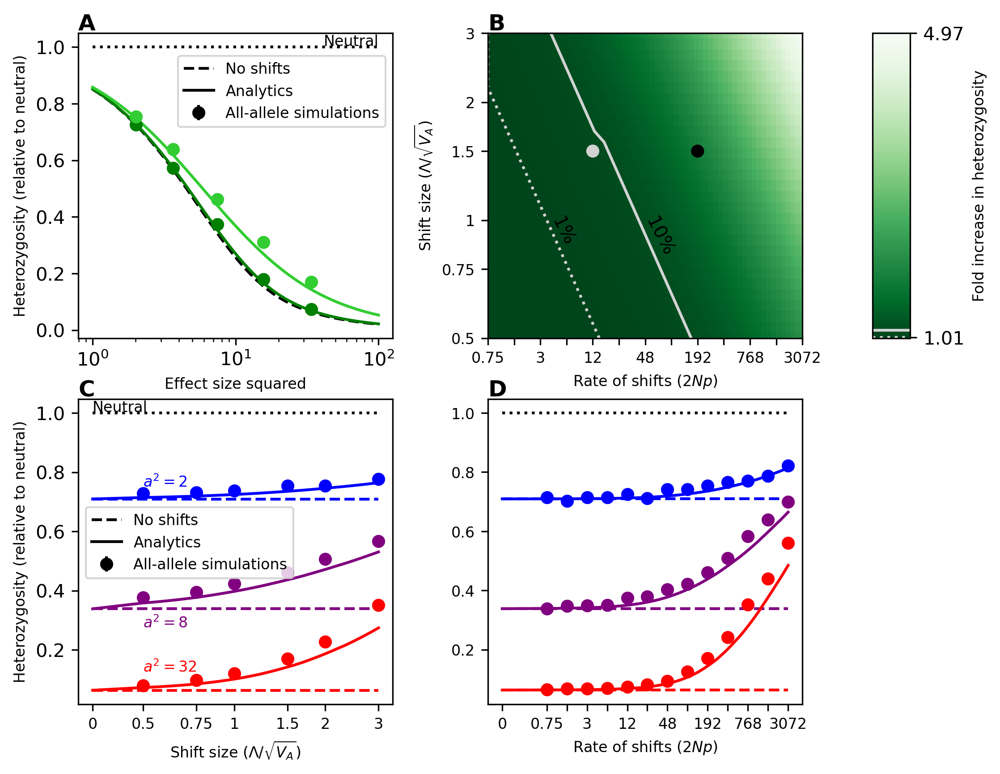

In [11]:
# the heterozygosity under recurrent shifts, in the non-Lande case
fontsize = 8

N = 2000
U = 0.025
E2Ns = 16
nE = 11
indices_ss = [0, 1, 3, 6, 9]

V2Ns = E2Ns ** 2
S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0.,
                                               scale=float(V2Ns) / float(E2Ns))
a_list_pos = [math.sqrt(S_dist.ppf((i + 1) / (nE + 1))) for i in range(nE)]
a_list_pos_between = [math.sqrt(a * a_next) for a, a_next in pairwise(a_list_pos)]

fig = plt.figure(figsize=(8, 6.5), dpi=300)
gs = fig.add_gridspec(2, 5, width_ratios=[25, 3, 25, 1, 3], height_ratios=[1, 1])
# just for spacing
plt.subplot(gs[0, 1]).axis('off')
plt.subplot(gs[1, 1]).axis('off')
plt.subplot(gs[0, 3]).axis('off')
plt.subplot(gs[1, 3]).axis('off')
# not used
plt.subplot(gs[1, 4]).axis('off')
# make gs[0, 4] a colorbar
shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 29
rate_of_shifts_partitioning = 66

x = 2 * N * np.geomspace(rate_of_shifts_list[0] / (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_list[-1] * (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_partitioning + 1)
y = np.geomspace(shift_s0_list[0] / (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_list[-1] * (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_partitioning + 1)
X, Y = np.meshgrid(x, y)

Z = np.empty((shift_s0_partitioning, rate_of_shifts_partitioning))
for index_shift_s0 in range(shift_s0_partitioning):
    for index_rate_of_shift in range(rate_of_shifts_partitioning):
        with open('/insomnia001/depts/pas_lab/users/jc5473/analytic_heterozygosity_N_%d_U_' % N + str(U).replace('.', '_') + '_index_shift_s0_%d_index_rate_of_shift_%d_E2Ns_%d' % (index_shift_s0, index_rate_of_shift, round(E2Ns)), 'rb') as f:
            Z[index_shift_s0, index_rate_of_shift] = pickle.load(f)
Z = np.divide(Z, heterozygosity_(a=np.sqrt(E2Ns)))
z_min, z_max = Z.min(), Z.max()

norm = colors.Normalize(vmin=z_min, vmax=z_max)
sm = plt.cm.ScalarMappable(cmap='Greens_r', norm=norm)
cbar = plt.colorbar(sm, cax=plt.subplot(gs[0, 4]), orientation='vertical')
cbar.set_label('Fold increase in heterozygosity', fontsize=fontsize)
cbar.ax.set_yticks([1.01, z_max])
cbar.ax.set_yticklabels([1.01, '%.2f' % z_max])
cbar.ax.axhline(y=1.01, color='lightgray', linestyle=':')
cbar.ax.axhline(y=1.1, color='lightgray', linestyle='-')
cbar.ax.minorticks_off()
# make the other panels
ax = plt.subplot(gs[0, 0])
ax.text(0, 1.01, 'A', transform=ax.transAxes, fontsize=12, fontweight='bold')

neutral, = ax.plot(np.geomspace(1, 100), [1 for _ in np.geomspace(1, 100)], 'k:')

no_shifts, = ax.plot(np.geomspace(1, 100), [heterozygosity_(a=np.sqrt(ss)) / heterozygosity_(a=0.1) for ss in np.geomspace(1, 100)], 'k--')

index_shift_s0, shift_s0 = 17, 1.5
index_rate_of_shift, rate_of_shift = 22, 0.003

parallel_AA = 49
heterozygosity_each_generation = dict()
heterozygosity_mean = dict()
heterozygosity_se = dict()
for index_ss in indices_ss:
    heterozygosity_each_generation[index_ss] = [h for i in range(1, 1 + parallel_AA) for h in read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/heterozygosity_nE_%d' % (round(E2Ns), i, nE))[index_ss + 1]]
    heterozygosity_mean[index_ss] = np.mean(heterozygosity_each_generation[index_ss])
    heterozygosity_se[index_ss] = np.divide(np.std(heterozygosity_each_generation[index_ss]), np.sqrt(np.size(heterozygosity_each_generation[index_ss])))
for index_ss in indices_ss:
    ax.errorbar(a_list_pos_between[index_ss] ** 2, heterozygosity_mean[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_(a=0.1), yerr=1.96 * heterozygosity_se[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_(a=0.1), fmt='o', color='g')
ax.plot(np.geomspace(1, 100), [heterozygosity_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / heterozygosity_(a=0.1) for ss in np.geomspace(1, 100)], color='g')

index_rate_of_shift, rate_of_shift = 44, 0.048

parallel_AA = 49
heterozygosity_each_generation = dict()
heterozygosity_mean = dict()
heterozygosity_se = dict()
for index_ss in indices_ss:
    heterozygosity_each_generation[index_ss] = [h for i in range(1, 1 + parallel_AA) for h in read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/heterozygosity_nE_%d' % (round(E2Ns), i, nE))[index_ss + 1]]
    heterozygosity_mean[index_ss] = np.mean(heterozygosity_each_generation[index_ss])
    heterozygosity_se[index_ss] = np.divide(np.std(heterozygosity_each_generation[index_ss]), np.sqrt(np.size(heterozygosity_each_generation[index_ss])))
for index_ss in indices_ss:
    ax.errorbar(a_list_pos_between[index_ss] ** 2, heterozygosity_mean[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_(a=0.1), yerr=1.96 * heterozygosity_se[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_(a=0.1), fmt='o', color='limegreen')
ax.plot(np.geomspace(1, 100), [heterozygosity_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / heterozygosity_(a=0.1) for ss in np.geomspace(1, 100)], color='limegreen')

# index_rate_of_shift, rate_of_shift = 54, 0.192

# parallel_AA = 49
# heterozygosity_each_generation = dict()
# heterozygosity_mean = dict()
# heterozygosity_se = dict()
# for index_ss in indices_ss:
#     heterozygosity_each_generation[index_ss] = [h for i in range(1, 1 + parallel_AA) for h in read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/heterozygosity_nE_%d' % (round(E2Ns), i, nE))[index_ss + 1]]
#     heterozygosity_mean[index_ss] = np.mean(heterozygosity_each_generation[index_ss])
#     heterozygosity_se[index_ss] = np.divide(np.std(heterozygosity_each_generation[index_ss]), np.sqrt(np.size(heterozygosity_each_generation[index_ss])))
# for index_ss in indices_ss:
#     ax.errorbar(a_list_pos_between[index_ss] ** 2, heterozygosity_mean[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_(a=0.1), yerr=1.96 * heterozygosity_se[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_(a=0.1), fmt='o', color='lightgreen')
# ax.plot(np.geomspace(1, 100), [heterozygosity_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / heterozygosity_(a=0.1) for ss in np.geomspace(1, 100)], color='lightgreen')

ax.text(x=100, y=1.005, s='Neutral', horizontalalignment='right', color='k', fontsize=fontsize)

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel('Heterozygosity (relative to neutral)', fontsize=fontsize)
ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(1., 0.95), loc='upper right', fontsize=fontsize)

ax = plt.subplot(gs[0, 2])
ax.text(0, 1.01, 'B', transform=ax.transAxes, fontsize=12, fontweight='bold')

norm = colors.Normalize(vmin=z_min, vmax=z_max)
ax.pcolormesh(X, Y, Z, cmap='Greens_r', norm=norm)
ax.plot([2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)[np.searchsorted(Z[index_shift_s0, :], 1.1)] if Z[index_shift_s0, -1] >= 1.1 else None for index_shift_s0, shift_s0 in enumerate(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning))], np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning), color='lightgray', linestyle='-')
ax.plot([2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)[np.searchsorted(Z[index_shift_s0, :], 1.01)] if Z[index_shift_s0, -1] >= 1.01 else None for index_shift_s0, shift_s0 in enumerate(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning))], np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning), color='lightgray', linestyle=':')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(2 * N * rate_of_shifts_list[0], 2 * N * rate_of_shifts_list[-1])
ax.set_ylim(shift_s0_list[0], shift_s0_list[-1])
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_ylabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
assert len(rate_of_shifts_list) % 2 == 1
ax.set_xticks(ticks=list(2 * N * np.array(rate_of_shifts_list)), labels=[2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
ax.set_yticks(ticks=shift_s0_list, labels=shift_s0_list, fontsize=fontsize)
ax.minorticks_off()
ax.text(x=4, y=1, s='1%', color='k', rotation=-63, rotation_mode='anchor')
ax.text(x=48, y=1, s='10%', color='k', rotation=-63, rotation_mode='anchor')
ax.scatter(2 * N * np.array([0.003, 0.048]), [1.5, 1.5], color=['lightgray', 'k'])



ax = plt.subplot(gs[1, 0])
ax.text(0, 1.01, 'C', transform=ax.transAxes, fontsize=12, fontweight='bold')

index_rate_of_shift, rate_of_shift = 44, 0.048

neutral, = ax.plot([0] + shift_s0_list, [1 for _ in [0] + shift_s0_list], 'k:')

simulations = [None, None, None]
no_shifts = [None, None, None]
analytics = [None, None, None]

for i, (index_ss, ss, color) in enumerate([[0, 2.15, 'b'], [3, 7.55, 'purple'], [9, 34.1, 'r']]):
    parallel_AA = 49
    heterozygosity_mean_wrt_shift_s0 = list()
    heterozygosity_se_wrt_shift_s0 = list()
    for shift_s0 in shift_s0_list:
        heterozygosity_each_generation = [h for j in range(1, 1 + parallel_AA) for h in read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/heterozygosity_nE_%d' % (round(E2Ns), j, nE))[index_ss + 1]]
        heterozygosity_mean = np.mean(heterozygosity_each_generation)
        heterozygosity_se = np.divide(np.std(heterozygosity_each_generation), np.sqrt(np.size(heterozygosity_each_generation)))
        heterozygosity_mean_wrt_shift_s0 += [heterozygosity_mean]
        heterozygosity_se_wrt_shift_s0 += [heterozygosity_se]
    simulations[i] = ax.errorbar(shift_s0_list, np.divide(heterozygosity_mean_wrt_shift_s0, 2 * N * U / (nE + 1) * heterozygosity_(a=0.1)), yerr=1.96 * np.divide(heterozygosity_se_wrt_shift_s0, 2 * N * U / (nE + 1) * heterozygosity_(a=0.1)), fmt='o', color=color)
    no_shifts[i], = ax.plot([0] + shift_s0_list, [heterozygosity_(a=np.sqrt(ss)) / heterozygosity_(a=0.1) for _ in [0] + shift_s0_list], color=color, linestyle='--')
    analytics[i], = ax.plot([0] + list(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)), [heterozygosity_(a=np.sqrt(ss)) / heterozygosity_(a=0.1)] + [heterozygosity_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / heterozygosity_(a=0.1) for index_shift_s0, shift_s0 in enumerate(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning))], color=color)

ax.text(x=0, y=1.005, s='Neutral', color='k', fontsize=fontsize)
ax.text(x=shift_s0_list[0], y=0.75, s=r'$a^2=%g$' % 2, color='b', fontsize=fontsize)
ax.text(x=shift_s0_list[0], y=0.275, s=r'$a^2=%g$' % 8, color='purple', fontsize=fontsize)
ax.text(x=shift_s0_list[0], y=0.125, s=r'$a^2=%g$' % 32, color='r', fontsize=fontsize)

simulation_mean = ax.errorbar([], [], yerr=[], fmt='o', color='k', label='All-allele simulations')
no_shifts_mean, = ax.plot([], [], 'k--', label='No shifts')
analytic_mean, = ax.plot([], [], 'k-', label='Analytics')

ax.set_xscale('symlog', linthresh=shift_s0_list[0], linscale=0.15)
ax.set_xlabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
ax.set_ylabel('Heterozygosity (relative to neutral)', fontsize=fontsize)
ax.set_xticks(ticks=[0] + shift_s0_list, labels=[0] + shift_s0_list, fontsize=fontsize)
# ax.set_title('$E[a^2]=%d, 2Np=%g$' % (round(E2Ns), 2 * N * rate_of_shift), fontsize=fontsize)
ax.legend(bbox_to_anchor=(0., 0.67), loc='upper left', fontsize=fontsize)
ax.minorticks_off()

ax = plt.subplot(gs[1, 2])
ax.text(0, 1.01, 'D', transform=ax.transAxes, fontsize=12, fontweight='bold')

index_shift_s0, shift_s0 = 17, 1.5

neutral, = ax.plot([0] + list(2 * N * np.array(rate_of_shifts_list)), [1 for _ in [0] + rate_of_shifts_list], 'k:')

simulations = [None, None, None]
no_shifts = [None, None, None]
analytics = [None, None, None]

for i, (index_ss, ss, color) in enumerate([[0, 2.15, 'b'], [3, 7.55, 'purple'], [9, 34.1, 'r']]):
    parallel_AA = 49
    heterozygosity_mean_wrt_rate_of_shifts = list()
    heterozygosity_se_wrt_rate_of_shifts = list()
    for rate_of_shift in rate_of_shifts_list:
        heterozygosity_each_generation = [h for j in range(1, 1 + parallel_AA) for h in read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/heterozygosity_nE_%d' % (round(E2Ns), j, nE))[index_ss + 1]]
        heterozygosity_mean = np.mean(heterozygosity_each_generation)
        heterozygosity_se = np.divide(np.std(heterozygosity_each_generation), np.sqrt(np.size(heterozygosity_each_generation)))
        heterozygosity_mean_wrt_rate_of_shifts += [heterozygosity_mean]
        heterozygosity_se_wrt_rate_of_shifts += [heterozygosity_se]
    simulations[i] = ax.errorbar(2 * N * np.array(rate_of_shifts_list), np.divide(heterozygosity_mean_wrt_rate_of_shifts, 2 * N * U / (nE + 1) * heterozygosity_(a=0.1)), yerr=1.96 * np.divide(heterozygosity_se_wrt_rate_of_shifts, 2 * N * U / (nE + 1) * heterozygosity_(a=0.1)), fmt='o', color=color)
    no_shifts[i], = ax.plot([0] + list(2 * N * np.array(rate_of_shifts_list)), [heterozygosity_(a=np.sqrt(ss)) / heterozygosity_(a=0.1) for _ in [0] + rate_of_shifts_list], color=color, linestyle='--')
    analytics[i], = ax.plot([0] + list(2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)), [heterozygosity_(a=np.sqrt(ss)) / heterozygosity_(a=0.1)] + [heterozygosity_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / heterozygosity_(a=0.1) for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))], color=color)

ax.set_xscale('symlog', linthresh=2 * N * rate_of_shifts_list[0], linscale=0.6)
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_xticks(ticks=[0] + list(2 * N * np.array(rate_of_shifts_list)), labels=[0] + [2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
# ax.set_title('$E[a^2]=%d, \Lambda=%g\sqrt{V_A}$' % (round(E2Ns), shift_s0), fontsize=fontsize)
ax.minorticks_off()

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

/tmp/ipykernel_4115922/3027982274.py:32: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  return quad(lambda x: 2.0 * x * (1.0 - x) * tau(a, x, 1/(2*N)), 0.0, 1.0, points = [1/(2*N), 1.0 - 1/(2*N)])[0]


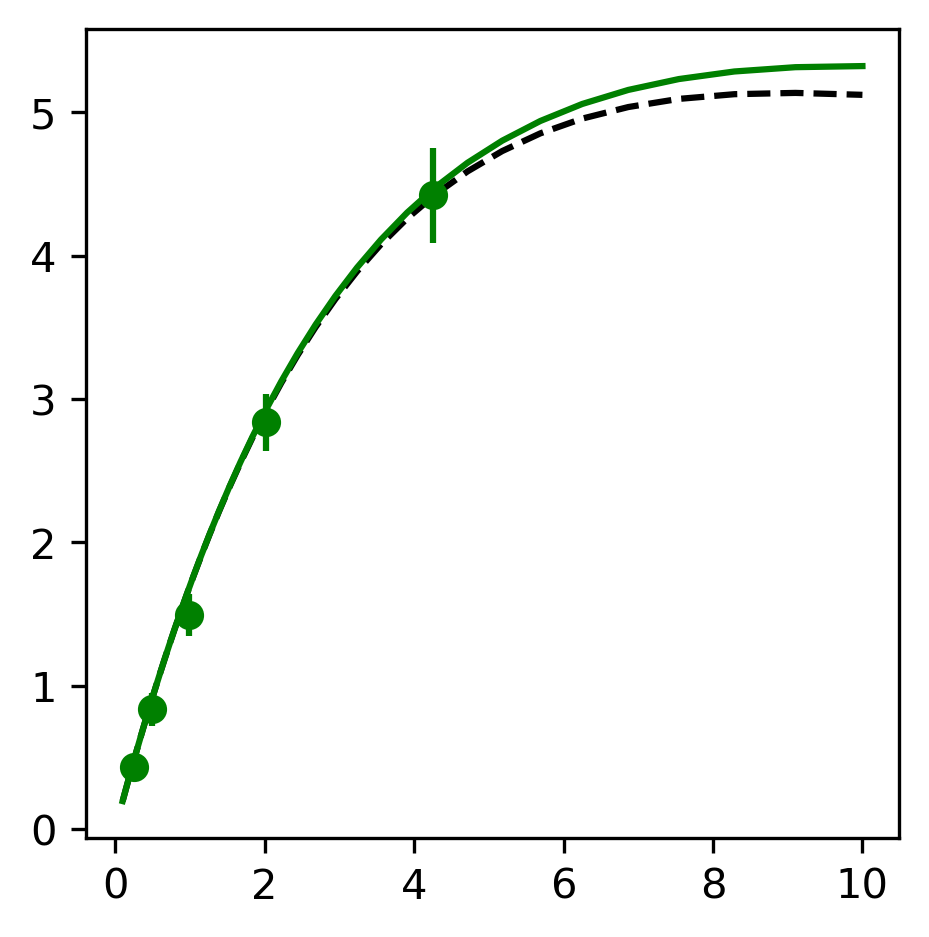

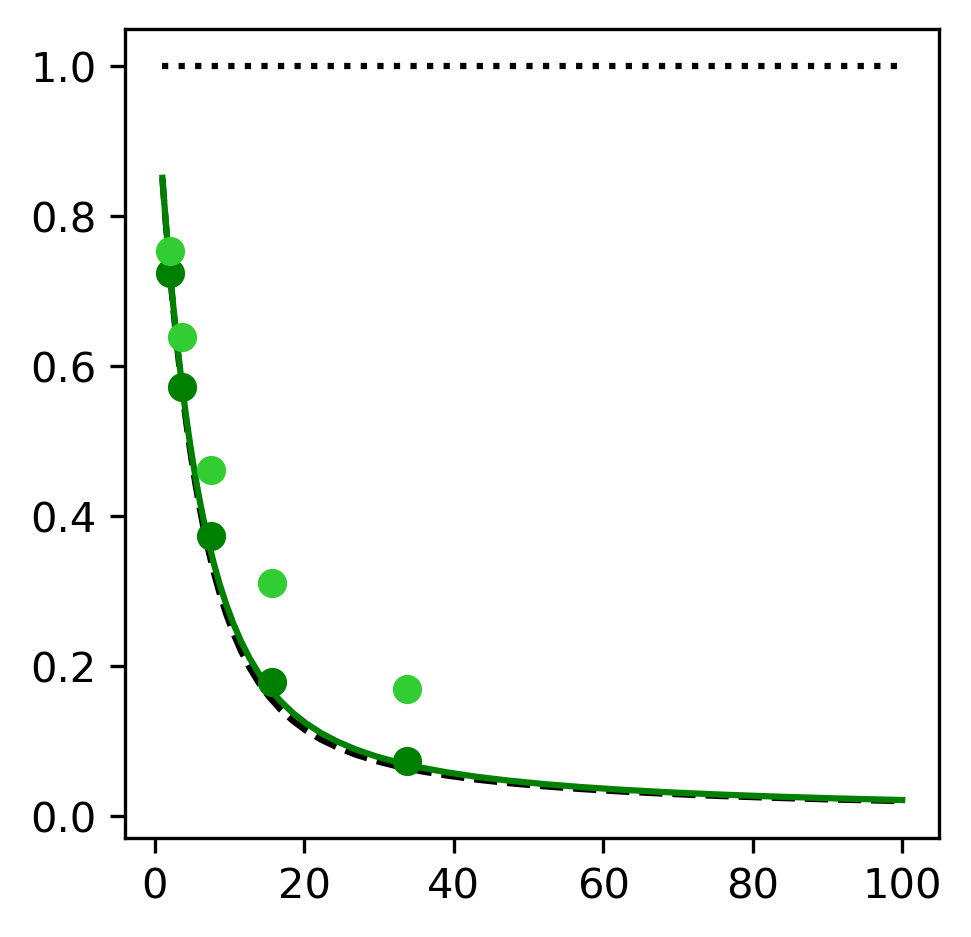

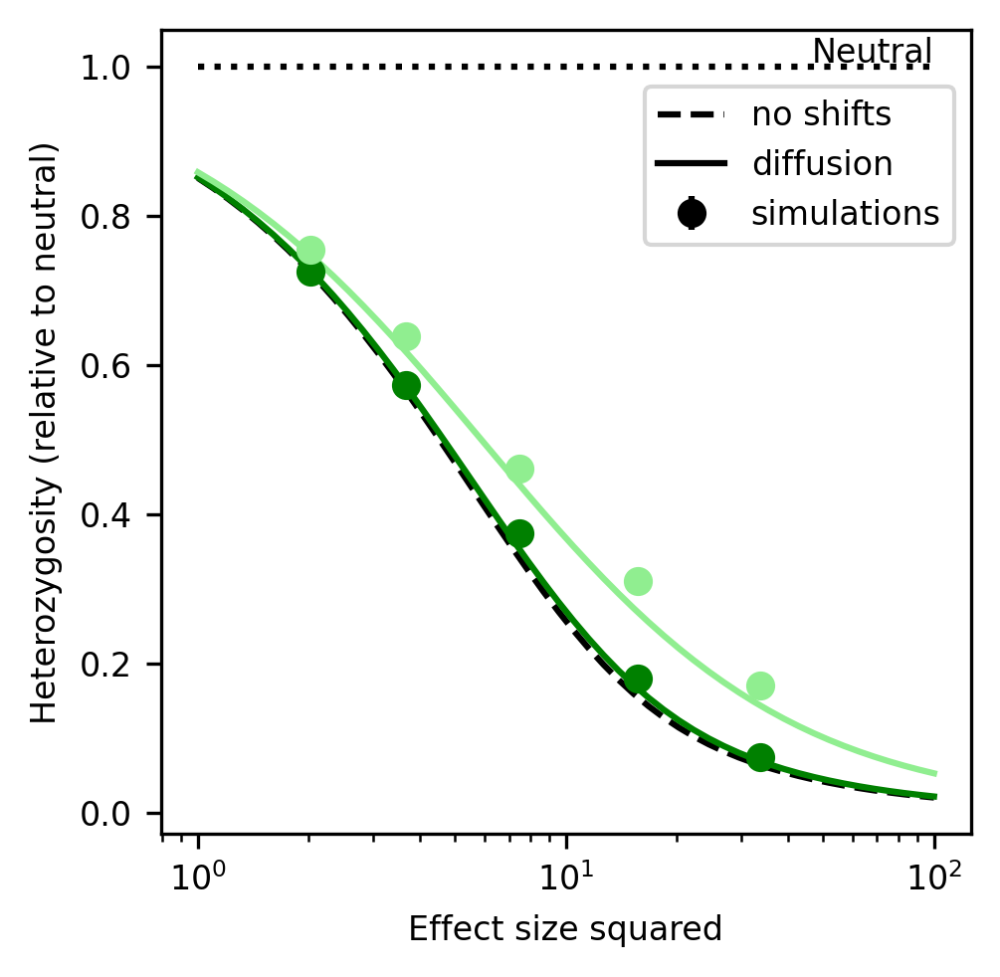

In [10]:
fontsize = 8

N = 2000
U = 0.025
E2Ns = 16
nE = 11
indices_ss = [0, 1, 3, 6, 9]

V2Ns = E2Ns ** 2
S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0.,
                                               scale=float(V2Ns) / float(E2Ns))
a_list_pos = [math.sqrt(S_dist.ppf((i + 1) / (nE + 1))) for i in range(nE)]
a_list_pos_between = [math.sqrt(a * a_next) for a, a_next in pairwise(a_list_pos)]

fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = fig.add_subplot(1, 1, 1)

shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 29
rate_of_shifts_partitioning = 66

neutral, = ax.plot(np.geomspace(1, 100), [1 for _ in np.geomspace(1, 100)], 'k:')

no_shifts, = ax.plot(np.geomspace(1, 100), [heterozygosity_(a=np.sqrt(ss)) / heterozygosity_(a=0.1) for ss in np.geomspace(1, 100)], 'k--')

index_shift_s0, shift_s0 = 17, 1.5
index_rate_of_shift, rate_of_shift = 22, 0.003

parallel_AA = 49
heterozygosity_each_generation = dict()
heterozygosity_mean = dict()
heterozygosity_se = dict()
for index_ss in indices_ss:
    heterozygosity_each_generation[index_ss] = [h for i in range(1, 1 + parallel_AA) for h in read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/heterozygosity_nE_%d' % (round(E2Ns), i, nE))[index_ss + 1]]
    heterozygosity_mean[index_ss] = np.mean(heterozygosity_each_generation[index_ss])
    heterozygosity_se[index_ss] = np.divide(np.std(heterozygosity_each_generation[index_ss]), np.sqrt(np.size(heterozygosity_each_generation[index_ss])))
for index_ss in indices_ss:
    ax.errorbar(a_list_pos_between[index_ss] ** 2, heterozygosity_mean[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_(a=0.1), yerr=1.96 * heterozygosity_se[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_(a=0.1), fmt='o', color='g')
ax.plot(np.geomspace(1, 100), [heterozygosity_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / heterozygosity_(a=0.1) for ss in np.geomspace(1, 100)], color='g')

index_rate_of_shift, rate_of_shift = 44, 0.048

parallel_AA = 49
heterozygosity_each_generation = dict()
heterozygosity_mean = dict()
heterozygosity_se = dict()
for index_ss in indices_ss:
    heterozygosity_each_generation[index_ss] = [h for i in range(1, 1 + parallel_AA) for h in read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/heterozygosity_nE_%d' % (round(E2Ns), i, nE))[index_ss + 1]]
    heterozygosity_mean[index_ss] = np.mean(heterozygosity_each_generation[index_ss])
    heterozygosity_se[index_ss] = np.divide(np.std(heterozygosity_each_generation[index_ss]), np.sqrt(np.size(heterozygosity_each_generation[index_ss])))
for index_ss in indices_ss:
    ax.errorbar(a_list_pos_between[index_ss] ** 2, heterozygosity_mean[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_(a=0.1), yerr=1.96 * heterozygosity_se[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_(a=0.1), fmt='o', color='lightgreen')
ax.plot(np.geomspace(1, 100), [heterozygosity_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / heterozygosity_(a=0.1) for ss in np.geomspace(1, 100)], color='lightgreen')

ax.text(x=100, y=1.005, s='Neutral', horizontalalignment='right', color='k', fontsize=fontsize)

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel('Heterozygosity (relative to neutral)', fontsize=fontsize)
ax.legend(handles=[no_shifts, analytics, simulations], labels=['no shifts', 'diffusion', 'simulations'], bbox_to_anchor=(1., 0.95), loc='upper right', fontsize=fontsize)

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

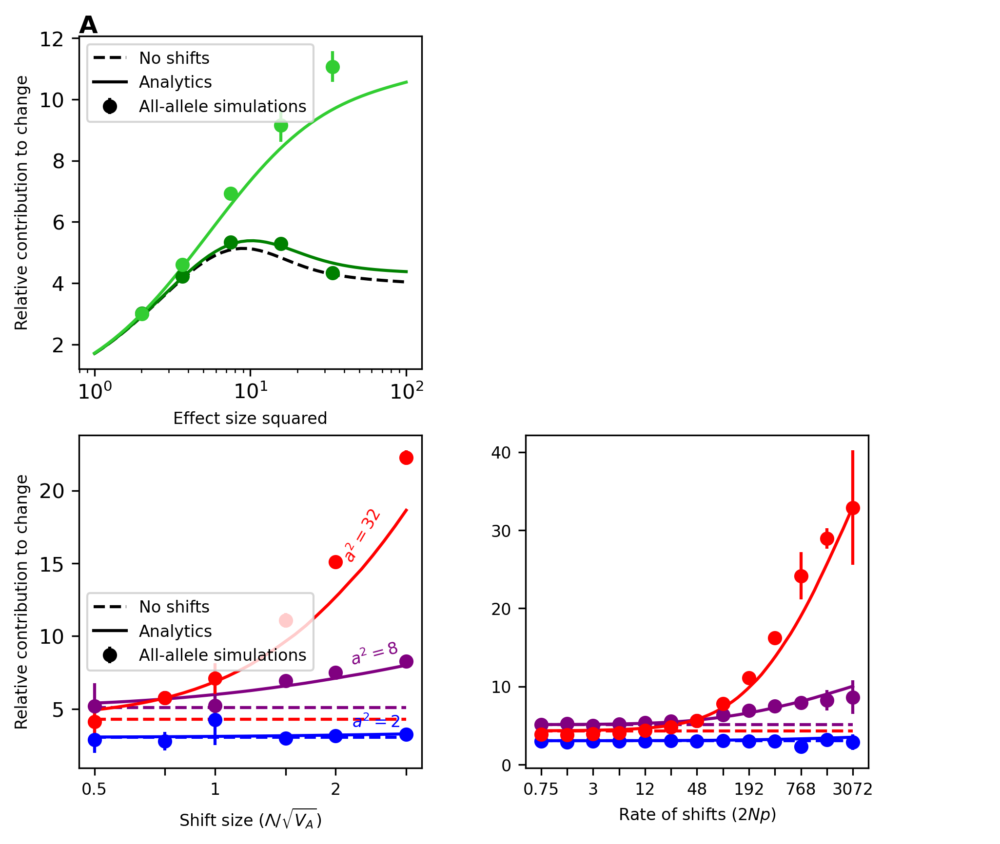

In [5]:
# the relative allelic contribution to the short-term phenotypic change after a shift, in the non-Lande case
fontsize = 8

N = 2000
U = 0.025
E2Ns = 16
nE = 11
indices_ss = [0, 1, 3, 6, 9]

V2Ns = E2Ns ** 2
S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0.,
                                               scale=float(V2Ns) / float(E2Ns))
a_list_pos = [math.sqrt(S_dist.ppf((i + 1) / (nE + 1))) for i in range(nE)]
a_list_pos_between = [math.sqrt(a * a_next) for a, a_next in pairwise(a_list_pos)]

fig = plt.figure(figsize=(8, 6.5), dpi=300)
gs = fig.add_gridspec(2, 5, width_ratios=[25, 3, 25, 1, 3], height_ratios=[1, 1])
# just for spacing
plt.subplot(gs[0, 1]).axis('off')
plt.subplot(gs[1, 1]).axis('off')
plt.subplot(gs[0, 3]).axis('off')
plt.subplot(gs[1, 3]).axis('off')
# not used
plt.subplot(gs[1, 4]).axis('off')

shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 29
rate_of_shifts_partitioning = 66

ax = plt.subplot(gs[0, 0])
ax.text(0, 1.01, 'A', transform=ax.transAxes, fontsize=12, fontweight='bold')

no_shifts, = ax.plot(np.geomspace(1, 100), [v_(a=np.sqrt(ss)) for ss in np.geomspace(1, 100)], 'k--')

index_shift_s0, shift_s0 = 17, 1.5
index_rate_of_shift, rate_of_shift = 22, 0.003

parallel_AA = 49
contribution_to_change_each_shift = dict()
contribution_to_change_mean = dict()
contribution_to_change_se = dict()
for index_ss in indices_ss:
    contribution_to_change_each_shift[index_ss] = list()
# obtain the relative contribution to change of alleles with each a^2 in each generation, which are separated by at least 10N generations
for i in range(1, 1 + parallel_AA):
    with open('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/fixations_and_extinctions' % (round(E2Ns), i), 'rb') as f:
        d2ax_t_1_scaled = pickle.load(f)[-1]
    for d2ax_t_1_scaled_each_shift in d2ax_t_1_scaled:
        for index_ss in indices_ss:
            contribution_to_change_each_shift[index_ss].append(0.0)
        for mut in [mut for mut in d2ax_t_1_scaled_each_shift if np.searchsorted(a_list_pos, abs(mut[0])) - 1 in indices_ss]:
            contribution_to_change_each_shift[np.searchsorted(a_list_pos, abs(mut[0])) - 1][-1] += mut[1]
for index_ss in indices_ss:
    contribution_to_change_mean[index_ss] = np.mean(contribution_to_change_each_shift[index_ss])
    contribution_to_change_se[index_ss] = np.std(contribution_to_change_each_shift[index_ss]) / np.sqrt(np.size(contribution_to_change_each_shift[index_ss]))
for index_ss in indices_ss:
    ax.errorbar(a_list_pos_between[index_ss] ** 2, contribution_to_change_mean[index_ss] / (2 * N * U / (nE + 1)), yerr=1.96 * contribution_to_change_se[index_ss] / (2 * N * U / (nE + 1)), fmt='o', color='g')
ax.plot(np.geomspace(1, 100), [v_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) for ss in np.geomspace(1, 100)], color='g')

index_rate_of_shift, rate_of_shift = 44, 0.048

parallel_AA = 49
contribution_to_change_each_shift = dict()
contribution_to_change_mean = dict()
contribution_to_change_se = dict()
for index_ss in indices_ss:
    contribution_to_change_each_shift[index_ss] = list()
# obtain the relative contribution to change of alleles with each a^2 in each generation, which are separated by at least 10N generations
for i in range(1, 1 + parallel_AA):
    with open('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/fixations_and_extinctions' % (round(E2Ns), i), 'rb') as f:
        d2ax_t_1_scaled = pickle.load(f)[-1]
    for d2ax_t_1_scaled_each_shift in d2ax_t_1_scaled:
        for index_ss in indices_ss:
            contribution_to_change_each_shift[index_ss].append(0.0)
        for mut in [mut for mut in d2ax_t_1_scaled_each_shift if np.searchsorted(a_list_pos, abs(mut[0])) - 1 in indices_ss]:
            contribution_to_change_each_shift[np.searchsorted(a_list_pos, abs(mut[0])) - 1][-1] += mut[1]
for index_ss in indices_ss:
    contribution_to_change_mean[index_ss] = np.mean(contribution_to_change_each_shift[index_ss])
    contribution_to_change_se[index_ss] = np.std(contribution_to_change_each_shift[index_ss]) / np.sqrt(np.size(contribution_to_change_each_shift[index_ss]))
for index_ss in indices_ss:
    ax.errorbar(a_list_pos_between[index_ss] ** 2, contribution_to_change_mean[index_ss] / (2 * N * U / (nE + 1)), yerr=1.96 * contribution_to_change_se[index_ss] / (2 * N * U / (nE + 1)), fmt='o', color='limegreen')
ax.plot(np.geomspace(1, 100), [v_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) for ss in np.geomspace(1, 100)], color='limegreen')

# index_rate_of_shift, rate_of_shift = 54, 0.192

# parallel_AA = 49
# contribution_to_change_each_shift = dict()
# contribution_to_change_mean = dict()
# contribution_to_change_se = dict()
# for index_ss in indices_ss:
#     contribution_to_change_each_shift[index_ss] = list()
# # obtain the relative contribution to change of alleles with each a^2 in each generation, which are separated by at least 10N generations
# for i in range(1, 1 + parallel_AA):
#     with open('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/fixations_and_extinctions' % (round(E2Ns), i), 'rb') as f:
#         d2ax_t_1_scaled = pickle.load(f)[-1]
#     for d2ax_t_1_scaled_each_shift in d2ax_t_1_scaled:
#         for index_ss in indices_ss:
#             contribution_to_change_each_shift[index_ss].append(0.0)
#         for mut in [mut for mut in d2ax_t_1_scaled_each_shift if np.searchsorted(a_list_pos, abs(mut[0])) - 1 in indices_ss]:
#             contribution_to_change_each_shift[np.searchsorted(a_list_pos, abs(mut[0])) - 1][-1] += mut[1]
# for index_ss in indices_ss:
#     contribution_to_change_mean[index_ss] = np.mean(contribution_to_change_each_shift[index_ss])
#     contribution_to_change_se[index_ss] = np.std(contribution_to_change_each_shift[index_ss]) / np.sqrt(np.size(contribution_to_change_each_shift[index_ss]))
# for index_ss in indices_ss:
#     ax.errorbar(a_list_pos_between[index_ss] ** 2, contribution_to_change_mean[index_ss] / (2 * N * U / (nE + 1)), yerr=1.96 * contribution_to_change_se[index_ss] / (2 * N * U / (nE + 1)), fmt='o', color='lightgreen')
# ax.plot(np.geomspace(1, 100), [v_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) for ss in np.geomspace(1, 100)], color='lightgreen')

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel('Relative contribution to change', fontsize=fontsize)
ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 1.), loc='upper left', fontsize=fontsize)

# Graph II for relative contribution to short-term phenotypic adaptation (w.r.t. shift size & w.r.t. rate of shifts; different effect sizes)

ax = plt.subplot(gs[1, 0])

index_rate_of_shift, rate_of_shift = 44, 0.048

simulations = [None, None, None]
no_shifts = [None, None, None]
analytics = [None, None, None]

for i, (index_ss, ss, color) in enumerate([[0, 2.15, 'b'], [3, 7.55, 'purple'], [9, 34.1, 'r']]):
    parallel_AA = 49
    contribution_to_change_mean_wrt_shift_s0 = list()
    contribution_to_change_se_wrt_shift_s0 = list()
    for shift_s0 in shift_s0_list:
        contribution_to_change_each_shift = list()
        for j in range(1, 1 + parallel_AA):
            with open('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/fixations_and_extinctions' % (round(E2Ns), j), 'rb') as f:
                d2ax_t_1_scaled = pickle.load(f)[-1]
            for d2ax_t_1_scaled_each_shift in d2ax_t_1_scaled:
                contribution_to_change_each_shift.append(0.0)
                for mut in [mut for mut in d2ax_t_1_scaled_each_shift if np.searchsorted(a_list_pos, abs(mut[0])) - 1 == index_ss]:
                    contribution_to_change_each_shift[-1] += mut[1]
        contribution_to_change_mean = np.mean(contribution_to_change_each_shift)
        contribution_to_change_se = np.divide(np.std(contribution_to_change_each_shift), np.sqrt(np.size(contribution_to_change_each_shift)))
        contribution_to_change_mean_wrt_shift_s0 += [contribution_to_change_mean]
        contribution_to_change_se_wrt_shift_s0 += [contribution_to_change_se]
    simulations[i] = ax.errorbar(shift_s0_list, np.divide(contribution_to_change_mean_wrt_shift_s0, 2 * N * U / (nE + 1)), yerr=1.96 * np.divide(contribution_to_change_se_wrt_shift_s0, 2 * N * U / (nE + 1)), fmt='o', color=color)
    no_shifts[i], = ax.plot(shift_s0_list, [v_(a=np.sqrt(ss)) for _ in shift_s0_list], color=color, linestyle='--')
    analytics[i], = ax.plot(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning), [v_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) for index_shift_s0, shift_s0 in enumerate(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning))], color=color)

ax.text(x=2.2, y=3.75, s=r'$a^2=%g$' % 2, color='b', fontsize=fontsize)
ax.text(x=2.2, y=8, s=r'$a^2=%g$' % 8, rotation=15, rotation_mode='anchor', color='purple', fontsize=fontsize)
ax.text(x=2.2, y=15, s=r'$a^2=%g$' % 32, rotation=60, rotation_mode='anchor', color='r', fontsize=fontsize)

simulation_mean = ax.errorbar([], [], yerr=[], fmt='o', color='k', label='All-allele simulations')
no_shifts_mean, = ax.plot([], [], 'k--', label='No shifts')
analytic_mean, = ax.plot([], [], 'k-', label='Analytics')

ax.set_xscale('log')
ax.set_xlabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
ax.set_ylabel('Relative contribution to change', fontsize=fontsize)
ax.set_xticks(ticks=shift_s0_list, labels=[shift_s0 if index_shift_s0 % 2 == 0 else None for index_shift_s0, shift_s0 in enumerate(shift_s0_list)], fontsize=fontsize)
# ax.set_title('$E[a^2]=%d, 2Np=%g$' % (round(E2Ns), 2 * N * rate_of_shift), fontsize=fontsize)
ax.legend(bbox_to_anchor=(0., 0.55), loc='upper left', fontsize=fontsize)
ax.minorticks_off()

ax = plt.subplot(gs[1, 2])

index_shift_s0, shift_s0 = 17, 1.5

simulations = [None, None, None]
no_shifts = [None, None, None]
analytics = [None, None, None]

for i, (index_ss, ss, color) in enumerate([[0, 2.15, 'b'], [3, 7.55, 'purple'], [9, 34.1, 'r']]):
    parallel_AA = 49
    contribution_to_change_mean_wrt_rate_of_shifts = list()
    contribution_to_change_se_wrt_rate_of_shifts = list()
    for rate_of_shift in rate_of_shifts_list:
        contribution_to_change_each_shift = list()
        for j in range(1, 1 + parallel_AA):
            with open('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/fixations_and_extinctions' % (round(E2Ns), j), 'rb') as f:
                d2ax_t_1_scaled = pickle.load(f)[-1]
            for d2ax_t_1_scaled_each_shift in d2ax_t_1_scaled:
                contribution_to_change_each_shift.append(0.0)
                for mut in [mut for mut in d2ax_t_1_scaled_each_shift if np.searchsorted(a_list_pos, abs(mut[0])) - 1 == index_ss]:
                    contribution_to_change_each_shift[-1] += mut[1]
        contribution_to_change_mean = np.mean(contribution_to_change_each_shift)
        contribution_to_change_se = np.divide(np.std(contribution_to_change_each_shift), np.sqrt(np.size(contribution_to_change_each_shift)))
        contribution_to_change_mean_wrt_rate_of_shifts += [contribution_to_change_mean]
        contribution_to_change_se_wrt_rate_of_shifts += [contribution_to_change_se]
    simulations[i] = ax.errorbar(2 * N * np.array(rate_of_shifts_list), np.divide(contribution_to_change_mean_wrt_rate_of_shifts, 2 * N * U / (nE + 1)), yerr=1.96 * np.divide(contribution_to_change_se_wrt_rate_of_shifts, 2 * N * U / (nE + 1)), fmt='o', color=color)
    no_shifts[i], = ax.plot(2 * N * np.array(rate_of_shifts_list), [v_(a=np.sqrt(ss)) for _ in rate_of_shifts_list], color=color, linestyle='--')
    analytics[i], = ax.plot(2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning), [v_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))], color=color)

ax.set_xscale('log')
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_xticks(ticks=list(2 * N * np.array(rate_of_shifts_list)), labels=[2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
# ax.set_title('$E[a^2]=%d, \Lambda=%g\sqrt{V_A}$' % (round(E2Ns), shift_s0), fontsize=fontsize)
ax.minorticks_off()

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

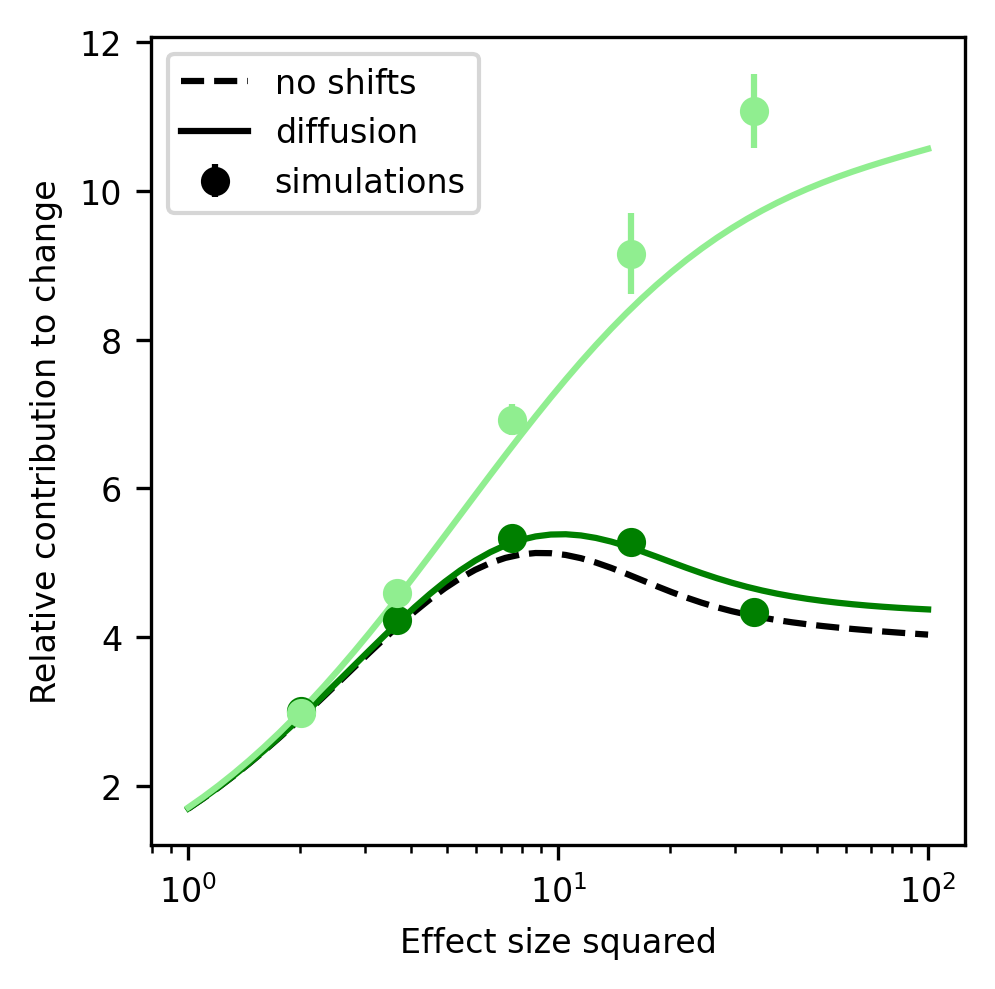

In [11]:
fontsize = 8

N = 2000
U = 0.025
E2Ns = 16
nE = 11
indices_ss = [0, 1, 3, 6, 9]

V2Ns = E2Ns ** 2
S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0.,
                                               scale=float(V2Ns) / float(E2Ns))
a_list_pos = [math.sqrt(S_dist.ppf((i + 1) / (nE + 1))) for i in range(nE)]
a_list_pos_between = [math.sqrt(a * a_next) for a, a_next in pairwise(a_list_pos)]

fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = fig.add_subplot(1, 1, 1)

shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 29
rate_of_shifts_partitioning = 66

no_shifts, = ax.plot(np.geomspace(1, 100), [v_(a=np.sqrt(ss)) for ss in np.geomspace(1, 100)], 'k--')

index_shift_s0, shift_s0 = 17, 1.5
index_rate_of_shift, rate_of_shift = 22, 0.003

parallel_AA = 49
contribution_to_change_each_shift = dict()
contribution_to_change_mean = dict()
contribution_to_change_se = dict()
for index_ss in indices_ss:
    contribution_to_change_each_shift[index_ss] = list()
# obtain the relative contribution to change of alleles with each a^2 in each generation, which are separated by at least 10N generations
for i in range(1, 1 + parallel_AA):
    with open('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/fixations_and_extinctions' % (round(E2Ns), i), 'rb') as f:
        d2ax_t_1_scaled = pickle.load(f)[-1]
    for d2ax_t_1_scaled_each_shift in d2ax_t_1_scaled:
        for index_ss in indices_ss:
            contribution_to_change_each_shift[index_ss].append(0.0)
        for mut in [mut for mut in d2ax_t_1_scaled_each_shift if np.searchsorted(a_list_pos, abs(mut[0])) - 1 in indices_ss]:
            contribution_to_change_each_shift[np.searchsorted(a_list_pos, abs(mut[0])) - 1][-1] += mut[1]
for index_ss in indices_ss:
    contribution_to_change_mean[index_ss] = np.mean(contribution_to_change_each_shift[index_ss])
    contribution_to_change_se[index_ss] = np.std(contribution_to_change_each_shift[index_ss]) / np.sqrt(np.size(contribution_to_change_each_shift[index_ss]))
for index_ss in indices_ss:
    ax.errorbar(a_list_pos_between[index_ss] ** 2, contribution_to_change_mean[index_ss] / (2 * N * U / (nE + 1)), yerr=1.96 * contribution_to_change_se[index_ss] / (2 * N * U / (nE + 1)), fmt='o', color='g')
ax.plot(np.geomspace(1, 100), [v_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) for ss in np.geomspace(1, 100)], color='g')

index_rate_of_shift, rate_of_shift = 44, 0.048

parallel_AA = 49
contribution_to_change_each_shift = dict()
contribution_to_change_mean = dict()
contribution_to_change_se = dict()
for index_ss in indices_ss:
    contribution_to_change_each_shift[index_ss] = list()
# obtain the relative contribution to change of alleles with each a^2 in each generation, which are separated by at least 10N generations
for i in range(1, 1 + parallel_AA):
    with open('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/fixations_and_extinctions' % (round(E2Ns), i), 'rb') as f:
        d2ax_t_1_scaled = pickle.load(f)[-1]
    for d2ax_t_1_scaled_each_shift in d2ax_t_1_scaled:
        for index_ss in indices_ss:
            contribution_to_change_each_shift[index_ss].append(0.0)
        for mut in [mut for mut in d2ax_t_1_scaled_each_shift if np.searchsorted(a_list_pos, abs(mut[0])) - 1 in indices_ss]:
            contribution_to_change_each_shift[np.searchsorted(a_list_pos, abs(mut[0])) - 1][-1] += mut[1]
for index_ss in indices_ss:
    contribution_to_change_mean[index_ss] = np.mean(contribution_to_change_each_shift[index_ss])
    contribution_to_change_se[index_ss] = np.std(contribution_to_change_each_shift[index_ss]) / np.sqrt(np.size(contribution_to_change_each_shift[index_ss]))
for index_ss in indices_ss:
    ax.errorbar(a_list_pos_between[index_ss] ** 2, contribution_to_change_mean[index_ss] / (2 * N * U / (nE + 1)), yerr=1.96 * contribution_to_change_se[index_ss] / (2 * N * U / (nE + 1)), fmt='o', color='lightgreen')
ax.plot(np.geomspace(1, 100), [v_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) for ss in np.geomspace(1, 100)], color='lightgreen')

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel('Relative contribution to change', fontsize=fontsize)
ax.legend(handles=[no_shifts, analytics, simulations], labels=['no shifts', 'diffusion', 'simulations'], bbox_to_anchor=(0., 1.), loc='upper left', fontsize=fontsize)

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

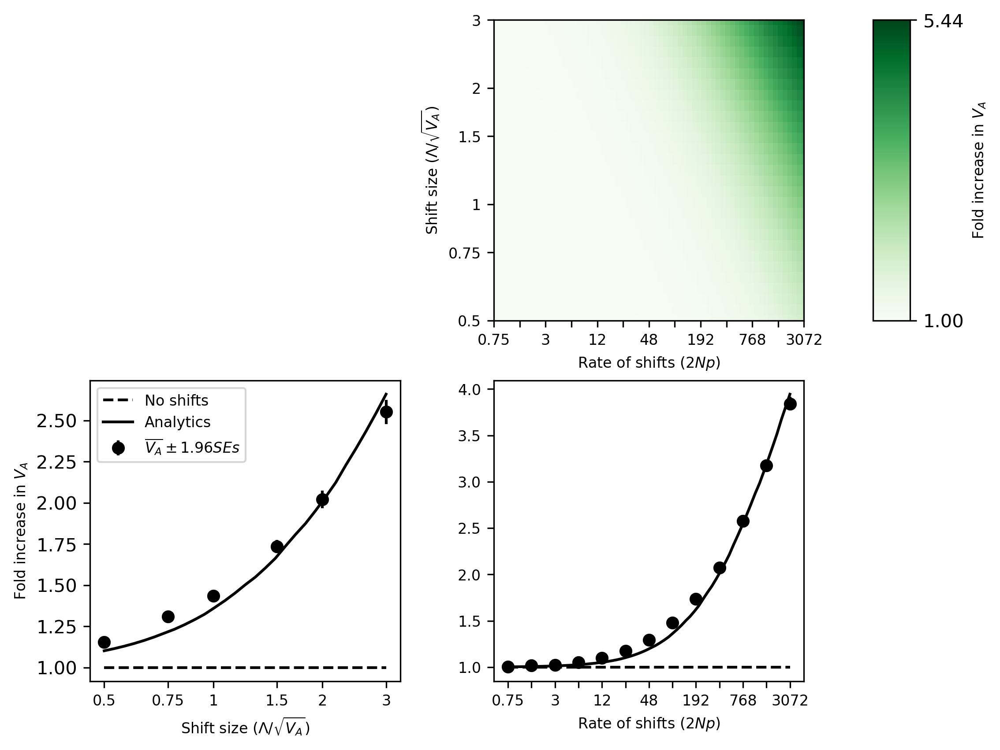

In [8]:
# the analytic V_A, in the non-Lande case

fontsize = 8

N = 2000
U = 0.025
E2Ns = 16

fig = plt.figure(figsize=(8, 6.5), dpi=300)
gs = fig.add_gridspec(2, 5, width_ratios=[25, 3, 25, 1, 3], height_ratios=[1, 1])
# just for spacing
plt.subplot(gs[0, 1]).axis('off')
plt.subplot(gs[1, 1]).axis('off')
plt.subplot(gs[0, 3]).axis('off')
plt.subplot(gs[1, 3]).axis('off')
# not used
plt.subplot(gs[0, 0]).axis('off')
plt.subplot(gs[1, 4]).axis('off')
# make gs[0, 4] a colorbar
norm = colors.Normalize(vmin=analytic_V_A_nonLande.min() / V_A(E2Ns=E2Ns), vmax=analytic_V_A_nonLande.max() / V_A(E2Ns=E2Ns))
sm = plt.cm.ScalarMappable(cmap='Greens', norm=norm)
cbar = plt.colorbar(sm, cax=plt.subplot(gs[0, 4]), orientation='vertical')
cbar.set_label(r'Fold increase in $V_A$', fontsize=fontsize)
cbar.ax.set_yticks([analytic_V_A_nonLande.min() / V_A(E2Ns=E2Ns), analytic_V_A_nonLande.max() / V_A(E2Ns=E2Ns)])
cbar.ax.set_yticklabels(['%.2f' % (analytic_V_A_nonLande.min() / V_A(E2Ns=E2Ns)), '%.2f' % (analytic_V_A_nonLande.max() / V_A(E2Ns=E2Ns))])
cbar.ax.minorticks_off()
# make the other panels
ax = plt.subplot(gs[0, 2])

shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 29
rate_of_shifts_partitioning = 66

x = 2 * N * np.geomspace(rate_of_shifts_list[0] / (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_list[-1] * (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_partitioning + 1)
y = np.geomspace(shift_s0_list[0] / (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_list[-1] * (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_partitioning + 1)
X, Y = np.meshgrid(x, y)
ax.pcolormesh(X, Y, np.divide(analytic_V_A_nonLande, V_A(E2Ns=E2Ns)), cmap='Greens', norm=norm)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(2 * N * rate_of_shifts_list[0], 2 * N * rate_of_shifts_list[-1])
ax.set_ylim(shift_s0_list[0], shift_s0_list[-1])
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_ylabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
assert len(rate_of_shifts_list) % 2 == 1
ax.set_xticks(ticks=list(2 * N * np.array(rate_of_shifts_list)), labels=[2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
ax.set_yticks(ticks=shift_s0_list, labels=shift_s0_list, fontsize=fontsize)
ax.minorticks_off()

empirical_V_A_nonLande_mean = np.zeros((6, 13))
empirical_V_A_nonLande_se = np.zeros((6, 13))
for E2Ns, index_shift_s0, shift_s0, index_rate_of_shift, rate_of_shift in [(E2Ns, index_shift_s0, shift_s0, index_rate_of_shift, rate_of_shift) for E2Ns in [E2Ns, ] for index_shift_s0, shift_s0 in enumerate(shift_s0_list) for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)]:
    parallel_AA = 49
    var_ess_every_10N_generations = list()
    for i in range(1, 1 + parallel_AA):
        with open('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_nE_%d_empirical_average_V_A_%d/fixation_probability' % (round(E2Ns), 11, i), 'rb') as f:
            var_ess_every_10N_generations.extend(pickle.load(f)[3][10 * N::10 * N])
    empirical_V_A_nonLande_mean[index_shift_s0][index_rate_of_shift] = np.mean(var_ess_every_10N_generations)
    empirical_V_A_nonLande_se[index_shift_s0][index_rate_of_shift] = np.std(var_ess_every_10N_generations) / np.sqrt(np.size(var_ess_every_10N_generations))

ax = plt.subplot(gs[1, 0])
index_rate_of_shift, rate_of_shift = 44, 0.048
ax.plot(shift_s0_list, [1 for _ in shift_s0_list], 'k--', label='No shifts')
ax.plot(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning), np.divide(analytic_V_A_nonLande[:, index_rate_of_shift], V_A(E2Ns=E2Ns)), 'k-', label='Analytics')
ax.errorbar(shift_s0_list, np.divide(empirical_V_A_nonLande_mean[:, np.searchsorted(rate_of_shifts_list, rate_of_shift)], V_A(E2Ns=E2Ns)), yerr=1.96 * np.divide(empirical_V_A_nonLande_se[:, np.searchsorted(rate_of_shifts_list, rate_of_shift)], V_A(E2Ns=E2Ns)), fmt='o', color='k', label=r'$\overline{V_A} \pm 1.96SEs$')
ax.set_xscale('log')
ax.set_xlabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
ax.set_ylabel(r'Fold increase in $V_A$', fontsize=fontsize)
ax.set_xticks(ticks=shift_s0_list, labels=shift_s0_list, fontsize=fontsize)
# ax.set_title('$E[a^2]=%d, 2Np=%g$' % (round(E2Ns), 2 * N * rate_of_shift), fontsize=fontsize)
ax.legend(bbox_to_anchor=(0., 1.), loc='upper left', fontsize=fontsize)
ax.minorticks_off()

ax = plt.subplot(gs[1, 2])
index_shift_s0, shift_s0 = 17, 1.5
ax.plot(2 * N * np.array(rate_of_shifts_list), [1 for _ in rate_of_shifts_list], 'k--', label='No shifts')
ax.plot(2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning), np.divide(analytic_V_A_nonLande[index_shift_s0], V_A(E2Ns=E2Ns)), 'k-', label='Analytics')
ax.errorbar(2 * N * np.array(rate_of_shifts_list), np.divide(empirical_V_A_nonLande_mean[np.searchsorted(shift_s0_list, shift_s0)], V_A(E2Ns=E2Ns)), yerr=1.96 * np.divide(empirical_V_A_nonLande_se[np.searchsorted(shift_s0_list, shift_s0)], V_A(E2Ns=E2Ns)), fmt='o', color='k', label=r'$\overline{V_A} \pm 1.96SEs$')
ax.set_xscale('log')
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_xticks(ticks=list(2 * N * np.array(rate_of_shifts_list)), labels=[2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
# ax.set_title('$E[a^2]=%d, \Lambda=%g\sqrt{V_A}$' % (round(E2Ns), shift_s0), fontsize=fontsize)
ax.minorticks_off()

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

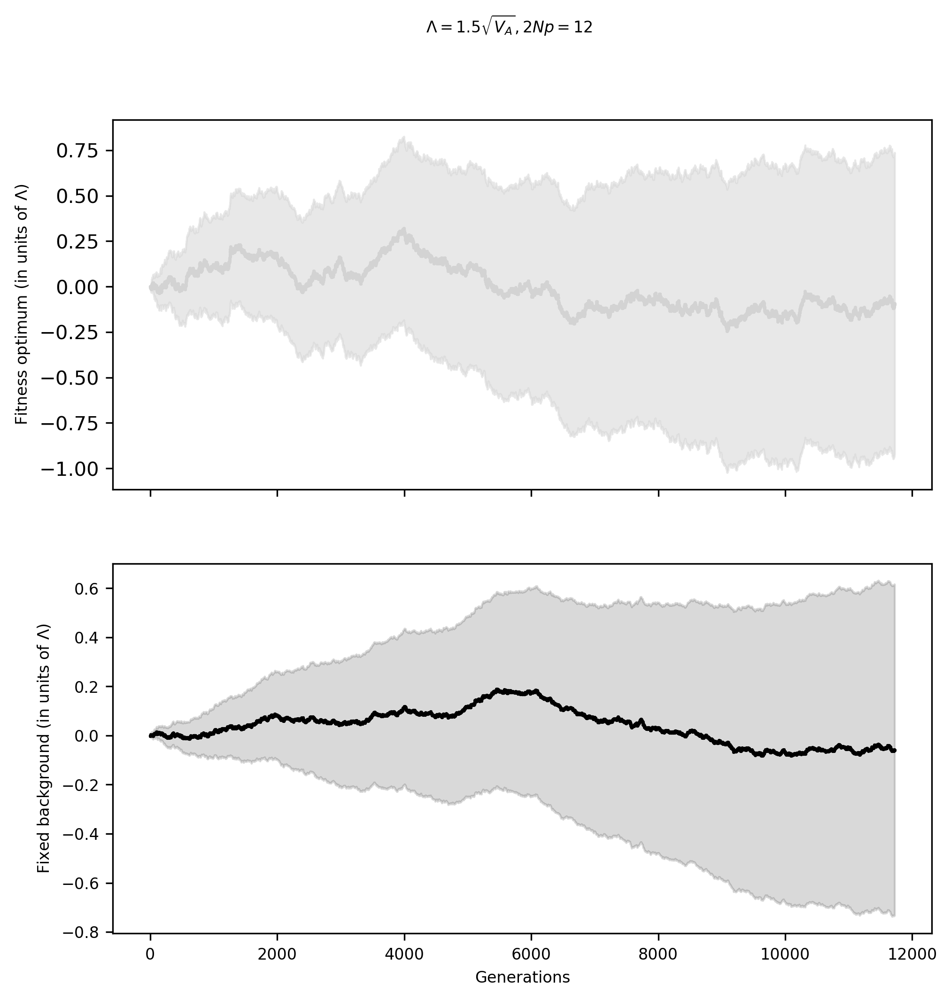

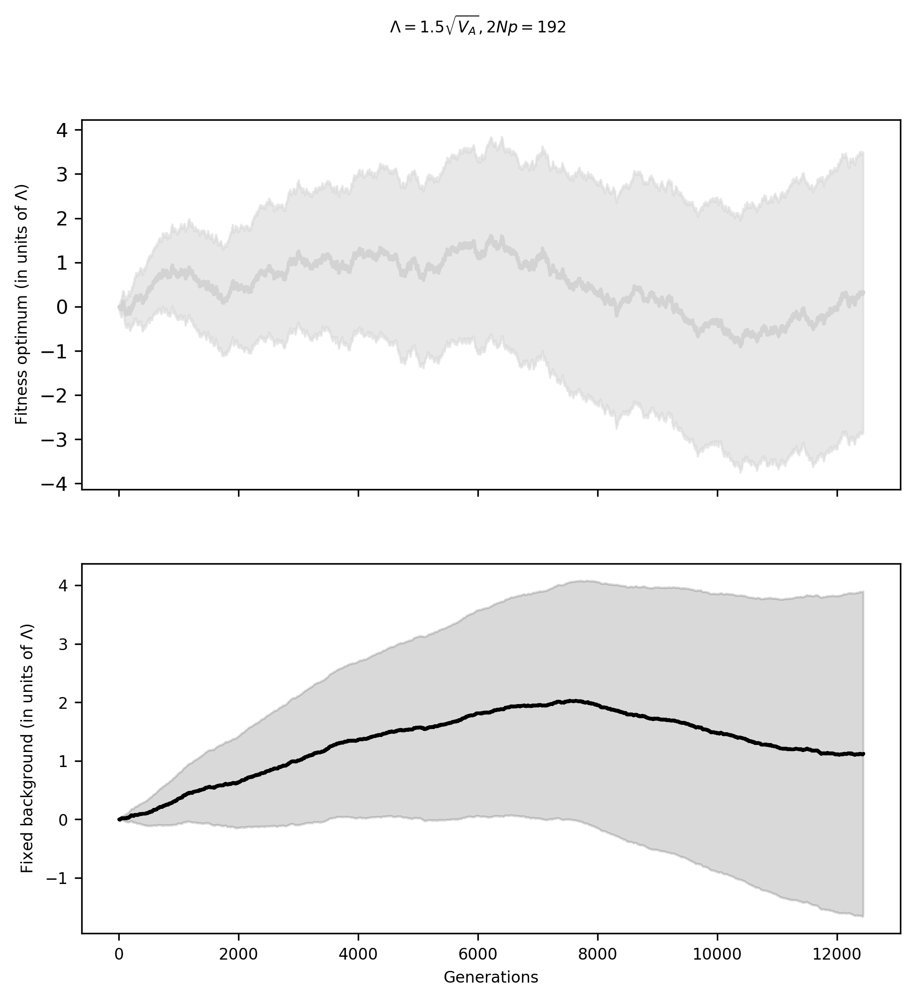

In [16]:
# the fitness optimum and the fixed background over time, in the Lande case
# mean ± 1.96SEs
fontsize = 8

N = 2000
U = 0.025

for E2Ns, index_shift_s0, shift_s0, index_rate_of_shift, rate_of_shift in [(E2Ns, index_shift_s0, shift_s0, index_rate_of_shift, rate_of_shift) for E2Ns in [1, ] for index_shift_s0, shift_s0, index_rate_of_shift, rate_of_shift in [[3, 1.5, 4, 0.003], [3, 1.5, 8, 0.048]]]:
    parallel_AA = 49
    # 4 independent chunks; see details below
    fitness_optimum_over_time = [None for _ in range(4 * parallel_AA)]
    fixed_background_over_time = [None for _ in range(4 * parallel_AA)]
    for i in range(1, 1 + parallel_AA):
        with open('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_updated_empirical_average_V_A_%d/fixations_and_extinctions' % (round(E2Ns), i), 'rb') as f:
            dist_ess_over_time, _, _, mean_fixed_ess_over_time = pickle.load(f)[2:]
        assert len(dist_ess_over_time) == len(mean_fixed_ess_over_time)
        shift_times_directional = [tM * round((dist_ess_over_time[tM] - dist_ess_over_time[tM - 1]) / abs(dist_ess_over_time[tM] - dist_ess_over_time[tM - 1])) for tM in range(0, len(dist_ess_over_time)) if abs(dist_ess_over_time[tM] - dist_ess_over_time[tM - 1]) >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])]
        fitness_optimum = 0
        fitness_optimum_over_time[i - 1] = [fitness_optimum for _ in range(0, len(dist_ess_over_time))]
        for shift_time_directional, next_shift_time_directional in pairwise(shift_times_directional):
            fitness_optimum += np.sign(shift_time_directional)
            fitness_optimum_over_time[i - 1][abs(shift_time_directional):abs(next_shift_time_directional)] = [fitness_optimum for _ in range(abs(shift_time_directional), abs(next_shift_time_directional))]
        fitness_optimum += np.sign(shift_times_directional[-1])
        fitness_optimum_over_time[i - 1][abs(shift_times_directional[-1]):len(dist_ess_over_time)] = [fitness_optimum for _ in range(abs(shift_times_directional[-1]), len(dist_ess_over_time))]
        fixed_background_over_time[i - 1] = mean_fixed_ess_over_time
    # truncate until the shortest simulation
    least_number_of_generations = min([len(fitness_optimum_over_time[i]) for i in range(parallel_AA)])
    for i in range(parallel_AA):
        fitness_optimum_over_time[i][least_number_of_generations:] = []
        fixed_background_over_time[i][least_number_of_generations:] = []
    # enlarge the sample size by taking the 1st, 4th, 7th, and 10th deciles, which are independent because of 10N-generation gaps inbetween
    for i in range(parallel_AA, 4 * parallel_AA):
        fitness_optimum_over_time[i] = np.subtract(fitness_optimum_over_time[i % parallel_AA][10 * N + 3 * (i // parallel_AA) * int(0.1 * (least_number_of_generations - 10 * N)):10 * N + 3 * (i // parallel_AA) * int(0.1 * (least_number_of_generations - 10 * N)) + int(0.1 * (least_number_of_generations - 10 * N))], fitness_optimum_over_time[i % parallel_AA][10 * N + 3 * (i // parallel_AA) * int(0.1 * (least_number_of_generations - 10 * N))])
        fixed_background_over_time[i] = np.subtract(fixed_background_over_time[i % parallel_AA][10 * N + 3 * (i // parallel_AA) * int(0.1 * (least_number_of_generations - 10 * N)):10 * N + 3 * (i // parallel_AA) * int(0.1 * (least_number_of_generations - 10 * N)) + int(0.1 * (least_number_of_generations - 10 * N))], fixed_background_over_time[i % parallel_AA][10 * N + 3 * (i // parallel_AA) * int(0.1 * (least_number_of_generations - 10 * N))])
    for i in range(parallel_AA):
        fitness_optimum_over_time[i][10 * N + int(0.1 * (least_number_of_generations - 10 * N)):] = []
        fitness_optimum_over_time[i][:10 * N] = []
        fitness_optimum_over_time[i] = np.subtract(fitness_optimum_over_time[i], fitness_optimum_over_time[i][0])
        fixed_background_over_time[i][10 * N + int(0.1 * (least_number_of_generations - 10 * N)):] = []
        fixed_background_over_time[i][:10 * N] = []
        fixed_background_over_time[i] = np.subtract(fixed_background_over_time[i], fixed_background_over_time[i][0])
    # calculate mean and se
    fitness_optimum_mean_over_time = np.mean(fitness_optimum_over_time, axis=0)
    fitness_optimum_se_over_time = np.divide(np.std(fitness_optimum_over_time, axis=0), np.sqrt(np.size(fitness_optimum_over_time, axis=0)))
    fixed_background_mean_over_time = np.mean(fixed_background_over_time, axis=0)
    fixed_background_se_over_time = np.divide(np.std(fixed_background_over_time, axis=0), np.sqrt(np.size(fixed_background_over_time, axis=0)))
    fig = plt.figure(figsize=(7.5, 7.5), dpi=300)
    axs = fig.subplots(2, 1, sharex=True)
    axs[0].scatter(range(int(0.1 * (least_number_of_generations - 10 * N))), fitness_optimum_mean_over_time, marker='.', s=2, color='lightgray')
    axs[0].fill_between(x=range(int(0.1 * (least_number_of_generations - 10 * N))), y1=np.subtract(fitness_optimum_mean_over_time, 1.96 * fitness_optimum_se_over_time), y2=np.add(fitness_optimum_mean_over_time, 1.96 * fitness_optimum_se_over_time), color='lightgray', alpha=0.5)
    axs[0].set_ylabel(r'Fitness optimum (in units of $\Lambda$)', fontsize=fontsize)
    axs[1].scatter(range(int(0.1 * (least_number_of_generations - 10 * N))), np.divide(fixed_background_mean_over_time, shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])), marker='.', s=2, color='k')
    axs[1].fill_between(x=range(int(0.1 * (least_number_of_generations - 10 * N))), y1=np.divide(np.subtract(fixed_background_mean_over_time, 1.96 * fixed_background_se_over_time), shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])), y2=np.divide(np.add(fixed_background_mean_over_time, 1.96 * fixed_background_se_over_time), shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])), color='k', alpha=0.15)
    axs[1].set_ylabel(r'Fixed background (in units of $\Lambda$)', fontsize=fontsize)
    plt.xlabel('Generations', fontsize=fontsize)
    plt.xticks(fontsize=fontsize)
    plt.yticks(fontsize=fontsize)
    plt.suptitle(r'$\Lambda=%g\sqrt{V_A}, 2Np=%g$' % (shift_s0, 2 * N * rate_of_shift), fontsize=fontsize)
    plt.show()

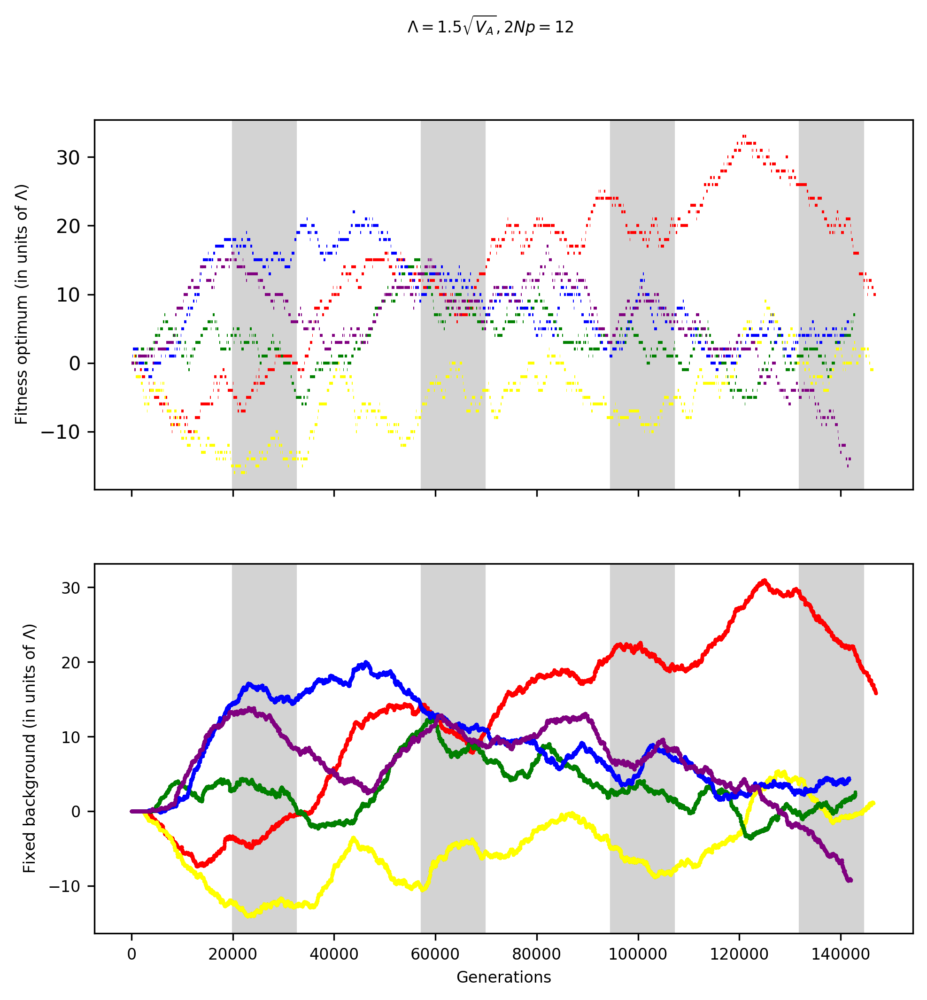

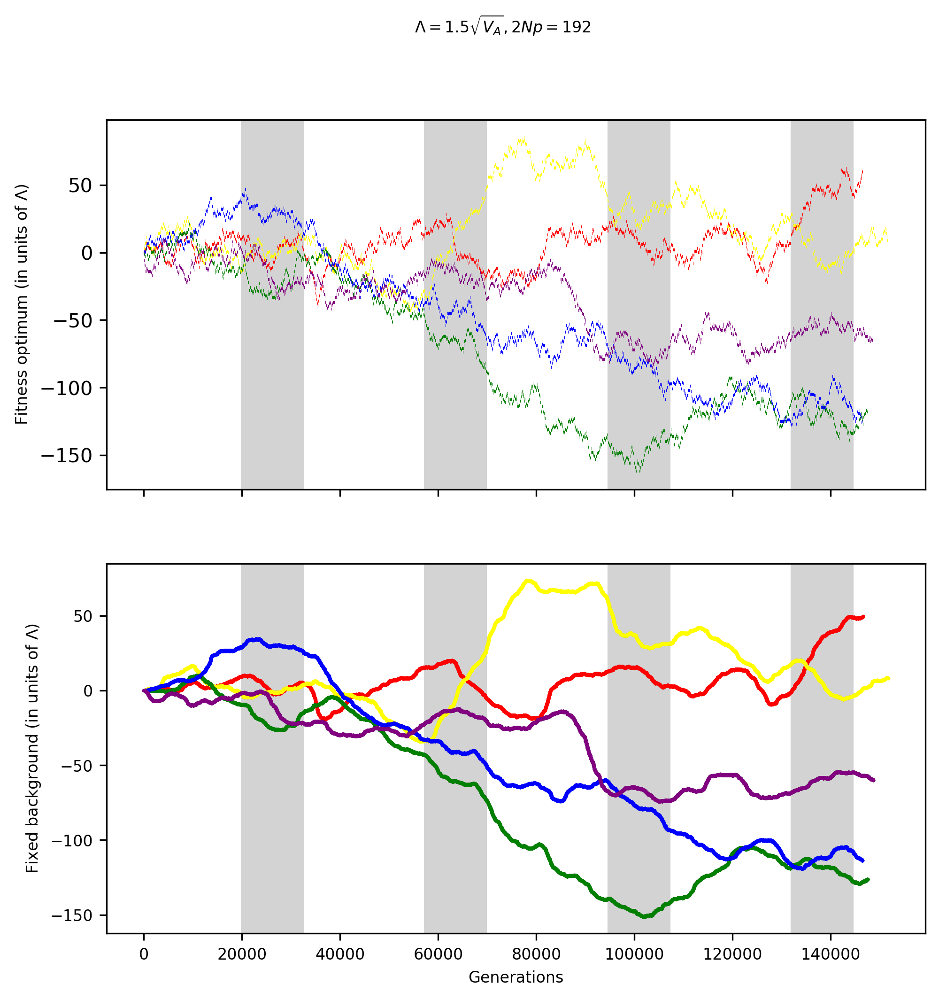

In [10]:
# the fitness optimum and the fixed background over time, in the Lande case
# 5 replicates
fontsize = 8

N = 2000
U = 0.025

for E2Ns, index_shift_s0, shift_s0, index_rate_of_shift, rate_of_shift in [(E2Ns, index_shift_s0, shift_s0, index_rate_of_shift, rate_of_shift) for E2Ns in [1, ] for index_shift_s0, shift_s0, index_rate_of_shift, rate_of_shift in [[3, 1.5, 4, 0.003], [3, 1.5, 8, 0.048]]]:
    fig = plt.figure(figsize=(7.5, 7.5), dpi=300)
    axs = fig.subplots(2, 1, sharex=True)
    for ax in axs:
        ax.axvspan(10 * N + 0 * int(0.1 * (least_number_of_generations - 10 * N)), 10 * N + 1 * int(0.1 * (least_number_of_generations - 10 * N)), color='lightgray')
        ax.axvspan(10 * N + 3 * int(0.1 * (least_number_of_generations - 10 * N)), 10 * N + 4 * int(0.1 * (least_number_of_generations - 10 * N)), color='lightgray')
        ax.axvspan(10 * N + 6 * int(0.1 * (least_number_of_generations - 10 * N)), 10 * N + 7 * int(0.1 * (least_number_of_generations - 10 * N)), color='lightgray')
        ax.axvspan(10 * N + 9 * int(0.1 * (least_number_of_generations - 10 * N)), 10 * N + 10 * int(0.1 * (least_number_of_generations - 10 * N)), color='lightgray')
    for i, color in [(9, 'r'), (19, 'yellow'), (29, 'g'), (39, 'b'), (49, 'purple')]:
        with open('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_updated_empirical_average_V_A_%d/fixations_and_extinctions' % (round(E2Ns), i), 'rb') as f:
            dist_ess_over_time, _, _, mean_fixed_ess_over_time = pickle.load(f)[2:]
        assert len(dist_ess_over_time) == len(mean_fixed_ess_over_time)
        shift_times_directional = [tM * round((dist_ess_over_time[tM] - dist_ess_over_time[tM - 1]) / abs(dist_ess_over_time[tM] - dist_ess_over_time[tM - 1])) for tM in range(0, len(dist_ess_over_time)) if abs(dist_ess_over_time[tM] - dist_ess_over_time[tM - 1]) >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])]
        fitness_optimum = 0
        axs[0].hlines(y=fitness_optimum, xmin=0, xmax=abs(shift_times_directional[0]), colors=color)
        for shift_time_directional, next_shift_time_directional in pairwise(shift_times_directional):
            fitness_optimum += np.sign(shift_time_directional)
            axs[0].hlines(y=fitness_optimum, xmin=abs(shift_time_directional), xmax=abs(next_shift_time_directional), colors=color)
        fitness_optimum += np.sign(shift_times_directional[-1])
        axs[0].hlines(y=fitness_optimum, xmin=abs(shift_times_directional[-1]), xmax=len(dist_ess_over_time), colors=color)
        axs[0].set_ylabel(r'Fitness optimum (in units of $\Lambda$)', fontsize=fontsize)
        axs[1].scatter(range(len(mean_fixed_ess_over_time)), np.divide(mean_fixed_ess_over_time, shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])), marker='.', color=color, s=2)
        axs[1].set_ylabel(r'Fixed background (in units of $\Lambda$)', fontsize=fontsize)
    plt.xlabel('Generations', fontsize=fontsize)
    plt.xticks(fontsize=fontsize)
    plt.yticks(fontsize=fontsize)
    plt.suptitle(r'$\Lambda=%g\sqrt{V_A}, 2Np=%g$' % (shift_s0, 2 * N * rate_of_shift), fontsize=fontsize)
    plt.show()

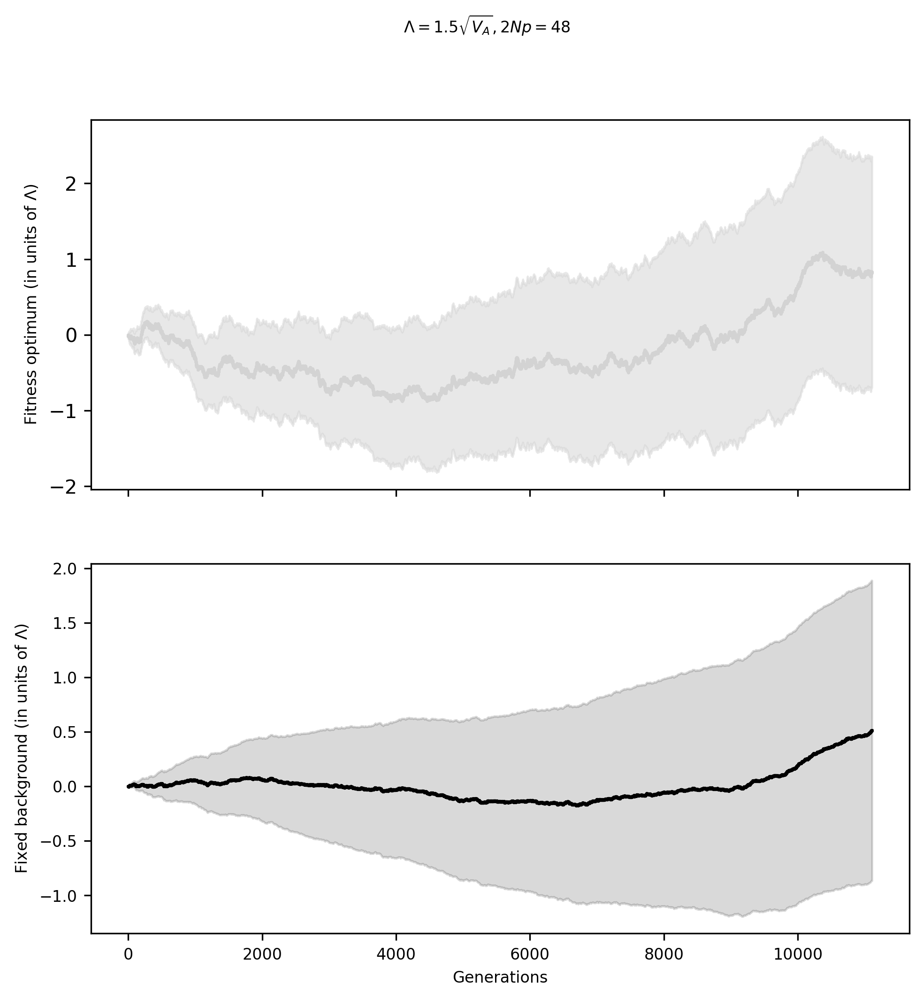

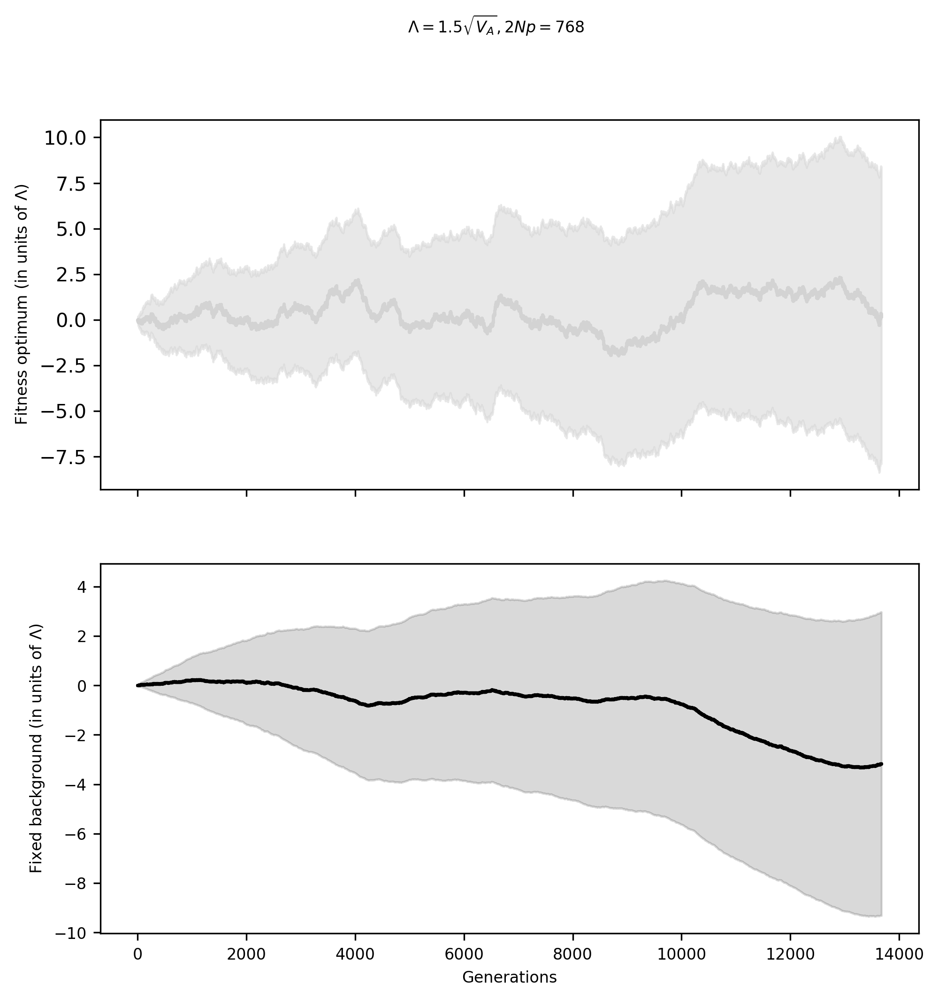

In [6]:
# the fitness optimum and the fixed background over time, in the non-Lande case
# mean ± 1.96SEs
fontsize = 8

N = 2000
U = 0.025

for E2Ns, index_shift_s0, shift_s0, index_rate_of_shift, rate_of_shift in [(E2Ns, index_shift_s0, shift_s0, index_rate_of_shift, rate_of_shift) for E2Ns in [16, ] for index_shift_s0, shift_s0, index_rate_of_shift, rate_of_shift in [[3, 1.5, 6, 0.012], [3, 1.5, 10, 0.192]]]:
    parallel_AA = 49
    # 4 independent chunks; see details below
    fitness_optimum_over_time = [None for _ in range(4 * parallel_AA)]
    fixed_background_over_time = [None for _ in range(4 * parallel_AA)]
    for i in range(1, 1 + parallel_AA):
        with open('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_updated_empirical_average_V_A_%d/fixations_and_extinctions' % (round(E2Ns), i), 'rb') as f:
            dist_ess_over_time, _, _, mean_fixed_ess_over_time = pickle.load(f)[2:]
        assert len(dist_ess_over_time) == len(mean_fixed_ess_over_time)
        shift_times_directional = [tM * round((dist_ess_over_time[tM] - dist_ess_over_time[tM - 1]) / abs(dist_ess_over_time[tM] - dist_ess_over_time[tM - 1])) for tM in range(0, len(dist_ess_over_time)) if abs(dist_ess_over_time[tM] - dist_ess_over_time[tM - 1]) >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])]
        fitness_optimum = 0
        fitness_optimum_over_time[i - 1] = [fitness_optimum for _ in range(0, len(dist_ess_over_time))]
        for shift_time_directional, next_shift_time_directional in pairwise(shift_times_directional):
            fitness_optimum += np.sign(shift_time_directional)
            fitness_optimum_over_time[i - 1][abs(shift_time_directional):abs(next_shift_time_directional)] = [fitness_optimum for _ in range(abs(shift_time_directional), abs(next_shift_time_directional))]
        fitness_optimum += np.sign(shift_times_directional[-1])
        fitness_optimum_over_time[i - 1][abs(shift_times_directional[-1]):len(dist_ess_over_time)] = [fitness_optimum for _ in range(abs(shift_times_directional[-1]), len(dist_ess_over_time))]
        fixed_background_over_time[i - 1] = mean_fixed_ess_over_time
    # truncate until the shortest simulation
    least_number_of_generations = min([len(fitness_optimum_over_time[i]) for i in range(parallel_AA)])
    for i in range(parallel_AA):
        fitness_optimum_over_time[i][least_number_of_generations:] = []
        fixed_background_over_time[i][least_number_of_generations:] = []
    # enlarge the sample size by taking the 1st, 4th, 7th, and 10th deciles, which are independent because of 10N-generation gaps inbetween
    for i in range(parallel_AA, 4 * parallel_AA):
        fitness_optimum_over_time[i] = np.subtract(fitness_optimum_over_time[i % parallel_AA][10 * N + 3 * (i // parallel_AA) * int(0.1 * (least_number_of_generations - 10 * N)):10 * N + 3 * (i // parallel_AA) * int(0.1 * (least_number_of_generations - 10 * N)) + int(0.1 * (least_number_of_generations - 10 * N))], fitness_optimum_over_time[i % parallel_AA][10 * N + 3 * (i // parallel_AA) * int(0.1 * (least_number_of_generations - 10 * N))])
        fixed_background_over_time[i] = np.subtract(fixed_background_over_time[i % parallel_AA][10 * N + 3 * (i // parallel_AA) * int(0.1 * (least_number_of_generations - 10 * N)):10 * N + 3 * (i // parallel_AA) * int(0.1 * (least_number_of_generations - 10 * N)) + int(0.1 * (least_number_of_generations - 10 * N))], fixed_background_over_time[i % parallel_AA][10 * N + 3 * (i // parallel_AA) * int(0.1 * (least_number_of_generations - 10 * N))])
    for i in range(parallel_AA):
        fitness_optimum_over_time[i][10 * N + int(0.1 * (least_number_of_generations - 10 * N)):] = []
        fitness_optimum_over_time[i][:10 * N] = []
        fitness_optimum_over_time[i] = np.subtract(fitness_optimum_over_time[i], fitness_optimum_over_time[i][0])
        fixed_background_over_time[i][10 * N + int(0.1 * (least_number_of_generations - 10 * N)):] = []
        fixed_background_over_time[i][:10 * N] = []
        fixed_background_over_time[i] = np.subtract(fixed_background_over_time[i], fixed_background_over_time[i][0])
    # calculate mean and se
    fitness_optimum_mean_over_time = np.mean(fitness_optimum_over_time, axis=0)
    fitness_optimum_se_over_time = np.divide(np.std(fitness_optimum_over_time, axis=0), np.sqrt(np.size(fitness_optimum_over_time, axis=0)))
    fixed_background_mean_over_time = np.mean(fixed_background_over_time, axis=0)
    fixed_background_se_over_time = np.divide(np.std(fixed_background_over_time, axis=0), np.sqrt(np.size(fixed_background_over_time, axis=0)))
    fig = plt.figure(figsize=(7.5, 7.5), dpi=300)
    axs = fig.subplots(2, 1, sharex=True)
    axs[0].scatter(range(int(0.1 * (least_number_of_generations - 10 * N))), fitness_optimum_mean_over_time, marker='.', s=2, color='lightgray')
    axs[0].fill_between(x=range(int(0.1 * (least_number_of_generations - 10 * N))), y1=np.subtract(fitness_optimum_mean_over_time, 1.96 * fitness_optimum_se_over_time), y2=np.add(fitness_optimum_mean_over_time, 1.96 * fitness_optimum_se_over_time), color='lightgray', alpha=0.5)
    axs[0].set_ylabel(r'Fitness optimum (in units of $\Lambda$)', fontsize=fontsize)
    axs[1].scatter(range(int(0.1 * (least_number_of_generations - 10 * N))), np.divide(fixed_background_mean_over_time, shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])), marker='.', s=2, color='k')
    axs[1].fill_between(x=range(int(0.1 * (least_number_of_generations - 10 * N))), y1=np.divide(np.subtract(fixed_background_mean_over_time, 1.96 * fixed_background_se_over_time), shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])), y2=np.divide(np.add(fixed_background_mean_over_time, 1.96 * fixed_background_se_over_time), shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])), color='k', alpha=0.15)
    axs[1].set_ylabel(r'Fixed background (in units of $\Lambda$)', fontsize=fontsize)
    plt.xlabel('Generations', fontsize=fontsize)
    plt.xticks(fontsize=fontsize)
    plt.yticks(fontsize=fontsize)
    plt.suptitle(r'$\Lambda=%g\sqrt{V_A}, 2Np=%g$' % (shift_s0, 2 * N * rate_of_shift), fontsize=fontsize)
    plt.show()

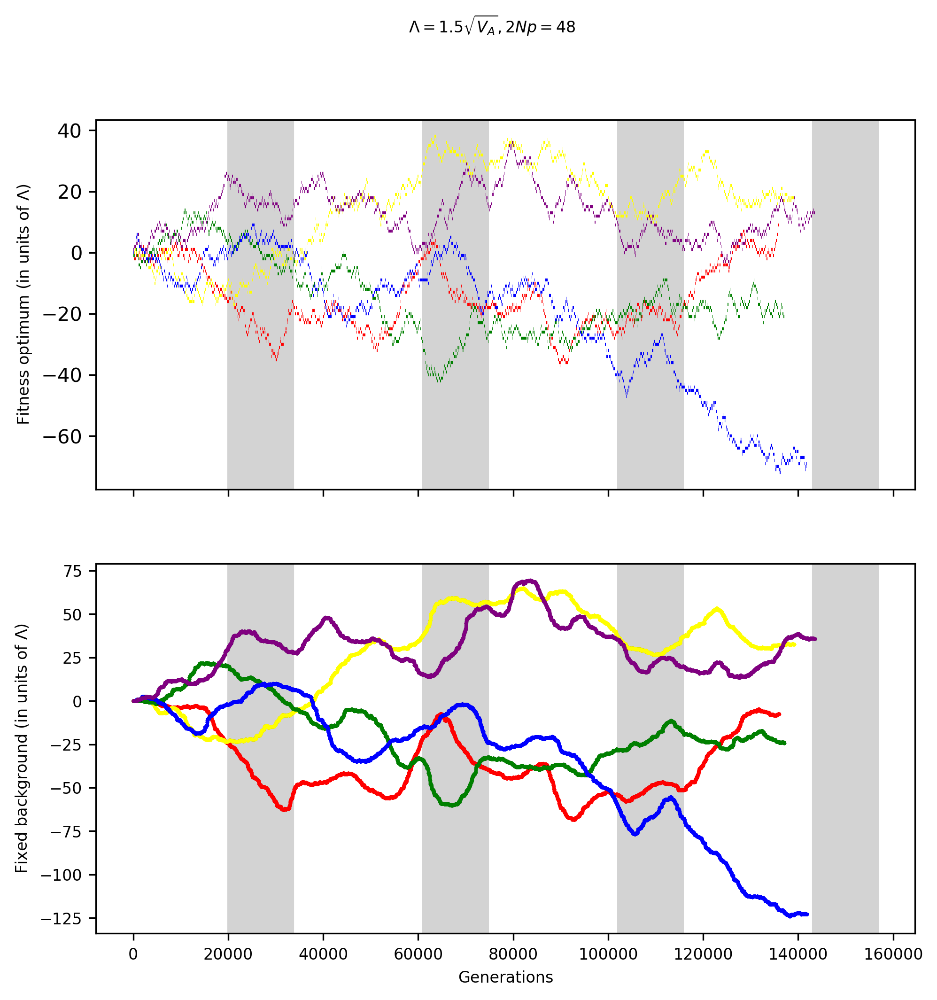

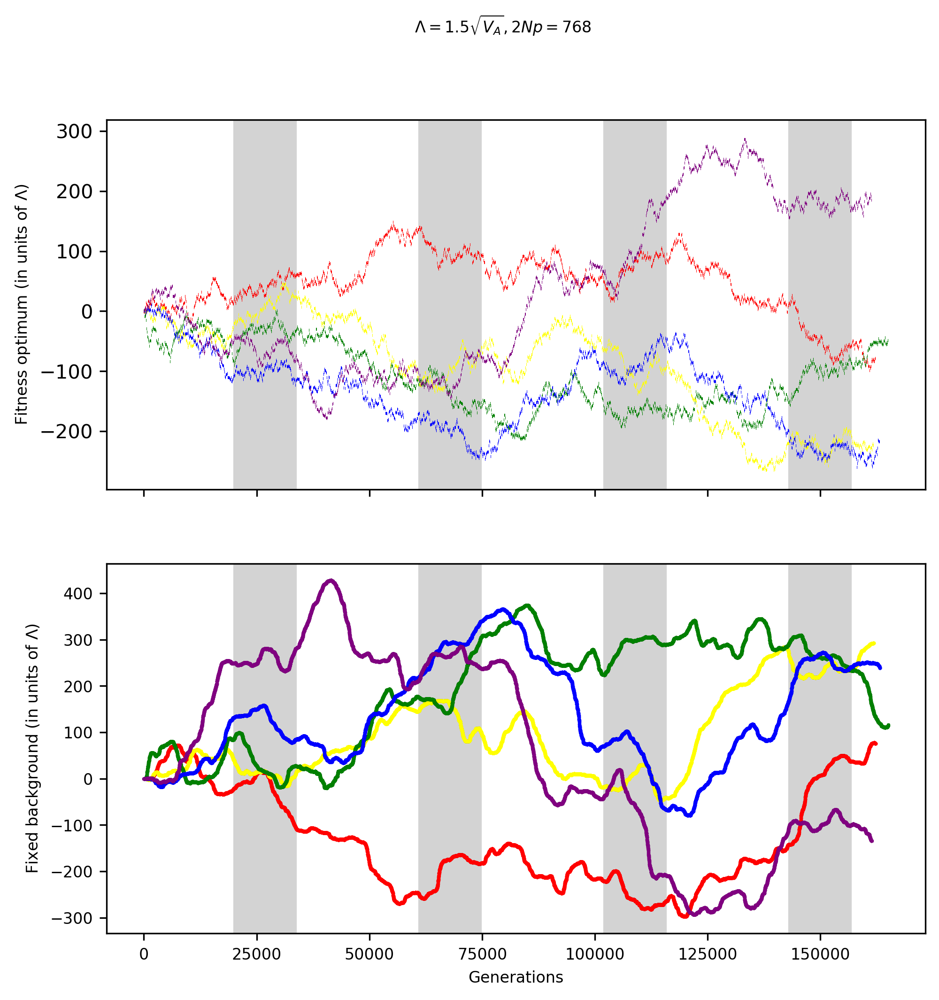

In [12]:
# the fitness optimum and the fixed background over time, in the non-Lande case
# 5 replicates
fontsize = 8

N = 2000
U = 0.025

for E2Ns, index_shift_s0, shift_s0, index_rate_of_shift, rate_of_shift in [(E2Ns, index_shift_s0, shift_s0, index_rate_of_shift, rate_of_shift) for E2Ns in [16, ] for index_shift_s0, shift_s0, index_rate_of_shift, rate_of_shift in [[3, 1.5, 6, 0.012], [3, 1.5, 10, 0.192]]]:
    fig = plt.figure(figsize=(7.5, 7.5), dpi=300)
    axs = fig.subplots(2, 1, sharex=True)
    for ax in axs:
        ax.axvspan(10 * N + 0 * int(0.1 * (least_number_of_generations - 10 * N)), 10 * N + 1 * int(0.1 * (least_number_of_generations - 10 * N)), color='lightgray')
        ax.axvspan(10 * N + 3 * int(0.1 * (least_number_of_generations - 10 * N)), 10 * N + 4 * int(0.1 * (least_number_of_generations - 10 * N)), color='lightgray')
        ax.axvspan(10 * N + 6 * int(0.1 * (least_number_of_generations - 10 * N)), 10 * N + 7 * int(0.1 * (least_number_of_generations - 10 * N)), color='lightgray')
        ax.axvspan(10 * N + 9 * int(0.1 * (least_number_of_generations - 10 * N)), 10 * N + 10 * int(0.1 * (least_number_of_generations - 10 * N)), color='lightgray')
    for i, color in [(9, 'r'), (19, 'yellow'), (29, 'g'), (39, 'b'), (49, 'purple')]:
        with open('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_updated_empirical_average_V_A_%d/fixations_and_extinctions' % (round(E2Ns), i), 'rb') as f:
            dist_ess_over_time, _, _, mean_fixed_ess_over_time = pickle.load(f)[2:]
        assert len(dist_ess_over_time) == len(mean_fixed_ess_over_time)
        shift_times_directional = [tM * round((dist_ess_over_time[tM] - dist_ess_over_time[tM - 1]) / abs(dist_ess_over_time[tM] - dist_ess_over_time[tM - 1])) for tM in range(0, len(dist_ess_over_time)) if abs(dist_ess_over_time[tM] - dist_ess_over_time[tM - 1]) >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])]
        fitness_optimum = 0
        axs[0].hlines(y=fitness_optimum, xmin=0, xmax=abs(shift_times_directional[0]), colors=color)
        for shift_time_directional, next_shift_time_directional in pairwise(shift_times_directional):
            fitness_optimum += np.sign(shift_time_directional)
            axs[0].hlines(y=fitness_optimum, xmin=abs(shift_time_directional), xmax=abs(next_shift_time_directional), colors=color)
        fitness_optimum += np.sign(shift_times_directional[-1])
        axs[0].hlines(y=fitness_optimum, xmin=abs(shift_times_directional[-1]), xmax=len(dist_ess_over_time), colors=color)
        axs[0].set_ylabel(r'Fitness optimum (in units of $\Lambda$)', fontsize=fontsize)
        axs[1].scatter(range(len(mean_fixed_ess_over_time)), np.divide(mean_fixed_ess_over_time, shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])), marker='.', color=color, s=2)
        axs[1].set_ylabel(r'Fixed background (in units of $\Lambda$)', fontsize=fontsize)
    plt.xlabel('Generations', fontsize=fontsize)
    plt.xticks(fontsize=fontsize)
    plt.yticks(fontsize=fontsize)
    plt.suptitle(r'$\Lambda=%g\sqrt{V_A}, 2Np=%g$' % (shift_s0, 2 * N * rate_of_shift), fontsize=fontsize)
    plt.show()

In [ ]:
# McDonald-Kreitman test, in the Lande case
# without frequency cutoff
fontsize = 8

N = 2000
U = 0.025
E2Ns = 1
nE = 100
indices_ss = [21, 38, 62, 86, 98]

V2Ns = E2Ns ** 2
S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0.,
                                               scale=float(V2Ns) / float(E2Ns))
a_list_pos = [math.sqrt(S_dist.ppf((i + 1) / (nE + 1))) for i in range(nE)]
a_list_pos_between = [math.sqrt(a * a_next) for a, a_next in pairwise(a_list_pos)]

fig = plt.figure(figsize=(10, 6.5), dpi=300)
gs = fig.add_gridspec(2, 5, width_ratios=[25, 3, 25, 3, 25], height_ratios=[1, 1])
# just for spacing
plt.subplot(gs[0, 1]).axis('off')
plt.subplot(gs[1, 1]).axis('off')
plt.subplot(gs[0, 3]).axis('off')
plt.subplot(gs[1, 3]).axis('off')
# not used
plt.subplot(gs[1, 4]).axis('off')

shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3, 5]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 32
rate_of_shifts_partitioning = 57

# make the other panels
# the fixation probability
ax = plt.subplot(gs[0, 0])
ax.text(0, 1.01, 'A', transform=ax.transAxes, fontsize=12, fontweight='bold')

neutral, = ax.plot(np.geomspace(0.1, 10), [1 for _ in np.geomspace(0.1, 10)], 'k:')

no_shifts, = ax.plot(np.geomspace(0.1, 10), [pi(a=np.sqrt(ss), x=1.0 / (2 * N)) * 2.0 * N for ss in np.geomspace(0.1, 10)], 'k--')

ax.text(x=10, y=1.05, s='Neutral', horizontalalignment='right', color='k', fontsize=fontsize)

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel('Fixation probability (relative to neutral)', fontsize=fontsize)
ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 1.), loc='upper left', fontsize=fontsize)

# the heterozygosity
ax = plt.subplot(gs[0, 2])
ax.text(0, 1.01, 'B', transform=ax.transAxes, fontsize=12, fontweight='bold')

neutral, = ax.plot(np.geomspace(0.1, 10), [1 for _ in np.geomspace(0.1, 10)], 'k:')

no_shifts, = ax.plot(np.geomspace(0.1, 10), [heterozygosity_(a=np.sqrt(ss)) / heterozygosity_(a=0.1) for ss in np.geomspace(0.1, 10)], 'k--')

ax.text(x=10, y=1.005, s='Neutral', horizontalalignment='right', color='k', fontsize=fontsize)

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel('Heterozygosity (relative to neutral)', fontsize=fontsize)
ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 0.), loc='lower left', fontsize=fontsize)

# the McDonald-Kreitman test
ax = plt.subplot(gs[0, 4])
ax.text(0, 1.01, 'C', transform=ax.transAxes, fontsize=12, fontweight='bold')

neutral, = ax.plot(np.geomspace(0.1, 10), [0 for _ in np.geomspace(0.1, 10)], 'k:')

no_shifts, = ax.plot(np.geomspace(0.1, 10), [1 - heterozygosity_(a=np.sqrt(ss)) / heterozygosity_(a=0.1) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N) for ss in np.geomspace(0.1, 10)], 'k--')

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel(r'$\alpha := 1 - \frac{P_n}{P_s} / \frac{D_n}{D_s}$', fontsize=fontsize)
ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 0.), loc='lower left', fontsize=fontsize)

index_shift_s0, shift_s0 = 15, 1.5
for index_rate_of_shift, rate_of_shift, color in ((19, 0.003, 'g'), (37, 0.048, 'lightgreen')):
    # simulations
    parallel_AA = 49
    ## obtain the fixation probability of alleles with each a^2
    num_fixed = np.sum([read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/num_fixed_nE_%d' % (round(E2Ns), i, nE)) for i in range(1, 1 + parallel_AA)], axis=0)
    fixation_probability_mean = dict()
    fixation_probability_se = dict()
    for index_ss in indices_ss:
        fixation_probability_mean[index_ss] = num_fixed[index_ss + 1] / (10000000 / (nE + 1) * parallel_AA)
        fixation_probability_se[index_ss] = np.sqrt(fixation_probability_mean[index_ss] * (1 - fixation_probability_mean[index_ss]) / (10000000 / (nE + 1) * parallel_AA))
    ax = plt.subplot(gs[0, 0])
    for index_ss in indices_ss:
        ax.errorbar(a_list_pos_between[index_ss] ** 2, fixation_probability_mean[index_ss] * 2 * N, yerr=1.96 * fixation_probability_se[index_ss] * 2 * N, fmt='o', color=color)
    ## obtain the heterozygosity of alleles with each a^2 in each generation, which are separated by 10N generations
    heterozygosity_each_generation = dict()
    heterozygosity_mean = dict()
    heterozygosity_se = dict()
    for index_ss in indices_ss:
        heterozygosity_each_generation[index_ss] = [h for i in range(1, 1 + parallel_AA) for h in read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/heterozygosity_nE_%d' % (round(E2Ns), i, nE))[index_ss + 1]]
        heterozygosity_mean[index_ss] = np.mean(heterozygosity_each_generation[index_ss])
        heterozygosity_se[index_ss] = np.divide(np.std(heterozygosity_each_generation[index_ss]), np.sqrt(np.size(heterozygosity_each_generation[index_ss])))
    ax = plt.subplot(gs[0, 2])
    for index_ss in indices_ss:
        ax.errorbar(a_list_pos_between[index_ss] ** 2, heterozygosity_mean[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_(a=0.1), yerr=1.96 * heterozygosity_se[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_(a=0.1), fmt='o', color=color)
    ## plot the McDonald-Kreitman test
    ax = plt.subplot(gs[0, 4])
    for index_ss in indices_ss:
        ax.errorbar(a_list_pos_between[index_ss] ** 2, 1 - heterozygosity_mean[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_(a=0.1) / fixation_probability_mean[index_ss] / (2 * N), yerr=1.96 * heterozygosity_se[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_(a=0.1) / fixation_probability_mean[index_ss] / (2 * N), fmt='o', color=color)
    # analytics
    fixation_probability_relative_to_neutral = [pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for ss in np.geomspace(0.1, 10)]
    heterozygosity_relative_to_neutral = [heterozygosity_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / heterozygosity_(a=0.1) for ss in np.geomspace(0.1, 10)]
    ## the fixation probability
    ax = plt.subplot(gs[0, 0])
    ax.plot(np.geomspace(0.1, 10), fixation_probability_relative_to_neutral, color=color)
    ## the heterozygosity
    ax = plt.subplot(gs[0, 2])
    ax.plot(np.geomspace(0.1, 10), heterozygosity_relative_to_neutral, color=color)
    ## the McDonald-Kreitman test
    ax = plt.subplot(gs[0, 4])
    ax.plot(np.geomspace(0.1, 10), np.subtract(1, np.divide(heterozygosity_relative_to_neutral, fixation_probability_relative_to_neutral)), color=color)
    
# Graph II for heterozygosity (w.r.t. shift size; different effect sizes)

ax = plt.subplot(gs[1, 0])
ax.text(0, 1.01, 'D', transform=ax.transAxes, fontsize=12, fontweight='bold')

index_rate_of_shift, rate_of_shift = 28, 0.012

neutral, = ax.plot([0] + shift_s0_list, [0 for _ in [0] + shift_s0_list], 'k:')

simulations = [None, None, None]
no_shifts = [None, None, None]
analytics = [None, None, None]

for i, (index_ss, ss, color) in enumerate([[indices_ss[0], 0.25, 'b'], [indices_ss[2], 1, 'purple'], [indices_ss[4], 4.25, 'r']]):
    parallel_AA = 49
    num_fixed_wrt_shift_s0 = [np.sum([read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/num_fixed_nE_%d' % (round(E2Ns), j, nE))[index_ss] for j in range(1, 1 + parallel_AA)]) for shift_s0 in shift_s0_list]
    fixation_probability_mean_wrt_shift_s0 = np.divide(num_fixed_wrt_shift_s0, (10000000 / (nE + 1) * parallel_AA))
    fixation_probability_se_wrt_shift_s0 = np.sqrt(np.divide(np.multiply(fixation_probability_mean_wrt_shift_s0, np.subtract(1, fixation_probability_mean_wrt_shift_s0)), (10000000 / (nE + 1) * parallel_AA)))
    heterozygosity_mean_wrt_shift_s0 = list()
    heterozygosity_se_wrt_shift_s0 = list()
    for shift_s0 in shift_s0_list:
        heterozygosity_each_generation = [h for j in range(1, 1 + parallel_AA) for h in read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/heterozygosity_nE_%d' % (round(E2Ns), j, nE))[index_ss + 1]]
        heterozygosity_mean = np.mean(heterozygosity_each_generation)
        heterozygosity_se = np.divide(np.std(heterozygosity_each_generation), np.sqrt(np.size(heterozygosity_each_generation)))
        heterozygosity_mean_wrt_shift_s0 += [heterozygosity_mean]
        heterozygosity_se_wrt_shift_s0 += [heterozygosity_se]
    simulations[i] = ax.errorbar(shift_s0_list, np.subtract(1, np.divide(np.divide(heterozygosity_mean_wrt_shift_s0, 2 * N * U / (nE + 1) * heterozygosity_(a=0.1) * 2 * N), fixation_probability_mean_wrt_shift_s0)), yerr=1.96 * np.divide(np.divide(heterozygosity_se_wrt_shift_s0, 2 * N * U / (nE + 1) * heterozygosity_(a=0.1) * 2 * N), fixation_probability_mean_wrt_shift_s0), fmt='o', color=color)
    no_shifts[i], = ax.plot([0] + shift_s0_list, [1 - heterozygosity_(a=np.sqrt(ss)) / heterozygosity_(a=0.1) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N) for _ in [0] + shift_s0_list], color=color, linestyle='--')
    analytics[i], = ax.plot([0] + list(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)), [1 - heterozygosity_(a=np.sqrt(ss)) / heterozygosity_(a=0.1) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N)] + [1 - heterozygosity_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / heterozygosity_(a=0.1) / pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / (2 * N) for index_shift_s0, shift_s0 in enumerate(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning))], color=color)

# ax.text(x=shift_s0_list[0], y=1.005, s='Neutral', color='k', fontsize=fontsize)
ax.text(x=3.3, y=0.135, s='$a^2=%g$' % 0.25, color='b', rotation=30, rotation_mode='anchor', fontsize=fontsize)
ax.text(x=3.3, y=0.37, s='$a^2=%g$' % 1, color='purple', rotation=45, rotation_mode='anchor', fontsize=fontsize)
ax.text(x=3.3, y=0.67, s='$a^2=%g$' % 4, color='r', rotation=45, rotation_mode='anchor', fontsize=fontsize)

simulation_mean = ax.errorbar([], [], yerr=[], fmt='o', color='k', label='All-allele simulations')
no_shifts_mean, = ax.plot([], [], 'k--', label='No shifts')
analytic_mean, = ax.plot([], [], 'k-', label='Analytics')

ax.set_xscale('symlog', linthresh=shift_s0_list[0], linscale=0.15)
ax.set_xlabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
ax.set_ylabel(r'$\alpha := 1 - \frac{P_n}{P_s} / \frac{D_n}{D_s}$', fontsize=fontsize)
ax.set_xticks(ticks=[0] + shift_s0_list, labels=[0] + [shift_s0 if index_shift_s0 % 2 == 0 else None for index_shift_s0, shift_s0 in enumerate(shift_s0_list)], fontsize=fontsize)
# ax.set_title('$E[a^2]=%d, 2Np=%g$' % (round(E2Ns), 2 * N * rate_of_shift), fontsize=fontsize)
ax.legend(bbox_to_anchor=(0., 1.), loc='upper left', fontsize=fontsize)
ax.minorticks_off()

ax = plt.subplot(gs[1, 2])
ax.text(0, 1.01, 'E', transform=ax.transAxes, fontsize=12, fontweight='bold')

index_shift_s0, shift_s0 = 15, 1.5

neutral, = ax.plot([0] + list(2 * N * np.array(rate_of_shifts_list)), [0 for _ in [0] + rate_of_shifts_list], 'k:')

simulations = [None, None, None]
no_shifts = [None, None, None]
analytics = [None, None, None]

for i, (index_ss, ss, color) in enumerate([[indices_ss[0], 0.25, 'b'], [indices_ss[2], 1, 'purple'], [indices_ss[4], 4.25, 'r']]):
    parallel_AA = 49
    num_fixed_wrt_rate_of_shifts = [np.sum([read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/num_fixed_nE_%d' % (round(E2Ns), j, nE))[index_ss] for j in range(1, 1 + parallel_AA)]) for rate_of_shift in rate_of_shifts_list]
    fixation_probability_mean_wrt_rate_of_shifts = np.divide(num_fixed_wrt_rate_of_shifts, (10000000 / (nE + 1) * parallel_AA))
    fixation_probability_se_wrt_rate_of_shifts = np.sqrt(np.divide(np.multiply(fixation_probability_mean_wrt_rate_of_shifts, np.subtract(1, fixation_probability_mean_wrt_rate_of_shifts)), (10000000 / (nE + 1) * parallel_AA)))
    heterozygosity_mean_wrt_rate_of_shifts = list()
    heterozygosity_se_wrt_rate_of_shifts = list()
    for rate_of_shift in rate_of_shifts_list:
        heterozygosity_each_generation = [h for j in range(1, 1 + parallel_AA) for h in read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/heterozygosity_nE_%d' % (round(E2Ns), j, nE))[index_ss + 1]]
        heterozygosity_mean = np.mean(heterozygosity_each_generation)
        heterozygosity_se = np.divide(np.std(heterozygosity_each_generation), np.sqrt(np.size(heterozygosity_each_generation)))
        heterozygosity_mean_wrt_rate_of_shifts += [heterozygosity_mean]
        heterozygosity_se_wrt_rate_of_shifts += [heterozygosity_se]
    simulations[i] = ax.errorbar(2 * N * np.array(rate_of_shifts_list), np.subtract(1, np.divide(np.divide(heterozygosity_mean_wrt_rate_of_shifts, 2 * N * U / (nE + 1) * heterozygosity_(a=0.1) * 2 * N), fixation_probability_mean_wrt_rate_of_shifts)), yerr=1.96 * np.divide(np.divide(heterozygosity_se_wrt_rate_of_shifts, 2 * N * U / (nE + 1) * heterozygosity_(a=0.1) * 2 * N), fixation_probability_mean_wrt_rate_of_shifts), fmt='o', color=color)
    no_shifts[i], = ax.plot([0] + list(2 * N * np.array(rate_of_shifts_list)), [1 - heterozygosity_(a=np.sqrt(ss)) / heterozygosity_(a=0.1) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N) for _ in [0] + rate_of_shifts_list], color=color, linestyle='--')
    analytics[i], = ax.plot([0] + list(2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)), [1 - heterozygosity_(a=np.sqrt(ss)) / heterozygosity_(a=0.1) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N)] + [1 - heterozygosity_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / heterozygosity_(a=0.1) / pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / (2 * N) for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))], color=color)

ax.set_xscale('symlog', linthresh=2 * N * rate_of_shifts_list[0], linscale=0.6)
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_xticks(ticks=[0] + list(2 * N * np.array(rate_of_shifts_list)), labels=[0] + [2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
# ax.set_title('$E[a^2]=%d, \Lambda=%g\sqrt{V_A}$' % (round(E2Ns), shift_s0), fontsize=fontsize)
ax.minorticks_off()

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

In [ ]:
# McDonald-Kreitman test, in the Lande case
# with frequency cutoff 0.05
fontsize = 8

N = 2000
U = 0.025
E2Ns = 1
nE = 100
indices_ss = [21, 38, 62, 86, 98]

V2Ns = E2Ns ** 2
S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0.,
                                               scale=float(V2Ns) / float(E2Ns))
a_list_pos = [math.sqrt(S_dist.ppf((i + 1) / (nE + 1))) for i in range(nE)]
a_list_pos_between = [math.sqrt(a * a_next) for a, a_next in pairwise(a_list_pos)]

fig = plt.figure(figsize=(10, 6.5), dpi=300)
gs = fig.add_gridspec(2, 5, width_ratios=[25, 3, 25, 3, 25], height_ratios=[1, 1])
# just for spacing
plt.subplot(gs[0, 1]).axis('off')
plt.subplot(gs[1, 1]).axis('off')
plt.subplot(gs[0, 3]).axis('off')
plt.subplot(gs[1, 3]).axis('off')
# not used
plt.subplot(gs[1, 4]).axis('off')

shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3, 5]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 32
rate_of_shifts_partitioning = 57

maf_threshold = 0.05

# make the other panels
# the fixation probability
ax = plt.subplot(gs[0, 0])
ax.text(0, 1.01, 'A', transform=ax.transAxes, fontsize=12, fontweight='bold')

neutral, = ax.plot(np.geomspace(0.1, 10), [1 for _ in np.geomspace(0.1, 10)], 'k:')

no_shifts, = ax.plot(np.geomspace(0.1, 10), [pi(a=np.sqrt(ss), x=1.0 / (2 * N)) * 2.0 * N for ss in np.geomspace(0.1, 10)], 'k--')

ax.text(x=10, y=1.05, s='Neutral', horizontalalignment='right', color='k', fontsize=fontsize)

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel('Fixation probability (relative to neutral)', fontsize=fontsize)
ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 1.), loc='upper left', fontsize=fontsize)

# the heterozygosity
ax = plt.subplot(gs[0, 2])
ax.text(0, 1.01, 'B', transform=ax.transAxes, fontsize=12, fontweight='bold')

neutral, = ax.plot(np.geomspace(0.1, 10), [1 for _ in np.geomspace(0.1, 10)], 'k:')

no_shifts, = ax.plot(np.geomspace(0.1, 10), [heterozygosity_truncating_rare_alleles_(a=np.sqrt(ss), maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) for ss in np.geomspace(0.1, 10)], 'k--')

ax.text(x=10, y=1.005, s='Neutral', horizontalalignment='right', color='k', fontsize=fontsize)

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel('Heterozygosity (relative to neutral)', fontsize=fontsize)
ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 0.), loc='lower left', fontsize=fontsize)

# the McDonald-Kreitman test
ax = plt.subplot(gs[0, 4])
ax.text(0, 1.01, 'C', transform=ax.transAxes, fontsize=12, fontweight='bold')

neutral, = ax.plot(np.geomspace(0.1, 10), [0 for _ in np.geomspace(0.1, 10)], 'k:')

no_shifts, = ax.plot(np.geomspace(0.1, 10), [1 - heterozygosity_truncating_rare_alleles_(a=np.sqrt(ss), maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N) for ss in np.geomspace(0.1, 10)], 'k--')

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel(r'$\alpha := 1 - \frac{P_n}{P_s} / \frac{D_n}{D_s}$', fontsize=fontsize)
ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 0.), loc='lower left', fontsize=fontsize)

index_shift_s0, shift_s0 = 15, 1.5
for index_rate_of_shift, rate_of_shift, color in ((19, 0.003, 'g'), (37, 0.048, 'lightgreen')):
    # simulations
    parallel_AA = 49
    ## obtain the fixation probability of alleles with each a^2
    num_fixed = np.sum([read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/num_fixed_nE_%d' % (round(E2Ns), i, nE)) for i in range(1, 1 + parallel_AA)], axis=0)
    fixation_probability_mean = dict()
    fixation_probability_se = dict()
    for index_ss in indices_ss:
        fixation_probability_mean[index_ss] = num_fixed[index_ss + 1] / (10000000 / (nE + 1) * parallel_AA)
        fixation_probability_se[index_ss] = np.sqrt(fixation_probability_mean[index_ss] * (1 - fixation_probability_mean[index_ss]) / (10000000 / (nE + 1) * parallel_AA))
    ax = plt.subplot(gs[0, 0])
    for index_ss in indices_ss:
        ax.errorbar(a_list_pos_between[index_ss] ** 2, fixation_probability_mean[index_ss] * 2 * N, yerr=1.96 * fixation_probability_se[index_ss] * 2 * N, fmt='o', color=color)
    ## obtain the heterozygosity of alleles with each a^2 in each generation, which are separated by 10N generations
    heterozygosity_each_generation = dict()
    heterozygosity_mean = dict()
    heterozygosity_se = dict()
    for index_ss in indices_ss:
        heterozygosity_each_generation[index_ss] = [h for i in range(1, 1 + parallel_AA) for h in read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/heterozygosity_nE_%d_maf_threshold_' % (round(E2Ns), i, nE) + str(maf_threshold).replace('.', '_'))[index_ss + 1]]
        heterozygosity_mean[index_ss] = np.mean(heterozygosity_each_generation[index_ss])
        heterozygosity_se[index_ss] = np.divide(np.std(heterozygosity_each_generation[index_ss]), np.sqrt(np.size(heterozygosity_each_generation[index_ss])))
    ax = plt.subplot(gs[0, 2])
    for index_ss in indices_ss:
        ax.errorbar(a_list_pos_between[index_ss] ** 2, heterozygosity_mean[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold), yerr=1.96 * heterozygosity_se[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold), fmt='o', color=color)
    ## plot the McDonald-Kreitman test
    ax = plt.subplot(gs[0, 4])
    for index_ss in indices_ss:
        ax.errorbar(a_list_pos_between[index_ss] ** 2, 1 - heterozygosity_mean[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / fixation_probability_mean[index_ss] / (2 * N), yerr=1.96 * heterozygosity_se[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / fixation_probability_mean[index_ss] / (2 * N), fmt='o', color=color)
    # analytics
    fixation_probability_relative_to_neutral = [pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for ss in np.geomspace(0.1, 10)]
    heterozygosity_relative_to_neutral = [heterozygosity_shifts_truncating_rare_alleles_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift, maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) for ss in np.geomspace(0.1, 10)]
    ## the fixation probability
    ax = plt.subplot(gs[0, 0])
    ax.plot(np.geomspace(0.1, 10), fixation_probability_relative_to_neutral, color=color)
    ## the heterozygosity
    ax = plt.subplot(gs[0, 2])
    ax.plot(np.geomspace(0.1, 10), heterozygosity_relative_to_neutral, color=color)
    ## the McDonald-Kreitman test
    ax = plt.subplot(gs[0, 4])
    ax.plot(np.geomspace(0.1, 10), np.subtract(1, np.divide(heterozygosity_relative_to_neutral, fixation_probability_relative_to_neutral)), color=color)
    
# Graph II for heterozygosity (w.r.t. shift size; different effect sizes)

ax = plt.subplot(gs[1, 0])
ax.text(0, 1.01, 'D', transform=ax.transAxes, fontsize=12, fontweight='bold')

index_rate_of_shift, rate_of_shift = 28, 0.012

neutral, = ax.plot([0] + shift_s0_list, [0 for _ in [0] + shift_s0_list], 'k:')

simulations = [None, None, None]
no_shifts = [None, None, None]
analytics = [None, None, None]

for i, (index_ss, ss, color) in enumerate([[indices_ss[0], 0.25, 'b'], [indices_ss[2], 1, 'purple'], [indices_ss[4], 4.25, 'r']]):
    parallel_AA = 49
    num_fixed_wrt_shift_s0 = [np.sum([read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/num_fixed_nE_%d' % (round(E2Ns), j, nE))[index_ss] for j in range(1, 1 + parallel_AA)]) for shift_s0 in shift_s0_list]
    fixation_probability_mean_wrt_shift_s0 = np.divide(num_fixed_wrt_shift_s0, (10000000 / (nE + 1) * parallel_AA))
    fixation_probability_se_wrt_shift_s0 = np.sqrt(np.divide(np.multiply(fixation_probability_mean_wrt_shift_s0, np.subtract(1, fixation_probability_mean_wrt_shift_s0)), (10000000 / (nE + 1) * parallel_AA)))
    heterozygosity_mean_wrt_shift_s0 = list()
    heterozygosity_se_wrt_shift_s0 = list()
    for shift_s0 in shift_s0_list:
        heterozygosity_each_generation = [h for j in range(1, 1 + parallel_AA) for h in read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/heterozygosity_nE_%d_maf_threshold_' % (round(E2Ns), j, nE) + str(maf_threshold).replace('.', '_'))[index_ss + 1]]
        heterozygosity_mean = np.mean(heterozygosity_each_generation)
        heterozygosity_se = np.divide(np.std(heterozygosity_each_generation), np.sqrt(np.size(heterozygosity_each_generation)))
        heterozygosity_mean_wrt_shift_s0 += [heterozygosity_mean]
        heterozygosity_se_wrt_shift_s0 += [heterozygosity_se]
    simulations[i] = ax.errorbar(shift_s0_list, np.subtract(1, np.divide(np.divide(heterozygosity_mean_wrt_shift_s0, 2 * N * U / (nE + 1) * heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) * 2 * N), fixation_probability_mean_wrt_shift_s0)), yerr=1.96 * np.divide(np.divide(heterozygosity_se_wrt_shift_s0, 2 * N * U / (nE + 1) * heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) * 2 * N), fixation_probability_mean_wrt_shift_s0), fmt='o', color=color)
    no_shifts[i], = ax.plot([0] + shift_s0_list, [1 - heterozygosity_truncating_rare_alleles_(a=np.sqrt(ss), maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N) for _ in [0] + shift_s0_list], color=color, linestyle='--')
    analytics[i], = ax.plot([0] + list(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)), [1 - heterozygosity_truncating_rare_alleles_(a=np.sqrt(ss), maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N)] + [1 - heterozygosity_shifts_truncating_rare_alleles_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift, maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / (2 * N) for index_shift_s0, shift_s0 in enumerate(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning))], color=color)

# ax.text(x=shift_s0_list[0], y=1.005, s='Neutral', color='k', fontsize=fontsize)
ax.text(x=3.3, y=0.135, s='$a^2=%g$' % 0.25, color='b', rotation=30, rotation_mode='anchor', fontsize=fontsize)
ax.text(x=3.3, y=0.37, s='$a^2=%g$' % 1, color='purple', rotation=45, rotation_mode='anchor', fontsize=fontsize)
ax.text(x=3.3, y=0.67, s='$a^2=%g$' % 4, color='r', rotation=45, rotation_mode='anchor', fontsize=fontsize)

simulation_mean = ax.errorbar([], [], yerr=[], fmt='o', color='k', label='All-allele simulations')
no_shifts_mean, = ax.plot([], [], 'k--', label='No shifts')
analytic_mean, = ax.plot([], [], 'k-', label='Analytics')

ax.set_xscale('symlog', linthresh=shift_s0_list[0], linscale=0.15)
ax.set_xlabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
ax.set_ylabel(r'$\alpha := 1 - \frac{P_n}{P_s} / \frac{D_n}{D_s}$', fontsize=fontsize)
ax.set_xticks(ticks=[0] + shift_s0_list, labels=[0] + [shift_s0 if index_shift_s0 % 2 == 0 else None for index_shift_s0, shift_s0 in enumerate(shift_s0_list)], fontsize=fontsize)
# ax.set_title('$E[a^2]=%d, 2Np=%g$' % (round(E2Ns), 2 * N * rate_of_shift), fontsize=fontsize)
ax.legend(bbox_to_anchor=(0., 1.), loc='upper left', fontsize=fontsize)
ax.minorticks_off()

ax = plt.subplot(gs[1, 2])
ax.text(0, 1.01, 'E', transform=ax.transAxes, fontsize=12, fontweight='bold')

index_shift_s0, shift_s0 = 15, 1.5

neutral, = ax.plot([0] + list(2 * N * np.array(rate_of_shifts_list)), [0 for _ in [0] + rate_of_shifts_list], 'k:')

simulations = [None, None, None]
no_shifts = [None, None, None]
analytics = [None, None, None]

for i, (index_ss, ss, color) in enumerate([[indices_ss[0], 0.25, 'b'], [indices_ss[2], 1, 'purple'], [indices_ss[4], 4.25, 'r']]):
    parallel_AA = 49
    num_fixed_wrt_rate_of_shifts = [np.sum([read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/num_fixed_nE_%d' % (round(E2Ns), j, nE))[index_ss] for j in range(1, 1 + parallel_AA)]) for rate_of_shift in rate_of_shifts_list]
    fixation_probability_mean_wrt_rate_of_shifts = np.divide(num_fixed_wrt_rate_of_shifts, (10000000 / (nE + 1) * parallel_AA))
    fixation_probability_se_wrt_rate_of_shifts = np.sqrt(np.divide(np.multiply(fixation_probability_mean_wrt_rate_of_shifts, np.subtract(1, fixation_probability_mean_wrt_rate_of_shifts)), (10000000 / (nE + 1) * parallel_AA)))
    heterozygosity_mean_wrt_rate_of_shifts = list()
    heterozygosity_se_wrt_rate_of_shifts = list()
    for rate_of_shift in rate_of_shifts_list:
        heterozygosity_each_generation = [h for j in range(1, 1 + parallel_AA) for h in read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/heterozygosity_nE_%d_maf_threshold_' % (round(E2Ns), j, nE) + str(maf_threshold).replace('.', '_'))[index_ss + 1]]
        heterozygosity_mean = np.mean(heterozygosity_each_generation)
        heterozygosity_se = np.divide(np.std(heterozygosity_each_generation), np.sqrt(np.size(heterozygosity_each_generation)))
        heterozygosity_mean_wrt_rate_of_shifts += [heterozygosity_mean]
        heterozygosity_se_wrt_rate_of_shifts += [heterozygosity_se]
    simulations[i] = ax.errorbar(2 * N * np.array(rate_of_shifts_list), np.subtract(1, np.divide(np.divide(heterozygosity_mean_wrt_rate_of_shifts, 2 * N * U / (nE + 1) * heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) * 2 * N), fixation_probability_mean_wrt_rate_of_shifts)), yerr=1.96 * np.divide(np.divide(heterozygosity_se_wrt_rate_of_shifts, 2 * N * U / (nE + 1) * heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) * 2 * N), fixation_probability_mean_wrt_rate_of_shifts), fmt='o', color=color)
    no_shifts[i], = ax.plot([0] + list(2 * N * np.array(rate_of_shifts_list)), [1 - heterozygosity_truncating_rare_alleles_(a=np.sqrt(ss), maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N) for _ in [0] + rate_of_shifts_list], color=color, linestyle='--')
    analytics[i], = ax.plot([0] + list(2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)), [1 - heterozygosity_truncating_rare_alleles_(a=np.sqrt(ss), maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N)] + [1 - heterozygosity_shifts_truncating_rare_alleles_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift, maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / (2 * N) for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))], color=color)

ax.set_xscale('symlog', linthresh=2 * N * rate_of_shifts_list[0], linscale=0.6)
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_xticks(ticks=[0] + list(2 * N * np.array(rate_of_shifts_list)), labels=[0] + [2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
# ax.set_title('$E[a^2]=%d, \Lambda=%g\sqrt{V_A}$' % (round(E2Ns), shift_s0), fontsize=fontsize)
ax.minorticks_off()

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

In [ ]:
# McDonald-Kreitman test, in the Lande case
# with frequency cutoff 0.1
fontsize = 8

N = 2000
U = 0.025
E2Ns = 1
nE = 100
indices_ss = [21, 38, 62, 86, 98]

V2Ns = E2Ns ** 2
S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0.,
                                               scale=float(V2Ns) / float(E2Ns))
a_list_pos = [math.sqrt(S_dist.ppf((i + 1) / (nE + 1))) for i in range(nE)]
a_list_pos_between = [math.sqrt(a * a_next) for a, a_next in pairwise(a_list_pos)]

fig = plt.figure(figsize=(10, 6.5), dpi=300)
gs = fig.add_gridspec(2, 5, width_ratios=[25, 3, 25, 3, 25], height_ratios=[1, 1])
# just for spacing
plt.subplot(gs[0, 1]).axis('off')
plt.subplot(gs[1, 1]).axis('off')
plt.subplot(gs[0, 3]).axis('off')
plt.subplot(gs[1, 3]).axis('off')
# not used
plt.subplot(gs[1, 4]).axis('off')

shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3, 5]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 32
rate_of_shifts_partitioning = 57

maf_threshold = 0.1

# make the other panels
# the fixation probability
ax = plt.subplot(gs[0, 0])
ax.text(0, 1.01, 'A', transform=ax.transAxes, fontsize=12, fontweight='bold')

neutral, = ax.plot(np.geomspace(0.1, 10), [1 for _ in np.geomspace(0.1, 10)], 'k:')

no_shifts, = ax.plot(np.geomspace(0.1, 10), [pi(a=np.sqrt(ss), x=1.0 / (2 * N)) * 2.0 * N for ss in np.geomspace(0.1, 10)], 'k--')

ax.text(x=10, y=1.05, s='Neutral', horizontalalignment='right', color='k', fontsize=fontsize)

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel('Fixation probability (relative to neutral)', fontsize=fontsize)
ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 1.), loc='upper left', fontsize=fontsize)

# the heterozygosity
ax = plt.subplot(gs[0, 2])
ax.text(0, 1.01, 'B', transform=ax.transAxes, fontsize=12, fontweight='bold')

neutral, = ax.plot(np.geomspace(0.1, 10), [1 for _ in np.geomspace(0.1, 10)], 'k:')

no_shifts, = ax.plot(np.geomspace(0.1, 10), [heterozygosity_truncating_rare_alleles_(a=np.sqrt(ss), maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) for ss in np.geomspace(0.1, 10)], 'k--')

ax.text(x=10, y=1.005, s='Neutral', horizontalalignment='right', color='k', fontsize=fontsize)

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel('Heterozygosity (relative to neutral)', fontsize=fontsize)
ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 0.), loc='lower left', fontsize=fontsize)

# the McDonald-Kreitman test
ax = plt.subplot(gs[0, 4])
ax.text(0, 1.01, 'C', transform=ax.transAxes, fontsize=12, fontweight='bold')

neutral, = ax.plot(np.geomspace(0.1, 10), [0 for _ in np.geomspace(0.1, 10)], 'k:')

no_shifts, = ax.plot(np.geomspace(0.1, 10), [1 - heterozygosity_truncating_rare_alleles_(a=np.sqrt(ss), maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N) for ss in np.geomspace(0.1, 10)], 'k--')

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel(r'$\alpha := 1 - \frac{P_n}{P_s} / \frac{D_n}{D_s}$', fontsize=fontsize)
ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 0.), loc='lower left', fontsize=fontsize)

index_shift_s0, shift_s0 = 15, 1.5
for index_rate_of_shift, rate_of_shift, color in ((19, 0.003, 'g'), (37, 0.048, 'lightgreen')):
    # simulations
    parallel_AA = 49
    ## obtain the fixation probability of alleles with each a^2
    num_fixed = np.sum([read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/num_fixed_nE_%d' % (round(E2Ns), i, nE)) for i in range(1, 1 + parallel_AA)], axis=0)
    fixation_probability_mean = dict()
    fixation_probability_se = dict()
    for index_ss in indices_ss:
        fixation_probability_mean[index_ss] = num_fixed[index_ss + 1] / (10000000 / (nE + 1) * parallel_AA)
        fixation_probability_se[index_ss] = np.sqrt(fixation_probability_mean[index_ss] * (1 - fixation_probability_mean[index_ss]) / (10000000 / (nE + 1) * parallel_AA))
    ax = plt.subplot(gs[0, 0])
    for index_ss in indices_ss:
        ax.errorbar(a_list_pos_between[index_ss] ** 2, fixation_probability_mean[index_ss] * 2 * N, yerr=1.96 * fixation_probability_se[index_ss] * 2 * N, fmt='o', color=color)
    ## obtain the heterozygosity of alleles with each a^2 in each generation, which are separated by 10N generations
    heterozygosity_each_generation = dict()
    heterozygosity_mean = dict()
    heterozygosity_se = dict()
    for index_ss in indices_ss:
        heterozygosity_each_generation[index_ss] = [h for i in range(1, 1 + parallel_AA) for h in read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/heterozygosity_nE_%d_maf_threshold_' % (round(E2Ns), i, nE) + str(maf_threshold).replace('.', '_'))[index_ss + 1]]
        heterozygosity_mean[index_ss] = np.mean(heterozygosity_each_generation[index_ss])
        heterozygosity_se[index_ss] = np.divide(np.std(heterozygosity_each_generation[index_ss]), np.sqrt(np.size(heterozygosity_each_generation[index_ss])))
    ax = plt.subplot(gs[0, 2])
    for index_ss in indices_ss:
        ax.errorbar(a_list_pos_between[index_ss] ** 2, heterozygosity_mean[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold), yerr=1.96 * heterozygosity_se[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold), fmt='o', color=color)
    ## plot the McDonald-Kreitman test
    ax = plt.subplot(gs[0, 4])
    for index_ss in indices_ss:
        ax.errorbar(a_list_pos_between[index_ss] ** 2, 1 - heterozygosity_mean[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / fixation_probability_mean[index_ss] / (2 * N), yerr=1.96 * heterozygosity_se[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / fixation_probability_mean[index_ss] / (2 * N), fmt='o', color=color)
    # analytics
    fixation_probability_relative_to_neutral = [pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for ss in np.geomspace(0.1, 10)]
    heterozygosity_relative_to_neutral = [heterozygosity_shifts_truncating_rare_alleles_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift, maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) for ss in np.geomspace(0.1, 10)]
    ## the fixation probability
    ax = plt.subplot(gs[0, 0])
    ax.plot(np.geomspace(0.1, 10), fixation_probability_relative_to_neutral, color=color)
    ## the heterozygosity
    ax = plt.subplot(gs[0, 2])
    ax.plot(np.geomspace(0.1, 10), heterozygosity_relative_to_neutral, color=color)
    ## the McDonald-Kreitman test
    ax = plt.subplot(gs[0, 4])
    ax.plot(np.geomspace(0.1, 10), np.subtract(1, np.divide(heterozygosity_relative_to_neutral, fixation_probability_relative_to_neutral)), color=color)
    
# Graph II for heterozygosity (w.r.t. shift size; different effect sizes)

ax = plt.subplot(gs[1, 0])
ax.text(0, 1.01, 'D', transform=ax.transAxes, fontsize=12, fontweight='bold')

index_rate_of_shift, rate_of_shift = 28, 0.012

neutral, = ax.plot([0] + shift_s0_list, [0 for _ in [0] + shift_s0_list], 'k:')

simulations = [None, None, None]
no_shifts = [None, None, None]
analytics = [None, None, None]

for i, (index_ss, ss, color) in enumerate([[indices_ss[0], 0.25, 'b'], [indices_ss[2], 1, 'purple'], [indices_ss[4], 4.25, 'r']]):
    parallel_AA = 49
    num_fixed_wrt_shift_s0 = [np.sum([read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/num_fixed_nE_%d' % (round(E2Ns), j, nE))[index_ss] for j in range(1, 1 + parallel_AA)]) for shift_s0 in shift_s0_list]
    fixation_probability_mean_wrt_shift_s0 = np.divide(num_fixed_wrt_shift_s0, (10000000 / (nE + 1) * parallel_AA))
    fixation_probability_se_wrt_shift_s0 = np.sqrt(np.divide(np.multiply(fixation_probability_mean_wrt_shift_s0, np.subtract(1, fixation_probability_mean_wrt_shift_s0)), (10000000 / (nE + 1) * parallel_AA)))
    heterozygosity_mean_wrt_shift_s0 = list()
    heterozygosity_se_wrt_shift_s0 = list()
    for shift_s0 in shift_s0_list:
        heterozygosity_each_generation = [h for j in range(1, 1 + parallel_AA) for h in read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/heterozygosity_nE_%d_maf_threshold_' % (round(E2Ns), j, nE) + str(maf_threshold).replace('.', '_'))[index_ss + 1]]
        heterozygosity_mean = np.mean(heterozygosity_each_generation)
        heterozygosity_se = np.divide(np.std(heterozygosity_each_generation), np.sqrt(np.size(heterozygosity_each_generation)))
        heterozygosity_mean_wrt_shift_s0 += [heterozygosity_mean]
        heterozygosity_se_wrt_shift_s0 += [heterozygosity_se]
    simulations[i] = ax.errorbar(shift_s0_list, np.subtract(1, np.divide(np.divide(heterozygosity_mean_wrt_shift_s0, 2 * N * U / (nE + 1) * heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) * 2 * N), fixation_probability_mean_wrt_shift_s0)), yerr=1.96 * np.divide(np.divide(heterozygosity_se_wrt_shift_s0, 2 * N * U / (nE + 1) * heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) * 2 * N), fixation_probability_mean_wrt_shift_s0), fmt='o', color=color)
    no_shifts[i], = ax.plot([0] + shift_s0_list, [1 - heterozygosity_truncating_rare_alleles_(a=np.sqrt(ss), maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N) for _ in [0] + shift_s0_list], color=color, linestyle='--')
    analytics[i], = ax.plot([0] + list(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)), [1 - heterozygosity_truncating_rare_alleles_(a=np.sqrt(ss), maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N)] + [1 - heterozygosity_shifts_truncating_rare_alleles_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift, maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / (2 * N) for index_shift_s0, shift_s0 in enumerate(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning))], color=color)

# ax.text(x=shift_s0_list[0], y=1.005, s='Neutral', color='k', fontsize=fontsize)
ax.text(x=3.3, y=0.135, s='$a^2=%g$' % 0.25, color='b', rotation=30, rotation_mode='anchor', fontsize=fontsize)
ax.text(x=3.3, y=0.37, s='$a^2=%g$' % 1, color='purple', rotation=45, rotation_mode='anchor', fontsize=fontsize)
ax.text(x=3.3, y=0.67, s='$a^2=%g$' % 4, color='r', rotation=45, rotation_mode='anchor', fontsize=fontsize)

simulation_mean = ax.errorbar([], [], yerr=[], fmt='o', color='k', label='All-allele simulations')
no_shifts_mean, = ax.plot([], [], 'k--', label='No shifts')
analytic_mean, = ax.plot([], [], 'k-', label='Analytics')

ax.set_xscale('symlog', linthresh=shift_s0_list[0], linscale=0.15)
ax.set_xlabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
ax.set_ylabel(r'$\alpha := 1 - \frac{P_n}{P_s} / \frac{D_n}{D_s}$', fontsize=fontsize)
ax.set_xticks(ticks=[0] + shift_s0_list, labels=[0] + [shift_s0 if index_shift_s0 % 2 == 0 else None for index_shift_s0, shift_s0 in enumerate(shift_s0_list)], fontsize=fontsize)
# ax.set_title('$E[a^2]=%d, 2Np=%g$' % (round(E2Ns), 2 * N * rate_of_shift), fontsize=fontsize)
ax.legend(bbox_to_anchor=(0., 1.), loc='upper left', fontsize=fontsize)
ax.minorticks_off()

ax = plt.subplot(gs[1, 2])
ax.text(0, 1.01, 'E', transform=ax.transAxes, fontsize=12, fontweight='bold')

index_shift_s0, shift_s0 = 15, 1.5

neutral, = ax.plot([0] + list(2 * N * np.array(rate_of_shifts_list)), [0 for _ in [0] + rate_of_shifts_list], 'k:')

simulations = [None, None, None]
no_shifts = [None, None, None]
analytics = [None, None, None]

for i, (index_ss, ss, color) in enumerate([[indices_ss[0], 0.25, 'b'], [indices_ss[2], 1, 'purple'], [indices_ss[4], 4.25, 'r']]):
    parallel_AA = 49
    num_fixed_wrt_rate_of_shifts = [np.sum([read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/num_fixed_nE_%d' % (round(E2Ns), j, nE))[index_ss] for j in range(1, 1 + parallel_AA)]) for rate_of_shift in rate_of_shifts_list]
    fixation_probability_mean_wrt_rate_of_shifts = np.divide(num_fixed_wrt_rate_of_shifts, (10000000 / (nE + 1) * parallel_AA))
    fixation_probability_se_wrt_rate_of_shifts = np.sqrt(np.divide(np.multiply(fixation_probability_mean_wrt_rate_of_shifts, np.subtract(1, fixation_probability_mean_wrt_rate_of_shifts)), (10000000 / (nE + 1) * parallel_AA)))
    heterozygosity_mean_wrt_rate_of_shifts = list()
    heterozygosity_se_wrt_rate_of_shifts = list()
    for rate_of_shift in rate_of_shifts_list:
        heterozygosity_each_generation = [h for j in range(1, 1 + parallel_AA) for h in read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/heterozygosity_nE_%d_maf_threshold_' % (round(E2Ns), j, nE) + str(maf_threshold).replace('.', '_'))[index_ss + 1]]
        heterozygosity_mean = np.mean(heterozygosity_each_generation)
        heterozygosity_se = np.divide(np.std(heterozygosity_each_generation), np.sqrt(np.size(heterozygosity_each_generation)))
        heterozygosity_mean_wrt_rate_of_shifts += [heterozygosity_mean]
        heterozygosity_se_wrt_rate_of_shifts += [heterozygosity_se]
    simulations[i] = ax.errorbar(2 * N * np.array(rate_of_shifts_list), np.subtract(1, np.divide(np.divide(heterozygosity_mean_wrt_rate_of_shifts, 2 * N * U / (nE + 1) * heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) * 2 * N), fixation_probability_mean_wrt_rate_of_shifts)), yerr=1.96 * np.divide(np.divide(heterozygosity_se_wrt_rate_of_shifts, 2 * N * U / (nE + 1) * heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) * 2 * N), fixation_probability_mean_wrt_rate_of_shifts), fmt='o', color=color)
    no_shifts[i], = ax.plot([0] + list(2 * N * np.array(rate_of_shifts_list)), [1 - heterozygosity_truncating_rare_alleles_(a=np.sqrt(ss), maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N) for _ in [0] + rate_of_shifts_list], color=color, linestyle='--')
    analytics[i], = ax.plot([0] + list(2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)), [1 - heterozygosity_truncating_rare_alleles_(a=np.sqrt(ss), maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N)] + [1 - heterozygosity_shifts_truncating_rare_alleles_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift, maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / (2 * N) for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))], color=color)

ax.set_xscale('symlog', linthresh=2 * N * rate_of_shifts_list[0], linscale=0.6)
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_xticks(ticks=[0] + list(2 * N * np.array(rate_of_shifts_list)), labels=[0] + [2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
# ax.set_title('$E[a^2]=%d, \Lambda=%g\sqrt{V_A}$' % (round(E2Ns), shift_s0), fontsize=fontsize)
ax.minorticks_off()

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

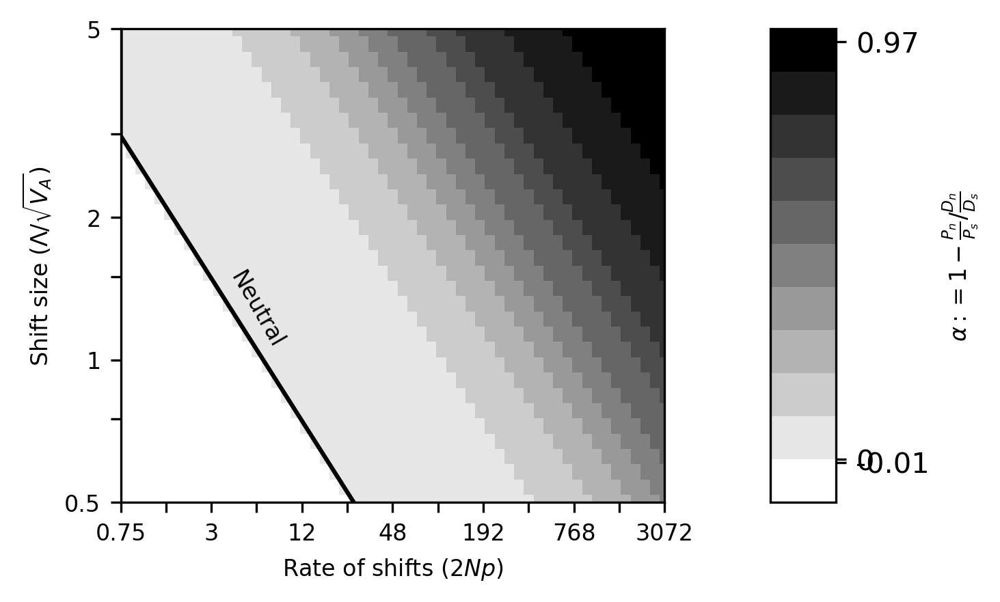

In [15]:
# the effect of recurrent shifts on the proportion of fixations due to adaptation, in the Lande case
# without frequency cutoff
fontsize = 8

N = 2000
U = 0.025
E2Ns = 1

shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3, 5]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 32
rate_of_shifts_partitioning = 57

Z = np.empty((shift_s0_partitioning, rate_of_shifts_partitioning))
for index_shift_s0, shift_s0 in enumerate(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)):
    for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)):
        with open('/insomnia001/depts/pas_lab/users/jc5473/analytic_heterozygosity_N_%d_U_' % N + str(U).replace('.', '_') + '_index_shift_s0_%d_index_rate_of_shift_%d_E2Ns_%d' % (index_shift_s0, index_rate_of_shift, round(E2Ns)), 'rb') as f:
            analytic_heterozygosity = pickle.load(f)
            Z[index_shift_s0, index_rate_of_shift] = 1 - analytic_heterozygosity / heterozygosity_(a=0.1) / pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(E2Ns), x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / (2 * N)
z_min, z_max = Z.min(), Z.max()

fig = plt.figure(figsize=(4.5, 3), dpi=300)
gs = fig.add_gridspec(1, 3, width_ratios=[25, 1, 3])
# twoslopenorm = colors.TwoSlopeNorm(vcenter=0, vmin=z_min, vmax=z_max)
# sm = plt.cm.ScalarMappable(cmap='RdGy', norm=twoslopenorm)
cmap = colors.ListedColormap(['1', '0.9', '0.8', '0.7', '0.6', '0.5', '0.4', '0.3', '0.2', '0.1', '0'])
bounds = np.arange(-0.1, 1.05, 0.1)
norm = colors.BoundaryNorm(bounds, cmap.N)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = plt.colorbar(sm, cax=plt.subplot(gs[0, 2]), orientation='vertical')
# cbar.ax.axhline(y=0, color='k', linestyle='-')
cbar.set_label(r'$\alpha := 1 - \frac{P_n}{P_s} / \frac{D_n}{D_s}$', fontsize=fontsize)
cbar.ax.set_yticks([z_min, 0, z_max])
cbar.ax.set_yticklabels(['%.2f' % z_min, 0, '%.2f' % z_max])
cbar.ax.minorticks_off()

ax = plt.subplot(gs[0, 0])
x = 2 * N * np.geomspace(rate_of_shifts_list[0] / (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_list[-1] * (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_partitioning + 1)
y = np.geomspace(shift_s0_list[0] / (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_list[-1] * (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_partitioning + 1)
X, Y = np.meshgrid(x, y)
ax.pcolormesh(X, Y, Z, cmap=cmap, norm=norm)
ax.plot([2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)[np.searchsorted(Z[index_shift_s0, :], 0)] for index_shift_s0 in range(shift_s0_partitioning)], np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning), color='k', linestyle='-', label='Neutral')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(2 * N * rate_of_shifts_list[0], 2 * N * rate_of_shifts_list[-1])
ax.set_ylim(shift_s0_list[0], shift_s0_list[-1])
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_ylabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
assert len(rate_of_shifts_list) % 2 == 1
assert len(shift_s0_list) % 2 == 1
ax.set_xticks(ticks=list(2 * N * np.array(rate_of_shifts_list)), labels=[2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
ax.set_yticks(ticks=shift_s0_list, labels=[shift_s0 if index_shift_s0 % 2 == 0 else None for index_shift_s0, shift_s0 in enumerate(shift_s0_list)], fontsize=fontsize)
ax.minorticks_off()
ax.text(x=4, y=1.5, s='Neutral', color='k', rotation=-60, rotation_mode='anchor', fontsize=fontsize)

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

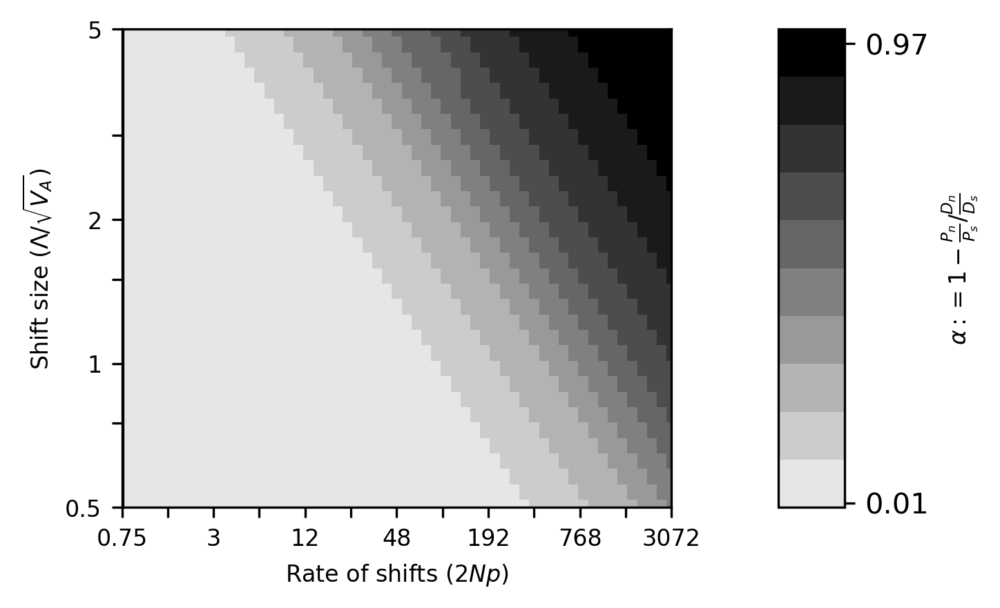

In [9]:
# the effect of recurrent shifts on the proportion of fixations due to adaptation, in the Lande case
# with frequency cutoff 0.05
fontsize = 8

N = 2000
U = 0.025
E2Ns = 1

maf_threshold = 0.05

shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3, 5]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 32
rate_of_shifts_partitioning = 57

Z = np.empty((shift_s0_partitioning, rate_of_shifts_partitioning))
for index_shift_s0, shift_s0 in enumerate(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)):
    for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)):
        with open('/insomnia001/depts/pas_lab/users/jc5473/analytic_heterozygosity_N_%d_U_' % N + str(U).replace('.', '_') + '_index_shift_s0_%d_index_rate_of_shift_%d_E2Ns_%d_maf_threshold_' % (index_shift_s0, index_rate_of_shift, round(E2Ns)) + str(maf_threshold).replace('.', '_'), 'rb') as f:
            analytic_heterozygosity = pickle.load(f)
            Z[index_shift_s0, index_rate_of_shift] = 1 - analytic_heterozygosity / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(E2Ns), x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / (2 * N)
z_min, z_max = Z.min(), Z.max()

fig = plt.figure(figsize=(4.5, 3), dpi=300)
gs = fig.add_gridspec(1, 3, width_ratios=[25, 1, 3])
# twoslopenorm = colors.TwoSlopeNorm(vcenter=0, vmin=z_min, vmax=z_max)
# sm = plt.cm.ScalarMappable(cmap='RdGy', norm=twoslopenorm)
cmap = colors.ListedColormap(['0.9', '0.8', '0.7', '0.6', '0.5', '0.4', '0.3', '0.2', '0.1', '0'])
bounds = np.arange(0., 1.05, 0.1)
norm = colors.BoundaryNorm(bounds, cmap.N)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = plt.colorbar(sm, cax=plt.subplot(gs[0, 2]), orientation='vertical')
# cbar.ax.axhline(y=0, color='k', linestyle='-')
cbar.set_label(r'$\alpha := 1 - \frac{P_n}{P_s} / \frac{D_n}{D_s}$', fontsize=fontsize)
cbar.ax.set_yticks([z_min, z_max])
cbar.ax.set_yticklabels(['%.2f' % z_min, '%.2f' % z_max])
cbar.ax.minorticks_off()

ax = plt.subplot(gs[0, 0])
x = 2 * N * np.geomspace(rate_of_shifts_list[0] / (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_list[-1] * (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_partitioning + 1)
y = np.geomspace(shift_s0_list[0] / (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_list[-1] * (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_partitioning + 1)
X, Y = np.meshgrid(x, y)
ax.pcolormesh(X, Y, Z, cmap=cmap, norm=norm)
ax.plot([2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)[np.searchsorted(Z[index_shift_s0, :], 0)] for index_shift_s0 in range(shift_s0_partitioning)], np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning), color='k', linestyle='-', label='Neutral')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(2 * N * rate_of_shifts_list[0], 2 * N * rate_of_shifts_list[-1])
ax.set_ylim(shift_s0_list[0], shift_s0_list[-1])
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_ylabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
assert len(rate_of_shifts_list) % 2 == 1
assert len(shift_s0_list) % 2 == 1
ax.set_xticks(ticks=list(2 * N * np.array(rate_of_shifts_list)), labels=[2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
ax.set_yticks(ticks=shift_s0_list, labels=[shift_s0 if index_shift_s0 % 2 == 0 else None for index_shift_s0, shift_s0 in enumerate(shift_s0_list)], fontsize=fontsize)
ax.minorticks_off()
# ax.text(x=4, y=1.5, s='Neutral', color='k', rotation=-60, rotation_mode='anchor', fontsize=fontsize)

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

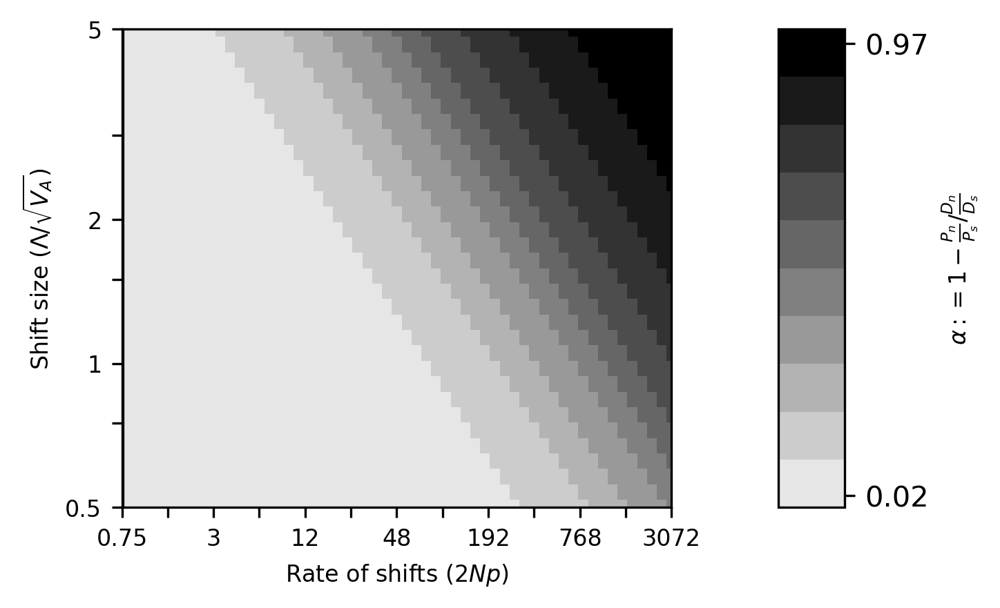

In [10]:
# the effect of recurrent shifts on the proportion of fixations due to adaptation, in the Lande case
# with frequency cutoff 0.1
fontsize = 8

N = 2000
U = 0.025
E2Ns = 1

maf_threshold = 0.1

shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3, 5]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 32
rate_of_shifts_partitioning = 57

Z = np.empty((shift_s0_partitioning, rate_of_shifts_partitioning))
for index_shift_s0, shift_s0 in enumerate(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)):
    for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)):
        with open('/insomnia001/depts/pas_lab/users/jc5473/analytic_heterozygosity_N_%d_U_' % N + str(U).replace('.', '_') + '_index_shift_s0_%d_index_rate_of_shift_%d_E2Ns_%d_maf_threshold_' % (index_shift_s0, index_rate_of_shift, round(E2Ns)) + str(maf_threshold).replace('.', '_'), 'rb') as f:
            analytic_heterozygosity = pickle.load(f)
            Z[index_shift_s0, index_rate_of_shift] = 1 - analytic_heterozygosity / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(E2Ns), x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / (2 * N)
z_min, z_max = Z.min(), Z.max()

fig = plt.figure(figsize=(4.5, 3), dpi=300)
gs = fig.add_gridspec(1, 3, width_ratios=[25, 1, 3])
# twoslopenorm = colors.TwoSlopeNorm(vcenter=0, vmin=z_min, vmax=z_max)
# sm = plt.cm.ScalarMappable(cmap='RdGy', norm=twoslopenorm)
cmap = colors.ListedColormap(['0.9', '0.8', '0.7', '0.6', '0.5', '0.4', '0.3', '0.2', '0.1', '0'])
bounds = np.arange(0., 1.05, 0.1)
norm = colors.BoundaryNorm(bounds, cmap.N)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = plt.colorbar(sm, cax=plt.subplot(gs[0, 2]), orientation='vertical')
# cbar.ax.axhline(y=0, color='k', linestyle='-')
cbar.set_label(r'$\alpha := 1 - \frac{P_n}{P_s} / \frac{D_n}{D_s}$', fontsize=fontsize)
cbar.ax.set_yticks([z_min, z_max])
cbar.ax.set_yticklabels(['%.2f' % z_min, '%.2f' % z_max])
cbar.ax.minorticks_off()

ax = plt.subplot(gs[0, 0])
x = 2 * N * np.geomspace(rate_of_shifts_list[0] / (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_list[-1] * (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_partitioning + 1)
y = np.geomspace(shift_s0_list[0] / (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_list[-1] * (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_partitioning + 1)
X, Y = np.meshgrid(x, y)
ax.pcolormesh(X, Y, Z, cmap=cmap, norm=norm)
ax.plot([2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)[np.searchsorted(Z[index_shift_s0, :], 0)] for index_shift_s0 in range(shift_s0_partitioning)], np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning), color='k', linestyle='-', label='Neutral')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(2 * N * rate_of_shifts_list[0], 2 * N * rate_of_shifts_list[-1])
ax.set_ylim(shift_s0_list[0], shift_s0_list[-1])
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_ylabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
assert len(rate_of_shifts_list) % 2 == 1
assert len(shift_s0_list) % 2 == 1
ax.set_xticks(ticks=list(2 * N * np.array(rate_of_shifts_list)), labels=[2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
ax.set_yticks(ticks=shift_s0_list, labels=[shift_s0 if index_shift_s0 % 2 == 0 else None for index_shift_s0, shift_s0 in enumerate(shift_s0_list)], fontsize=fontsize)
ax.minorticks_off()
# ax.text(x=4, y=1.5, s='Neutral', color='k', rotation=-60, rotation_mode='anchor', fontsize=fontsize)

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

/tmp/ipykernel_3245667/3027982274.py:32: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  return quad(lambda x: 2.0 * x * (1.0 - x) * tau(a, x, 1/(2*N)), 0.0, 1.0, points = [1/(2*N), 1.0 - 1/(2*N)])[0]


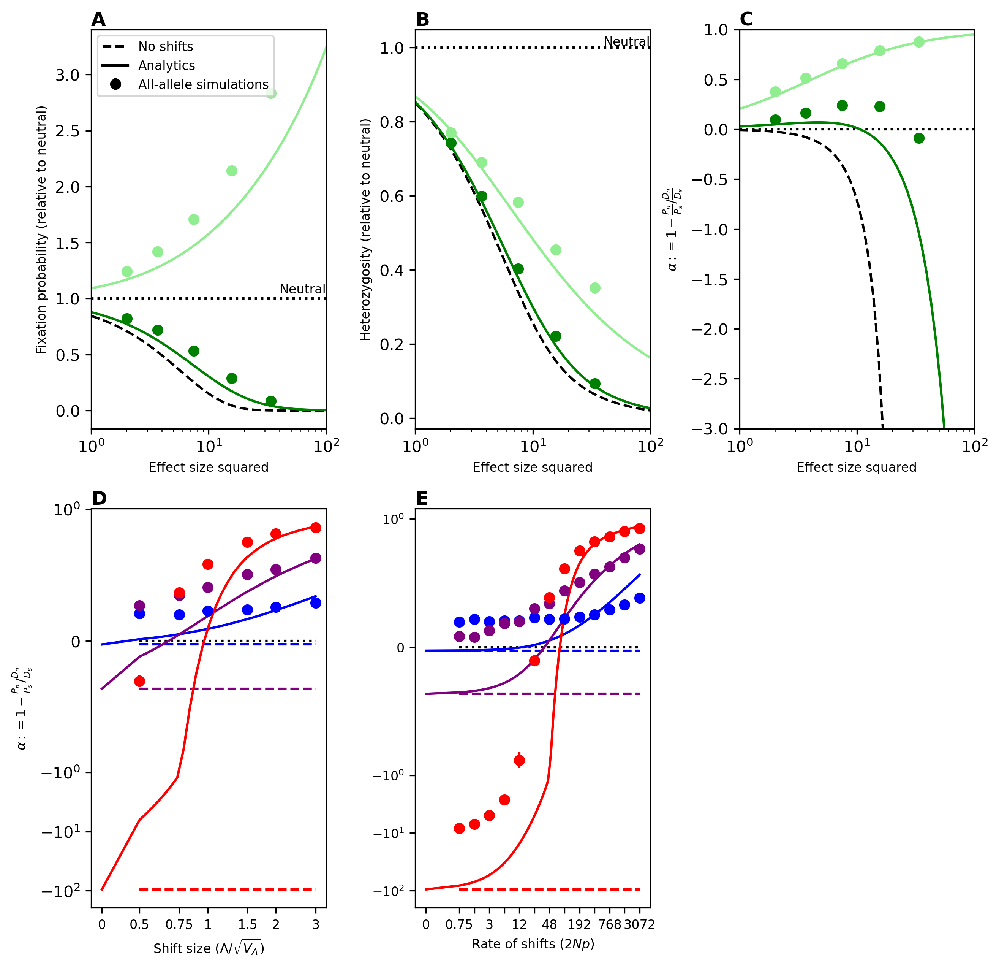

In [17]:
# McDonald-Kreitman test, in the non-Lande case
# without frequency cutoff
fontsize = 8

N = 2000
U = 0.025
E2Ns = 16
nE = 11
indices_ss = [0, 1, 3, 6, 9]

V2Ns = E2Ns ** 2
S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0.,
                                               scale=float(V2Ns) / float(E2Ns))
a_list_pos = [math.sqrt(S_dist.ppf((i + 1) / (nE + 1))) for i in range(nE)]
a_list_pos_between = [math.sqrt(a * a_next) for a, a_next in pairwise(a_list_pos)]

fig = plt.figure(figsize=(10, 10), dpi=300)
gs = fig.add_gridspec(2, 5, width_ratios=[25, 3, 25, 3, 25], height_ratios=[1, 1])
# just for spacing
plt.subplot(gs[0, 1]).axis('off')
plt.subplot(gs[1, 1]).axis('off')
plt.subplot(gs[0, 3]).axis('off')
plt.subplot(gs[1, 3]).axis('off')
# not used
plt.subplot(gs[1, 4]).axis('off')

shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 29
rate_of_shifts_partitioning = 66

# make the other panels
# the fixation probability
ax = plt.subplot(gs[0, 0])
ax.text(0, 1.01, 'A', transform=ax.transAxes, fontsize=12, fontweight='bold')

neutral, = ax.plot(np.geomspace(1, 100), [1 for _ in np.geomspace(1, 100)], 'k:')

no_shifts, = ax.plot(np.geomspace(1, 100), [pi(a=np.sqrt(ss), x=1.0 / (2 * N)) * 2.0 * N for ss in np.geomspace(1, 100)], 'k--')

ax.text(x=100, y=1.05, s='Neutral', horizontalalignment='right', color='k', fontsize=fontsize)

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlim(1, 100)
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel('Fixation probability (relative to neutral)', fontsize=fontsize)
ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 1.), loc='upper left', fontsize=fontsize)

# the heterozygosity
ax = plt.subplot(gs[0, 2])
ax.text(0, 1.01, 'B', transform=ax.transAxes, fontsize=12, fontweight='bold')

neutral, = ax.plot(np.geomspace(1, 100), [1 for _ in np.geomspace(1, 100)], 'k:')

no_shifts, = ax.plot(np.geomspace(1, 100), [heterozygosity_(a=np.sqrt(ss)) / heterozygosity_(a=0.1) for ss in np.geomspace(1, 100)], 'k--')

ax.text(x=100, y=1.005, s='Neutral', horizontalalignment='right', color='k', fontsize=fontsize)

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlim(1, 100)
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel('Heterozygosity (relative to neutral)', fontsize=fontsize)
# ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 0.), loc='lower left', fontsize=fontsize)

# the McDonald-Kreitman test
ax = plt.subplot(gs[0, 4])
ax.text(0, 1.01, 'C', transform=ax.transAxes, fontsize=12, fontweight='bold')

neutral, = ax.plot(np.geomspace(1, 100), [0 for _ in np.geomspace(1, 100)], 'k:')

no_shifts, = ax.plot(np.geomspace(1, 100), [1 - heterozygosity_(a=np.sqrt(ss)) / heterozygosity_(a=0.1) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N) for ss in np.geomspace(1, 100)], 'k--')

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlim(1, 100)
ax.set_ylim(-3, 1)
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel(r'$\alpha := 1 - \frac{P_n}{P_s} / \frac{D_n}{D_s}$', fontsize=fontsize)
# ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 0.), loc='lower left', fontsize=fontsize)

index_shift_s0, shift_s0 = 17, 1.5
for index_rate_of_shift, rate_of_shift, color in ((33, 0.012, 'g'), (54, 0.192, 'lightgreen')):
    # analytics
    fixation_probability_relative_to_neutral = [pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for ss in np.geomspace(1, 100)]
    heterozygosity_relative_to_neutral = [heterozygosity_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / heterozygosity_(a=0.1) for ss in np.geomspace(1, 100)]
    ## the fixation probability
    ax = plt.subplot(gs[0, 0])
    ax.plot(np.geomspace(1, 100), fixation_probability_relative_to_neutral, color=color)
    ## the heterozygosity
    ax = plt.subplot(gs[0, 2])
    ax.plot(np.geomspace(1, 100), heterozygosity_relative_to_neutral, color=color)
    ## the McDonald-Kreitman test
    ax = plt.subplot(gs[0, 4])
    ax.plot(np.geomspace(1, 100), np.subtract(1, np.divide(heterozygosity_relative_to_neutral, fixation_probability_relative_to_neutral)), color=color)
    
    # simulations
    parallel_AA = 49
    ## obtain the fixation probability of alleles with each a^2
    num_fixed = np.sum([read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/num_fixed_nE_%d' % (round(E2Ns), i, nE)) for i in range(1, 1 + parallel_AA)], axis=0)
    fixation_probability_mean = dict()
    fixation_probability_se = dict()
    for index_ss in indices_ss:
        fixation_probability_mean[index_ss] = num_fixed[index_ss + 1] / (10000000 / (nE + 1) * parallel_AA)
        fixation_probability_se[index_ss] = np.sqrt(fixation_probability_mean[index_ss] * (1 - fixation_probability_mean[index_ss]) / (10000000 / (nE + 1) * parallel_AA))
    ax = plt.subplot(gs[0, 0])
    for index_ss in indices_ss:
        ax.errorbar(a_list_pos_between[index_ss] ** 2, fixation_probability_mean[index_ss] * 2 * N, yerr=1.96 * fixation_probability_se[index_ss] * 2 * N, fmt='o', color=color)
    ## obtain the heterozygosity of alleles with each a^2 in each generation, which are separated by 10N generations
    heterozygosity_each_generation = dict()
    heterozygosity_mean = dict()
    heterozygosity_se = dict()
    for index_ss in indices_ss:
        heterozygosity_each_generation[index_ss] = [h for i in range(1, 1 + parallel_AA) for h in read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/heterozygosity_nE_%d' % (round(E2Ns), i, nE))[index_ss + 1]]
        heterozygosity_mean[index_ss] = np.mean(heterozygosity_each_generation[index_ss])
        heterozygosity_se[index_ss] = np.divide(np.std(heterozygosity_each_generation[index_ss]), np.sqrt(np.size(heterozygosity_each_generation[index_ss])))
    ax = plt.subplot(gs[0, 2])
    for index_ss in indices_ss:
        ax.errorbar(a_list_pos_between[index_ss] ** 2, heterozygosity_mean[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_(a=0.1), yerr=1.96 * heterozygosity_se[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_(a=0.1), fmt='o', color=color)
    ## plot the McDonald-Kreitman test
    ax = plt.subplot(gs[0, 4])
    for index_ss in indices_ss:
        ax.errorbar(a_list_pos_between[index_ss] ** 2, 1 - heterozygosity_mean[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_(a=0.1) / fixation_probability_mean[index_ss] / (2 * N), yerr=1.96 * heterozygosity_se[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_(a=0.1) / fixation_probability_mean[index_ss] / (2 * N), fmt='o', color=color)
    
# Graph II for McDonald-Kreitman test (w.r.t. shift size; different effect sizes)

ax = plt.subplot(gs[1, 0])
ax.text(0, 1.01, 'D', transform=ax.transAxes, fontsize=12, fontweight='bold')

index_rate_of_shift, rate_of_shift = 44, 0.048

neutral, = ax.plot(shift_s0_list, [0 for _ in shift_s0_list], 'k:')

simulations = [None, None, None]
no_shifts = [None, None, None]
analytics = [None, None, None]

for i, (index_ss, ss, color) in enumerate([[0, 2.15, 'b'], [3, 7.55, 'purple'], [9, 34.1, 'r']]):
    parallel_AA = 49
    num_fixed_wrt_shift_s0 = [np.sum([read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/num_fixed_nE_%d' % (round(E2Ns), j, nE))[index_ss] for j in range(1, 1 + parallel_AA)]) for shift_s0 in shift_s0_list]
    fixation_probability_mean_wrt_shift_s0 = np.divide(num_fixed_wrt_shift_s0, (10000000 / (nE + 1) * parallel_AA))
    fixation_probability_se_wrt_shift_s0 = np.sqrt(np.divide(np.multiply(fixation_probability_mean_wrt_shift_s0, np.subtract(1, fixation_probability_mean_wrt_shift_s0)), (10000000 / (nE + 1) * parallel_AA)))
    heterozygosity_mean_wrt_shift_s0 = list()
    heterozygosity_se_wrt_shift_s0 = list()
    for shift_s0 in shift_s0_list:
        heterozygosity_each_generation = [h for j in range(1, 1 + parallel_AA) for h in read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/heterozygosity_nE_%d' % (round(E2Ns), j, nE))[index_ss + 1]]
        heterozygosity_mean = np.mean(heterozygosity_each_generation)
        heterozygosity_se = np.divide(np.std(heterozygosity_each_generation), np.sqrt(np.size(heterozygosity_each_generation)))
        heterozygosity_mean_wrt_shift_s0 += [heterozygosity_mean]
        heterozygosity_se_wrt_shift_s0 += [heterozygosity_se]
    simulations[i] = ax.errorbar(shift_s0_list, np.subtract(1, np.divide(np.divide(heterozygosity_mean_wrt_shift_s0, 2 * N * U / (nE + 1) * heterozygosity_(a=0.1) * 2 * N), fixation_probability_mean_wrt_shift_s0)), yerr=1.96 * np.divide(np.divide(heterozygosity_se_wrt_shift_s0, 2 * N * U / (nE + 1) * heterozygosity_(a=0.1) * 2 * N), fixation_probability_mean_wrt_shift_s0), fmt='o', color=color)
    no_shifts[i], = ax.plot(shift_s0_list, [1 - heterozygosity_(a=np.sqrt(ss)) / heterozygosity_(a=0.1) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N) for _ in shift_s0_list], color=color, linestyle='--')
    analytics[i], = ax.plot([0] + list(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)), [1 - heterozygosity_(a=np.sqrt(ss)) / heterozygosity_(a=0.1) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N)] + [1 - heterozygosity_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / heterozygosity_(a=0.1) / pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / (2 * N) for index_shift_s0, shift_s0 in enumerate(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning))], color=color)

# ax.text(x=shift_s0_list[0], y=1.005, s='Neutral', color='k', fontsize=fontsize)
# ax.text(x=3.3, y=0.135, s='$a^2=%g$' % 0.25, color='b', rotation=30, rotation_mode='anchor', fontsize=fontsize)
# ax.text(x=3.3, y=0.37, s='$a^2=%g$' % 1, color='purple', rotation=45, rotation_mode='anchor', fontsize=fontsize)
# ax.text(x=3.3, y=0.67, s='$a^2=%g$' % 4, color='r', rotation=45, rotation_mode='anchor', fontsize=fontsize)

simulation_mean = ax.errorbar([], [], yerr=[], fmt='o', color='k', label='All-allele simulations')
no_shifts_mean, = ax.plot([], [], 'k--', label='No shifts')
analytic_mean, = ax.plot([], [], 'k-', label='Analytics')

ax.set_xscale('symlog', linthresh=shift_s0_list[0], linscale=0.15)
ax.set_yscale('symlog', linthresh=1, linscale=2)
ax.set_xlabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
ax.set_ylabel(r'$\alpha := 1 - \frac{P_n}{P_s} / \frac{D_n}{D_s}$', fontsize=fontsize)
ax.set_xticks(ticks=[0] + shift_s0_list, labels=[0] + shift_s0_list, fontsize=fontsize)
# ax.set_title('$E[a^2]=%d, 2Np=%g$' % (round(E2Ns), 2 * N * rate_of_shift), fontsize=fontsize)
# ax.legend(bbox_to_anchor=(0., 0.5), loc='upper left', fontsize=fontsize)
ax.minorticks_off()

ax = plt.subplot(gs[1, 2])
ax.text(0, 1.01, 'E', transform=ax.transAxes, fontsize=12, fontweight='bold')

index_shift_s0, shift_s0 = 17, 1.5

neutral, = ax.plot(2 * N * np.array(rate_of_shifts_list), [0 for _ in rate_of_shifts_list], 'k:')

simulations = [None, None, None]
no_shifts = [None, None, None]
analytics = [None, None, None]

for i, (index_ss, ss, color) in enumerate([[0, 2.15, 'b'], [3, 7.55, 'purple'], [9, 34.1, 'r']]):
    parallel_AA = 49
    num_fixed_wrt_rate_of_shifts = [np.sum([read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/num_fixed_nE_%d' % (round(E2Ns), j, nE))[index_ss] for j in range(1, 1 + parallel_AA)]) for rate_of_shift in rate_of_shifts_list]
    fixation_probability_mean_wrt_rate_of_shifts = np.divide(num_fixed_wrt_rate_of_shifts, (10000000 / (nE + 1) * parallel_AA))
    fixation_probability_se_wrt_rate_of_shifts = np.sqrt(np.divide(np.multiply(fixation_probability_mean_wrt_rate_of_shifts, np.subtract(1, fixation_probability_mean_wrt_rate_of_shifts)), (10000000 / (nE + 1) * parallel_AA)))
    heterozygosity_mean_wrt_rate_of_shifts = list()
    heterozygosity_se_wrt_rate_of_shifts = list()
    for rate_of_shift in rate_of_shifts_list:
        heterozygosity_each_generation = [h for j in range(1, 1 + parallel_AA) for h in read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/heterozygosity_nE_%d' % (round(E2Ns), j, nE))[index_ss + 1]]
        heterozygosity_mean = np.mean(heterozygosity_each_generation)
        heterozygosity_se = np.divide(np.std(heterozygosity_each_generation), np.sqrt(np.size(heterozygosity_each_generation)))
        heterozygosity_mean_wrt_rate_of_shifts += [heterozygosity_mean]
        heterozygosity_se_wrt_rate_of_shifts += [heterozygosity_se]
    simulations[i] = ax.errorbar(2 * N * np.array(rate_of_shifts_list), np.subtract(1, np.divide(np.divide(heterozygosity_mean_wrt_rate_of_shifts, 2 * N * U / (nE + 1) * heterozygosity_(a=0.1) * 2 * N), fixation_probability_mean_wrt_rate_of_shifts)), yerr=1.96 * np.divide(np.divide(heterozygosity_se_wrt_rate_of_shifts, 2 * N * U / (nE + 1) * heterozygosity_(a=0.1) * 2 * N), fixation_probability_mean_wrt_rate_of_shifts), fmt='o', color=color)
    no_shifts[i], = ax.plot(2 * N * np.array(rate_of_shifts_list), [1 - heterozygosity_(a=np.sqrt(ss)) / heterozygosity_(a=0.1) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N) for _ in rate_of_shifts_list], color=color, linestyle='--')
    analytics[i], = ax.plot([0] + list(2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)), [1 - heterozygosity_(a=np.sqrt(ss)) / heterozygosity_(a=0.1) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N)] + [1 - heterozygosity_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / heterozygosity_(a=0.1) / pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / (2 * N) for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))], color=color)

ax.set_xscale('symlog', linthresh=2 * N * rate_of_shifts_list[0], linscale=0.6)
ax.set_yscale('symlog', linthresh=1, linscale=2)
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_xticks(ticks=[0] + list(2 * N * np.array(rate_of_shifts_list)), labels=[0] + [2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
# ax.set_title('$E[a^2]=%d, \Lambda=%g\sqrt{V_A}$' % (round(E2Ns), shift_s0), fontsize=fontsize)
ax.minorticks_off()

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

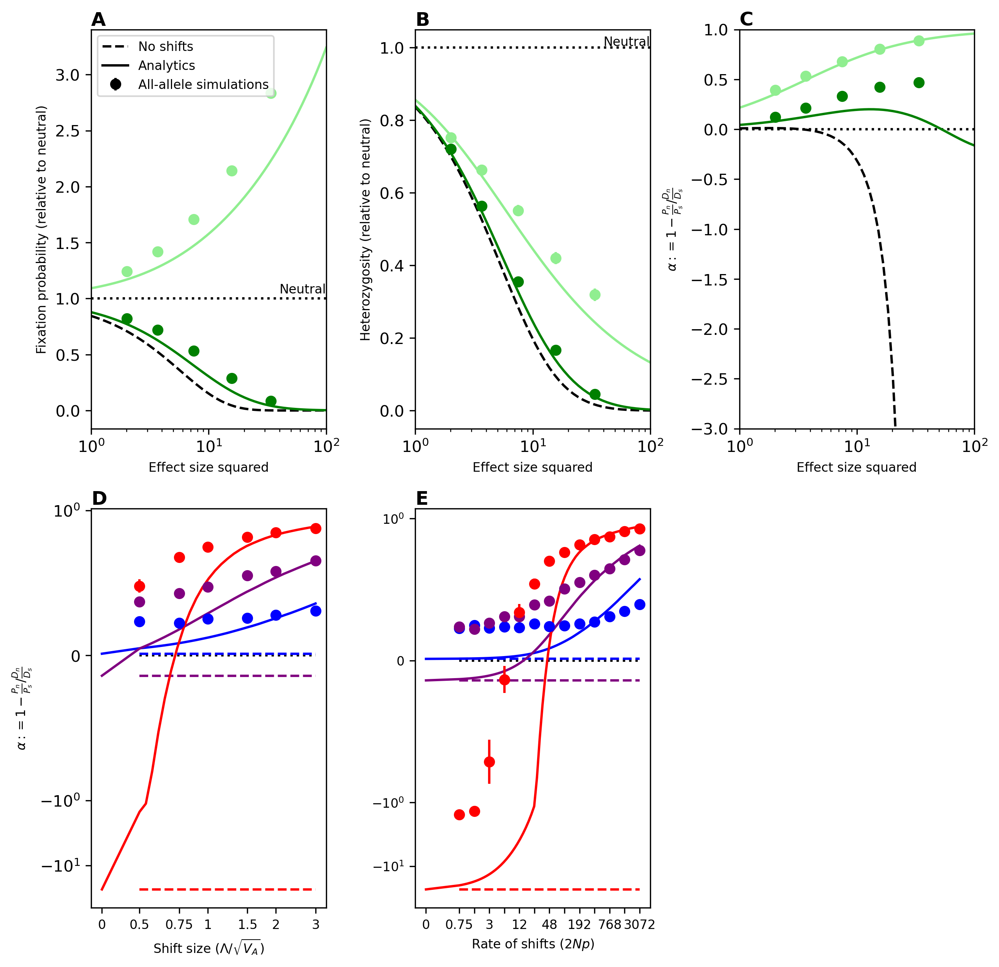

In [18]:
# McDonald-Kreitman test, in the non-Lande case
# with frequency cutoff 0.05
fontsize = 8

N = 2000
U = 0.025
E2Ns = 16
nE = 11
indices_ss = [0, 1, 3, 6, 9]

V2Ns = E2Ns ** 2
S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0.,
                                               scale=float(V2Ns) / float(E2Ns))
a_list_pos = [math.sqrt(S_dist.ppf((i + 1) / (nE + 1))) for i in range(nE)]
a_list_pos_between = [math.sqrt(a * a_next) for a, a_next in pairwise(a_list_pos)]

fig = plt.figure(figsize=(10, 10), dpi=300)
gs = fig.add_gridspec(2, 5, width_ratios=[25, 3, 25, 3, 25], height_ratios=[1, 1])
# just for spacing
plt.subplot(gs[0, 1]).axis('off')
plt.subplot(gs[1, 1]).axis('off')
plt.subplot(gs[0, 3]).axis('off')
plt.subplot(gs[1, 3]).axis('off')
# not used
plt.subplot(gs[1, 4]).axis('off')

shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 29
rate_of_shifts_partitioning = 66

maf_threshold = 0.05

# make the other panels
# the fixation probability
ax = plt.subplot(gs[0, 0])
ax.text(0, 1.01, 'A', transform=ax.transAxes, fontsize=12, fontweight='bold')

neutral, = ax.plot(np.geomspace(1, 100), [1 for _ in np.geomspace(1, 100)], 'k:')

no_shifts, = ax.plot(np.geomspace(1, 100), [pi(a=np.sqrt(ss), x=1.0 / (2 * N)) * 2.0 * N for ss in np.geomspace(1, 100)], 'k--')

ax.text(x=100, y=1.05, s='Neutral', horizontalalignment='right', color='k', fontsize=fontsize)

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlim(1, 100)
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel('Fixation probability (relative to neutral)', fontsize=fontsize)
ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 1.), loc='upper left', fontsize=fontsize)

# the heterozygosity
ax = plt.subplot(gs[0, 2])
ax.text(0, 1.01, 'B', transform=ax.transAxes, fontsize=12, fontweight='bold')

neutral, = ax.plot(np.geomspace(1, 100), [1 for _ in np.geomspace(1, 100)], 'k:')

no_shifts, = ax.plot(np.geomspace(1, 100), [heterozygosity_truncating_rare_alleles_(a=np.sqrt(ss), maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) for ss in np.geomspace(1, 100)], 'k--')

ax.text(x=100, y=1.005, s='Neutral', horizontalalignment='right', color='k', fontsize=fontsize)

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlim(1, 100)
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel('Heterozygosity (relative to neutral)', fontsize=fontsize)
# ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 0.), loc='lower left', fontsize=fontsize)

# the McDonald-Kreitman test
ax = plt.subplot(gs[0, 4])
ax.text(0, 1.01, 'C', transform=ax.transAxes, fontsize=12, fontweight='bold')

neutral, = ax.plot(np.geomspace(1, 100), [0 for _ in np.geomspace(1, 100)], 'k:')

no_shifts, = ax.plot(np.geomspace(1, 100), [1 - heterozygosity_truncating_rare_alleles_(a=np.sqrt(ss), maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N) for ss in np.geomspace(1, 100)], 'k--')

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlim(1, 100)
ax.set_ylim(-3, 1)
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel(r'$\alpha := 1 - \frac{P_n}{P_s} / \frac{D_n}{D_s}$', fontsize=fontsize)
# ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 0.), loc='lower left', fontsize=fontsize)

index_shift_s0, shift_s0 = 17, 1.5
for index_rate_of_shift, rate_of_shift, color in ((33, 0.012, 'g'), (54, 0.192, 'lightgreen')):
    # analytics
    fixation_probability_relative_to_neutral = [pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for ss in np.geomspace(1, 100)]
    heterozygosity_relative_to_neutral = [heterozygosity_shifts_truncating_rare_alleles_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift, maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) for ss in np.geomspace(1, 100)]
    ## the fixation probability
    ax = plt.subplot(gs[0, 0])
    ax.plot(np.geomspace(1, 100), fixation_probability_relative_to_neutral, color=color)
    ## the heterozygosity
    ax = plt.subplot(gs[0, 2])
    ax.plot(np.geomspace(1, 100), heterozygosity_relative_to_neutral, color=color)
    ## the McDonald-Kreitman test
    ax = plt.subplot(gs[0, 4])
    ax.plot(np.geomspace(1, 100), np.subtract(1, np.divide(heterozygosity_relative_to_neutral, fixation_probability_relative_to_neutral)), color=color)
    
    # simulations
    parallel_AA = 49
    ## obtain the fixation probability of alleles with each a^2
    num_fixed = np.sum([read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/num_fixed_nE_%d' % (round(E2Ns), i, nE)) for i in range(1, 1 + parallel_AA)], axis=0)
    fixation_probability_mean = dict()
    fixation_probability_se = dict()
    for index_ss in indices_ss:
        fixation_probability_mean[index_ss] = num_fixed[index_ss + 1] / (10000000 / (nE + 1) * parallel_AA)
        fixation_probability_se[index_ss] = np.sqrt(fixation_probability_mean[index_ss] * (1 - fixation_probability_mean[index_ss]) / (10000000 / (nE + 1) * parallel_AA))
    ax = plt.subplot(gs[0, 0])
    for index_ss in indices_ss:
        ax.errorbar(a_list_pos_between[index_ss] ** 2, fixation_probability_mean[index_ss] * 2 * N, yerr=1.96 * fixation_probability_se[index_ss] * 2 * N, fmt='o', color=color)
    ## obtain the heterozygosity of alleles with each a^2 in each generation, which are separated by 10N generations
    heterozygosity_each_generation = dict()
    heterozygosity_mean = dict()
    heterozygosity_se = dict()
    for index_ss in indices_ss:
        heterozygosity_each_generation[index_ss] = [h for i in range(1, 1 + parallel_AA) for h in read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/heterozygosity_nE_%d_maf_threshold_' % (round(E2Ns), i, nE) + str(maf_threshold).replace('.', '_'))[index_ss + 1]]
        heterozygosity_mean[index_ss] = np.mean(heterozygosity_each_generation[index_ss])
        heterozygosity_se[index_ss] = np.divide(np.std(heterozygosity_each_generation[index_ss]), np.sqrt(np.size(heterozygosity_each_generation[index_ss])))
    ax = plt.subplot(gs[0, 2])
    for index_ss in indices_ss:
        ax.errorbar(a_list_pos_between[index_ss] ** 2, heterozygosity_mean[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold), yerr=1.96 * heterozygosity_se[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold), fmt='o', color=color)
    ## plot the McDonald-Kreitman test
    ax = plt.subplot(gs[0, 4])
    for index_ss in indices_ss:
        ax.errorbar(a_list_pos_between[index_ss] ** 2, 1 - heterozygosity_mean[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / fixation_probability_mean[index_ss] / (2 * N), yerr=1.96 * heterozygosity_se[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / fixation_probability_mean[index_ss] / (2 * N), fmt='o', color=color)
    
# Graph II for McDonald-Kreitman test (w.r.t. shift size; different effect sizes)

ax = plt.subplot(gs[1, 0])
ax.text(0, 1.01, 'D', transform=ax.transAxes, fontsize=12, fontweight='bold')

index_rate_of_shift, rate_of_shift = 44, 0.048

neutral, = ax.plot(shift_s0_list, [0 for _ in shift_s0_list], 'k:')

simulations = [None, None, None]
no_shifts = [None, None, None]
analytics = [None, None, None]

for i, (index_ss, ss, color) in enumerate([[0, 2.15, 'b'], [3, 7.55, 'purple'], [9, 34.1, 'r']]):
    parallel_AA = 49
    num_fixed_wrt_shift_s0 = [np.sum([read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/num_fixed_nE_%d' % (round(E2Ns), j, nE))[index_ss] for j in range(1, 1 + parallel_AA)]) for shift_s0 in shift_s0_list]
    fixation_probability_mean_wrt_shift_s0 = np.divide(num_fixed_wrt_shift_s0, (10000000 / (nE + 1) * parallel_AA))
    fixation_probability_se_wrt_shift_s0 = np.sqrt(np.divide(np.multiply(fixation_probability_mean_wrt_shift_s0, np.subtract(1, fixation_probability_mean_wrt_shift_s0)), (10000000 / (nE + 1) * parallel_AA)))
    heterozygosity_mean_wrt_shift_s0 = list()
    heterozygosity_se_wrt_shift_s0 = list()
    for shift_s0 in shift_s0_list:
        heterozygosity_each_generation = [h for j in range(1, 1 + parallel_AA) for h in read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/heterozygosity_nE_%d_maf_threshold_' % (round(E2Ns), j, nE) + str(maf_threshold).replace('.', '_'))[index_ss + 1]]
        heterozygosity_mean = np.mean(heterozygosity_each_generation)
        heterozygosity_se = np.divide(np.std(heterozygosity_each_generation), np.sqrt(np.size(heterozygosity_each_generation)))
        heterozygosity_mean_wrt_shift_s0 += [heterozygosity_mean]
        heterozygosity_se_wrt_shift_s0 += [heterozygosity_se]
    simulations[i] = ax.errorbar(shift_s0_list, np.subtract(1, np.divide(np.divide(heterozygosity_mean_wrt_shift_s0, 2 * N * U / (nE + 1) * heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) * 2 * N), fixation_probability_mean_wrt_shift_s0)), yerr=1.96 * np.divide(np.divide(heterozygosity_se_wrt_shift_s0, 2 * N * U / (nE + 1) * heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) * 2 * N), fixation_probability_mean_wrt_shift_s0), fmt='o', color=color)
    no_shifts[i], = ax.plot(shift_s0_list, [1 - heterozygosity_truncating_rare_alleles_(a=np.sqrt(ss), maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N) for _ in shift_s0_list], color=color, linestyle='--')
    analytics[i], = ax.plot([0] + list(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)), [1 - heterozygosity_truncating_rare_alleles_(a=np.sqrt(ss), maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N)] + [1 - heterozygosity_shifts_truncating_rare_alleles_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift, maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / (2 * N) for index_shift_s0, shift_s0 in enumerate(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning))], color=color)

# ax.text(x=shift_s0_list[0], y=1.005, s='Neutral', color='k', fontsize=fontsize)
# ax.text(x=3.3, y=0.135, s='$a^2=%g$' % 0.25, color='b', rotation=30, rotation_mode='anchor', fontsize=fontsize)
# ax.text(x=3.3, y=0.37, s='$a^2=%g$' % 1, color='purple', rotation=45, rotation_mode='anchor', fontsize=fontsize)
# ax.text(x=3.3, y=0.67, s='$a^2=%g$' % 4, color='r', rotation=45, rotation_mode='anchor', fontsize=fontsize)

simulation_mean = ax.errorbar([], [], yerr=[], fmt='o', color='k', label='All-allele simulations')
no_shifts_mean, = ax.plot([], [], 'k--', label='No shifts')
analytic_mean, = ax.plot([], [], 'k-', label='Analytics')

ax.set_xscale('symlog', linthresh=shift_s0_list[0], linscale=0.15)
ax.set_yscale('symlog', linthresh=1, linscale=2)
ax.set_xlabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
ax.set_ylabel(r'$\alpha := 1 - \frac{P_n}{P_s} / \frac{D_n}{D_s}$', fontsize=fontsize)
ax.set_xticks(ticks=[0] + shift_s0_list, labels=[0] + shift_s0_list, fontsize=fontsize)
# ax.set_title('$E[a^2]=%d, 2Np=%g$' % (round(E2Ns), 2 * N * rate_of_shift), fontsize=fontsize)
# ax.legend(bbox_to_anchor=(0., 0.5), loc='upper left', fontsize=fontsize)
ax.minorticks_off()

ax = plt.subplot(gs[1, 2])
ax.text(0, 1.01, 'E', transform=ax.transAxes, fontsize=12, fontweight='bold')

index_shift_s0, shift_s0 = 17, 1.5

neutral, = ax.plot(2 * N * np.array(rate_of_shifts_list), [0 for _ in rate_of_shifts_list], 'k:')

simulations = [None, None, None]
no_shifts = [None, None, None]
analytics = [None, None, None]

for i, (index_ss, ss, color) in enumerate([[0, 2.15, 'b'], [3, 7.55, 'purple'], [9, 34.1, 'r']]):
    parallel_AA = 49
    num_fixed_wrt_rate_of_shifts = [np.sum([read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/num_fixed_nE_%d' % (round(E2Ns), j, nE))[index_ss] for j in range(1, 1 + parallel_AA)]) for rate_of_shift in rate_of_shifts_list]
    fixation_probability_mean_wrt_rate_of_shifts = np.divide(num_fixed_wrt_rate_of_shifts, (10000000 / (nE + 1) * parallel_AA))
    fixation_probability_se_wrt_rate_of_shifts = np.sqrt(np.divide(np.multiply(fixation_probability_mean_wrt_rate_of_shifts, np.subtract(1, fixation_probability_mean_wrt_rate_of_shifts)), (10000000 / (nE + 1) * parallel_AA)))
    heterozygosity_mean_wrt_rate_of_shifts = list()
    heterozygosity_se_wrt_rate_of_shifts = list()
    for rate_of_shift in rate_of_shifts_list:
        heterozygosity_each_generation = [h for j in range(1, 1 + parallel_AA) for h in read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/heterozygosity_nE_%d_maf_threshold_' % (round(E2Ns), j, nE) + str(maf_threshold).replace('.', '_'))[index_ss + 1]]
        heterozygosity_mean = np.mean(heterozygosity_each_generation)
        heterozygosity_se = np.divide(np.std(heterozygosity_each_generation), np.sqrt(np.size(heterozygosity_each_generation)))
        heterozygosity_mean_wrt_rate_of_shifts += [heterozygosity_mean]
        heterozygosity_se_wrt_rate_of_shifts += [heterozygosity_se]
    simulations[i] = ax.errorbar(2 * N * np.array(rate_of_shifts_list), np.subtract(1, np.divide(np.divide(heterozygosity_mean_wrt_rate_of_shifts, 2 * N * U / (nE + 1) * heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) * 2 * N), fixation_probability_mean_wrt_rate_of_shifts)), yerr=1.96 * np.divide(np.divide(heterozygosity_se_wrt_rate_of_shifts, 2 * N * U / (nE + 1) * heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) * 2 * N), fixation_probability_mean_wrt_rate_of_shifts), fmt='o', color=color)
    no_shifts[i], = ax.plot(2 * N * np.array(rate_of_shifts_list), [1 - heterozygosity_truncating_rare_alleles_(a=np.sqrt(ss), maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N) for _ in rate_of_shifts_list], color=color, linestyle='--')
    analytics[i], = ax.plot([0] + list(2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)), [1 - heterozygosity_truncating_rare_alleles_(a=np.sqrt(ss), maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N)] + [1 - heterozygosity_shifts_truncating_rare_alleles_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift, maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / (2 * N) for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))], color=color)

ax.set_xscale('symlog', linthresh=2 * N * rate_of_shifts_list[0], linscale=0.6)
ax.set_yscale('symlog', linthresh=1, linscale=2)
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_xticks(ticks=[0] + list(2 * N * np.array(rate_of_shifts_list)), labels=[0] + [2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
# ax.set_title('$E[a^2]=%d, \Lambda=%g\sqrt{V_A}$' % (round(E2Ns), shift_s0), fontsize=fontsize)
ax.minorticks_off()

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

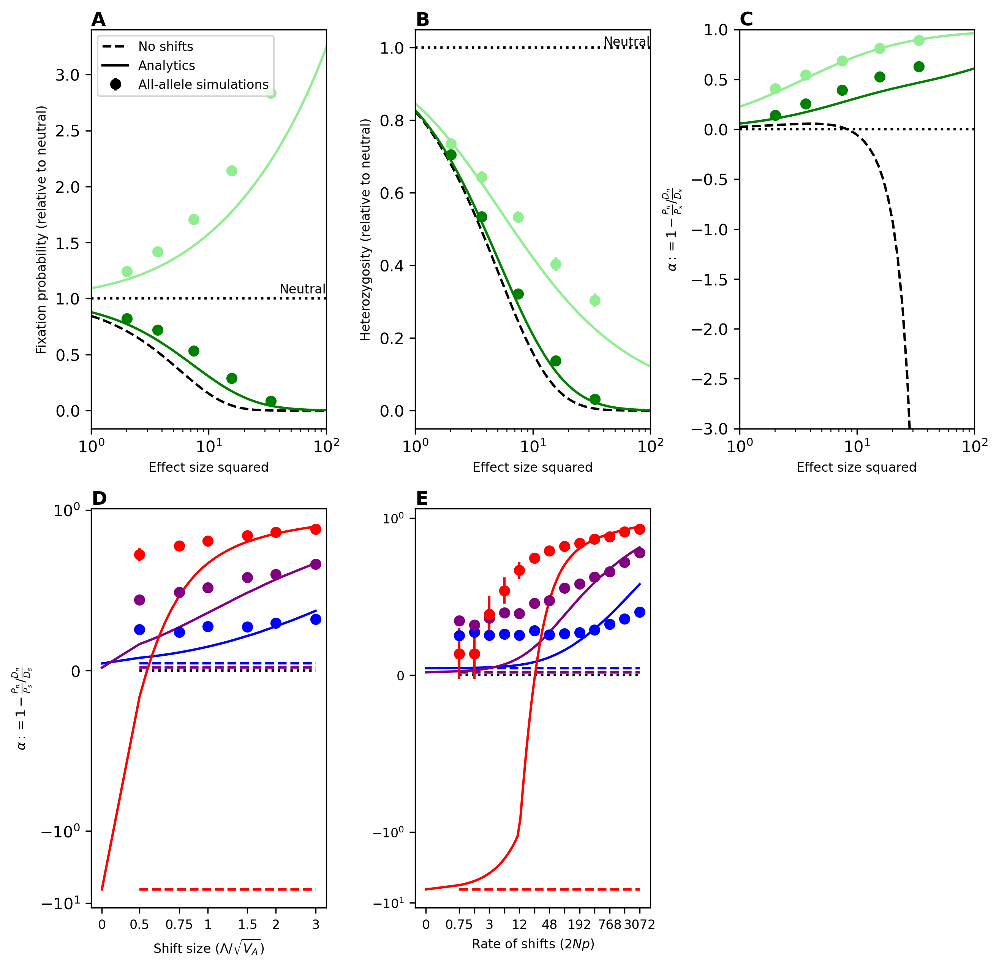

In [19]:
# McDonald-Kreitman test, in the non-Lande case
# with frequency cutoff 0.1
fontsize = 8

N = 2000
U = 0.025
E2Ns = 16
nE = 11
indices_ss = [0, 1, 3, 6, 9]

V2Ns = E2Ns ** 2
S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0.,
                                               scale=float(V2Ns) / float(E2Ns))
a_list_pos = [math.sqrt(S_dist.ppf((i + 1) / (nE + 1))) for i in range(nE)]
a_list_pos_between = [math.sqrt(a * a_next) for a, a_next in pairwise(a_list_pos)]

fig = plt.figure(figsize=(10, 10), dpi=300)
gs = fig.add_gridspec(2, 5, width_ratios=[25, 3, 25, 3, 25], height_ratios=[1, 1])
# just for spacing
plt.subplot(gs[0, 1]).axis('off')
plt.subplot(gs[1, 1]).axis('off')
plt.subplot(gs[0, 3]).axis('off')
plt.subplot(gs[1, 3]).axis('off')
# not used
plt.subplot(gs[1, 4]).axis('off')

shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 29
rate_of_shifts_partitioning = 66

maf_threshold = 0.1

# make the other panels
# the fixation probability
ax = plt.subplot(gs[0, 0])
ax.text(0, 1.01, 'A', transform=ax.transAxes, fontsize=12, fontweight='bold')

neutral, = ax.plot(np.geomspace(1, 100), [1 for _ in np.geomspace(1, 100)], 'k:')

no_shifts, = ax.plot(np.geomspace(1, 100), [pi(a=np.sqrt(ss), x=1.0 / (2 * N)) * 2.0 * N for ss in np.geomspace(1, 100)], 'k--')

ax.text(x=100, y=1.05, s='Neutral', horizontalalignment='right', color='k', fontsize=fontsize)

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlim(1, 100)
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel('Fixation probability (relative to neutral)', fontsize=fontsize)
ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 1.), loc='upper left', fontsize=fontsize)

# the heterozygosity
ax = plt.subplot(gs[0, 2])
ax.text(0, 1.01, 'B', transform=ax.transAxes, fontsize=12, fontweight='bold')

neutral, = ax.plot(np.geomspace(1, 100), [1 for _ in np.geomspace(1, 100)], 'k:')

no_shifts, = ax.plot(np.geomspace(1, 100), [heterozygosity_truncating_rare_alleles_(a=np.sqrt(ss), maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) for ss in np.geomspace(1, 100)], 'k--')

ax.text(x=100, y=1.005, s='Neutral', horizontalalignment='right', color='k', fontsize=fontsize)

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlim(1, 100)
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel('Heterozygosity (relative to neutral)', fontsize=fontsize)
# ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 0.), loc='lower left', fontsize=fontsize)

# the McDonald-Kreitman test
ax = plt.subplot(gs[0, 4])
ax.text(0, 1.01, 'C', transform=ax.transAxes, fontsize=12, fontweight='bold')

neutral, = ax.plot(np.geomspace(1, 100), [0 for _ in np.geomspace(1, 100)], 'k:')

no_shifts, = ax.plot(np.geomspace(1, 100), [1 - heterozygosity_truncating_rare_alleles_(a=np.sqrt(ss), maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N) for ss in np.geomspace(1, 100)], 'k--')

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')

ax.set_xscale('log')
ax.set_xlim(1, 100)
ax.set_ylim(-3, 1)
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel(r'$\alpha := 1 - \frac{P_n}{P_s} / \frac{D_n}{D_s}$', fontsize=fontsize)
# ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 0.), loc='lower left', fontsize=fontsize)

index_shift_s0, shift_s0 = 17, 1.5
for index_rate_of_shift, rate_of_shift, color in ((33, 0.012, 'g'), (54, 0.192, 'lightgreen')):
    # analytics
    fixation_probability_relative_to_neutral = [pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for ss in np.geomspace(1, 100)]
    heterozygosity_relative_to_neutral = [heterozygosity_shifts_truncating_rare_alleles_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift, maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) for ss in np.geomspace(1, 100)]
    ## the fixation probability
    ax = plt.subplot(gs[0, 0])
    ax.plot(np.geomspace(1, 100), fixation_probability_relative_to_neutral, color=color)
    ## the heterozygosity
    ax = plt.subplot(gs[0, 2])
    ax.plot(np.geomspace(1, 100), heterozygosity_relative_to_neutral, color=color)
    ## the McDonald-Kreitman test
    ax = plt.subplot(gs[0, 4])
    ax.plot(np.geomspace(1, 100), np.subtract(1, np.divide(heterozygosity_relative_to_neutral, fixation_probability_relative_to_neutral)), color=color)
    
    # simulations
    parallel_AA = 49
    ## obtain the fixation probability of alleles with each a^2
    num_fixed = np.sum([read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/num_fixed_nE_%d' % (round(E2Ns), i, nE)) for i in range(1, 1 + parallel_AA)], axis=0)
    fixation_probability_mean = dict()
    fixation_probability_se = dict()
    for index_ss in indices_ss:
        fixation_probability_mean[index_ss] = num_fixed[index_ss + 1] / (10000000 / (nE + 1) * parallel_AA)
        fixation_probability_se[index_ss] = np.sqrt(fixation_probability_mean[index_ss] * (1 - fixation_probability_mean[index_ss]) / (10000000 / (nE + 1) * parallel_AA))
    ax = plt.subplot(gs[0, 0])
    for index_ss in indices_ss:
        ax.errorbar(a_list_pos_between[index_ss] ** 2, fixation_probability_mean[index_ss] * 2 * N, yerr=1.96 * fixation_probability_se[index_ss] * 2 * N, fmt='o', color=color)
    ## obtain the heterozygosity of alleles with each a^2 in each generation, which are separated by 10N generations
    heterozygosity_each_generation = dict()
    heterozygosity_mean = dict()
    heterozygosity_se = dict()
    for index_ss in indices_ss:
        heterozygosity_each_generation[index_ss] = [h for i in range(1, 1 + parallel_AA) for h in read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/heterozygosity_nE_%d_maf_threshold_' % (round(E2Ns), i, nE) + str(maf_threshold).replace('.', '_'))[index_ss + 1]]
        heterozygosity_mean[index_ss] = np.mean(heterozygosity_each_generation[index_ss])
        heterozygosity_se[index_ss] = np.divide(np.std(heterozygosity_each_generation[index_ss]), np.sqrt(np.size(heterozygosity_each_generation[index_ss])))
    ax = plt.subplot(gs[0, 2])
    for index_ss in indices_ss:
        ax.errorbar(a_list_pos_between[index_ss] ** 2, heterozygosity_mean[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold), yerr=1.96 * heterozygosity_se[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold), fmt='o', color=color)
    ## plot the McDonald-Kreitman test
    ax = plt.subplot(gs[0, 4])
    for index_ss in indices_ss:
        ax.errorbar(a_list_pos_between[index_ss] ** 2, 1 - heterozygosity_mean[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / fixation_probability_mean[index_ss] / (2 * N), yerr=1.96 * heterozygosity_se[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / fixation_probability_mean[index_ss] / (2 * N), fmt='o', color=color)
    
# Graph II for McDonald-Kreitman test (w.r.t. shift size; different effect sizes)

ax = plt.subplot(gs[1, 0])
ax.text(0, 1.01, 'D', transform=ax.transAxes, fontsize=12, fontweight='bold')

index_rate_of_shift, rate_of_shift = 44, 0.048

neutral, = ax.plot(shift_s0_list, [0 for _ in shift_s0_list], 'k:')

simulations = [None, None, None]
no_shifts = [None, None, None]
analytics = [None, None, None]

for i, (index_ss, ss, color) in enumerate([[0, 2.15, 'b'], [3, 7.55, 'purple'], [9, 34.1, 'r']]):
    parallel_AA = 49
    num_fixed_wrt_shift_s0 = [np.sum([read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/num_fixed_nE_%d' % (round(E2Ns), j, nE))[index_ss] for j in range(1, 1 + parallel_AA)]) for shift_s0 in shift_s0_list]
    fixation_probability_mean_wrt_shift_s0 = np.divide(num_fixed_wrt_shift_s0, (10000000 / (nE + 1) * parallel_AA))
    fixation_probability_se_wrt_shift_s0 = np.sqrt(np.divide(np.multiply(fixation_probability_mean_wrt_shift_s0, np.subtract(1, fixation_probability_mean_wrt_shift_s0)), (10000000 / (nE + 1) * parallel_AA)))
    heterozygosity_mean_wrt_shift_s0 = list()
    heterozygosity_se_wrt_shift_s0 = list()
    for shift_s0 in shift_s0_list:
        heterozygosity_each_generation = [h for j in range(1, 1 + parallel_AA) for h in read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/heterozygosity_nE_%d_maf_threshold_' % (round(E2Ns), j, nE) + str(maf_threshold).replace('.', '_'))[index_ss + 1]]
        heterozygosity_mean = np.mean(heterozygosity_each_generation)
        heterozygosity_se = np.divide(np.std(heterozygosity_each_generation), np.sqrt(np.size(heterozygosity_each_generation)))
        heterozygosity_mean_wrt_shift_s0 += [heterozygosity_mean]
        heterozygosity_se_wrt_shift_s0 += [heterozygosity_se]
    simulations[i] = ax.errorbar(shift_s0_list, np.subtract(1, np.divide(np.divide(heterozygosity_mean_wrt_shift_s0, 2 * N * U / (nE + 1) * heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) * 2 * N), fixation_probability_mean_wrt_shift_s0)), yerr=1.96 * np.divide(np.divide(heterozygosity_se_wrt_shift_s0, 2 * N * U / (nE + 1) * heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) * 2 * N), fixation_probability_mean_wrt_shift_s0), fmt='o', color=color)
    no_shifts[i], = ax.plot(shift_s0_list, [1 - heterozygosity_truncating_rare_alleles_(a=np.sqrt(ss), maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N) for _ in shift_s0_list], color=color, linestyle='--')
    analytics[i], = ax.plot([0] + list(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)), [1 - heterozygosity_truncating_rare_alleles_(a=np.sqrt(ss), maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N)] + [1 - heterozygosity_shifts_truncating_rare_alleles_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift, maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / (2 * N) for index_shift_s0, shift_s0 in enumerate(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning))], color=color)

# ax.text(x=shift_s0_list[0], y=1.005, s='Neutral', color='k', fontsize=fontsize)
# ax.text(x=3.3, y=0.135, s='$a^2=%g$' % 0.25, color='b', rotation=30, rotation_mode='anchor', fontsize=fontsize)
# ax.text(x=3.3, y=0.37, s='$a^2=%g$' % 1, color='purple', rotation=45, rotation_mode='anchor', fontsize=fontsize)
# ax.text(x=3.3, y=0.67, s='$a^2=%g$' % 4, color='r', rotation=45, rotation_mode='anchor', fontsize=fontsize)

simulation_mean = ax.errorbar([], [], yerr=[], fmt='o', color='k', label='All-allele simulations')
no_shifts_mean, = ax.plot([], [], 'k--', label='No shifts')
analytic_mean, = ax.plot([], [], 'k-', label='Analytics')

ax.set_xscale('symlog', linthresh=shift_s0_list[0], linscale=0.15)
ax.set_yscale('symlog', linthresh=1, linscale=2)
ax.set_xlabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
ax.set_ylabel(r'$\alpha := 1 - \frac{P_n}{P_s} / \frac{D_n}{D_s}$', fontsize=fontsize)
ax.set_xticks(ticks=[0] + shift_s0_list, labels=[0] + shift_s0_list, fontsize=fontsize)
# ax.set_title('$E[a^2]=%d, 2Np=%g$' % (round(E2Ns), 2 * N * rate_of_shift), fontsize=fontsize)
# ax.legend(bbox_to_anchor=(0., 0.5), loc='upper left', fontsize=fontsize)
ax.minorticks_off()

ax = plt.subplot(gs[1, 2])
ax.text(0, 1.01, 'E', transform=ax.transAxes, fontsize=12, fontweight='bold')

index_shift_s0, shift_s0 = 17, 1.5

neutral, = ax.plot(2 * N * np.array(rate_of_shifts_list), [0 for _ in rate_of_shifts_list], 'k:')

simulations = [None, None, None]
no_shifts = [None, None, None]
analytics = [None, None, None]

for i, (index_ss, ss, color) in enumerate([[0, 2.15, 'b'], [3, 7.55, 'purple'], [9, 34.1, 'r']]):
    parallel_AA = 49
    num_fixed_wrt_rate_of_shifts = [np.sum([read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/num_fixed_nE_%d' % (round(E2Ns), j, nE))[index_ss] for j in range(1, 1 + parallel_AA)]) for rate_of_shift in rate_of_shifts_list]
    fixation_probability_mean_wrt_rate_of_shifts = np.divide(num_fixed_wrt_rate_of_shifts, (10000000 / (nE + 1) * parallel_AA))
    fixation_probability_se_wrt_rate_of_shifts = np.sqrt(np.divide(np.multiply(fixation_probability_mean_wrt_rate_of_shifts, np.subtract(1, fixation_probability_mean_wrt_rate_of_shifts)), (10000000 / (nE + 1) * parallel_AA)))
    heterozygosity_mean_wrt_rate_of_shifts = list()
    heterozygosity_se_wrt_rate_of_shifts = list()
    for rate_of_shift in rate_of_shifts_list:
        heterozygosity_each_generation = [h for j in range(1, 1 + parallel_AA) for h in read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/heterozygosity_nE_%d_maf_threshold_' % (round(E2Ns), j, nE) + str(maf_threshold).replace('.', '_'))[index_ss + 1]]
        heterozygosity_mean = np.mean(heterozygosity_each_generation)
        heterozygosity_se = np.divide(np.std(heterozygosity_each_generation), np.sqrt(np.size(heterozygosity_each_generation)))
        heterozygosity_mean_wrt_rate_of_shifts += [heterozygosity_mean]
        heterozygosity_se_wrt_rate_of_shifts += [heterozygosity_se]
    simulations[i] = ax.errorbar(2 * N * np.array(rate_of_shifts_list), np.subtract(1, np.divide(np.divide(heterozygosity_mean_wrt_rate_of_shifts, 2 * N * U / (nE + 1) * heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) * 2 * N), fixation_probability_mean_wrt_rate_of_shifts)), yerr=1.96 * np.divide(np.divide(heterozygosity_se_wrt_rate_of_shifts, 2 * N * U / (nE + 1) * heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) * 2 * N), fixation_probability_mean_wrt_rate_of_shifts), fmt='o', color=color)
    no_shifts[i], = ax.plot(2 * N * np.array(rate_of_shifts_list), [1 - heterozygosity_truncating_rare_alleles_(a=np.sqrt(ss), maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N) for _ in rate_of_shifts_list], color=color, linestyle='--')
    analytics[i], = ax.plot([0] + list(2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)), [1 - heterozygosity_truncating_rare_alleles_(a=np.sqrt(ss), maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N)] + [1 - heterozygosity_shifts_truncating_rare_alleles_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift, maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / (2 * N) for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning))], color=color)

ax.set_xscale('symlog', linthresh=2 * N * rate_of_shifts_list[0], linscale=0.6)
ax.set_yscale('symlog', linthresh=1, linscale=2)
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_xticks(ticks=[0] + list(2 * N * np.array(rate_of_shifts_list)), labels=[0] + [2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
# ax.set_title('$E[a^2]=%d, \Lambda=%g\sqrt{V_A}$' % (round(E2Ns), shift_s0), fontsize=fontsize)
ax.minorticks_off()

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

/tmp/ipykernel_1386325/3027982274.py:32: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  return quad(lambda x: 2.0 * x * (1.0 - x) * tau(a, x, 1/(2*N)), 0.0, 1.0, points = [1/(2*N), 1.0 - 1/(2*N)])[0]


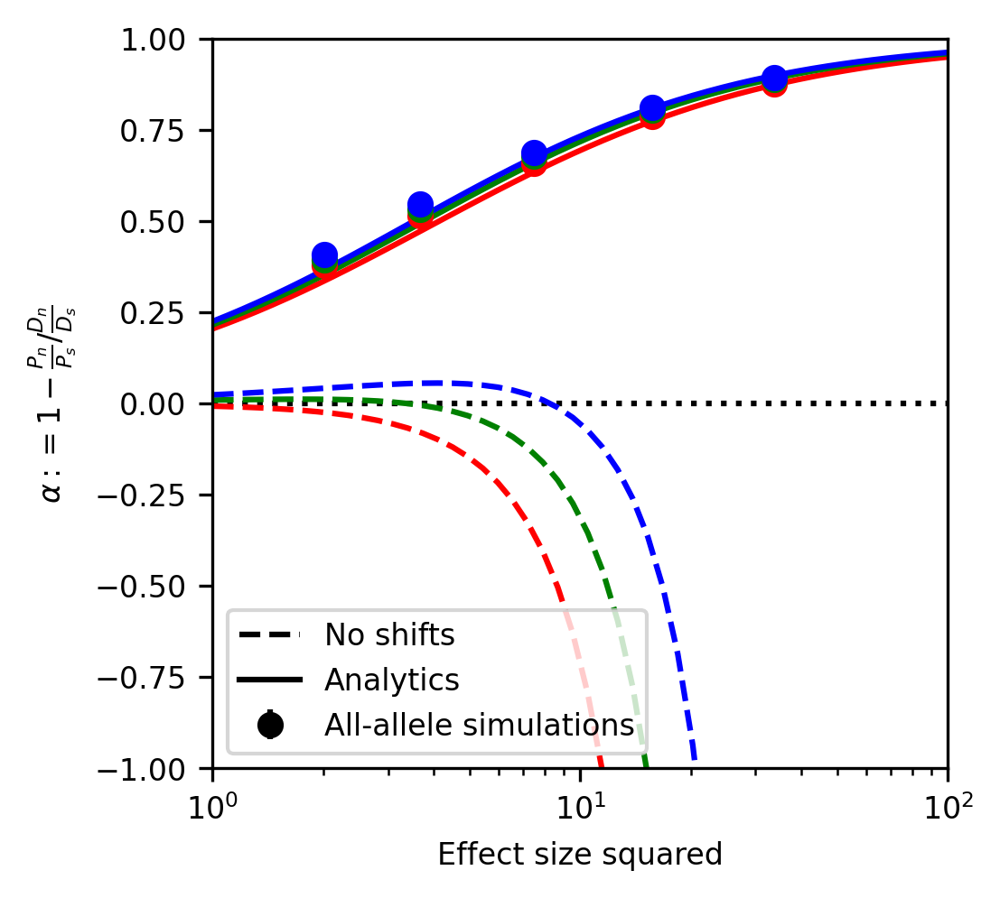

In [6]:
# McDonald-Kreitman test, in the non-Lande case
# to show that the frequency cutoff doesn't really affect the proportion of fixations due to adaptation
fontsize = 8

N = 2000
U = 0.025
E2Ns = 16
nE = 11
indices_ss = [0, 1, 3, 6, 9]

V2Ns = E2Ns ** 2
S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0.,
                                               scale=float(V2Ns) / float(E2Ns))
a_list_pos = [math.sqrt(S_dist.ppf((i + 1) / (nE + 1))) for i in range(nE)]
a_list_pos_between = [math.sqrt(a * a_next) for a, a_next in pairwise(a_list_pos)]

fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = fig.add_subplot(1, 1, 1)

shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 29
rate_of_shifts_partitioning = 66

neutral, = ax.plot(np.geomspace(1, 100), [0 for _ in np.geomspace(1, 100)], 'k:')

ax.plot(np.geomspace(1, 100), [1 - heterozygosity_(a=np.sqrt(ss)) / heterozygosity_(a=0.1) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N) for ss in np.geomspace(1, 100)], 'r--')

index_shift_s0, shift_s0 = 17, 1.5
for index_rate_of_shift, rate_of_shift, color in ((54, 0.192, 'r'), ):
    # analytics
    fixation_probability_relative_to_neutral = [pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for ss in np.geomspace(1, 100)]
    heterozygosity_relative_to_neutral = [heterozygosity_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / heterozygosity_(a=0.1) for ss in np.geomspace(1, 100)]
    ax.plot(np.geomspace(1, 100), np.subtract(1, np.divide(heterozygosity_relative_to_neutral, fixation_probability_relative_to_neutral)), color=color)
    
    # simulations
    parallel_AA = 49
    ## obtain the fixation probability of alleles with each a^2
    num_fixed = np.sum([read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/num_fixed_nE_%d' % (round(E2Ns), i, nE)) for i in range(1, 1 + parallel_AA)], axis=0)
    fixation_probability_mean = dict()
    fixation_probability_se = dict()
    for index_ss in indices_ss:
        fixation_probability_mean[index_ss] = num_fixed[index_ss + 1] / (10000000 / (nE + 1) * parallel_AA)
        fixation_probability_se[index_ss] = np.sqrt(fixation_probability_mean[index_ss] * (1 - fixation_probability_mean[index_ss]) / (10000000 / (nE + 1) * parallel_AA))
    ## obtain the heterozygosity of alleles with each a^2 in each generation, which are separated by 10N generations
    heterozygosity_each_generation = dict()
    heterozygosity_mean = dict()
    heterozygosity_se = dict()
    for index_ss in indices_ss:
        heterozygosity_each_generation[index_ss] = [h for i in range(1, 1 + parallel_AA) for h in read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/heterozygosity_nE_%d' % (round(E2Ns), i, nE))[index_ss + 1]]
        heterozygosity_mean[index_ss] = np.mean(heterozygosity_each_generation[index_ss])
        heterozygosity_se[index_ss] = np.divide(np.std(heterozygosity_each_generation[index_ss]), np.sqrt(np.size(heterozygosity_each_generation[index_ss])))
    ## plot the McDonald-Kreitman test
    for index_ss in indices_ss:
        ax.errorbar(a_list_pos_between[index_ss] ** 2, 1 - heterozygosity_mean[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_(a=0.1) / fixation_probability_mean[index_ss] / (2 * N), yerr=1.96 * heterozygosity_se[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_(a=0.1) / fixation_probability_mean[index_ss] / (2 * N), fmt='o', color=color)

maf_threshold = 0.05

ax.plot(np.geomspace(1, 100), [1 - heterozygosity_truncating_rare_alleles_(a=np.sqrt(ss), maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N) for ss in np.geomspace(1, 100)], 'g--')

index_shift_s0, shift_s0 = 17, 1.5
for index_rate_of_shift, rate_of_shift, color in ((54, 0.192, 'g'), ):
    # analytics
    fixation_probability_relative_to_neutral = [pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for ss in np.geomspace(1, 100)]
    heterozygosity_relative_to_neutral = [heterozygosity_shifts_truncating_rare_alleles_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift, maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) for ss in np.geomspace(1, 100)]
    ax.plot(np.geomspace(1, 100), np.subtract(1, np.divide(heterozygosity_relative_to_neutral, fixation_probability_relative_to_neutral)), color=color)
    
    # simulations
    parallel_AA = 49
    ## obtain the fixation probability of alleles with each a^2
    num_fixed = np.sum([read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/num_fixed_nE_%d' % (round(E2Ns), i, nE)) for i in range(1, 1 + parallel_AA)], axis=0)
    fixation_probability_mean = dict()
    fixation_probability_se = dict()
    for index_ss in indices_ss:
        fixation_probability_mean[index_ss] = num_fixed[index_ss + 1] / (10000000 / (nE + 1) * parallel_AA)
        fixation_probability_se[index_ss] = np.sqrt(fixation_probability_mean[index_ss] * (1 - fixation_probability_mean[index_ss]) / (10000000 / (nE + 1) * parallel_AA))
    ## obtain the heterozygosity of alleles with each a^2 in each generation, which are separated by 10N generations
    heterozygosity_each_generation = dict()
    heterozygosity_mean = dict()
    heterozygosity_se = dict()
    for index_ss in indices_ss:
        heterozygosity_each_generation[index_ss] = [h for i in range(1, 1 + parallel_AA) for h in read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/heterozygosity_nE_%d_maf_threshold_' % (round(E2Ns), i, nE) + str(maf_threshold).replace('.', '_'))[index_ss + 1]]
        heterozygosity_mean[index_ss] = np.mean(heterozygosity_each_generation[index_ss])
        heterozygosity_se[index_ss] = np.divide(np.std(heterozygosity_each_generation[index_ss]), np.sqrt(np.size(heterozygosity_each_generation[index_ss])))
    for index_ss in indices_ss:
        ax.errorbar(a_list_pos_between[index_ss] ** 2, 1 - heterozygosity_mean[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / fixation_probability_mean[index_ss] / (2 * N), yerr=1.96 * heterozygosity_se[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / fixation_probability_mean[index_ss] / (2 * N), fmt='o', color=color)

maf_threshold = 0.1

ax.plot(np.geomspace(1, 100), [1 - heterozygosity_truncating_rare_alleles_(a=np.sqrt(ss), maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi(a=np.sqrt(ss), x=1 / (2 * N)) / (2 * N) for ss in np.geomspace(1, 100)], 'b--')

index_shift_s0, shift_s0 = 17, 1.5
for index_rate_of_shift, rate_of_shift, color in ((54, 0.192, 'b'), ):
    # analytics
    fixation_probability_relative_to_neutral = [pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(ss), x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) * 2.0 * N for ss in np.geomspace(1, 100)]
    heterozygosity_relative_to_neutral = [heterozygosity_shifts_truncating_rare_alleles_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift, maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) for ss in np.geomspace(1, 100)]
    ax.plot(np.geomspace(1, 100), np.subtract(1, np.divide(heterozygosity_relative_to_neutral, fixation_probability_relative_to_neutral)), color=color)
    
    # simulations
    parallel_AA = 49
    ## obtain the fixation probability of alleles with each a^2
    num_fixed = np.sum([read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/num_fixed_nE_%d' % (round(E2Ns), i, nE)) for i in range(1, 1 + parallel_AA)], axis=0)
    fixation_probability_mean = dict()
    fixation_probability_se = dict()
    for index_ss in indices_ss:
        fixation_probability_mean[index_ss] = num_fixed[index_ss + 1] / (10000000 / (nE + 1) * parallel_AA)
        fixation_probability_se[index_ss] = np.sqrt(fixation_probability_mean[index_ss] * (1 - fixation_probability_mean[index_ss]) / (10000000 / (nE + 1) * parallel_AA))
    ## obtain the heterozygosity of alleles with each a^2 in each generation, which are separated by 10N generations
    heterozygosity_each_generation = dict()
    heterozygosity_mean = dict()
    heterozygosity_se = dict()
    for index_ss in indices_ss:
        heterozygosity_each_generation[index_ss] = [h for i in range(1, 1 + parallel_AA) for h in read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/heterozygosity_nE_%d_maf_threshold_' % (round(E2Ns), i, nE) + str(maf_threshold).replace('.', '_'))[index_ss + 1]]
        heterozygosity_mean[index_ss] = np.mean(heterozygosity_each_generation[index_ss])
        heterozygosity_se[index_ss] = np.divide(np.std(heterozygosity_each_generation[index_ss]), np.sqrt(np.size(heterozygosity_each_generation[index_ss])))
    for index_ss in indices_ss:
        ax.errorbar(a_list_pos_between[index_ss] ** 2, 1 - heterozygosity_mean[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / fixation_probability_mean[index_ss] / (2 * N), yerr=1.96 * heterozygosity_se[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / fixation_probability_mean[index_ss] / (2 * N), fmt='o', color=color)

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')
no_shifts, = ax.plot([], [], 'k--')

ax.set_xscale('log')
ax.set_xlim(1, 100)
ax.set_ylim(-1, 1)
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel(r'$\alpha := 1 - \frac{P_n}{P_s} / \frac{D_n}{D_s}$', fontsize=fontsize)
ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 0.), loc='lower left', fontsize=fontsize)

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

/tmp/ipykernel_1386325/3027982274.py:32: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  return quad(lambda x: 2.0 * x * (1.0 - x) * tau(a, x, 1/(2*N)), 0.0, 1.0, points = [1/(2*N), 1.0 - 1/(2*N)])[0]


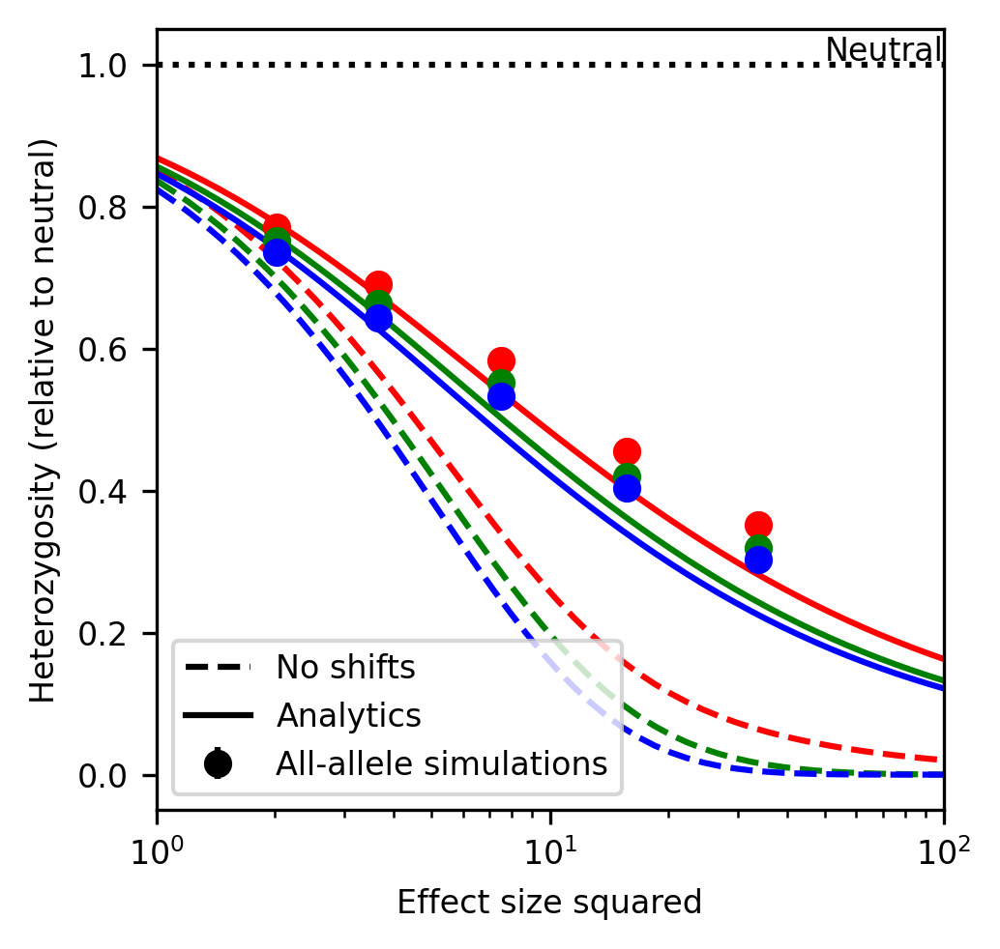

In [5]:
# to show that it's because the frequency cutoff doesn't really affect the heterozygosity
fontsize = 8

N = 2000
U = 0.025
E2Ns = 16
nE = 11
indices_ss = [0, 1, 3, 6, 9]

V2Ns = E2Ns ** 2
S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0.,
                                               scale=float(V2Ns) / float(E2Ns))
a_list_pos = [math.sqrt(S_dist.ppf((i + 1) / (nE + 1))) for i in range(nE)]
a_list_pos_between = [math.sqrt(a * a_next) for a, a_next in pairwise(a_list_pos)]

fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = fig.add_subplot(1, 1, 1)

shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 29
rate_of_shifts_partitioning = 66

# the heterozygosity
neutral, = ax.plot(np.geomspace(1, 100), [1 for _ in np.geomspace(1, 100)], 'k:')

ax.plot(np.geomspace(1, 100), [heterozygosity_(a=np.sqrt(ss)) / heterozygosity_(a=0.1) for ss in np.geomspace(1, 100)], 'r--')

ax.text(x=100, y=1.005, s='Neutral', horizontalalignment='right', color='k', fontsize=fontsize)

index_shift_s0, shift_s0 = 17, 1.5
for index_rate_of_shift, rate_of_shift, color in ((54, 0.192, 'r'), ):
    # analytics
    heterozygosity_relative_to_neutral = [heterozygosity_shifts_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / heterozygosity_(a=0.1) for ss in np.geomspace(1, 100)]
    ## the heterozygosity
    ax.plot(np.geomspace(1, 100), heterozygosity_relative_to_neutral, color=color)
    
    # simulations
    parallel_AA = 49
    ## obtain the heterozygosity of alleles with each a^2 in each generation, which are separated by 10N generations
    heterozygosity_each_generation = dict()
    heterozygosity_mean = dict()
    heterozygosity_se = dict()
    for index_ss in indices_ss:
        heterozygosity_each_generation[index_ss] = [h for i in range(1, 1 + parallel_AA) for h in read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/heterozygosity_nE_%d' % (round(E2Ns), i, nE))[index_ss + 1]]
        heterozygosity_mean[index_ss] = np.mean(heterozygosity_each_generation[index_ss])
        heterozygosity_se[index_ss] = np.divide(np.std(heterozygosity_each_generation[index_ss]), np.sqrt(np.size(heterozygosity_each_generation[index_ss])))
    for index_ss in indices_ss:
        ax.errorbar(a_list_pos_between[index_ss] ** 2, heterozygosity_mean[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_(a=0.1), yerr=1.96 * heterozygosity_se[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_(a=0.1), fmt='o', color=color)

maf_threshold = 0.05

# the heterozygosity
ax.plot(np.geomspace(1, 100), [heterozygosity_truncating_rare_alleles_(a=np.sqrt(ss), maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) for ss in np.geomspace(1, 100)], 'g--')

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')
no_shifts, = ax.plot([], [], 'k--')

ax.set_xscale('log')
ax.set_xlim(1, 100)
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel('Heterozygosity (relative to neutral)', fontsize=fontsize)
# ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 0.), loc='lower left', fontsize=fontsize)

index_shift_s0, shift_s0 = 17, 1.5
for index_rate_of_shift, rate_of_shift, color in ((54, 0.192, 'g'), ):
    # analytics
    heterozygosity_relative_to_neutral = [heterozygosity_shifts_truncating_rare_alleles_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift, maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) for ss in np.geomspace(1, 100)]
    ## the heterozygosity
    ax.plot(np.geomspace(1, 100), heterozygosity_relative_to_neutral, color=color)
    
    # simulations
    parallel_AA = 49
    ## obtain the heterozygosity of alleles with each a^2 in each generation, which are separated by 10N generations
    heterozygosity_each_generation = dict()
    heterozygosity_mean = dict()
    heterozygosity_se = dict()
    for index_ss in indices_ss:
        heterozygosity_each_generation[index_ss] = [h for i in range(1, 1 + parallel_AA) for h in read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/heterozygosity_nE_%d_maf_threshold_' % (round(E2Ns), i, nE) + str(maf_threshold).replace('.', '_'))[index_ss + 1]]
        heterozygosity_mean[index_ss] = np.mean(heterozygosity_each_generation[index_ss])
        heterozygosity_se[index_ss] = np.divide(np.std(heterozygosity_each_generation[index_ss]), np.sqrt(np.size(heterozygosity_each_generation[index_ss])))
    for index_ss in indices_ss:
        ax.errorbar(a_list_pos_between[index_ss] ** 2, heterozygosity_mean[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold), yerr=1.96 * heterozygosity_se[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold), fmt='o', color=color)

maf_threshold = 0.1

# the heterozygosity
ax.plot(np.geomspace(1, 100), [heterozygosity_truncating_rare_alleles_(a=np.sqrt(ss), maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) for ss in np.geomspace(1, 100)], 'b--')

index_shift_s0, shift_s0 = 17, 1.5
for index_rate_of_shift, rate_of_shift, color in ((54, 0.192, 'b'), ):
    # analytics
    heterozygosity_relative_to_neutral = [heterozygosity_shifts_truncating_rare_alleles_(a=np.sqrt(ss), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift, maf_threshold=maf_threshold) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) for ss in np.geomspace(1, 100)]
    ## the heterozygosity
    ax.plot(np.geomspace(1, 100), heterozygosity_relative_to_neutral, color=color)
    
    # simulations
    parallel_AA = 49
    ## obtain the heterozygosity of alleles with each a^2 in each generation, which are separated by 10N generations
    heterozygosity_each_generation = dict()
    heterozygosity_mean = dict()
    heterozygosity_se = dict()
    for index_ss in indices_ss:
        heterozygosity_each_generation[index_ss] = [h for i in range(1, 1 + parallel_AA) for h in read_pickle('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_d2ax_t_1_scaled_every_2N_generations_analytic_V_A_%d/heterozygosity_nE_%d_maf_threshold_' % (round(E2Ns), i, nE) + str(maf_threshold).replace('.', '_'))[index_ss + 1]]
        heterozygosity_mean[index_ss] = np.mean(heterozygosity_each_generation[index_ss])
        heterozygosity_se[index_ss] = np.divide(np.std(heterozygosity_each_generation[index_ss]), np.sqrt(np.size(heterozygosity_each_generation[index_ss])))
    for index_ss in indices_ss:
        ax.errorbar(a_list_pos_between[index_ss] ** 2, heterozygosity_mean[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold), yerr=1.96 * heterozygosity_se[index_ss] / (2 * N * U / (nE + 1)) / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold), fmt='o', color=color)

simulations = ax.errorbar([], [], yerr=[], fmt='o', color='k')
analytics, = ax.plot([], [], 'k-')
no_shifts, = ax.plot([], [], 'k--')

ax.set_xscale('log')
ax.set_xlim(1, 100)
ax.set_xlabel('Effect size squared', fontsize=fontsize)
ax.set_ylabel('Heterozygosity (relative to neutral)', fontsize=fontsize)
ax.legend(handles=[no_shifts, analytics, simulations], labels=['No shifts', 'Analytics', 'All-allele simulations'], bbox_to_anchor=(0., 0.), loc='lower left', fontsize=fontsize)

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

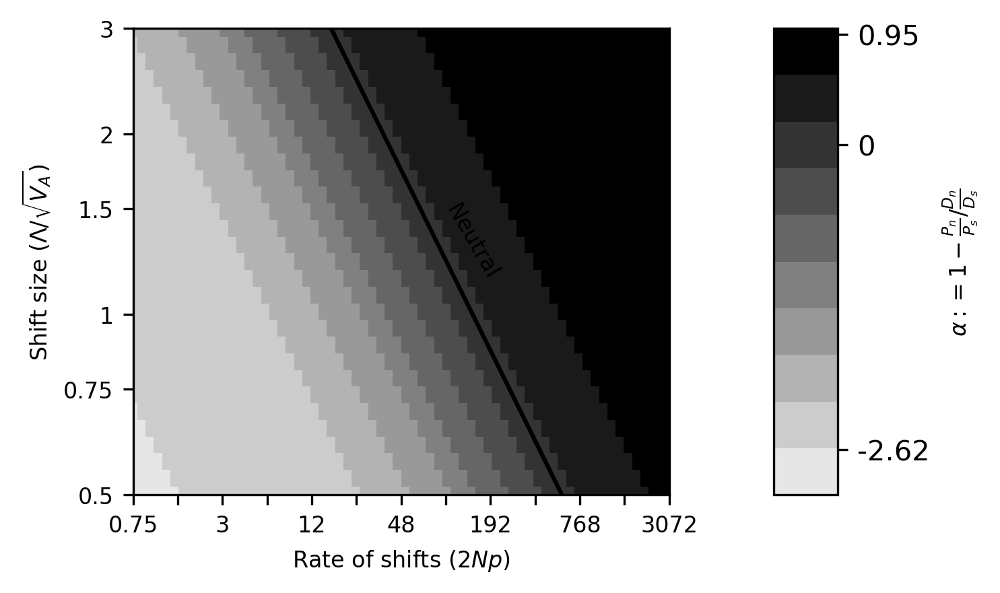

In [13]:
# the effect of recurrent shifts on the proportion of fixations due to adaptation, in the non-Lande case
# without frequency cutoff
fontsize = 8

N = 2000
U = 0.025
E2Ns = 16

shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 29
rate_of_shifts_partitioning = 66

Z = np.empty((shift_s0_partitioning, rate_of_shifts_partitioning))
for index_shift_s0, shift_s0 in enumerate(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)):
    for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)):
        with open('/insomnia001/depts/pas_lab/users/jc5473/analytic_heterozygosity_N_%d_U_' % N + str(U).replace('.', '_') + '_index_shift_s0_%d_index_rate_of_shift_%d_E2Ns_%d' % (index_shift_s0, index_rate_of_shift, round(E2Ns)), 'rb') as f:
            analytic_heterozygosity = pickle.load(f)
            Z[index_shift_s0, index_rate_of_shift] = 1 - analytic_heterozygosity / heterozygosity_(a=0.1) / pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(E2Ns), x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / (2 * N)
z_min, z_max = Z.min(), Z.max()

fig = plt.figure(figsize=(4.5, 3), dpi=300)
gs = fig.add_gridspec(1, 3, width_ratios=[25, 1, 3])
# twoslopenorm = colors.TwoSlopeNorm(vcenter=0, vmin=z_min, vmax=z_max)
# sm = plt.cm.ScalarMappable(cmap='RdGy', norm=twoslopenorm)
cmap = colors.ListedColormap(['0.9', '0.8', '0.7', '0.6', '0.5', '0.4', '0.3', '0.2', '0.1', '0'])
bounds = np.arange(-3., 1.05, 0.4)
norm = colors.BoundaryNorm(bounds, cmap.N)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)f
cbar = plt.colorbar(sm, cax=plt.subplot(gs[0, 2]), orientation='vertical')
# cbar.ax.axhline(y=0, color='k', linestyle='-')
cbar.set_label(r'$\alpha := 1 - \frac{P_n}{P_s} / \frac{D_n}{D_s}$', fontsize=fontsize)
cbar.ax.set_yticks([z_min, 0, z_max])
cbar.ax.set_yticklabels(['%.2f' % z_min, 0, '%.2f' % z_max])
cbar.ax.minorticks_off()

ax = plt.subplot(gs[0, 0])
x = 2 * N * np.geomspace(rate_of_shifts_list[0] / (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_list[-1] * (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_partitioning + 1)
y = np.geomspace(shift_s0_list[0] / (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_list[-1] * (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_partitioning + 1)
X, Y = np.meshgrid(x, y)
ax.pcolormesh(X, Y, Z, cmap=cmap, norm=norm)
ax.plot([2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)[np.searchsorted(Z[index_shift_s0, :], 0)] for index_shift_s0 in range(shift_s0_partitioning)], np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning), color='k', linestyle='-', label='Neutral')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(2 * N * rate_of_shifts_list[0], 2 * N * rate_of_shifts_list[-1])
ax.set_ylim(shift_s0_list[0], shift_s0_list[-1])
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_ylabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
assert len(rate_of_shifts_list) % 2 == 1
# assert len(shift_s0_list) % 2 == 1
ax.set_xticks(ticks=list(2 * N * np.array(rate_of_shifts_list)), labels=[2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
ax.set_yticks(ticks=shift_s0_list, labels=shift_s0_list, fontsize=fontsize)
ax.minorticks_off()
ax.text(x=96, y=1.5, s='Neutral', color='k', rotation=-60, rotation_mode='anchor', fontsize=fontsize)

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

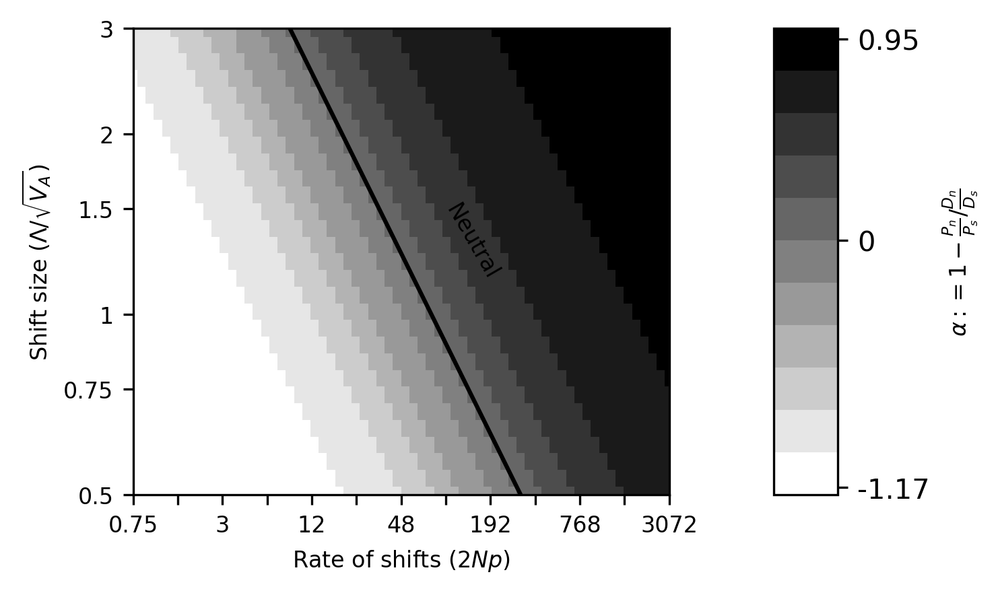

In [12]:
# the effect of recurrent shifts on the proportion of fixations due to adaptation, in the non-Lande case
# with frequency cutoff 0.05
fontsize = 8

N = 2000
U = 0.025
E2Ns = 16

maf_threshold = 0.05

shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 29
rate_of_shifts_partitioning = 66

Z = np.empty((shift_s0_partitioning, rate_of_shifts_partitioning))
for index_shift_s0, shift_s0 in enumerate(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)):
    for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)):
        with open('/insomnia001/depts/pas_lab/users/jc5473/analytic_heterozygosity_N_%d_U_' % N + str(U).replace('.', '_') + '_index_shift_s0_%d_index_rate_of_shift_%d_E2Ns_%d_maf_threshold_' % (index_shift_s0, index_rate_of_shift, round(E2Ns)) + str(maf_threshold).replace('.', '_'), 'rb') as f:
            analytic_heterozygosity = pickle.load(f)
            Z[index_shift_s0, index_rate_of_shift] = 1 - analytic_heterozygosity / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(E2Ns), x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / (2 * N)
z_min, z_max = Z.min(), Z.max()

fig = plt.figure(figsize=(4.5, 3), dpi=300)
gs = fig.add_gridspec(1, 3, width_ratios=[25, 1, 3])
# twoslopenorm = colors.TwoSlopeNorm(vcenter=0, vmin=z_min, vmax=z_max)
# sm = plt.cm.ScalarMappable(cmap='RdGy', norm=twoslopenorm)
cmap = colors.ListedColormap(['1', '0.9', '0.8', '0.7', '0.6', '0.5', '0.4', '0.3', '0.2', '0.1', '0'])
bounds = np.arange(-1.2, 1.05, 0.2)
norm = colors.BoundaryNorm(bounds, cmap.N)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = plt.colorbar(sm, cax=plt.subplot(gs[0, 2]), orientation='vertical')
# cbar.ax.axhline(y=0, color='k', linestyle='-')
cbar.set_label(r'$\alpha := 1 - \frac{P_n}{P_s} / \frac{D_n}{D_s}$', fontsize=fontsize)
cbar.ax.set_yticks([z_min, 0, z_max])
cbar.ax.set_yticklabels(['%.2f' % z_min, 0, '%.2f' % z_max])
cbar.ax.minorticks_off()

ax = plt.subplot(gs[0, 0])
x = 2 * N * np.geomspace(rate_of_shifts_list[0] / (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_list[-1] * (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_partitioning + 1)
y = np.geomspace(shift_s0_list[0] / (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_list[-1] * (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_partitioning + 1)
X, Y = np.meshgrid(x, y)
ax.pcolormesh(X, Y, Z, cmap=cmap, norm=norm)
ax.plot([2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)[np.searchsorted(Z[index_shift_s0, :], 0)] for index_shift_s0 in range(shift_s0_partitioning)], np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning), color='k', linestyle='-', label='Neutral')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(2 * N * rate_of_shifts_list[0], 2 * N * rate_of_shifts_list[-1])
ax.set_ylim(shift_s0_list[0], shift_s0_list[-1])
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_ylabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
assert len(rate_of_shifts_list) % 2 == 1
# assert len(shift_s0_list) % 2 == 1
ax.set_xticks(ticks=list(2 * N * np.array(rate_of_shifts_list)), labels=[2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
ax.set_yticks(ticks=shift_s0_list, labels=shift_s0_list, fontsize=fontsize)
ax.minorticks_off()
ax.text(x=96, y=1.5, s='Neutral', color='k', rotation=-60, rotation_mode='anchor', fontsize=fontsize)

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

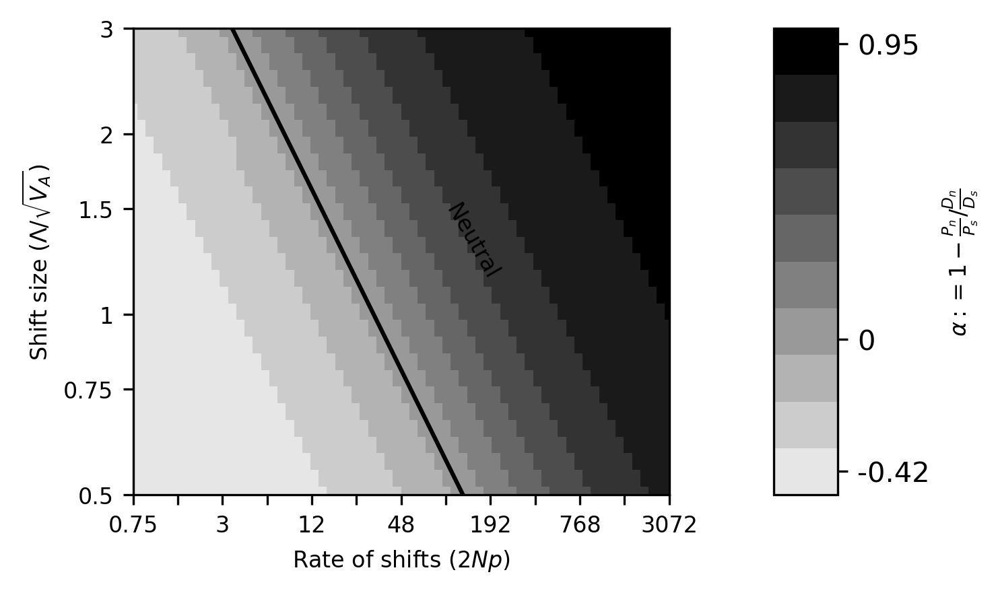

In [9]:
# the effect of recurrent shifts on the proportion of fixations due to adaptation, in the non-Lande case
# with frequency cutoff 0.1
fontsize = 8

N = 2000
U = 0.025
E2Ns = 16

maf_threshold = 0.1

shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 29
rate_of_shifts_partitioning = 66

Z = np.empty((shift_s0_partitioning, rate_of_shifts_partitioning))
for index_shift_s0, shift_s0 in enumerate(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning)):
    for index_rate_of_shift, rate_of_shift in enumerate(np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)):
        with open('/insomnia001/depts/pas_lab/users/jc5473/analytic_heterozygosity_N_%d_U_' % N + str(U).replace('.', '_') + '_index_shift_s0_%d_index_rate_of_shift_%d_E2Ns_%d_maf_threshold_' % (index_shift_s0, index_rate_of_shift, round(E2Ns)) + str(maf_threshold).replace('.', '_'), 'rb') as f:
            analytic_heterozygosity = pickle.load(f)
            Z[index_shift_s0, index_rate_of_shift] = 1 - analytic_heterozygosity / heterozygosity_truncating_rare_alleles_(a=0.1, maf_threshold=maf_threshold) / pi_recurrent_shifts_nonlinear_linear_V_Delta_x(a=np.sqrt(E2Ns), x=1.0 / (2 * N), shift_s0=shift_s0, sigma_0_del=np.sqrt(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift]), p=rate_of_shift) / (2 * N)
z_min, z_max = Z.min(), Z.max()

fig = plt.figure(figsize=(4.5, 3), dpi=300)
gs = fig.add_gridspec(1, 3, width_ratios=[25, 1, 3])
# twoslopenorm = colors.TwoSlopeNorm(vcenter=0, vmin=z_min, vmax=z_max)
# sm = plt.cm.ScalarMappable(cmap='RdGy', norm=twoslopenorm)
cmap = colors.ListedColormap(['0.9', '0.8', '0.7', '0.6', '0.5', '0.4', '0.3', '0.2', '0.1', '0'])
bounds = np.arange(-0.5, 1.05, 0.15)
norm = colors.BoundaryNorm(bounds, cmap.N)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = plt.colorbar(sm, cax=plt.subplot(gs[0, 2]), orientation='vertical')
# cbar.ax.axhline(y=0, color='k', linestyle='-')
cbar.set_label(r'$\alpha := 1 - \frac{P_n}{P_s} / \frac{D_n}{D_s}$', fontsize=fontsize)
cbar.ax.set_yticks([z_min, 0, z_max])
cbar.ax.set_yticklabels(['%.2f' % z_min, 0, '%.2f' % z_max])
cbar.ax.minorticks_off()

ax = plt.subplot(gs[0, 0])
x = 2 * N * np.geomspace(rate_of_shifts_list[0] / (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_list[-1] * (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_partitioning + 1)
y = np.geomspace(shift_s0_list[0] / (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_list[-1] * (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_partitioning + 1)
X, Y = np.meshgrid(x, y)
ax.pcolormesh(X, Y, Z, cmap=cmap, norm=norm)
ax.plot([2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning)[np.searchsorted(Z[index_shift_s0, :], 0)] for index_shift_s0 in range(shift_s0_partitioning)], np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning), color='k', linestyle='-', label='Neutral')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(2 * N * rate_of_shifts_list[0], 2 * N * rate_of_shifts_list[-1])
ax.set_ylim(shift_s0_list[0], shift_s0_list[-1])
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_ylabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
assert len(rate_of_shifts_list) % 2 == 1
# assert len(shift_s0_list) % 2 == 1
ax.set_xticks(ticks=list(2 * N * np.array(rate_of_shifts_list)), labels=[2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
ax.set_yticks(ticks=shift_s0_list, labels=shift_s0_list, fontsize=fontsize)
ax.minorticks_off()
ax.text(x=96, y=1.5, s='Neutral', color='k', rotation=-60, rotation_mode='anchor', fontsize=fontsize)

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

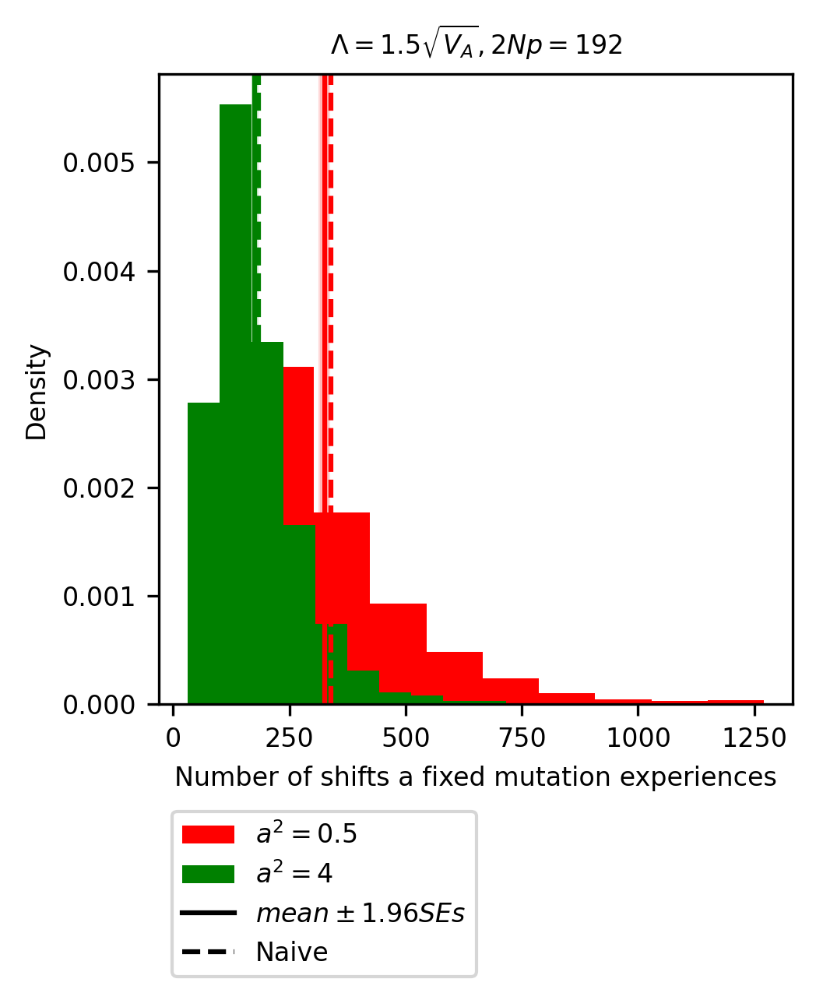

In [5]:
# the histogram of the total number of shifts that a fixed mutation experiences, in the Lande case
# linear scale
fontsize = 8

N = 2000
U = 0.025
E2Ns = 1
nE = 100

V2Ns = E2Ns ** 2
S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0.,
                                               scale=float(V2Ns) / float(E2Ns))
a_list_pos = [math.sqrt(S_dist.ppf((i + 1) / (nE + 1))) for i in range(nE)]

index_shift_s0, shift_s0 = 3, 1.5
index_rate_of_shift, rate_of_shift = 8, 0.048

fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = fig.add_subplot(1, 1, 1)

for index_ss, ss, color in ((38, 0.5, 'r'), (98, 4, 'g')):
    # max_number_of_aligned_or_opposing_shifts_experienced = 0
    # numbers_of_aligned_shifts_experienced = list()
    # numbers_of_opposing_shifts_experienced = list()
    numbers_of_shifts_experienced = list()
    naive_samples = list()
    parallel_AA = 49
    for i in range(1, 1 + parallel_AA):
        with open('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_time_arising_fixing_empirical_average_V_A_%d/fixations_and_extinctions' % (round(E2Ns), i), 'rb') as f:
            fixations_and_extinctions, _, dist_ess_over_time, _, _, _, fixation_timings = pickle.load(f)
        shift_times = [tM for tM in range(len(dist_ess_over_time)) if abs(dist_ess_over_time[tM] - dist_ess_over_time[tM - 1]) >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])]
        # trait_increasing_shift_times = [tM for tM in range(len(dist_ess_over_time)) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])]
        # trait_decreasing_shift_times = [tM for tM in range(len(dist_ess_over_time)) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])]
        for fixation_timing, a in zip(fixation_timings, [mut[0] for mut in fixations_and_extinctions if mut[1]]):
            if np.searchsorted(a_list_pos, np.abs(a)) == index_ss + 1:
                # number_of_trait_increasing_shifts_experienced = np.searchsorted(trait_increasing_shift_times, fixation_timing[1]) - np.searchsorted(trait_increasing_shift_times, fixation_timing[0])
                # number_of_trait_decreasing_shifts_experienced = np.searchsorted(trait_decreasing_shift_times, fixation_timing[1]) - np.searchsorted(trait_decreasing_shift_times, fixation_timing[0])
                numbers_of_shifts_experienced.append(np.searchsorted(shift_times, fixation_timing[1]) - np.searchsorted(shift_times, fixation_timing[0]))
                # max_number_of_aligned_or_opposing_shifts_experienced = max(max_number_of_aligned_or_opposing_shifts_experienced, number_of_trait_increasing_shifts_experienced, number_of_trait_decreasing_shifts_experienced)
                # if a > 0:
                #     numbers_of_aligned_shifts_experienced.append(number_of_trait_increasing_shifts_experienced)
                #     numbers_of_opposing_shifts_experienced.append(number_of_trait_decreasing_shifts_experienced)
                # else:
                #     numbers_of_aligned_shifts_experienced.append(number_of_trait_decreasing_shifts_experienced)
                #     numbers_of_opposing_shifts_experienced.append(number_of_trait_increasing_shifts_experienced)
                naive_samples.append(rate_of_shift * (fixation_timing[1] - fixation_timing[0]))
    # ax.hist(np.divide(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced), np.add(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), density=True, color=color, label=r'$a^2=%g$' % ss)
    
    ax.axvline(x=np.mean(naive_samples), color=color, linestyle='--')
    ax.axvspan(xmin=np.mean(numbers_of_shifts_experienced) - 1.96 * np.divide(np.std(numbers_of_shifts_experienced), np.sqrt(np.size(numbers_of_shifts_experienced))), xmax=np.mean(numbers_of_shifts_experienced) + 1.96 * np.divide(np.std(numbers_of_shifts_experienced), np.sqrt(np.size(numbers_of_shifts_experienced))), color=color, alpha=0.15)
    ax.axvline(x=np.mean(numbers_of_shifts_experienced), color=color)
    
    ax.hist(numbers_of_shifts_experienced, density=True, color=color, label=r'$a^2=%g$' % ss)
    
# ax.axvline(x=rate_of_shift * np.mean([fixation_timing[1] - fixation_timing[0] for fixation_timing in fixation_timings]), color='k', label='Naive')
ax.plot([], [], color='k', label=r'$mean\pm 1.96SEs$')
ax.plot([], [], color='k', linestyle='--', label='Naive')
ax.legend(bbox_to_anchor=(0., -.15), loc='upper left', fontsize=fontsize)
plt.xlabel('Number of shifts a fixed mutation experiences', fontsize=fontsize)
plt.ylabel('Density', fontsize=fontsize)
plt.title(r'$\Lambda=%g\sqrt{V_A}, 2Np=%g$' % (shift_s0, 2 * N * rate_of_shift), fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

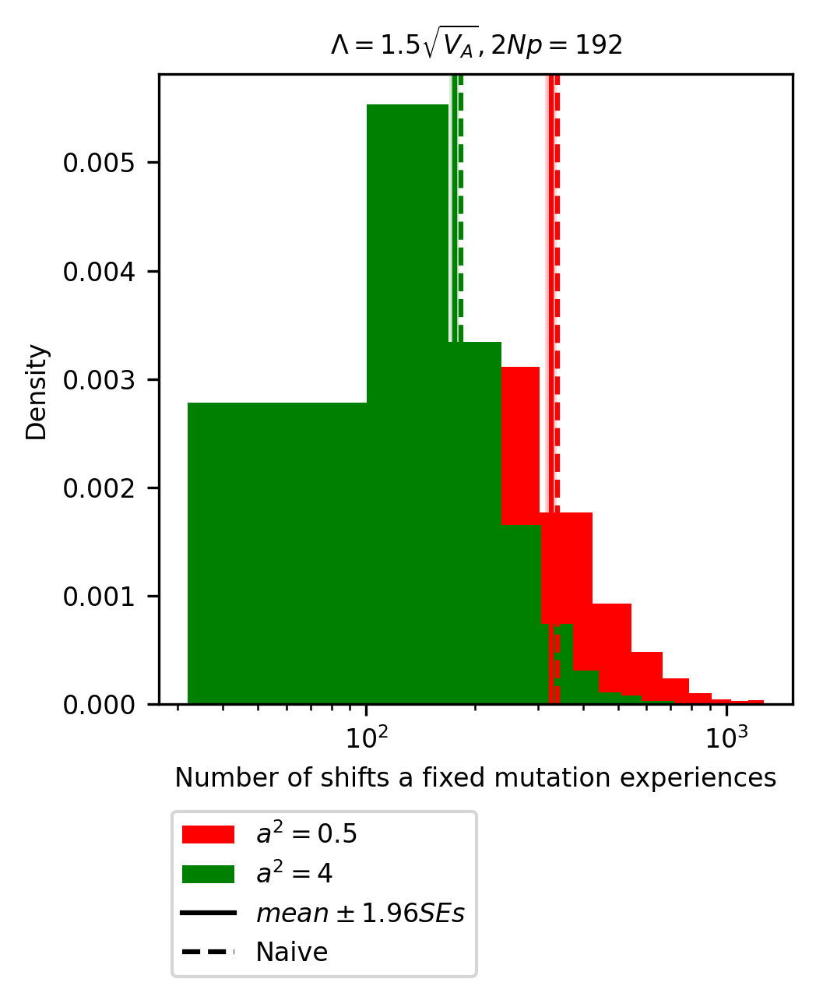

In [6]:
# log scale
fontsize = 8

N = 2000
U = 0.025
E2Ns = 1
nE = 100

V2Ns = E2Ns ** 2
S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0.,
                                               scale=float(V2Ns) / float(E2Ns))
a_list_pos = [math.sqrt(S_dist.ppf((i + 1) / (nE + 1))) for i in range(nE)]

index_shift_s0, shift_s0 = 3, 1.5
index_rate_of_shift, rate_of_shift = 8, 0.048

fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = fig.add_subplot(1, 1, 1)

for index_ss, ss, color in ((38, 0.5, 'r'), (98, 4, 'g')):
    # max_number_of_aligned_or_opposing_shifts_experienced = 0
    # numbers_of_aligned_shifts_experienced = list()
    # numbers_of_opposing_shifts_experienced = list()
    numbers_of_shifts_experienced = list()
    naive_samples = list()
    parallel_AA = 49
    for i in range(1, 1 + parallel_AA):
        with open('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_time_arising_fixing_empirical_average_V_A_%d/fixations_and_extinctions' % (round(E2Ns), i), 'rb') as f:
            fixations_and_extinctions, _, dist_ess_over_time, _, _, _, fixation_timings = pickle.load(f)
        shift_times = [tM for tM in range(len(dist_ess_over_time)) if abs(dist_ess_over_time[tM] - dist_ess_over_time[tM - 1]) >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])]
        # trait_increasing_shift_times = [tM for tM in range(len(dist_ess_over_time)) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])]
        # trait_decreasing_shift_times = [tM for tM in range(len(dist_ess_over_time)) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])]
        for fixation_timing, a in zip(fixation_timings, [mut[0] for mut in fixations_and_extinctions if mut[1]]):
            if np.searchsorted(a_list_pos, np.abs(a)) == index_ss + 1:
                # number_of_trait_increasing_shifts_experienced = np.searchsorted(trait_increasing_shift_times, fixation_timing[1]) - np.searchsorted(trait_increasing_shift_times, fixation_timing[0])
                # number_of_trait_decreasing_shifts_experienced = np.searchsorted(trait_decreasing_shift_times, fixation_timing[1]) - np.searchsorted(trait_decreasing_shift_times, fixation_timing[0])
                numbers_of_shifts_experienced.append(np.searchsorted(shift_times, fixation_timing[1]) - np.searchsorted(shift_times, fixation_timing[0]))
                # max_number_of_aligned_or_opposing_shifts_experienced = max(max_number_of_aligned_or_opposing_shifts_experienced, number_of_trait_increasing_shifts_experienced, number_of_trait_decreasing_shifts_experienced)
                # if a > 0:
                #     numbers_of_aligned_shifts_experienced.append(number_of_trait_increasing_shifts_experienced)
                #     numbers_of_opposing_shifts_experienced.append(number_of_trait_decreasing_shifts_experienced)
                # else:
                #     numbers_of_aligned_shifts_experienced.append(number_of_trait_decreasing_shifts_experienced)
                #     numbers_of_opposing_shifts_experienced.append(number_of_trait_increasing_shifts_experienced)
                naive_samples.append(rate_of_shift * (fixation_timing[1] - fixation_timing[0]))
    # ax.hist(np.divide(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced), np.add(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), density=True, color=color, label=r'$a^2=%g$' % ss)
    
    ax.axvline(x=np.mean(naive_samples), color=color, linestyle='--')
    ax.axvspan(xmin=np.mean(numbers_of_shifts_experienced) - 1.96 * np.divide(np.std(numbers_of_shifts_experienced), np.sqrt(np.size(numbers_of_shifts_experienced))), xmax=np.mean(numbers_of_shifts_experienced) + 1.96 * np.divide(np.std(numbers_of_shifts_experienced), np.sqrt(np.size(numbers_of_shifts_experienced))), color=color, alpha=0.15)
    ax.axvline(x=np.mean(numbers_of_shifts_experienced), color=color)
    
    ax.hist(numbers_of_shifts_experienced, density=True, color=color, label=r'$a^2=%g$' % ss)
    
# ax.axvline(x=rate_of_shift * np.mean([fixation_timing[1] - fixation_timing[0] for fixation_timing in fixation_timings]), color='k', label='Naive')
ax.plot([], [], color='k', label=r'$mean\pm 1.96SEs$')
ax.plot([], [], color='k', linestyle='--', label='Naive')
ax.set_xscale('log')
ax.legend(bbox_to_anchor=(0., -.15), loc='upper left', fontsize=fontsize)
plt.xlabel('Number of shifts a fixed mutation experiences', fontsize=fontsize)
plt.ylabel('Density', fontsize=fontsize)
plt.title(r'$\Lambda=%g\sqrt{V_A}, 2Np=%g$' % (shift_s0, 2 * N * rate_of_shift), fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

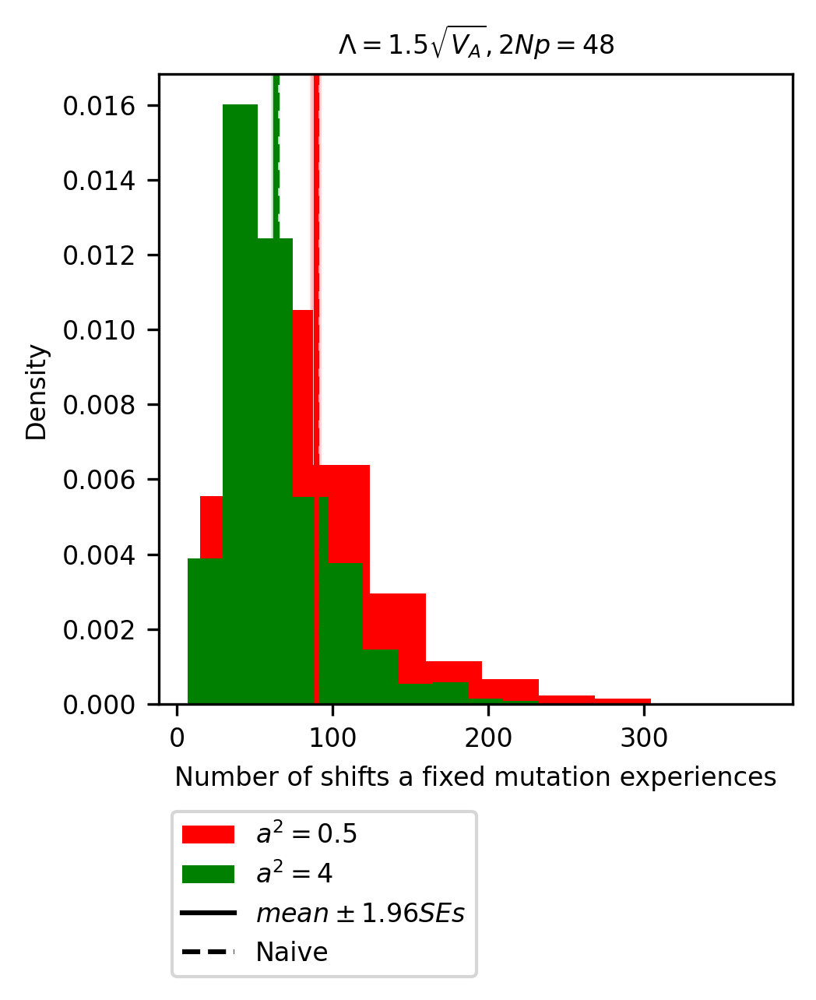

In [7]:
fontsize = 8

N = 2000
U = 0.025
E2Ns = 1
nE = 100

V2Ns = E2Ns ** 2
S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0.,
                                               scale=float(V2Ns) / float(E2Ns))
a_list_pos = [math.sqrt(S_dist.ppf((i + 1) / (nE + 1))) for i in range(nE)]

index_shift_s0, shift_s0 = 3, 1.5
index_rate_of_shift, rate_of_shift = 6, 0.012

fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = fig.add_subplot(1, 1, 1)

for index_ss, ss, color in ((38, 0.5, 'r'), (98, 4, 'g')):
    # max_number_of_aligned_or_opposing_shifts_experienced = 0
    # numbers_of_aligned_shifts_experienced = list()
    # numbers_of_opposing_shifts_experienced = list()
    numbers_of_shifts_experienced = list()
    naive_samples = list()
    parallel_AA = 49
    for i in range(1, 1 + parallel_AA):
        with open('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_time_arising_fixing_empirical_average_V_A_%d/fixations_and_extinctions' % (round(E2Ns), i), 'rb') as f:
            fixations_and_extinctions, _, dist_ess_over_time, _, _, _, fixation_timings = pickle.load(f)
        shift_times = [tM for tM in range(len(dist_ess_over_time)) if abs(dist_ess_over_time[tM] - dist_ess_over_time[tM - 1]) >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])]
        # trait_increasing_shift_times = [tM for tM in range(len(dist_ess_over_time)) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])]
        # trait_decreasing_shift_times = [tM for tM in range(len(dist_ess_over_time)) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])]
        for fixation_timing, a in zip(fixation_timings, [mut[0] for mut in fixations_and_extinctions if mut[1]]):
            if np.searchsorted(a_list_pos, np.abs(a)) == index_ss + 1:
                # number_of_trait_increasing_shifts_experienced = np.searchsorted(trait_increasing_shift_times, fixation_timing[1]) - np.searchsorted(trait_increasing_shift_times, fixation_timing[0])
                # number_of_trait_decreasing_shifts_experienced = np.searchsorted(trait_decreasing_shift_times, fixation_timing[1]) - np.searchsorted(trait_decreasing_shift_times, fixation_timing[0])
                numbers_of_shifts_experienced.append(np.searchsorted(shift_times, fixation_timing[1]) - np.searchsorted(shift_times, fixation_timing[0]))
                # max_number_of_aligned_or_opposing_shifts_experienced = max(max_number_of_aligned_or_opposing_shifts_experienced, number_of_trait_increasing_shifts_experienced, number_of_trait_decreasing_shifts_experienced)
                # if a > 0:
                #     numbers_of_aligned_shifts_experienced.append(number_of_trait_increasing_shifts_experienced)
                #     numbers_of_opposing_shifts_experienced.append(number_of_trait_decreasing_shifts_experienced)
                # else:
                #     numbers_of_aligned_shifts_experienced.append(number_of_trait_decreasing_shifts_experienced)
                #     numbers_of_opposing_shifts_experienced.append(number_of_trait_increasing_shifts_experienced)
                naive_samples.append(rate_of_shift * (fixation_timing[1] - fixation_timing[0]))
    # ax.hist(np.divide(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced), np.add(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), density=True, color=color, label=r'$a^2=%g$' % ss)
    
    ax.axvline(x=np.mean(naive_samples), color=color, linestyle='--')
    ax.axvspan(xmin=np.mean(numbers_of_shifts_experienced) - 1.96 * np.divide(np.std(numbers_of_shifts_experienced), np.sqrt(np.size(numbers_of_shifts_experienced))), xmax=np.mean(numbers_of_shifts_experienced) + 1.96 * np.divide(np.std(numbers_of_shifts_experienced), np.sqrt(np.size(numbers_of_shifts_experienced))), color=color, alpha=0.15)
    ax.axvline(x=np.mean(numbers_of_shifts_experienced), color=color)
    
    ax.hist(numbers_of_shifts_experienced, density=True, color=color, label=r'$a^2=%g$' % ss)
    
# ax.axvline(x=rate_of_shift * np.mean([fixation_timing[1] - fixation_timing[0] for fixation_timing in fixation_timings]), color='k', label='Naive')
ax.plot([], [], color='k', label=r'$mean\pm 1.96SEs$')
ax.plot([], [], color='k', linestyle='--', label='Naive')
ax.legend(bbox_to_anchor=(0., -.15), loc='upper left', fontsize=fontsize)
plt.xlabel('Number of shifts a fixed mutation experiences', fontsize=fontsize)
plt.ylabel('Density', fontsize=fontsize)
plt.title(r'$\Lambda=%g\sqrt{V_A}, 2Np=%g$' % (shift_s0, 2 * N * rate_of_shift), fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

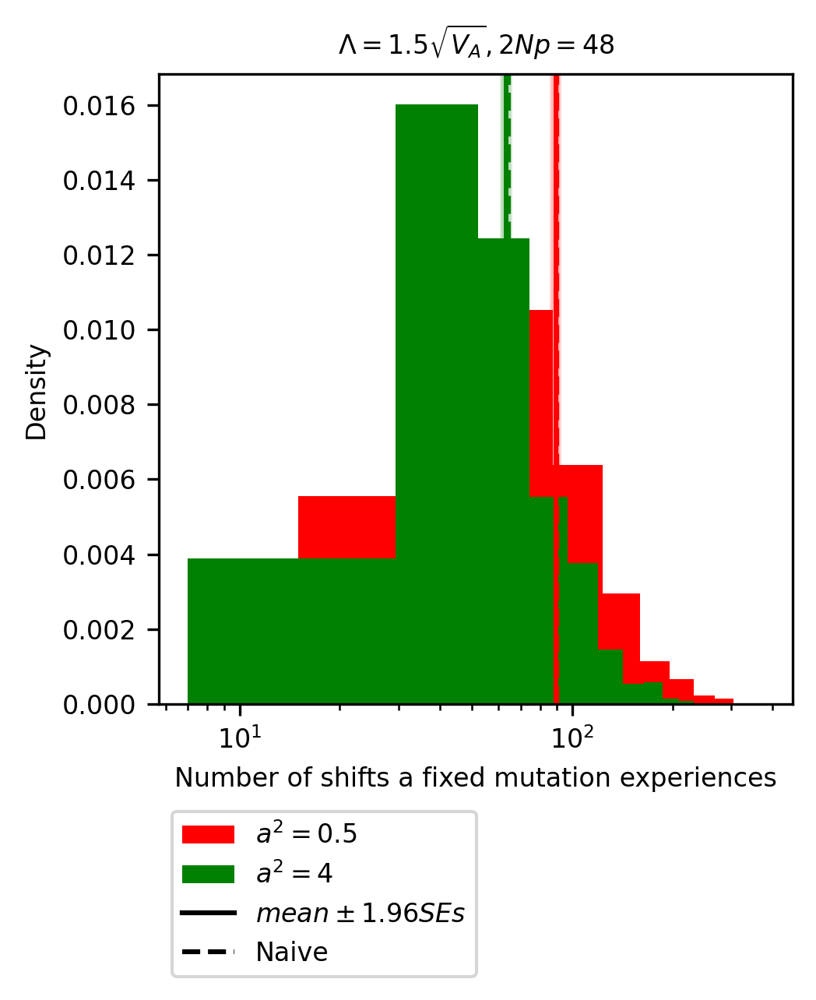

In [8]:
fontsize = 8

N = 2000
U = 0.025
E2Ns = 1
nE = 100

V2Ns = E2Ns ** 2
S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0.,
                                               scale=float(V2Ns) / float(E2Ns))
a_list_pos = [math.sqrt(S_dist.ppf((i + 1) / (nE + 1))) for i in range(nE)]

index_shift_s0, shift_s0 = 3, 1.5
index_rate_of_shift, rate_of_shift = 6, 0.012

fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = fig.add_subplot(1, 1, 1)

for index_ss, ss, color in ((38, 0.5, 'r'), (98, 4, 'g')):
    # max_number_of_aligned_or_opposing_shifts_experienced = 0
    # numbers_of_aligned_shifts_experienced = list()
    # numbers_of_opposing_shifts_experienced = list()
    numbers_of_shifts_experienced = list()
    naive_samples = list()
    parallel_AA = 49
    for i in range(1, 1 + parallel_AA):
        with open('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_time_arising_fixing_empirical_average_V_A_%d/fixations_and_extinctions' % (round(E2Ns), i), 'rb') as f:
            fixations_and_extinctions, _, dist_ess_over_time, _, _, _, fixation_timings = pickle.load(f)
        shift_times = [tM for tM in range(len(dist_ess_over_time)) if abs(dist_ess_over_time[tM] - dist_ess_over_time[tM - 1]) >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])]
        # trait_increasing_shift_times = [tM for tM in range(len(dist_ess_over_time)) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])]
        # trait_decreasing_shift_times = [tM for tM in range(len(dist_ess_over_time)) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])]
        for fixation_timing, a in zip(fixation_timings, [mut[0] for mut in fixations_and_extinctions if mut[1]]):
            if np.searchsorted(a_list_pos, np.abs(a)) == index_ss + 1:
                # number_of_trait_increasing_shifts_experienced = np.searchsorted(trait_increasing_shift_times, fixation_timing[1]) - np.searchsorted(trait_increasing_shift_times, fixation_timing[0])
                # number_of_trait_decreasing_shifts_experienced = np.searchsorted(trait_decreasing_shift_times, fixation_timing[1]) - np.searchsorted(trait_decreasing_shift_times, fixation_timing[0])
                numbers_of_shifts_experienced.append(np.searchsorted(shift_times, fixation_timing[1]) - np.searchsorted(shift_times, fixation_timing[0]))
                # max_number_of_aligned_or_opposing_shifts_experienced = max(max_number_of_aligned_or_opposing_shifts_experienced, number_of_trait_increasing_shifts_experienced, number_of_trait_decreasing_shifts_experienced)
                # if a > 0:
                #     numbers_of_aligned_shifts_experienced.append(number_of_trait_increasing_shifts_experienced)
                #     numbers_of_opposing_shifts_experienced.append(number_of_trait_decreasing_shifts_experienced)
                # else:
                #     numbers_of_aligned_shifts_experienced.append(number_of_trait_decreasing_shifts_experienced)
                #     numbers_of_opposing_shifts_experienced.append(number_of_trait_increasing_shifts_experienced)
                naive_samples.append(rate_of_shift * (fixation_timing[1] - fixation_timing[0]))
    # ax.hist(np.divide(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced), np.add(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), density=True, color=color, label=r'$a^2=%g$' % ss)
    
    ax.axvline(x=np.mean(naive_samples), color=color, linestyle='--')
    ax.axvspan(xmin=np.mean(numbers_of_shifts_experienced) - 1.96 * np.divide(np.std(numbers_of_shifts_experienced), np.sqrt(np.size(numbers_of_shifts_experienced))), xmax=np.mean(numbers_of_shifts_experienced) + 1.96 * np.divide(np.std(numbers_of_shifts_experienced), np.sqrt(np.size(numbers_of_shifts_experienced))), color=color, alpha=0.15)
    ax.axvline(x=np.mean(numbers_of_shifts_experienced), color=color)
    
    ax.hist(numbers_of_shifts_experienced, density=True, color=color, label=r'$a^2=%g$' % ss)
    
# ax.axvline(x=rate_of_shift * np.mean([fixation_timing[1] - fixation_timing[0] for fixation_timing in fixation_timings]), color='k', label='Naive')
ax.plot([], [], color='k', label=r'$mean\pm 1.96SEs$')
ax.plot([], [], color='k', linestyle='--', label='Naive')
ax.set_xscale('log')
ax.legend(bbox_to_anchor=(0., -.15), loc='upper left', fontsize=fontsize)
plt.xlabel('Number of shifts a fixed mutation experiences', fontsize=fontsize)
plt.ylabel('Density', fontsize=fontsize)
plt.title(r'$\Lambda=%g\sqrt{V_A}, 2Np=%g$' % (shift_s0, 2 * N * rate_of_shift), fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

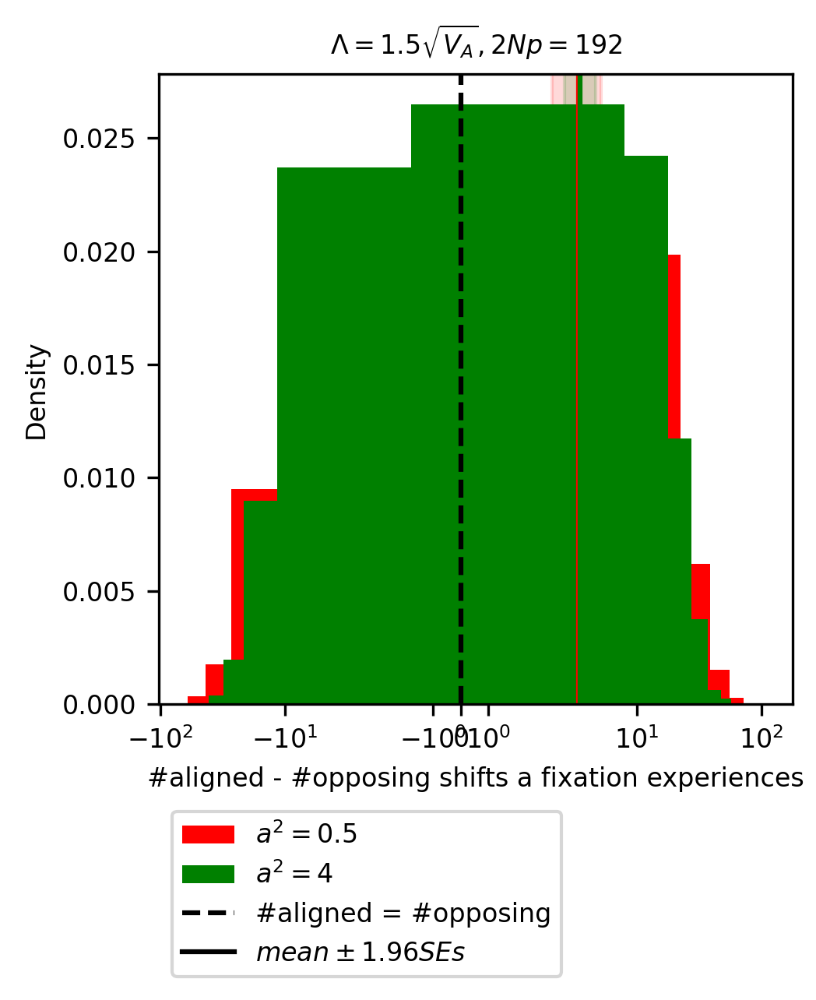

In [9]:
# the histogram of the excess number of aligned shifts than opposing shifts that a fixed mutation experiences, in the Lande case
# log scale
fontsize = 8

N = 2000
U = 0.025
E2Ns = 1
nE = 100

V2Ns = E2Ns ** 2
S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0.,
                                               scale=float(V2Ns) / float(E2Ns))
a_list_pos = [math.sqrt(S_dist.ppf((i + 1) / (nE + 1))) for i in range(nE)]

index_shift_s0, shift_s0 = 3, 1.5
index_rate_of_shift, rate_of_shift = 8, 0.048

fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = fig.add_subplot(1, 1, 1)

index_ss, ss, color = 38, 0.5, 'r'
# max_number_of_aligned_or_opposing_shifts_experienced = 0
numbers_of_aligned_shifts_experienced = list()
numbers_of_opposing_shifts_experienced = list()
parallel_AA = 49
for i in range(1, 1 + parallel_AA):
    with open('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_time_arising_fixing_empirical_average_V_A_%d/fixations_and_extinctions' % (round(E2Ns), i), 'rb') as f:
        fixations_and_extinctions, _, dist_ess_over_time, _, _, _, fixation_timings = pickle.load(f)
    trait_increasing_shift_times = [tM for tM in range(len(dist_ess_over_time)) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])]
    trait_decreasing_shift_times = [tM for tM in range(len(dist_ess_over_time)) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])]
    for fixation_timing, a in zip(fixation_timings, [mut[0] for mut in fixations_and_extinctions if mut[1]]):
        if np.searchsorted(a_list_pos, np.abs(a)) == index_ss + 1:
            number_of_trait_increasing_shifts_experienced = np.searchsorted(trait_increasing_shift_times, fixation_timing[1]) - np.searchsorted(trait_increasing_shift_times, fixation_timing[0])
            number_of_trait_decreasing_shifts_experienced = np.searchsorted(trait_decreasing_shift_times, fixation_timing[1]) - np.searchsorted(trait_decreasing_shift_times, fixation_timing[0])
            # max_number_of_aligned_or_opposing_shifts_experienced = max(max_number_of_aligned_or_opposing_shifts_experienced, number_of_trait_increasing_shifts_experienced, number_of_trait_decreasing_shifts_experienced)
            if a > 0:
                numbers_of_aligned_shifts_experienced.append(number_of_trait_increasing_shifts_experienced)
                numbers_of_opposing_shifts_experienced.append(number_of_trait_decreasing_shifts_experienced)
            else:
                numbers_of_aligned_shifts_experienced.append(number_of_trait_decreasing_shifts_experienced)
                numbers_of_opposing_shifts_experienced.append(number_of_trait_increasing_shifts_experienced)
ax.hist(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced), density=True, color=color, label=r'$a^2=%g$' % ss)
ax.axvline(x=np.mean(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), color=color)
ax.axvspan(xmin=np.mean(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)) - 1.96 * np.divide(np.std(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), np.sqrt(np.size(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)))), xmax=np.mean(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)) + 1.96 * np.divide(np.std(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), np.sqrt(np.size(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)))), color=color, alpha=0.15)

index_ss, ss, color = 98, 4, 'g'
# max_number_of_aligned_or_opposing_shifts_experienced = 0
numbers_of_aligned_shifts_experienced = list()
numbers_of_opposing_shifts_experienced = list()
parallel_AA = 49
for i in range(1, 1 + parallel_AA):
    with open('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_time_arising_fixing_empirical_average_V_A_%d/fixations_and_extinctions' % (round(E2Ns), i), 'rb') as f:
        fixations_and_extinctions, _, dist_ess_over_time, _, _, _, fixation_timings = pickle.load(f)
    trait_increasing_shift_times = [tM for tM in range(len(dist_ess_over_time)) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])]
    trait_decreasing_shift_times = [tM for tM in range(len(dist_ess_over_time)) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])]
    for fixation_timing, a in zip(fixation_timings, [mut[0] for mut in fixations_and_extinctions if mut[1]]):
        if np.searchsorted(a_list_pos, np.abs(a)) == index_ss + 1:
            number_of_trait_increasing_shifts_experienced = np.searchsorted(trait_increasing_shift_times, fixation_timing[1]) - np.searchsorted(trait_increasing_shift_times, fixation_timing[0])
            number_of_trait_decreasing_shifts_experienced = np.searchsorted(trait_decreasing_shift_times, fixation_timing[1]) - np.searchsorted(trait_decreasing_shift_times, fixation_timing[0])
            # max_number_of_aligned_or_opposing_shifts_experienced = max(max_number_of_aligned_or_opposing_shifts_experienced, number_of_trait_increasing_shifts_experienced, number_of_trait_decreasing_shifts_experienced)
            if a > 0:
                numbers_of_aligned_shifts_experienced.append(number_of_trait_increasing_shifts_experienced)
                numbers_of_opposing_shifts_experienced.append(number_of_trait_decreasing_shifts_experienced)
            else:
                numbers_of_aligned_shifts_experienced.append(number_of_trait_decreasing_shifts_experienced)
                numbers_of_opposing_shifts_experienced.append(number_of_trait_increasing_shifts_experienced)
ax.hist(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced), density=True, color=color, label=r'$a^2=%g$' % ss)
ax.axvline(x=np.mean(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), color=color)
ax.axvspan(xmin=np.mean(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)) - 1.96 * np.divide(np.std(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), np.sqrt(np.size(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)))), xmax=np.mean(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)) + 1.96 * np.divide(np.std(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), np.sqrt(np.size(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)))), color=color, alpha=0.15)

ax.axvline(x=0, color='k', linestyle='--', label='#aligned = #opposing')
ax.plot([], [], color='k', label=r'$mean\pm 1.96SEs$')
ax.set_xscale('symlog', linthresh=5, linscale=1)
ax.legend(bbox_to_anchor=(0., -.15), loc='upper left', fontsize=fontsize)
plt.xlabel('#aligned - #opposing shifts a fixation experiences', fontsize=fontsize)
plt.ylabel('Density', fontsize=fontsize)
plt.title(r'$\Lambda=%g\sqrt{V_A}, 2Np=%g$' % (shift_s0, 2 * N * rate_of_shift), fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

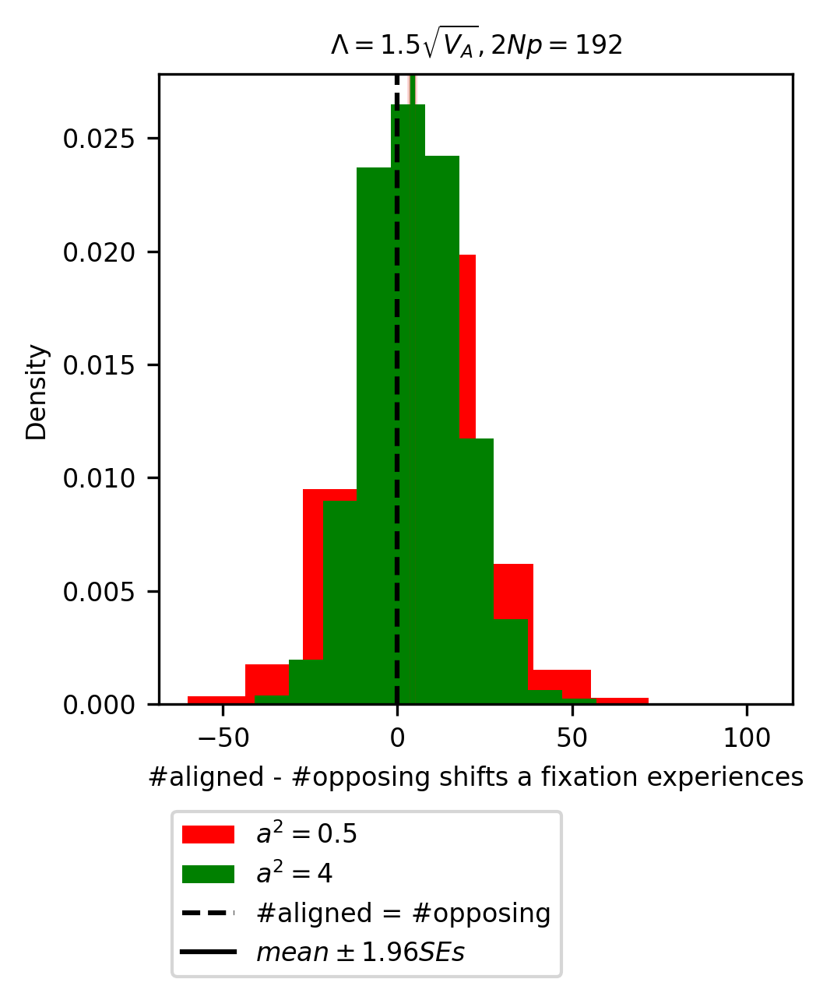

In [10]:
# linear scale
fontsize = 8

N = 2000
U = 0.025
E2Ns = 1
nE = 100

V2Ns = E2Ns ** 2
S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0.,
                                               scale=float(V2Ns) / float(E2Ns))
a_list_pos = [math.sqrt(S_dist.ppf((i + 1) / (nE + 1))) for i in range(nE)]

index_shift_s0, shift_s0 = 3, 1.5
index_rate_of_shift, rate_of_shift = 8, 0.048

fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = fig.add_subplot(1, 1, 1)

index_ss, ss, color = 38, 0.5, 'r'
# max_number_of_aligned_or_opposing_shifts_experienced = 0
numbers_of_aligned_shifts_experienced = list()
numbers_of_opposing_shifts_experienced = list()
parallel_AA = 49
for i in range(1, 1 + parallel_AA):
    with open('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_time_arising_fixing_empirical_average_V_A_%d/fixations_and_extinctions' % (round(E2Ns), i), 'rb') as f:
        fixations_and_extinctions, _, dist_ess_over_time, _, _, _, fixation_timings = pickle.load(f)
    trait_increasing_shift_times = [tM for tM in range(len(dist_ess_over_time)) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])]
    trait_decreasing_shift_times = [tM for tM in range(len(dist_ess_over_time)) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])]
    for fixation_timing, a in zip(fixation_timings, [mut[0] for mut in fixations_and_extinctions if mut[1]]):
        if np.searchsorted(a_list_pos, np.abs(a)) == index_ss + 1:
            number_of_trait_increasing_shifts_experienced = np.searchsorted(trait_increasing_shift_times, fixation_timing[1]) - np.searchsorted(trait_increasing_shift_times, fixation_timing[0])
            number_of_trait_decreasing_shifts_experienced = np.searchsorted(trait_decreasing_shift_times, fixation_timing[1]) - np.searchsorted(trait_decreasing_shift_times, fixation_timing[0])
            # max_number_of_aligned_or_opposing_shifts_experienced = max(max_number_of_aligned_or_opposing_shifts_experienced, number_of_trait_increasing_shifts_experienced, number_of_trait_decreasing_shifts_experienced)
            if a > 0:
                numbers_of_aligned_shifts_experienced.append(number_of_trait_increasing_shifts_experienced)
                numbers_of_opposing_shifts_experienced.append(number_of_trait_decreasing_shifts_experienced)
            else:
                numbers_of_aligned_shifts_experienced.append(number_of_trait_decreasing_shifts_experienced)
                numbers_of_opposing_shifts_experienced.append(number_of_trait_increasing_shifts_experienced)
ax.hist(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced), density=True, color=color, label=r'$a^2=%g$' % ss)
ax.axvline(x=np.mean(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), color=color)
ax.axvspan(xmin=np.mean(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)) - 1.96 * np.divide(np.std(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), np.sqrt(np.size(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)))), xmax=np.mean(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)) + 1.96 * np.divide(np.std(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), np.sqrt(np.size(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)))), color=color, alpha=0.15)

index_ss, ss, color = 98, 4, 'g'
# max_number_of_aligned_or_opposing_shifts_experienced = 0
numbers_of_aligned_shifts_experienced = list()
numbers_of_opposing_shifts_experienced = list()
parallel_AA = 49
for i in range(1, 1 + parallel_AA):
    with open('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_time_arising_fixing_empirical_average_V_A_%d/fixations_and_extinctions' % (round(E2Ns), i), 'rb') as f:
        fixations_and_extinctions, _, dist_ess_over_time, _, _, _, fixation_timings = pickle.load(f)
    trait_increasing_shift_times = [tM for tM in range(len(dist_ess_over_time)) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])]
    trait_decreasing_shift_times = [tM for tM in range(len(dist_ess_over_time)) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])]
    for fixation_timing, a in zip(fixation_timings, [mut[0] for mut in fixations_and_extinctions if mut[1]]):
        if np.searchsorted(a_list_pos, np.abs(a)) == index_ss + 1:
            number_of_trait_increasing_shifts_experienced = np.searchsorted(trait_increasing_shift_times, fixation_timing[1]) - np.searchsorted(trait_increasing_shift_times, fixation_timing[0])
            number_of_trait_decreasing_shifts_experienced = np.searchsorted(trait_decreasing_shift_times, fixation_timing[1]) - np.searchsorted(trait_decreasing_shift_times, fixation_timing[0])
            # max_number_of_aligned_or_opposing_shifts_experienced = max(max_number_of_aligned_or_opposing_shifts_experienced, number_of_trait_increasing_shifts_experienced, number_of_trait_decreasing_shifts_experienced)
            if a > 0:
                numbers_of_aligned_shifts_experienced.append(number_of_trait_increasing_shifts_experienced)
                numbers_of_opposing_shifts_experienced.append(number_of_trait_decreasing_shifts_experienced)
            else:
                numbers_of_aligned_shifts_experienced.append(number_of_trait_decreasing_shifts_experienced)
                numbers_of_opposing_shifts_experienced.append(number_of_trait_increasing_shifts_experienced)
ax.hist(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced), density=True, color=color, label=r'$a^2=%g$' % ss)
ax.axvline(x=np.mean(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), color=color)
ax.axvspan(xmin=np.mean(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)) - 1.96 * np.divide(np.std(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), np.sqrt(np.size(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)))), xmax=np.mean(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)) + 1.96 * np.divide(np.std(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), np.sqrt(np.size(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)))), color=color, alpha=0.15)

ax.axvline(x=0, color='k', linestyle='--', label='#aligned = #opposing')
ax.plot([], [], color='k', label=r'$mean\pm 1.96SEs$')
ax.legend(bbox_to_anchor=(0., -.15), loc='upper left', fontsize=fontsize)
plt.xlabel('#aligned - #opposing shifts a fixation experiences', fontsize=fontsize)
plt.ylabel('Density', fontsize=fontsize)
plt.title(r'$\Lambda=%g\sqrt{V_A}, 2Np=%g$' % (shift_s0, 2 * N * rate_of_shift), fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

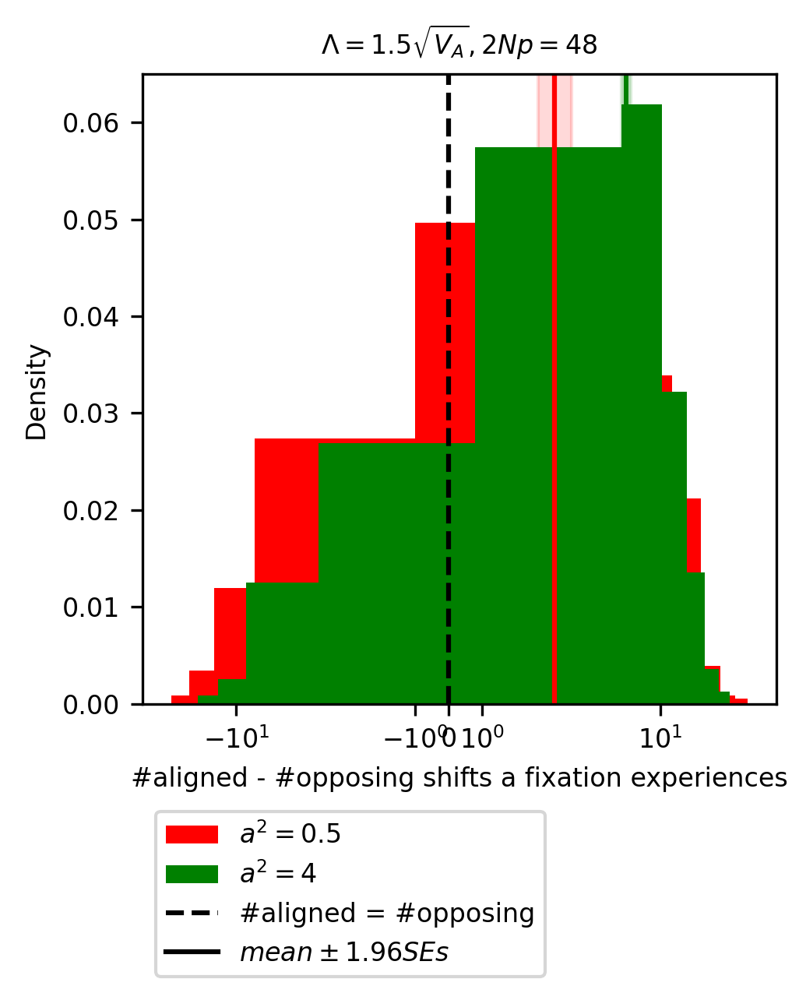

In [12]:
fontsize = 8

N = 2000
U = 0.025
E2Ns = 1
nE = 100

V2Ns = E2Ns ** 2
S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0.,
                                               scale=float(V2Ns) / float(E2Ns))
a_list_pos = [math.sqrt(S_dist.ppf((i + 1) / (nE + 1))) for i in range(nE)]

index_shift_s0, shift_s0 = 3, 1.5
index_rate_of_shift, rate_of_shift = 6, 0.012

fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = fig.add_subplot(1, 1, 1)

index_ss, ss, color = 38, 0.5, 'r'
# max_number_of_aligned_or_opposing_shifts_experienced = 0
numbers_of_aligned_shifts_experienced = list()
numbers_of_opposing_shifts_experienced = list()
parallel_AA = 49
for i in range(1, 1 + parallel_AA):
    with open('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_time_arising_fixing_empirical_average_V_A_%d/fixations_and_extinctions' % (round(E2Ns), i), 'rb') as f:
        fixations_and_extinctions, _, dist_ess_over_time, _, _, _, fixation_timings = pickle.load(f)
    trait_increasing_shift_times = [tM for tM in range(len(dist_ess_over_time)) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])]
    trait_decreasing_shift_times = [tM for tM in range(len(dist_ess_over_time)) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])]
    for fixation_timing, a in zip(fixation_timings, [mut[0] for mut in fixations_and_extinctions if mut[1]]):
        if np.searchsorted(a_list_pos, np.abs(a)) == index_ss + 1:
            number_of_trait_increasing_shifts_experienced = np.searchsorted(trait_increasing_shift_times, fixation_timing[1]) - np.searchsorted(trait_increasing_shift_times, fixation_timing[0])
            number_of_trait_decreasing_shifts_experienced = np.searchsorted(trait_decreasing_shift_times, fixation_timing[1]) - np.searchsorted(trait_decreasing_shift_times, fixation_timing[0])
            # max_number_of_aligned_or_opposing_shifts_experienced = max(max_number_of_aligned_or_opposing_shifts_experienced, number_of_trait_increasing_shifts_experienced, number_of_trait_decreasing_shifts_experienced)
            if a > 0:
                numbers_of_aligned_shifts_experienced.append(number_of_trait_increasing_shifts_experienced)
                numbers_of_opposing_shifts_experienced.append(number_of_trait_decreasing_shifts_experienced)
            else:
                numbers_of_aligned_shifts_experienced.append(number_of_trait_decreasing_shifts_experienced)
                numbers_of_opposing_shifts_experienced.append(number_of_trait_increasing_shifts_experienced)
ax.hist(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced), density=True, color=color, label=r'$a^2=%g$' % ss)
ax.axvline(x=np.mean(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), color=color)
ax.axvspan(xmin=np.mean(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)) - 1.96 * np.divide(np.std(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), np.sqrt(np.size(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)))), xmax=np.mean(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)) + 1.96 * np.divide(np.std(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), np.sqrt(np.size(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)))), color=color, alpha=0.15)

index_ss, ss, color = 98, 4, 'g'
# max_number_of_aligned_or_opposing_shifts_experienced = 0
numbers_of_aligned_shifts_experienced = list()
numbers_of_opposing_shifts_experienced = list()
parallel_AA = 49
for i in range(1, 1 + parallel_AA):
    with open('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_time_arising_fixing_empirical_average_V_A_%d/fixations_and_extinctions' % (round(E2Ns), i), 'rb') as f:
        fixations_and_extinctions, _, dist_ess_over_time, _, _, _, fixation_timings = pickle.load(f)
    trait_increasing_shift_times = [tM for tM in range(len(dist_ess_over_time)) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])]
    trait_decreasing_shift_times = [tM for tM in range(len(dist_ess_over_time)) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])]
    for fixation_timing, a in zip(fixation_timings, [mut[0] for mut in fixations_and_extinctions if mut[1]]):
        if np.searchsorted(a_list_pos, np.abs(a)) == index_ss + 1:
            number_of_trait_increasing_shifts_experienced = np.searchsorted(trait_increasing_shift_times, fixation_timing[1]) - np.searchsorted(trait_increasing_shift_times, fixation_timing[0])
            number_of_trait_decreasing_shifts_experienced = np.searchsorted(trait_decreasing_shift_times, fixation_timing[1]) - np.searchsorted(trait_decreasing_shift_times, fixation_timing[0])
            # max_number_of_aligned_or_opposing_shifts_experienced = max(max_number_of_aligned_or_opposing_shifts_experienced, number_of_trait_increasing_shifts_experienced, number_of_trait_decreasing_shifts_experienced)
            if a > 0:
                numbers_of_aligned_shifts_experienced.append(number_of_trait_increasing_shifts_experienced)
                numbers_of_opposing_shifts_experienced.append(number_of_trait_decreasing_shifts_experienced)
            else:
                numbers_of_aligned_shifts_experienced.append(number_of_trait_decreasing_shifts_experienced)
                numbers_of_opposing_shifts_experienced.append(number_of_trait_increasing_shifts_experienced)
ax.hist(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced), density=True, color=color, label=r'$a^2=%g$' % ss)
ax.axvline(x=np.mean(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), color=color)
ax.axvspan(xmin=np.mean(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)) - 1.96 * np.divide(np.std(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), np.sqrt(np.size(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)))), xmax=np.mean(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)) + 1.96 * np.divide(np.std(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), np.sqrt(np.size(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)))), color=color, alpha=0.15)

ax.axvline(x=0, color='k', linestyle='--', label='#aligned = #opposing')
ax.plot([], [], color='k', label=r'$mean\pm 1.96SEs$')
ax.set_xscale('symlog', linthresh=5, linscale=1)
ax.legend(bbox_to_anchor=(0., -.15), loc='upper left', fontsize=fontsize)
plt.xlabel('#aligned - #opposing shifts a fixation experiences', fontsize=fontsize)
plt.ylabel('Density', fontsize=fontsize)
plt.title(r'$\Lambda=%g\sqrt{V_A}, 2Np=%g$' % (shift_s0, 2 * N * rate_of_shift), fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

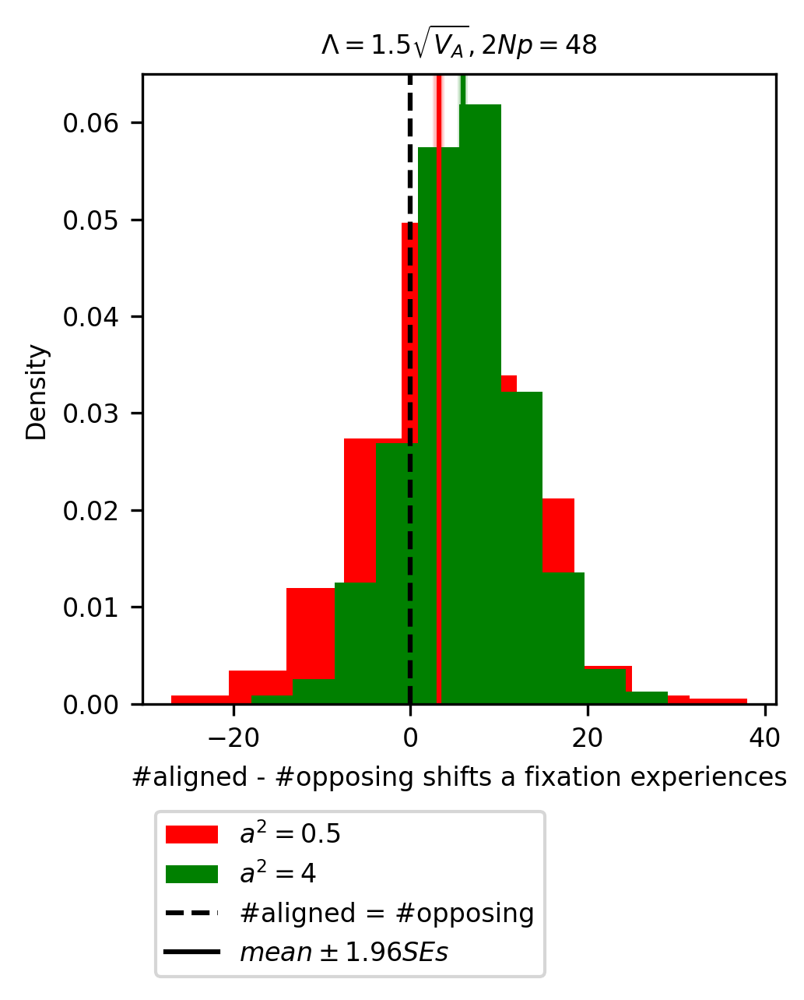

In [13]:
fontsize = 8

N = 2000
U = 0.025
E2Ns = 1
nE = 100

V2Ns = E2Ns ** 2
S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0.,
                                               scale=float(V2Ns) / float(E2Ns))
a_list_pos = [math.sqrt(S_dist.ppf((i + 1) / (nE + 1))) for i in range(nE)]

index_shift_s0, shift_s0 = 3, 1.5
index_rate_of_shift, rate_of_shift = 6, 0.012

fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = fig.add_subplot(1, 1, 1)

index_ss, ss, color = 38, 0.5, 'r'
# max_number_of_aligned_or_opposing_shifts_experienced = 0
numbers_of_aligned_shifts_experienced = list()
numbers_of_opposing_shifts_experienced = list()
parallel_AA = 49
for i in range(1, 1 + parallel_AA):
    with open('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_time_arising_fixing_empirical_average_V_A_%d/fixations_and_extinctions' % (round(E2Ns), i), 'rb') as f:
        fixations_and_extinctions, _, dist_ess_over_time, _, _, _, fixation_timings = pickle.load(f)
    trait_increasing_shift_times = [tM for tM in range(len(dist_ess_over_time)) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])]
    trait_decreasing_shift_times = [tM for tM in range(len(dist_ess_over_time)) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])]
    for fixation_timing, a in zip(fixation_timings, [mut[0] for mut in fixations_and_extinctions if mut[1]]):
        if np.searchsorted(a_list_pos, np.abs(a)) == index_ss + 1:
            number_of_trait_increasing_shifts_experienced = np.searchsorted(trait_increasing_shift_times, fixation_timing[1]) - np.searchsorted(trait_increasing_shift_times, fixation_timing[0])
            number_of_trait_decreasing_shifts_experienced = np.searchsorted(trait_decreasing_shift_times, fixation_timing[1]) - np.searchsorted(trait_decreasing_shift_times, fixation_timing[0])
            # max_number_of_aligned_or_opposing_shifts_experienced = max(max_number_of_aligned_or_opposing_shifts_experienced, number_of_trait_increasing_shifts_experienced, number_of_trait_decreasing_shifts_experienced)
            if a > 0:
                numbers_of_aligned_shifts_experienced.append(number_of_trait_increasing_shifts_experienced)
                numbers_of_opposing_shifts_experienced.append(number_of_trait_decreasing_shifts_experienced)
            else:
                numbers_of_aligned_shifts_experienced.append(number_of_trait_decreasing_shifts_experienced)
                numbers_of_opposing_shifts_experienced.append(number_of_trait_increasing_shifts_experienced)
ax.hist(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced), density=True, color=color, label=r'$a^2=%g$' % ss)
ax.axvline(x=np.mean(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), color=color)
ax.axvspan(xmin=np.mean(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)) - 1.96 * np.divide(np.std(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), np.sqrt(np.size(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)))), xmax=np.mean(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)) + 1.96 * np.divide(np.std(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), np.sqrt(np.size(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)))), color=color, alpha=0.15)

index_ss, ss, color = 98, 4, 'g'
# max_number_of_aligned_or_opposing_shifts_experienced = 0
numbers_of_aligned_shifts_experienced = list()
numbers_of_opposing_shifts_experienced = list()
parallel_AA = 49
for i in range(1, 1 + parallel_AA):
    with open('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_time_arising_fixing_empirical_average_V_A_%d/fixations_and_extinctions' % (round(E2Ns), i), 'rb') as f:
        fixations_and_extinctions, _, dist_ess_over_time, _, _, _, fixation_timings = pickle.load(f)
    trait_increasing_shift_times = [tM for tM in range(len(dist_ess_over_time)) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])]
    trait_decreasing_shift_times = [tM for tM in range(len(dist_ess_over_time)) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])]
    for fixation_timing, a in zip(fixation_timings, [mut[0] for mut in fixations_and_extinctions if mut[1]]):
        if np.searchsorted(a_list_pos, np.abs(a)) == index_ss + 1:
            number_of_trait_increasing_shifts_experienced = np.searchsorted(trait_increasing_shift_times, fixation_timing[1]) - np.searchsorted(trait_increasing_shift_times, fixation_timing[0])
            number_of_trait_decreasing_shifts_experienced = np.searchsorted(trait_decreasing_shift_times, fixation_timing[1]) - np.searchsorted(trait_decreasing_shift_times, fixation_timing[0])
            # max_number_of_aligned_or_opposing_shifts_experienced = max(max_number_of_aligned_or_opposing_shifts_experienced, number_of_trait_increasing_shifts_experienced, number_of_trait_decreasing_shifts_experienced)
            if a > 0:
                numbers_of_aligned_shifts_experienced.append(number_of_trait_increasing_shifts_experienced)
                numbers_of_opposing_shifts_experienced.append(number_of_trait_decreasing_shifts_experienced)
            else:
                numbers_of_aligned_shifts_experienced.append(number_of_trait_decreasing_shifts_experienced)
                numbers_of_opposing_shifts_experienced.append(number_of_trait_increasing_shifts_experienced)
ax.hist(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced), density=True, color=color, label=r'$a^2=%g$' % ss)
ax.axvline(x=np.mean(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), color=color)
ax.axvspan(xmin=np.mean(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)) - 1.96 * np.divide(np.std(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), np.sqrt(np.size(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)))), xmax=np.mean(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)) + 1.96 * np.divide(np.std(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), np.sqrt(np.size(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)))), color=color, alpha=0.15)

ax.axvline(x=0, color='k', linestyle='--', label='#aligned = #opposing')
ax.plot([], [], color='k', label=r'$mean\pm 1.96SEs$')
ax.legend(bbox_to_anchor=(0., -.15), loc='upper left', fontsize=fontsize)
plt.xlabel('#aligned - #opposing shifts a fixation experiences', fontsize=fontsize)
plt.ylabel('Density', fontsize=fontsize)
plt.title(r'$\Lambda=%g\sqrt{V_A}, 2Np=%g$' % (shift_s0, 2 * N * rate_of_shift), fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

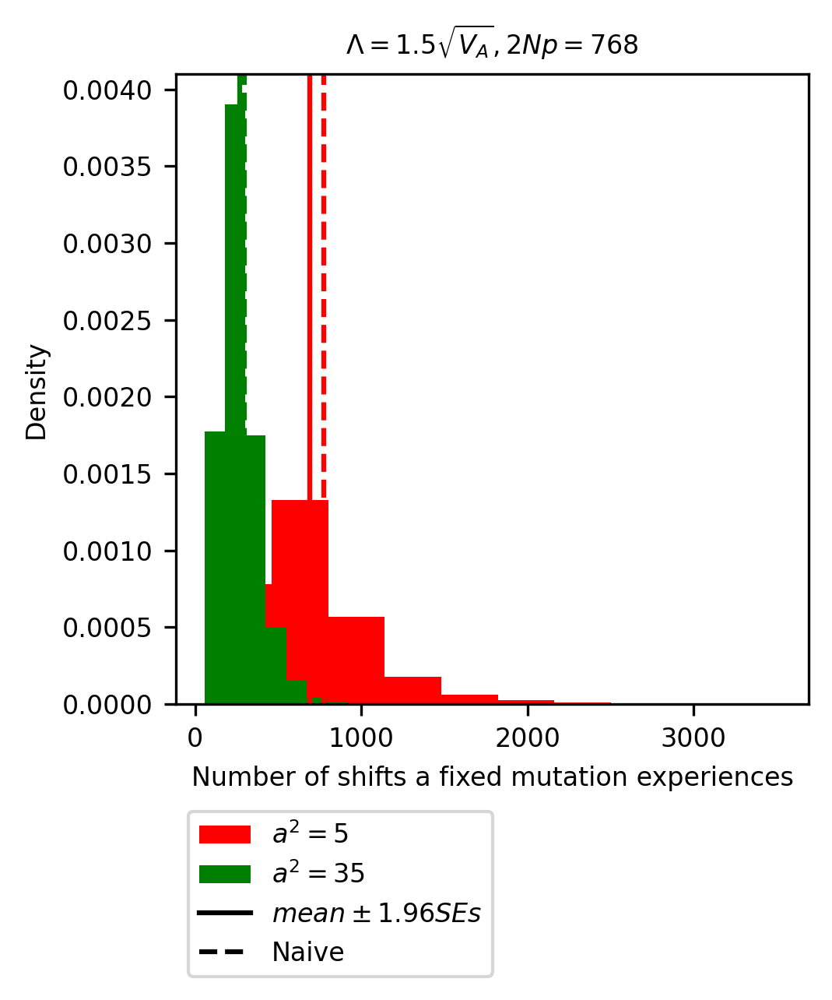

In [14]:
# the histogram of the total number of shifts that a fixed mutation experiences, in the non-Lande case
# linear scale
fontsize = 8

N = 2000
U = 0.025
E2Ns = 16
nE = 11

V2Ns = E2Ns ** 2
S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0.,
                                               scale=float(V2Ns) / float(E2Ns))
a_list_pos = [math.sqrt(S_dist.ppf((i + 1) / (nE + 1))) for i in range(nE)]

index_shift_s0, shift_s0 = 3, 1.5
index_rate_of_shift, rate_of_shift = 10, 0.192

fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = fig.add_subplot(1, 1, 1)

for index_ss, ss, color in ((2, 5, 'r'), (9, 35, 'g')):
    # max_number_of_aligned_or_opposing_shifts_experienced = 0
    # numbers_of_aligned_shifts_experienced = list()
    # numbers_of_opposing_shifts_experienced = list()
    numbers_of_shifts_experienced = list()
    naive_samples = list()
    parallel_AA = 49
    for i in range(1, 1 + parallel_AA):
        with open('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_time_arising_fixing_empirical_average_V_A_%d/fixations_and_extinctions' % (round(E2Ns), i), 'rb') as f:
            fixations_and_extinctions, _, dist_ess_over_time, _, _, _, fixation_timings = pickle.load(f)
        shift_times = [tM for tM in range(len(dist_ess_over_time)) if abs(dist_ess_over_time[tM] - dist_ess_over_time[tM - 1]) >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])]
        # trait_increasing_shift_times = [tM for tM in range(len(dist_ess_over_time)) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])]
        # trait_decreasing_shift_times = [tM for tM in range(len(dist_ess_over_time)) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])]
        for fixation_timing, a in zip(fixation_timings, [mut[0] for mut in fixations_and_extinctions if mut[1]]):
            if np.searchsorted(a_list_pos, np.abs(a)) == index_ss + 1:
                # number_of_trait_increasing_shifts_experienced = np.searchsorted(trait_increasing_shift_times, fixation_timing[1]) - np.searchsorted(trait_increasing_shift_times, fixation_timing[0])
                # number_of_trait_decreasing_shifts_experienced = np.searchsorted(trait_decreasing_shift_times, fixation_timing[1]) - np.searchsorted(trait_decreasing_shift_times, fixation_timing[0])
                numbers_of_shifts_experienced.append(np.searchsorted(shift_times, fixation_timing[1]) - np.searchsorted(shift_times, fixation_timing[0]))
                # max_number_of_aligned_or_opposing_shifts_experienced = max(max_number_of_aligned_or_opposing_shifts_experienced, number_of_trait_increasing_shifts_experienced, number_of_trait_decreasing_shifts_experienced)
                # if a > 0:
                #     numbers_of_aligned_shifts_experienced.append(number_of_trait_increasing_shifts_experienced)
                #     numbers_of_opposing_shifts_experienced.append(number_of_trait_decreasing_shifts_experienced)
                # else:
                #     numbers_of_aligned_shifts_experienced.append(number_of_trait_decreasing_shifts_experienced)
                #     numbers_of_opposing_shifts_experienced.append(number_of_trait_increasing_shifts_experienced)
                naive_samples.append(rate_of_shift * (fixation_timing[1] - fixation_timing[0]))
    # ax.hist(np.divide(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced), np.add(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), density=True, color=color, label=r'$a^2=%g$' % ss)
    
    ax.axvline(x=np.mean(naive_samples), color=color, linestyle='--')
    ax.axvspan(xmin=np.mean(numbers_of_shifts_experienced) - 1.96 * np.divide(np.std(numbers_of_shifts_experienced), np.sqrt(np.size(numbers_of_shifts_experienced))), xmax=np.mean(numbers_of_shifts_experienced) + 1.96 * np.divide(np.std(numbers_of_shifts_experienced), np.sqrt(np.size(numbers_of_shifts_experienced))), color=color, alpha=0.15)
    ax.axvline(x=np.mean(numbers_of_shifts_experienced), color=color)
    
    ax.hist(numbers_of_shifts_experienced, density=True, color=color, label=r'$a^2=%g$' % ss)

ax.plot([], [], color='k', label=r'$mean\pm 1.96SEs$')
ax.plot([], [], color='k', linestyle='--', label='Naive')
ax.legend(bbox_to_anchor=(0., -.15), loc='upper left', fontsize=fontsize)
plt.xlabel('Number of shifts a fixed mutation experiences', fontsize=fontsize)
plt.ylabel('Density', fontsize=fontsize)
plt.title(r'$\Lambda=%g\sqrt{V_A}, 2Np=%g$' % (shift_s0, 2 * N * rate_of_shift), fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

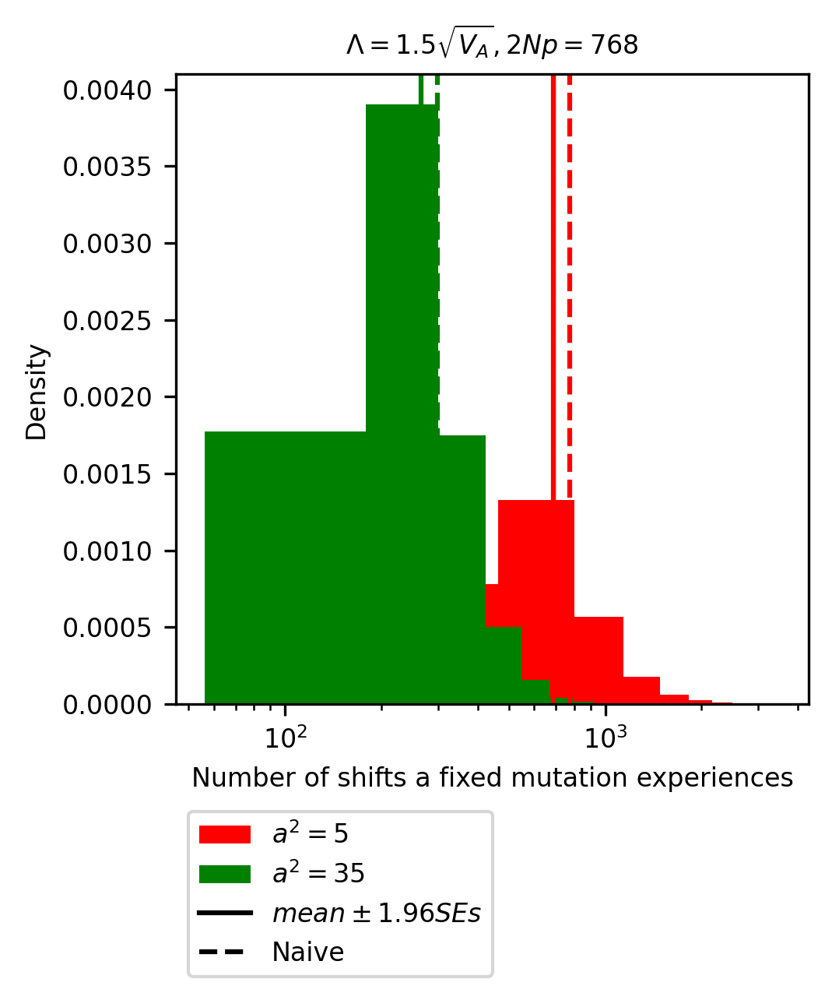

In [15]:
# log scale
fontsize = 8

N = 2000
U = 0.025
E2Ns = 16
nE = 11

V2Ns = E2Ns ** 2
S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0.,
                                               scale=float(V2Ns) / float(E2Ns))
a_list_pos = [math.sqrt(S_dist.ppf((i + 1) / (nE + 1))) for i in range(nE)]

index_shift_s0, shift_s0 = 3, 1.5
index_rate_of_shift, rate_of_shift = 10, 0.192

fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = fig.add_subplot(1, 1, 1)

for index_ss, ss, color in ((2, 5, 'r'), (9, 35, 'g')):
    # max_number_of_aligned_or_opposing_shifts_experienced = 0
    # numbers_of_aligned_shifts_experienced = list()
    # numbers_of_opposing_shifts_experienced = list()
    numbers_of_shifts_experienced = list()
    naive_samples = list()
    parallel_AA = 49
    for i in range(1, 1 + parallel_AA):
        with open('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_time_arising_fixing_empirical_average_V_A_%d/fixations_and_extinctions' % (round(E2Ns), i), 'rb') as f:
            fixations_and_extinctions, _, dist_ess_over_time, _, _, _, fixation_timings = pickle.load(f)
        shift_times = [tM for tM in range(len(dist_ess_over_time)) if abs(dist_ess_over_time[tM] - dist_ess_over_time[tM - 1]) >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])]
        # trait_increasing_shift_times = [tM for tM in range(len(dist_ess_over_time)) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])]
        # trait_decreasing_shift_times = [tM for tM in range(len(dist_ess_over_time)) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])]
        for fixation_timing, a in zip(fixation_timings, [mut[0] for mut in fixations_and_extinctions if mut[1]]):
            if np.searchsorted(a_list_pos, np.abs(a)) == index_ss + 1:
                # number_of_trait_increasing_shifts_experienced = np.searchsorted(trait_increasing_shift_times, fixation_timing[1]) - np.searchsorted(trait_increasing_shift_times, fixation_timing[0])
                # number_of_trait_decreasing_shifts_experienced = np.searchsorted(trait_decreasing_shift_times, fixation_timing[1]) - np.searchsorted(trait_decreasing_shift_times, fixation_timing[0])
                numbers_of_shifts_experienced.append(np.searchsorted(shift_times, fixation_timing[1]) - np.searchsorted(shift_times, fixation_timing[0]))
                # max_number_of_aligned_or_opposing_shifts_experienced = max(max_number_of_aligned_or_opposing_shifts_experienced, number_of_trait_increasing_shifts_experienced, number_of_trait_decreasing_shifts_experienced)
                # if a > 0:
                #     numbers_of_aligned_shifts_experienced.append(number_of_trait_increasing_shifts_experienced)
                #     numbers_of_opposing_shifts_experienced.append(number_of_trait_decreasing_shifts_experienced)
                # else:
                #     numbers_of_aligned_shifts_experienced.append(number_of_trait_decreasing_shifts_experienced)
                #     numbers_of_opposing_shifts_experienced.append(number_of_trait_increasing_shifts_experienced)
                naive_samples.append(rate_of_shift * (fixation_timing[1] - fixation_timing[0]))
    # ax.hist(np.divide(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced), np.add(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), density=True, color=color, label=r'$a^2=%g$' % ss)
    
    ax.axvline(x=np.mean(naive_samples), color=color, linestyle='--')
    ax.axvspan(xmin=np.mean(numbers_of_shifts_experienced) - 1.96 * np.divide(np.std(numbers_of_shifts_experienced), np.sqrt(np.size(numbers_of_shifts_experienced))), xmax=np.mean(numbers_of_shifts_experienced) + 1.96 * np.divide(np.std(numbers_of_shifts_experienced), np.sqrt(np.size(numbers_of_shifts_experienced))), color=color, alpha=0.15)
    ax.axvline(x=np.mean(numbers_of_shifts_experienced), color=color)
    
    ax.hist(numbers_of_shifts_experienced, density=True, color=color, label=r'$a^2=%g$' % ss)

ax.plot([], [], color='k', label=r'$mean\pm 1.96SEs$')
ax.plot([], [], color='k', linestyle='--', label='Naive')
ax.set_xscale('log')
ax.legend(bbox_to_anchor=(0., -.15), loc='upper left', fontsize=fontsize)
plt.xlabel('Number of shifts a fixed mutation experiences', fontsize=fontsize)
plt.ylabel('Density', fontsize=fontsize)
plt.title(r'$\Lambda=%g\sqrt{V_A}, 2Np=%g$' % (shift_s0, 2 * N * rate_of_shift), fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

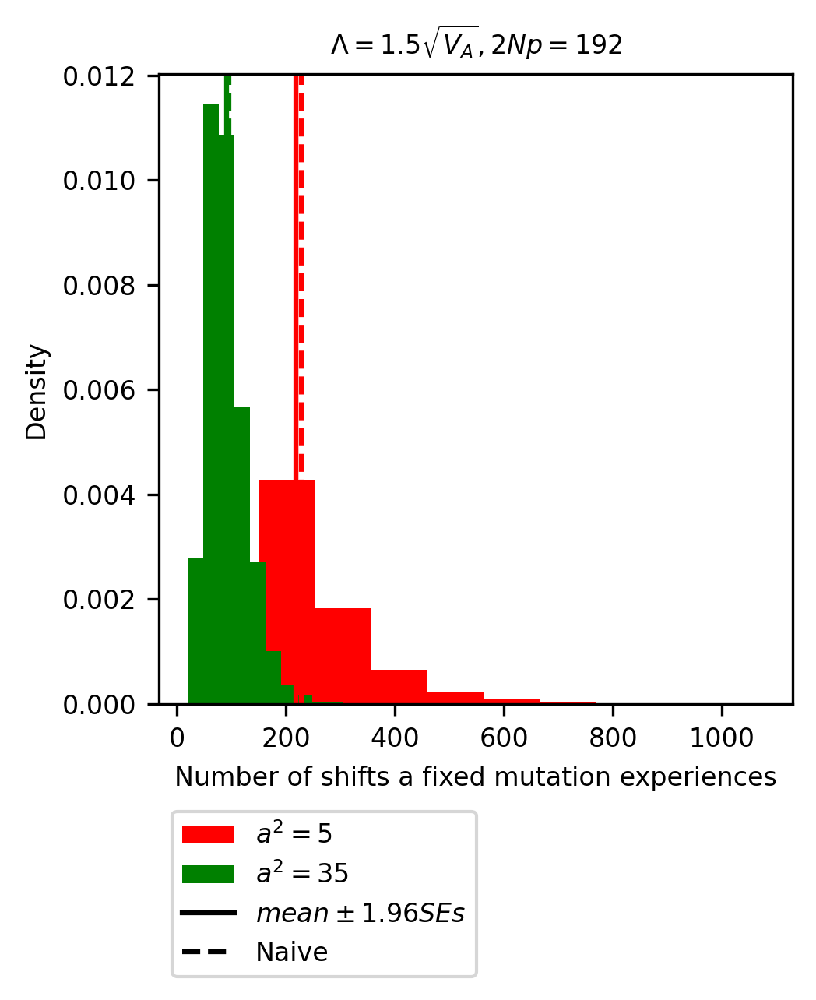

In [8]:
fontsize = 8

N = 2000
U = 0.025
E2Ns = 16
nE = 11

V2Ns = E2Ns ** 2
S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0.,
                                               scale=float(V2Ns) / float(E2Ns))
a_list_pos = [math.sqrt(S_dist.ppf((i + 1) / (nE + 1))) for i in range(nE)]

index_shift_s0, shift_s0 = 3, 1.5
index_rate_of_shift, rate_of_shift = 8, 0.048

fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = fig.add_subplot(1, 1, 1)

for index_ss, ss, color in ((2, 5, 'r'), (9, 35, 'g')):
    # max_number_of_aligned_or_opposing_shifts_experienced = 0
    # numbers_of_aligned_shifts_experienced = list()
    # numbers_of_opposing_shifts_experienced = list()
    numbers_of_shifts_experienced = list()
    naive_samples = list()
    parallel_AA = 49
    for i in range(1, 1 + parallel_AA):
        with open('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_time_arising_fixing_empirical_average_V_A_%d/fixations_and_extinctions' % (round(E2Ns), i), 'rb') as f:
            fixations_and_extinctions, _, dist_ess_over_time, _, _, _, fixation_timings = pickle.load(f)
        shift_times = [tM for tM in range(len(dist_ess_over_time)) if abs(dist_ess_over_time[tM] - dist_ess_over_time[tM - 1]) >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])]
        # trait_increasing_shift_times = [tM for tM in range(len(dist_ess_over_time)) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])]
        # trait_decreasing_shift_times = [tM for tM in range(len(dist_ess_over_time)) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])]
        for fixation_timing, a in zip(fixation_timings, [mut[0] for mut in fixations_and_extinctions if mut[1]]):
            if np.searchsorted(a_list_pos, np.abs(a)) == index_ss + 1:
                # number_of_trait_increasing_shifts_experienced = np.searchsorted(trait_increasing_shift_times, fixation_timing[1]) - np.searchsorted(trait_increasing_shift_times, fixation_timing[0])
                # number_of_trait_decreasing_shifts_experienced = np.searchsorted(trait_decreasing_shift_times, fixation_timing[1]) - np.searchsorted(trait_decreasing_shift_times, fixation_timing[0])
                numbers_of_shifts_experienced.append(np.searchsorted(shift_times, fixation_timing[1]) - np.searchsorted(shift_times, fixation_timing[0]))
                # max_number_of_aligned_or_opposing_shifts_experienced = max(max_number_of_aligned_or_opposing_shifts_experienced, number_of_trait_increasing_shifts_experienced, number_of_trait_decreasing_shifts_experienced)
                # if a > 0:
                #     numbers_of_aligned_shifts_experienced.append(number_of_trait_increasing_shifts_experienced)
                #     numbers_of_opposing_shifts_experienced.append(number_of_trait_decreasing_shifts_experienced)
                # else:
                #     numbers_of_aligned_shifts_experienced.append(number_of_trait_decreasing_shifts_experienced)
                #     numbers_of_opposing_shifts_experienced.append(number_of_trait_increasing_shifts_experienced)
                naive_samples.append(rate_of_shift * (fixation_timing[1] - fixation_timing[0]))
    # ax.hist(np.divide(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced), np.add(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), density=True, color=color, label=r'$a^2=%g$' % ss)
    
    ax.axvline(x=np.mean(naive_samples), color=color, linestyle='--')
    ax.axvspan(xmin=np.mean(numbers_of_shifts_experienced) - 1.96 * np.divide(np.std(numbers_of_shifts_experienced), np.sqrt(np.size(numbers_of_shifts_experienced))), xmax=np.mean(numbers_of_shifts_experienced) + 1.96 * np.divide(np.std(numbers_of_shifts_experienced), np.sqrt(np.size(numbers_of_shifts_experienced))), color=color, alpha=0.15)
    ax.axvline(x=np.mean(numbers_of_shifts_experienced), color=color)
    
    ax.hist(numbers_of_shifts_experienced, density=True, color=color, label=r'$a^2=%g$' % ss)

ax.plot([], [], color='k', label=r'$mean\pm 1.96SEs$')
ax.plot([], [], color='k', linestyle='--', label='Naive')
ax.legend(bbox_to_anchor=(0., -.15), loc='upper left', fontsize=fontsize)
plt.xlabel('Number of shifts a fixed mutation experiences', fontsize=fontsize)
plt.ylabel('Density', fontsize=fontsize)
plt.title(r'$\Lambda=%g\sqrt{V_A}, 2Np=%g$' % (shift_s0, 2 * N * rate_of_shift), fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

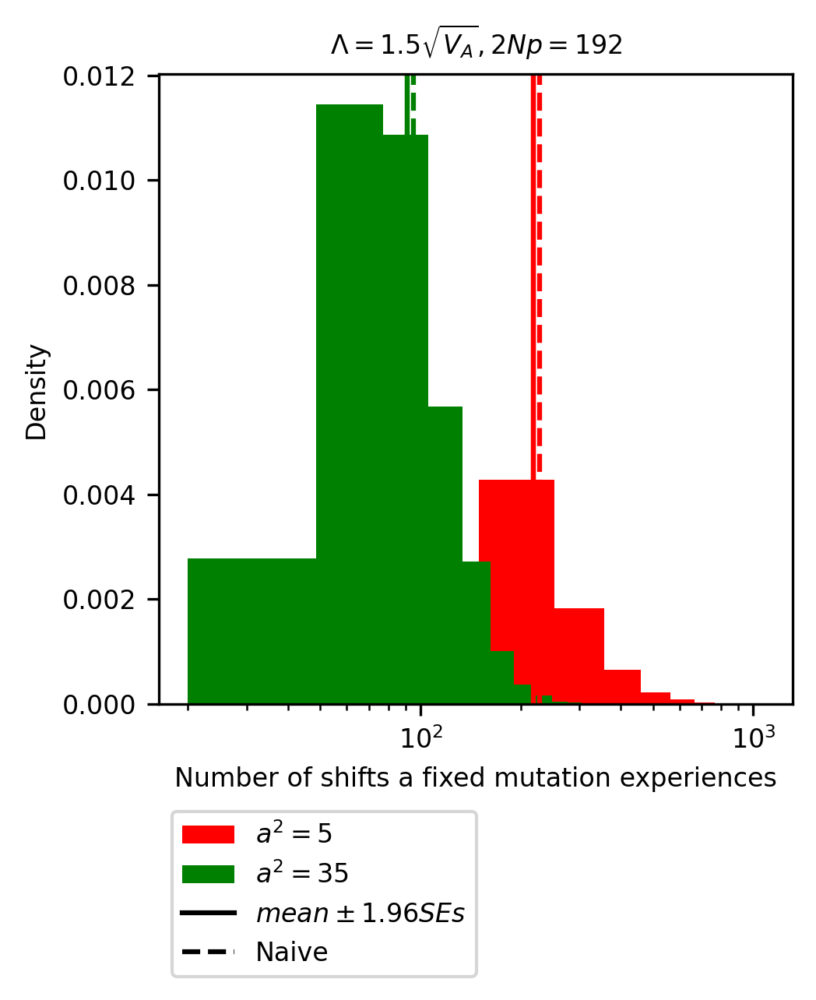

In [9]:
fontsize = 8

N = 2000
U = 0.025
E2Ns = 16
nE = 11

V2Ns = E2Ns ** 2
S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0.,
                                               scale=float(V2Ns) / float(E2Ns))
a_list_pos = [math.sqrt(S_dist.ppf((i + 1) / (nE + 1))) for i in range(nE)]

index_shift_s0, shift_s0 = 3, 1.5
index_rate_of_shift, rate_of_shift = 8, 0.048

fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = fig.add_subplot(1, 1, 1)

for index_ss, ss, color in ((2, 5, 'r'), (9, 35, 'g')):
    # max_number_of_aligned_or_opposing_shifts_experienced = 0
    # numbers_of_aligned_shifts_experienced = list()
    # numbers_of_opposing_shifts_experienced = list()
    numbers_of_shifts_experienced = list()
    naive_samples = list()
    parallel_AA = 49
    for i in range(1, 1 + parallel_AA):
        with open('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_time_arising_fixing_empirical_average_V_A_%d/fixations_and_extinctions' % (round(E2Ns), i), 'rb') as f:
            fixations_and_extinctions, _, dist_ess_over_time, _, _, _, fixation_timings = pickle.load(f)
        shift_times = [tM for tM in range(len(dist_ess_over_time)) if abs(dist_ess_over_time[tM] - dist_ess_over_time[tM - 1]) >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])]
        # trait_increasing_shift_times = [tM for tM in range(len(dist_ess_over_time)) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])]
        # trait_decreasing_shift_times = [tM for tM in range(len(dist_ess_over_time)) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])]
        for fixation_timing, a in zip(fixation_timings, [mut[0] for mut in fixations_and_extinctions if mut[1]]):
            if np.searchsorted(a_list_pos, np.abs(a)) == index_ss + 1:
                # number_of_trait_increasing_shifts_experienced = np.searchsorted(trait_increasing_shift_times, fixation_timing[1]) - np.searchsorted(trait_increasing_shift_times, fixation_timing[0])
                # number_of_trait_decreasing_shifts_experienced = np.searchsorted(trait_decreasing_shift_times, fixation_timing[1]) - np.searchsorted(trait_decreasing_shift_times, fixation_timing[0])
                numbers_of_shifts_experienced.append(np.searchsorted(shift_times, fixation_timing[1]) - np.searchsorted(shift_times, fixation_timing[0]))
                # max_number_of_aligned_or_opposing_shifts_experienced = max(max_number_of_aligned_or_opposing_shifts_experienced, number_of_trait_increasing_shifts_experienced, number_of_trait_decreasing_shifts_experienced)
                # if a > 0:
                #     numbers_of_aligned_shifts_experienced.append(number_of_trait_increasing_shifts_experienced)
                #     numbers_of_opposing_shifts_experienced.append(number_of_trait_decreasing_shifts_experienced)
                # else:
                #     numbers_of_aligned_shifts_experienced.append(number_of_trait_decreasing_shifts_experienced)
                #     numbers_of_opposing_shifts_experienced.append(number_of_trait_increasing_shifts_experienced)
                naive_samples.append(rate_of_shift * (fixation_timing[1] - fixation_timing[0]))
    # ax.hist(np.divide(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced), np.add(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), density=True, color=color, label=r'$a^2=%g$' % ss)
    
    ax.axvline(x=np.mean(naive_samples), color=color, linestyle='--')
    ax.axvspan(xmin=np.mean(numbers_of_shifts_experienced) - 1.96 * np.divide(np.std(numbers_of_shifts_experienced), np.sqrt(np.size(numbers_of_shifts_experienced))), xmax=np.mean(numbers_of_shifts_experienced) + 1.96 * np.divide(np.std(numbers_of_shifts_experienced), np.sqrt(np.size(numbers_of_shifts_experienced))), color=color, alpha=0.15)
    ax.axvline(x=np.mean(numbers_of_shifts_experienced), color=color)
    
    ax.hist(numbers_of_shifts_experienced, density=True, color=color, label=r'$a^2=%g$' % ss)

ax.plot([], [], color='k', label=r'$mean\pm 1.96SEs$')
ax.plot([], [], color='k', linestyle='--', label='Naive')
ax.set_xscale('log')
ax.legend(bbox_to_anchor=(0., -.15), loc='upper left', fontsize=fontsize)
plt.xlabel('Number of shifts a fixed mutation experiences', fontsize=fontsize)
plt.ylabel('Density', fontsize=fontsize)
plt.title(r'$\Lambda=%g\sqrt{V_A}, 2Np=%g$' % (shift_s0, 2 * N * rate_of_shift), fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

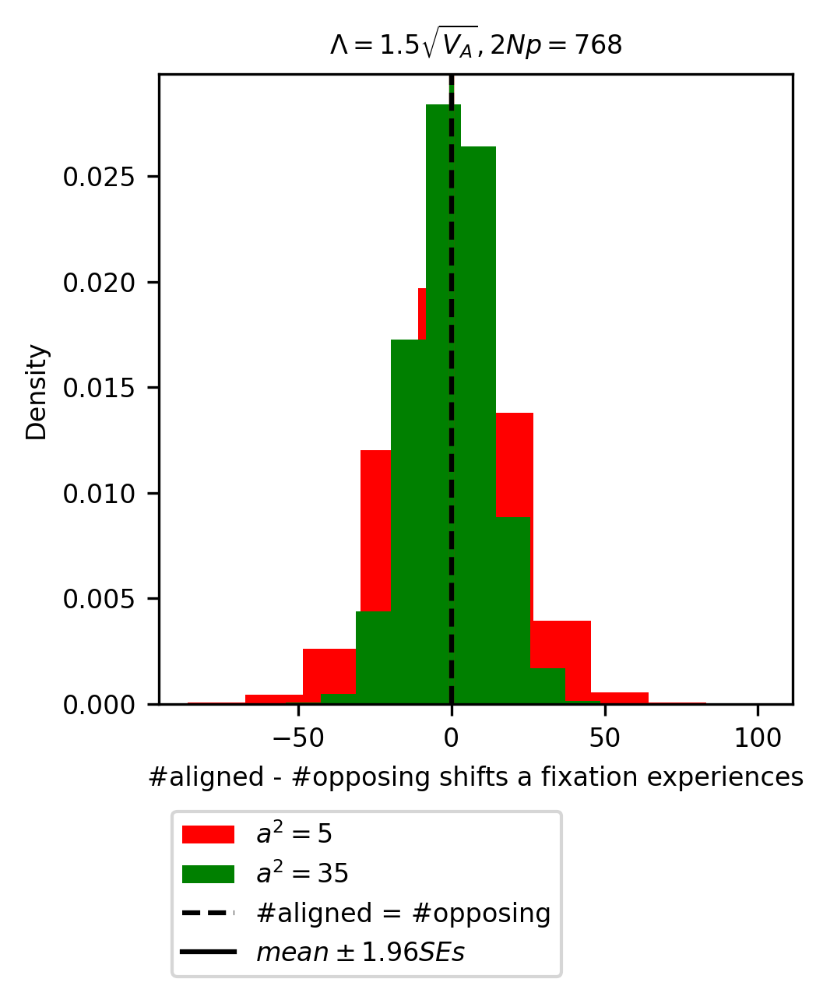

In [16]:
# the histogram of the excess number of aligned shifts than opposing shifts that a fixed mutation experiences, in the non-Lande case
# linear scale
fontsize = 8

N = 2000
U = 0.025
E2Ns = 16
nE = 11

V2Ns = E2Ns ** 2
S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0.,
                                               scale=float(V2Ns) / float(E2Ns))
a_list_pos = [math.sqrt(S_dist.ppf((i + 1) / (nE + 1))) for i in range(nE)]

index_shift_s0, shift_s0 = 3, 1.5
index_rate_of_shift, rate_of_shift = 10, 0.192

fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = fig.add_subplot(1, 1, 1)

index_ss, ss, color = 2, 5, 'r'
# max_number_of_aligned_or_opposing_shifts_experienced = 0
numbers_of_aligned_shifts_experienced = list()
numbers_of_opposing_shifts_experienced = list()
parallel_AA = 49
for i in range(1, 1 + parallel_AA):
    with open('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_time_arising_fixing_empirical_average_V_A_%d/fixations_and_extinctions' % (round(E2Ns), i), 'rb') as f:
        fixations_and_extinctions, _, dist_ess_over_time, _, _, _, fixation_timings = pickle.load(f)
    trait_increasing_shift_times = [tM for tM in range(len(dist_ess_over_time)) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])]
    trait_decreasing_shift_times = [tM for tM in range(len(dist_ess_over_time)) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])]
    for fixation_timing, a in zip(fixation_timings, [mut[0] for mut in fixations_and_extinctions if mut[1]]):
        if np.searchsorted(a_list_pos, np.abs(a)) == index_ss + 1:
            number_of_trait_increasing_shifts_experienced = np.searchsorted(trait_increasing_shift_times, fixation_timing[1]) - np.searchsorted(trait_increasing_shift_times, fixation_timing[0])
            number_of_trait_decreasing_shifts_experienced = np.searchsorted(trait_decreasing_shift_times, fixation_timing[1]) - np.searchsorted(trait_decreasing_shift_times, fixation_timing[0])
            # max_number_of_aligned_or_opposing_shifts_experienced = max(max_number_of_aligned_or_opposing_shifts_experienced, number_of_trait_increasing_shifts_experienced, number_of_trait_decreasing_shifts_experienced)
            if a > 0:
                numbers_of_aligned_shifts_experienced.append(number_of_trait_increasing_shifts_experienced)
                numbers_of_opposing_shifts_experienced.append(number_of_trait_decreasing_shifts_experienced)
            else:
                numbers_of_aligned_shifts_experienced.append(number_of_trait_decreasing_shifts_experienced)
                numbers_of_opposing_shifts_experienced.append(number_of_trait_increasing_shifts_experienced)
ax.hist(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced), density=True, color=color, label=r'$a^2=%g$' % ss)
ax.axvline(x=np.mean(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), color=color)
ax.axvspan(xmin=np.mean(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)) - 1.96 * np.divide(np.std(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), np.sqrt(np.size(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)))), xmax=np.mean(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)) + 1.96 * np.divide(np.std(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), np.sqrt(np.size(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)))), color=color, alpha=0.15)

index_ss, ss, color = 9, 35, 'g'
# max_number_of_aligned_or_opposing_shifts_experienced = 0
numbers_of_aligned_shifts_experienced = list()
numbers_of_opposing_shifts_experienced = list()
parallel_AA = 49
for i in range(1, 1 + parallel_AA):
    with open('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_time_arising_fixing_empirical_average_V_A_%d/fixations_and_extinctions' % (round(E2Ns), i), 'rb') as f:
        fixations_and_extinctions, _, dist_ess_over_time, _, _, _, fixation_timings = pickle.load(f)
    trait_increasing_shift_times = [tM for tM in range(len(dist_ess_over_time)) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])]
    trait_decreasing_shift_times = [tM for tM in range(len(dist_ess_over_time)) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])]
    for fixation_timing, a in zip(fixation_timings, [mut[0] for mut in fixations_and_extinctions if mut[1]]):
        if np.searchsorted(a_list_pos, np.abs(a)) == index_ss + 1:
            number_of_trait_increasing_shifts_experienced = np.searchsorted(trait_increasing_shift_times, fixation_timing[1]) - np.searchsorted(trait_increasing_shift_times, fixation_timing[0])
            number_of_trait_decreasing_shifts_experienced = np.searchsorted(trait_decreasing_shift_times, fixation_timing[1]) - np.searchsorted(trait_decreasing_shift_times, fixation_timing[0])
            # max_number_of_aligned_or_opposing_shifts_experienced = max(max_number_of_aligned_or_opposing_shifts_experienced, number_of_trait_increasing_shifts_experienced, number_of_trait_decreasing_shifts_experienced)
            if a > 0:
                numbers_of_aligned_shifts_experienced.append(number_of_trait_increasing_shifts_experienced)
                numbers_of_opposing_shifts_experienced.append(number_of_trait_decreasing_shifts_experienced)
            else:
                numbers_of_aligned_shifts_experienced.append(number_of_trait_decreasing_shifts_experienced)
                numbers_of_opposing_shifts_experienced.append(number_of_trait_increasing_shifts_experienced)
ax.hist(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced), density=True, color=color, label=r'$a^2=%g$' % ss)
ax.axvline(x=np.mean(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), color=color)
ax.axvspan(xmin=np.mean(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)) - 1.96 * np.divide(np.std(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), np.sqrt(np.size(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)))), xmax=np.mean(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)) + 1.96 * np.divide(np.std(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), np.sqrt(np.size(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)))), color=color, alpha=0.15)

ax.axvline(x=0, color='k', linestyle='--', label='#aligned = #opposing')
ax.plot([], [], color='k', label=r'$mean\pm 1.96SEs$')
ax.legend(bbox_to_anchor=(0., -.15), loc='upper left', fontsize=fontsize)
plt.xlabel('#aligned - #opposing shifts a fixation experiences', fontsize=fontsize)
plt.ylabel('Density', fontsize=fontsize)
plt.title(r'$\Lambda=%g\sqrt{V_A}, 2Np=%g$' % (shift_s0, 2 * N * rate_of_shift), fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

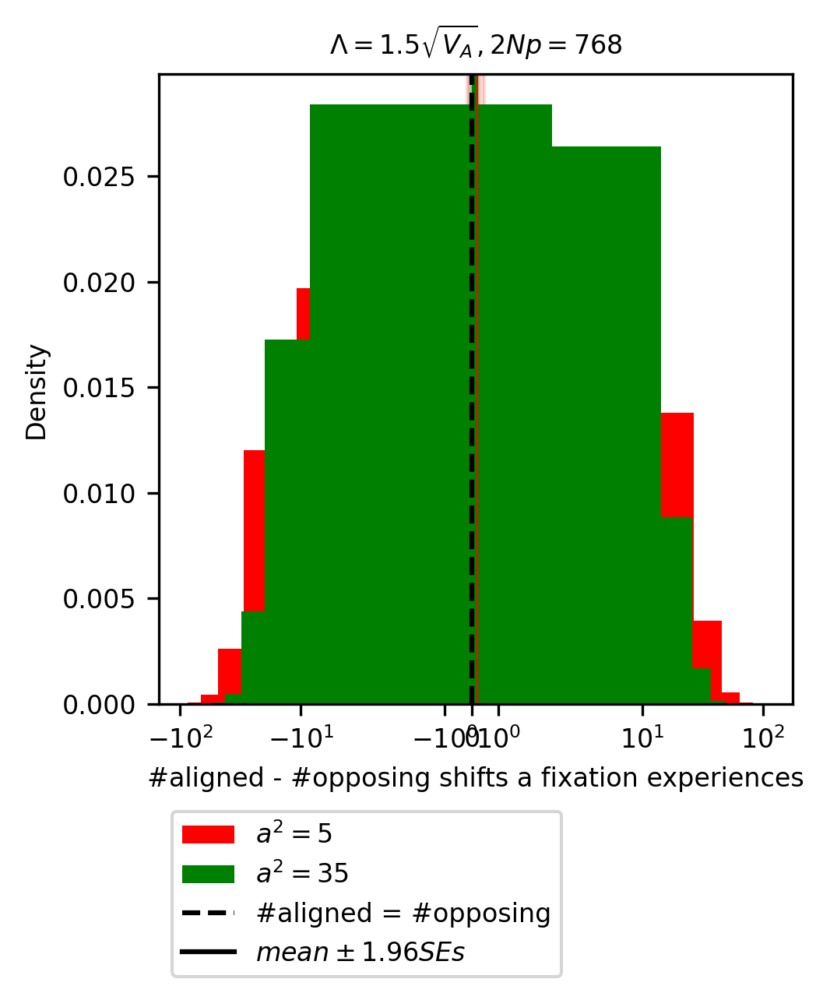

In [17]:
# log scale
fontsize = 8

N = 2000
U = 0.025
E2Ns = 16
nE = 11

V2Ns = E2Ns ** 2
S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0.,
                                               scale=float(V2Ns) / float(E2Ns))
a_list_pos = [math.sqrt(S_dist.ppf((i + 1) / (nE + 1))) for i in range(nE)]

index_shift_s0, shift_s0 = 3, 1.5
index_rate_of_shift, rate_of_shift = 10, 0.192

fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = fig.add_subplot(1, 1, 1)

index_ss, ss, color = 2, 5, 'r'
# max_number_of_aligned_or_opposing_shifts_experienced = 0
numbers_of_aligned_shifts_experienced = list()
numbers_of_opposing_shifts_experienced = list()
parallel_AA = 49
for i in range(1, 1 + parallel_AA):
    with open('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_time_arising_fixing_empirical_average_V_A_%d/fixations_and_extinctions' % (round(E2Ns), i), 'rb') as f:
        fixations_and_extinctions, _, dist_ess_over_time, _, _, _, fixation_timings = pickle.load(f)
    trait_increasing_shift_times = [tM for tM in range(len(dist_ess_over_time)) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])]
    trait_decreasing_shift_times = [tM for tM in range(len(dist_ess_over_time)) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])]
    for fixation_timing, a in zip(fixation_timings, [mut[0] for mut in fixations_and_extinctions if mut[1]]):
        if np.searchsorted(a_list_pos, np.abs(a)) == index_ss + 1:
            number_of_trait_increasing_shifts_experienced = np.searchsorted(trait_increasing_shift_times, fixation_timing[1]) - np.searchsorted(trait_increasing_shift_times, fixation_timing[0])
            number_of_trait_decreasing_shifts_experienced = np.searchsorted(trait_decreasing_shift_times, fixation_timing[1]) - np.searchsorted(trait_decreasing_shift_times, fixation_timing[0])
            # max_number_of_aligned_or_opposing_shifts_experienced = max(max_number_of_aligned_or_opposing_shifts_experienced, number_of_trait_increasing_shifts_experienced, number_of_trait_decreasing_shifts_experienced)
            if a > 0:
                numbers_of_aligned_shifts_experienced.append(number_of_trait_increasing_shifts_experienced)
                numbers_of_opposing_shifts_experienced.append(number_of_trait_decreasing_shifts_experienced)
            else:
                numbers_of_aligned_shifts_experienced.append(number_of_trait_decreasing_shifts_experienced)
                numbers_of_opposing_shifts_experienced.append(number_of_trait_increasing_shifts_experienced)
ax.hist(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced), density=True, color=color, label=r'$a^2=%g$' % ss)
ax.axvline(x=np.mean(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), color=color)
ax.axvspan(xmin=np.mean(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)) - 1.96 * np.divide(np.std(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), np.sqrt(np.size(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)))), xmax=np.mean(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)) + 1.96 * np.divide(np.std(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), np.sqrt(np.size(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)))), color=color, alpha=0.15)

index_ss, ss, color = 9, 35, 'g'
# max_number_of_aligned_or_opposing_shifts_experienced = 0
numbers_of_aligned_shifts_experienced = list()
numbers_of_opposing_shifts_experienced = list()
parallel_AA = 49
for i in range(1, 1 + parallel_AA):
    with open('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_time_arising_fixing_empirical_average_V_A_%d/fixations_and_extinctions' % (round(E2Ns), i), 'rb') as f:
        fixations_and_extinctions, _, dist_ess_over_time, _, _, _, fixation_timings = pickle.load(f)
    trait_increasing_shift_times = [tM for tM in range(len(dist_ess_over_time)) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])]
    trait_decreasing_shift_times = [tM for tM in range(len(dist_ess_over_time)) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])]
    for fixation_timing, a in zip(fixation_timings, [mut[0] for mut in fixations_and_extinctions if mut[1]]):
        if np.searchsorted(a_list_pos, np.abs(a)) == index_ss + 1:
            number_of_trait_increasing_shifts_experienced = np.searchsorted(trait_increasing_shift_times, fixation_timing[1]) - np.searchsorted(trait_increasing_shift_times, fixation_timing[0])
            number_of_trait_decreasing_shifts_experienced = np.searchsorted(trait_decreasing_shift_times, fixation_timing[1]) - np.searchsorted(trait_decreasing_shift_times, fixation_timing[0])
            # max_number_of_aligned_or_opposing_shifts_experienced = max(max_number_of_aligned_or_opposing_shifts_experienced, number_of_trait_increasing_shifts_experienced, number_of_trait_decreasing_shifts_experienced)
            if a > 0:
                numbers_of_aligned_shifts_experienced.append(number_of_trait_increasing_shifts_experienced)
                numbers_of_opposing_shifts_experienced.append(number_of_trait_decreasing_shifts_experienced)
            else:
                numbers_of_aligned_shifts_experienced.append(number_of_trait_decreasing_shifts_experienced)
                numbers_of_opposing_shifts_experienced.append(number_of_trait_increasing_shifts_experienced)
ax.hist(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced), density=True, color=color, label=r'$a^2=%g$' % ss)
ax.axvline(x=np.mean(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), color=color)
ax.axvspan(xmin=np.mean(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)) - 1.96 * np.divide(np.std(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), np.sqrt(np.size(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)))), xmax=np.mean(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)) + 1.96 * np.divide(np.std(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), np.sqrt(np.size(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)))), color=color, alpha=0.15)

ax.axvline(x=0, color='k', linestyle='--', label='#aligned = #opposing')
ax.plot([], [], color='k', label=r'$mean\pm 1.96SEs$')
ax.set_xscale('symlog', linthresh=5, linscale=1)
ax.legend(bbox_to_anchor=(0., -.15), loc='upper left', fontsize=fontsize)
plt.xlabel('#aligned - #opposing shifts a fixation experiences', fontsize=fontsize)
plt.ylabel('Density', fontsize=fontsize)
plt.title(r'$\Lambda=%g\sqrt{V_A}, 2Np=%g$' % (shift_s0, 2 * N * rate_of_shift), fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

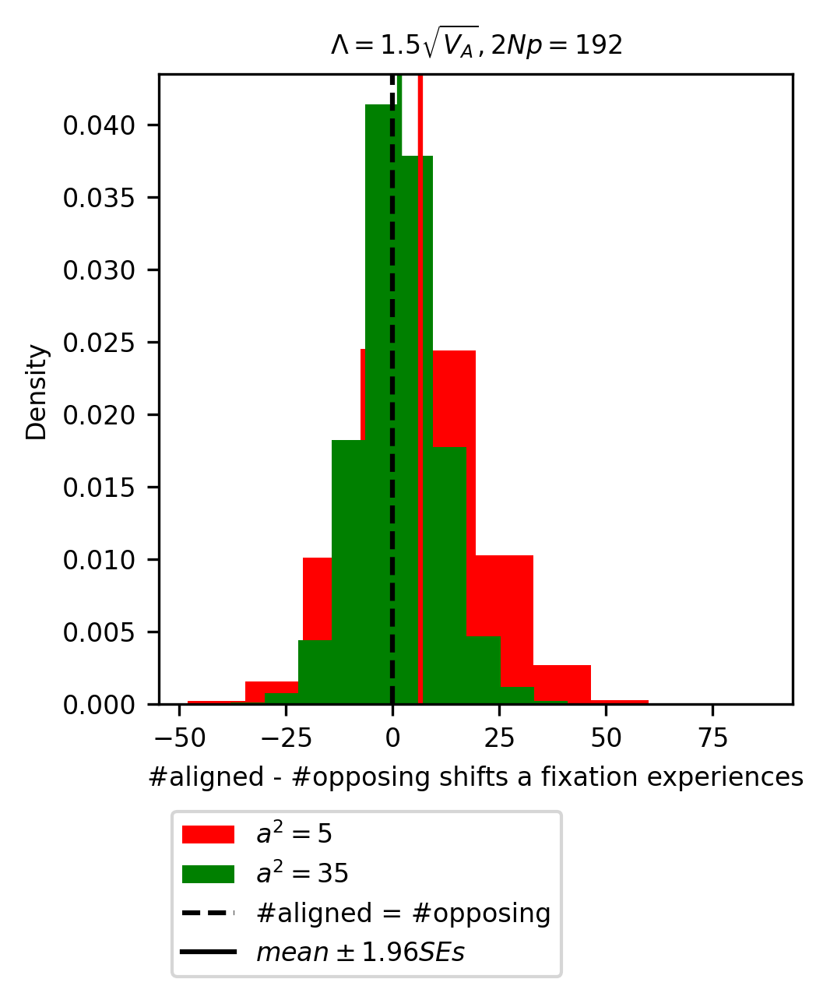

In [18]:
fontsize = 8

N = 2000
U = 0.025
E2Ns = 16
nE = 11

V2Ns = E2Ns ** 2
S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0.,
                                               scale=float(V2Ns) / float(E2Ns))
a_list_pos = [math.sqrt(S_dist.ppf((i + 1) / (nE + 1))) for i in range(nE)]

index_shift_s0, shift_s0 = 3, 1.5
index_rate_of_shift, rate_of_shift = 8, 0.048

fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = fig.add_subplot(1, 1, 1)

index_ss, ss, color = 2, 5, 'r'
# max_number_of_aligned_or_opposing_shifts_experienced = 0
numbers_of_aligned_shifts_experienced = list()
numbers_of_opposing_shifts_experienced = list()
parallel_AA = 49
for i in range(1, 1 + parallel_AA):
    with open('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_time_arising_fixing_empirical_average_V_A_%d/fixations_and_extinctions' % (round(E2Ns), i), 'rb') as f:
        fixations_and_extinctions, _, dist_ess_over_time, _, _, _, fixation_timings = pickle.load(f)
    trait_increasing_shift_times = [tM for tM in range(len(dist_ess_over_time)) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])]
    trait_decreasing_shift_times = [tM for tM in range(len(dist_ess_over_time)) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])]
    for fixation_timing, a in zip(fixation_timings, [mut[0] for mut in fixations_and_extinctions if mut[1]]):
        if np.searchsorted(a_list_pos, np.abs(a)) == index_ss + 1:
            number_of_trait_increasing_shifts_experienced = np.searchsorted(trait_increasing_shift_times, fixation_timing[1]) - np.searchsorted(trait_increasing_shift_times, fixation_timing[0])
            number_of_trait_decreasing_shifts_experienced = np.searchsorted(trait_decreasing_shift_times, fixation_timing[1]) - np.searchsorted(trait_decreasing_shift_times, fixation_timing[0])
            # max_number_of_aligned_or_opposing_shifts_experienced = max(max_number_of_aligned_or_opposing_shifts_experienced, number_of_trait_increasing_shifts_experienced, number_of_trait_decreasing_shifts_experienced)
            if a > 0:
                numbers_of_aligned_shifts_experienced.append(number_of_trait_increasing_shifts_experienced)
                numbers_of_opposing_shifts_experienced.append(number_of_trait_decreasing_shifts_experienced)
            else:
                numbers_of_aligned_shifts_experienced.append(number_of_trait_decreasing_shifts_experienced)
                numbers_of_opposing_shifts_experienced.append(number_of_trait_increasing_shifts_experienced)
ax.hist(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced), density=True, color=color, label=r'$a^2=%g$' % ss)
ax.axvline(x=np.mean(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), color=color)
ax.axvspan(xmin=np.mean(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)) - 1.96 * np.divide(np.std(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), np.sqrt(np.size(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)))), xmax=np.mean(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)) + 1.96 * np.divide(np.std(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), np.sqrt(np.size(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)))), color=color, alpha=0.15)

index_ss, ss, color = 9, 35, 'g'
# max_number_of_aligned_or_opposing_shifts_experienced = 0
numbers_of_aligned_shifts_experienced = list()
numbers_of_opposing_shifts_experienced = list()
parallel_AA = 49
for i in range(1, 1 + parallel_AA):
    with open('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_time_arising_fixing_empirical_average_V_A_%d/fixations_and_extinctions' % (round(E2Ns), i), 'rb') as f:
        fixations_and_extinctions, _, dist_ess_over_time, _, _, _, fixation_timings = pickle.load(f)
    trait_increasing_shift_times = [tM for tM in range(len(dist_ess_over_time)) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])]
    trait_decreasing_shift_times = [tM for tM in range(len(dist_ess_over_time)) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])]
    for fixation_timing, a in zip(fixation_timings, [mut[0] for mut in fixations_and_extinctions if mut[1]]):
        if np.searchsorted(a_list_pos, np.abs(a)) == index_ss + 1:
            number_of_trait_increasing_shifts_experienced = np.searchsorted(trait_increasing_shift_times, fixation_timing[1]) - np.searchsorted(trait_increasing_shift_times, fixation_timing[0])
            number_of_trait_decreasing_shifts_experienced = np.searchsorted(trait_decreasing_shift_times, fixation_timing[1]) - np.searchsorted(trait_decreasing_shift_times, fixation_timing[0])
            # max_number_of_aligned_or_opposing_shifts_experienced = max(max_number_of_aligned_or_opposing_shifts_experienced, number_of_trait_increasing_shifts_experienced, number_of_trait_decreasing_shifts_experienced)
            if a > 0:
                numbers_of_aligned_shifts_experienced.append(number_of_trait_increasing_shifts_experienced)
                numbers_of_opposing_shifts_experienced.append(number_of_trait_decreasing_shifts_experienced)
            else:
                numbers_of_aligned_shifts_experienced.append(number_of_trait_decreasing_shifts_experienced)
                numbers_of_opposing_shifts_experienced.append(number_of_trait_increasing_shifts_experienced)
ax.hist(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced), density=True, color=color, label=r'$a^2=%g$' % ss)
ax.axvline(x=np.mean(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), color=color)
ax.axvspan(xmin=np.mean(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)) - 1.96 * np.divide(np.std(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), np.sqrt(np.size(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)))), xmax=np.mean(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)) + 1.96 * np.divide(np.std(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), np.sqrt(np.size(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)))), color=color, alpha=0.15)

ax.axvline(x=0, color='k', linestyle='--', label='#aligned = #opposing')
ax.plot([], [], color='k', label=r'$mean\pm 1.96SEs$')
ax.legend(bbox_to_anchor=(0., -.15), loc='upper left', fontsize=fontsize)
plt.xlabel('#aligned - #opposing shifts a fixation experiences', fontsize=fontsize)
plt.ylabel('Density', fontsize=fontsize)
plt.title(r'$\Lambda=%g\sqrt{V_A}, 2Np=%g$' % (shift_s0, 2 * N * rate_of_shift), fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

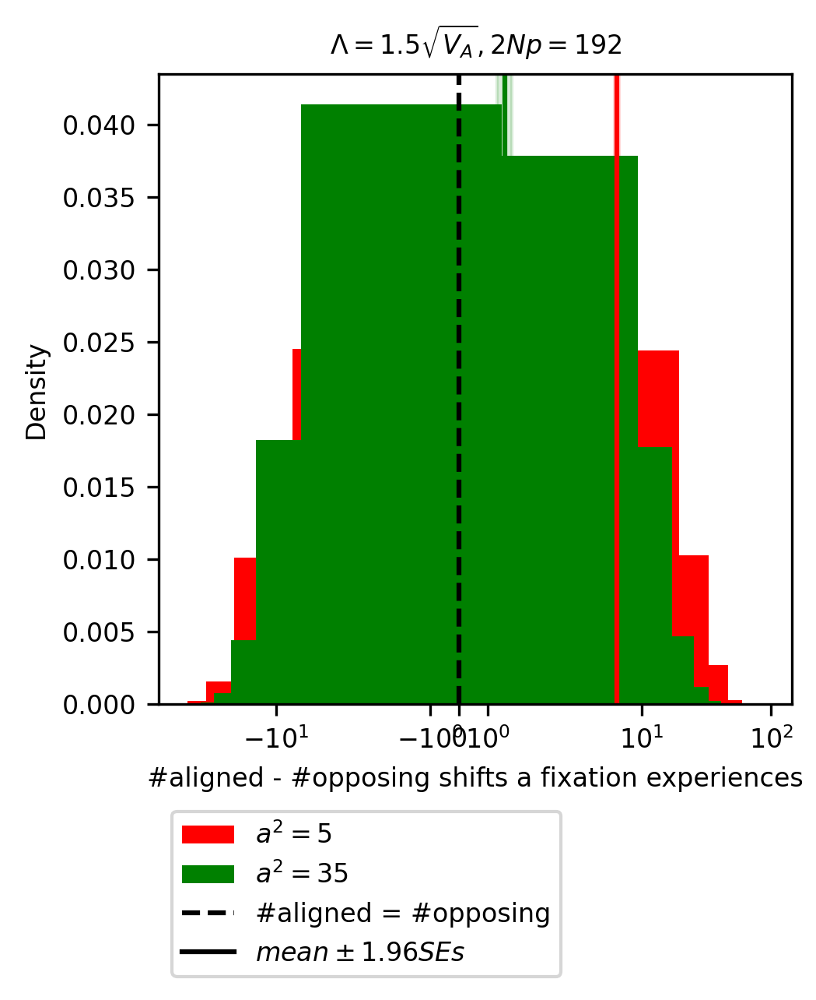

In [19]:
fontsize = 8

N = 2000
U = 0.025
E2Ns = 16
nE = 11

V2Ns = E2Ns ** 2
S_dist = gamma(float(E2Ns) ** 2 / float(V2Ns), loc=0.,
                                               scale=float(V2Ns) / float(E2Ns))
a_list_pos = [math.sqrt(S_dist.ppf((i + 1) / (nE + 1))) for i in range(nE)]

index_shift_s0, shift_s0 = 3, 1.5
index_rate_of_shift, rate_of_shift = 8, 0.048

fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = fig.add_subplot(1, 1, 1)

index_ss, ss, color = 2, 5, 'r'
# max_number_of_aligned_or_opposing_shifts_experienced = 0
numbers_of_aligned_shifts_experienced = list()
numbers_of_opposing_shifts_experienced = list()
parallel_AA = 49
for i in range(1, 1 + parallel_AA):
    with open('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_time_arising_fixing_empirical_average_V_A_%d/fixations_and_extinctions' % (round(E2Ns), i), 'rb') as f:
        fixations_and_extinctions, _, dist_ess_over_time, _, _, _, fixation_timings = pickle.load(f)
    trait_increasing_shift_times = [tM for tM in range(len(dist_ess_over_time)) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])]
    trait_decreasing_shift_times = [tM for tM in range(len(dist_ess_over_time)) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])]
    for fixation_timing, a in zip(fixation_timings, [mut[0] for mut in fixations_and_extinctions if mut[1]]):
        if np.searchsorted(a_list_pos, np.abs(a)) == index_ss + 1:
            number_of_trait_increasing_shifts_experienced = np.searchsorted(trait_increasing_shift_times, fixation_timing[1]) - np.searchsorted(trait_increasing_shift_times, fixation_timing[0])
            number_of_trait_decreasing_shifts_experienced = np.searchsorted(trait_decreasing_shift_times, fixation_timing[1]) - np.searchsorted(trait_decreasing_shift_times, fixation_timing[0])
            # max_number_of_aligned_or_opposing_shifts_experienced = max(max_number_of_aligned_or_opposing_shifts_experienced, number_of_trait_increasing_shifts_experienced, number_of_trait_decreasing_shifts_experienced)
            if a > 0:
                numbers_of_aligned_shifts_experienced.append(number_of_trait_increasing_shifts_experienced)
                numbers_of_opposing_shifts_experienced.append(number_of_trait_decreasing_shifts_experienced)
            else:
                numbers_of_aligned_shifts_experienced.append(number_of_trait_decreasing_shifts_experienced)
                numbers_of_opposing_shifts_experienced.append(number_of_trait_increasing_shifts_experienced)
ax.hist(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced), density=True, color=color, label=r'$a^2=%g$' % ss)
ax.axvline(x=np.mean(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), color=color)
ax.axvspan(xmin=np.mean(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)) - 1.96 * np.divide(np.std(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), np.sqrt(np.size(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)))), xmax=np.mean(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)) + 1.96 * np.divide(np.std(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), np.sqrt(np.size(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)))), color=color, alpha=0.15)

index_ss, ss, color = 9, 35, 'g'
# max_number_of_aligned_or_opposing_shifts_experienced = 0
numbers_of_aligned_shifts_experienced = list()
numbers_of_opposing_shifts_experienced = list()
parallel_AA = 49
for i in range(1, 1 + parallel_AA):
    with open('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_no_efs_bins_time_arising_fixing_empirical_average_V_A_%d/fixations_and_extinctions' % (round(E2Ns), i), 'rb') as f:
        fixations_and_extinctions, _, dist_ess_over_time, _, _, _, fixation_timings = pickle.load(f)
    trait_increasing_shift_times = [tM for tM in range(len(dist_ess_over_time)) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])]
    trait_decreasing_shift_times = [tM for tM in range(len(dist_ess_over_time)) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])]
    for fixation_timing, a in zip(fixation_timings, [mut[0] for mut in fixations_and_extinctions if mut[1]]):
        if np.searchsorted(a_list_pos, np.abs(a)) == index_ss + 1:
            number_of_trait_increasing_shifts_experienced = np.searchsorted(trait_increasing_shift_times, fixation_timing[1]) - np.searchsorted(trait_increasing_shift_times, fixation_timing[0])
            number_of_trait_decreasing_shifts_experienced = np.searchsorted(trait_decreasing_shift_times, fixation_timing[1]) - np.searchsorted(trait_decreasing_shift_times, fixation_timing[0])
            # max_number_of_aligned_or_opposing_shifts_experienced = max(max_number_of_aligned_or_opposing_shifts_experienced, number_of_trait_increasing_shifts_experienced, number_of_trait_decreasing_shifts_experienced)
            if a > 0:
                numbers_of_aligned_shifts_experienced.append(number_of_trait_increasing_shifts_experienced)
                numbers_of_opposing_shifts_experienced.append(number_of_trait_decreasing_shifts_experienced)
            else:
                numbers_of_aligned_shifts_experienced.append(number_of_trait_decreasing_shifts_experienced)
                numbers_of_opposing_shifts_experienced.append(number_of_trait_increasing_shifts_experienced)
ax.hist(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced), density=True, color=color, label=r'$a^2=%g$' % ss)
ax.axvline(x=np.mean(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), color=color)
ax.axvspan(xmin=np.mean(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)) - 1.96 * np.divide(np.std(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), np.sqrt(np.size(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)))), xmax=np.mean(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)) + 1.96 * np.divide(np.std(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)), np.sqrt(np.size(np.subtract(numbers_of_aligned_shifts_experienced, numbers_of_opposing_shifts_experienced)))), color=color, alpha=0.15)

ax.axvline(x=0, color='k', linestyle='--', label='#aligned = #opposing')
ax.plot([], [], color='k', label=r'$mean\pm 1.96SEs$')
ax.set_xscale('symlog', linthresh=5, linscale=1)
ax.legend(bbox_to_anchor=(0., -.15), loc='upper left', fontsize=fontsize)
plt.xlabel('#aligned - #opposing shifts a fixation experiences', fontsize=fontsize)
plt.ylabel('Density', fontsize=fontsize)
plt.title(r'$\Lambda=%g\sqrt{V_A}, 2Np=%g$' % (shift_s0, 2 * N * rate_of_shift), fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()